In [69]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/adc_current.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/case6_fast_fault.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/calibration_bench.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/adc_temp.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/case1_baseline.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/case3_runaway_prevention.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/case5_severe_aging.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/case4_aging_warning.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/case2_thermal_derate.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/adc_voltage_sar.txt


In [70]:
import os
import re
import glob
import numpy as np
import pandas as pd

# ---------- 1. Find uploaded files ----------
DATA_ROOTS = [
    "/kaggle/input",
    "/kaggle/working",
    "."
]

def find_candidate_files():
    patterns = ["**/*.txt", "**/*.csv", "**/*.dat"]
    files = []
    for root in DATA_ROOTS:
        if os.path.exists(root):
            for pattern in patterns:
                files.extend(glob.glob(os.path.join(root, pattern), recursive=True))
    # unique + sorted
    files = sorted(list(set(files)))
    return files

candidate_files = find_candidate_files()
print(f"Found {len(candidate_files)} candidate files")
for f in candidate_files:
    print(f)

Found 46 candidate files
./protection_advanced_metrics.csv
./protection_behavior_interpretation.csv
./protection_case_summary.csv
./protection_case_timeline.csv
./stage2f_counterfactual_comparison.csv
./stage2f_multi_timescale_proof.csv
./stage2f_novelty_table.csv
./stage2f_teacher_comparison.csv
./stage2f_xfactor_conclusions.csv
./stage2h_case2_expected_vs_observed.csv
./stage2h_case3_segmented_behavior.csv
./stage2h_case45_aging_policy_compare.csv
./theory_validation_aging.csv
./theory_validation_consistency.csv
./theory_validation_fastfault.csv
./theory_validation_master.csv
./theory_validation_runaway.csv
./theory_validation_thermal.csv
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/adc_current.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/adc_temp.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/adc_voltage_sar.txt
/kaggle/input/datasets/chaahatsingal/ev-battery-project-data/calibration_bench.txt
/kaggle/input/datasets/chaahatsingal

In [71]:
def clean_column_name(col: str) -> str:
    col = str(col).strip()
    col = col.replace("(", "_").replace(")", "")
    col = col.replace("[", "_").replace("]", "")
    col = col.replace("/", "_per_")
    col = col.replace("-", "_")
    col = col.replace(" ", "_")
    col = re.sub(r"[^a-zA-Z0-9_]", "", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_").lower()

def try_read_table(path: str):
    # Try common separators
    seps = [None, "\t", ",", ";", r"\s+"]
    last_error = None
    
    for sep in seps:
        try:
            if sep is None:
                df = pd.read_csv(path, engine="python")
            else:
                df = pd.read_csv(path, sep=sep, engine="python")
            
            # accept only meaningful tables
            if df.shape[1] >= 2:
                old_cols = list(df.columns)
                df.columns = [clean_column_name(c) for c in df.columns]
                
                # convert numeric-like columns
                for c in df.columns:
                    df[c] = pd.to_numeric(df[c], errors="ignore")
                
                return df, old_cols, None
        except Exception as e:
            last_error = e
    
    return None, None, last_error

In [72]:
def classify_file(path: str, df: pd.DataFrame):
    cols = set(df.columns)
    fname = os.path.basename(path).lower()

    # Protection / case files
    protection_markers = {
        "age_stress", "aging_warn", "aging_severe", "health_score",
        "risk_score", "icmd_scale_final", "r0eff"
    }

    # Calibration file
    calibration_markers = {
        "v_cal_out", "i_cal_out", "v_cal_hold", "i_cal_hold",
        "v_cal_corr", "i_cal_corr", "cal_valid"
    }

    # Current ADC
    current_adc_markers = {
        "i_adc_in", "i_adc_q", "i_adc_code", "i_adc_out"
    }

    # Temp ADC
    temp_adc_markers = {
        "t_adc_in", "t_adc_q", "t_adc_code", "t_adc_out"
    }

    # Voltage SAR
    sar_markers = {
        "vsar_code_v", "dac_out_sar", "v_samp_hold", "cmp_bit_sar"
    }

    if len(cols & sar_markers) >= 2:
        return "adc_voltage_sar"
    if len(cols & calibration_markers) >= 3:
        return "calibration"
    if len(cols & protection_markers) >= 3:
        return "protection_case"
    if len(cols & current_adc_markers) >= 3 and len(cols & temp_adc_markers) < 3:
        return "adc_current"
    if len(cols & temp_adc_markers) >= 3 and len(cols & current_adc_markers) < 3:
        return "adc_temp"
    if len(cols & current_adc_markers) >= 3 and len(cols & temp_adc_markers) >= 3:
        return "adc_mixed"
    
    # filename hints fallback
    if "calib" in fname:
        return "calibration"
    if "case" in fname or "casv" in fname:
        return "protection_case"
    if "vadc" in fname or "sar" in fname:
        return "adc_voltage_sar"
    if "curr" in fname:
        return "adc_current"
    if "temp" in fname:
        return "adc_temp"

    return "unknown"

In [73]:
loaded_data = {}
registry_rows = []

for path in candidate_files:
    df, original_cols, err = try_read_table(path)
    if df is None:
        registry_rows.append({
            "file": path,
            "status": "failed",
            "type": "unknown",
            "rows": None,
            "cols": None,
            "preview_cols": None,
            "error": str(err)
        })
        continue

    file_type = classify_file(path, df)
    loaded_data[path] = df

    registry_rows.append({
        "file": path,
        "status": "loaded",
        "type": file_type,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "preview_cols": ", ".join(df.columns[:8]),
        "error": ""
    })

registry = pd.DataFrame(registry_rows)
registry = registry.sort_values(by=["status", "type", "file"]).reset_index(drop=True)

print(registry)

/tmp/ipykernel_55/1469916664.py:31: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_55/1469916664.py:31: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_55/1469916664.py:31: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_55/1469916664.py:31: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_55/14

                                                 file  status  \
0                   ./stage2f_xfactor_conclusions.csv  failed   
1     /kaggle/working/stage2f_xfactor_conclusions.csv  failed   
2   /kaggle/input/datasets/chaahatsingal/ev-batter...  loaded   
3   /kaggle/input/datasets/chaahatsingal/ev-batter...  loaded   
4   /kaggle/input/datasets/chaahatsingal/ev-batter...  loaded   
5   /kaggle/input/datasets/chaahatsingal/ev-batter...  loaded   
6                       ./protection_case_summary.csv  loaded   
7                      ./protection_case_timeline.csv  loaded   
8            ./stage2h_case2_expected_vs_observed.csv  loaded   
9              ./stage2h_case3_segmented_behavior.csv  loaded   
10          ./stage2h_case45_aging_policy_compare.csv  loaded   
11  /kaggle/input/datasets/chaahatsingal/ev-batter...  loaded   
12  /kaggle/input/datasets/chaahatsingal/ev-batter...  loaded   
13  /kaggle/input/datasets/chaahatsingal/ev-batter...  loaded   
14  /kaggle/input/dataset

/tmp/ipykernel_55/1469916664.py:31: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_55/1469916664.py:31: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_55/1469916664.py:31: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_55/1469916664.py:31: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
/tmp/ipykernel_55/14

In [74]:
groups = {
    "protection_case": [],
    "calibration": [],
    "adc_current": [],
    "adc_temp": [],
    "adc_voltage_sar": [],
    "adc_mixed": [],
    "unknown": []
}

for path, df in loaded_data.items():
    ftype = classify_file(path, df)
    groups.setdefault(ftype, []).append(path)

for g, files in groups.items():
    print(f"\n--- {g} ({len(files)}) ---")
    for f in files:
        print(os.path.basename(f))


--- protection_case (16) ---
protection_case_summary.csv
protection_case_timeline.csv
stage2h_case2_expected_vs_observed.csv
stage2h_case3_segmented_behavior.csv
stage2h_case45_aging_policy_compare.csv
case1_baseline.txt
case2_thermal_derate.txt
case3_runaway_prevention.txt
case4_aging_warning.txt
case5_severe_aging.txt
case6_fast_fault.txt
protection_case_summary.csv
protection_case_timeline.csv
stage2h_case2_expected_vs_observed.csv
stage2h_case3_segmented_behavior.csv
stage2h_case45_aging_policy_compare.csv

--- calibration (1) ---
calibration_bench.txt

--- adc_current (1) ---
adc_current.txt

--- adc_temp (1) ---
adc_temp.txt

--- adc_voltage_sar (1) ---
adc_voltage_sar.txt

--- adc_mixed (0) ---

--- unknown (24) ---
protection_advanced_metrics.csv
protection_behavior_interpretation.csv
stage2f_counterfactual_comparison.csv
stage2f_multi_timescale_proof.csv
stage2f_novelty_table.csv
stage2f_teacher_comparison.csv
theory_validation_aging.csv
theory_validation_consistency.csv
theo

In [75]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

protection_files = groups["protection_case"]

def resolve_col(df, aliases):
    """
    Return the first matching column from a list of aliases.
    Handles raw names, v_/i_ prefixed names, and simplified names.
    """
    cols = list(df.columns)
    cols_set = set(cols)

    for alias in aliases:
        candidates = [alias]

        if not alias.startswith("v_"):
            candidates.append("v_" + alias)
        if not alias.startswith("i_"):
            candidates.append("i_" + alias)

        if alias.startswith("v_") or alias.startswith("i_"):
            candidates.append(alias[2:])

        for c in candidates:
            if c in cols_set:
                return c

    # fallback: partial match
    for alias in aliases:
        for c in cols:
            if alias in c:
                return c

    return None

def get_series(df, aliases, absval=False):
    col = resolve_col(df, aliases)
    if col is None:
        return None, None
    s = pd.to_numeric(df[col], errors="coerce")
    if absval:
        s = s.abs()
    return col, s

def first_crossing_time(df, aliases, threshold=0.5, snap_to_zero=1e-6):
    col, s = get_series(df, aliases)
    if s is None:
        return np.nan

    tcol = resolve_col(df, ["time"])
    if tcol is None:
        return np.nan

    t = pd.to_numeric(df[tcol], errors="coerce")
    hit = t[s >= threshold]
    if len(hit) == 0:
        return np.nan

    val = float(hit.iloc[0])
    return 0.0 if val < snap_to_zero else val

def max_value(df, aliases, absval=False):
    col, s = get_series(df, aliases, absval=absval)
    if s is None:
        return np.nan
    return float(np.nanmax(s))

def min_value(df, aliases, ignore_t0=False):
    col, s = get_series(df, aliases)
    if s is None:
        return np.nan

    tcol = resolve_col(df, ["time"])
    if ignore_t0 and tcol is not None:
        t = pd.to_numeric(df[tcol], errors="coerce")
        s = s[t > 0]

    s = s.dropna()
    return float(np.nanmin(s)) if len(s) else np.nan

def mean_value(df, aliases, absval=False):
    col, s = get_series(df, aliases, absval=absval)
    if s is None:
        return np.nan
    return float(np.nanmean(s))

def case_name_from_path(path):
    return os.path.splitext(os.path.basename(path))[0]

def scenario_from_name(name):
    n = name.lower()
    if "baseline" in n:
        return "baseline"
    if "thermal" in n or "derate" in n:
        return "thermal_derate"
    if "runaway" in n:
        return "runaway_prevention"
    if "aging_warning" in n or "aging_warn" in n:
        return "aging_warning"
    if "severe_aging" in n or "aging_severe" in n:
        return "severe_aging"
    if "fast_fault" in n:
        return "fast_fault"
    return "unknown"

In [76]:
summary_rows = []

for path in protection_files:
    df = loaded_data[path]
    case_name = case_name_from_path(path)
    scenario = scenario_from_name(case_name)

    row = {
        "case_name": case_name,
        "scenario": scenario,

        # Thermal / physics KPIs
        "temp_max": max_value(df, ["tcell_abs", "th_tcoreabs", "th_tsurfabs"]),
        "temp_avg": mean_value(df, ["tcell_abs"]),
        "dtdt_max": max_value(df, ["dtdt_f", "dtdt"]),
        "r0eff_max": max_value(df, ["r0eff"]),
        "r0eff_avg": mean_value(df, ["r0eff"]),

        # Risk / health KPIs
        "risk_score_max": max_value(df, ["risk_score"]),
        "health_score_min": min_value(df, ["health_score"], ignore_t0=True),
        "age_stress_max": max_value(df, ["age_stress"]),
        "therm_stress_max": max_value(df, ["therm_stress"]),

        # Current / control KPIs
        "current_abs_max": max_value(df, ["rshunt"], absval=True),
        "current_abs_avg": mean_value(df, ["rshunt"], absval=True),
       "icmd_scale_min": min_value(df, ["icmd_scale_final"], ignore_t0=True),
       "chg_cmd_scale_min": min_value(df, ["chg_cmd_scale"], ignore_t0=True),
        
        # Aging state final values
        "aging_warn_final": mean_value(df.tail(1), ["aging_warn"]),
        "aging_severe_final": mean_value(df.tail(1), ["aging_severe"]),
        "sys_warn_final": mean_value(df.tail(1), ["sys_warn"]),
        "sys_derate_final": mean_value(df.tail(1), ["sys_derate"]),
        "sys_shdn_final": mean_value(df.tail(1), ["sys_shdn"]),
        "sys_fault_final": mean_value(df.tail(1), ["sys_fault"]),
    }

    # Event times
    row["t_aging_warn"]    = first_crossing_time(df, ["aging_warn"])
    row["t_aging_severe"]  = first_crossing_time(df, ["aging_severe"])
    row["t_chg_limit"]     = first_crossing_time(df, ["chg_limit_f", "chg_limit"])
    row["t_chg_derate"]    = first_crossing_time(df, ["chg_derate"])
    row["t_sys_derate"]    = first_crossing_time(df, ["sys_derate"])
    row["t_runaway_prec"]  = first_crossing_time(df, ["runaway_precursor"])
    row["t_therm_shdn"]    = first_crossing_time(df, ["therm_shdn_f", "therm_shdn"])
    row["t_final_shdn"]    = first_crossing_time(df, ["final_shdn"])
    row["t_fast_fault"]    = first_crossing_time(df, ["fast_fault_raw"])
    row["t_fast_shdn"]     = first_crossing_time(df, ["fast_shdn"])
    row["t_sys_fault"]     = first_crossing_time(df, ["sys_fault"])
    row["t_risk_warn"]     = first_crossing_time(df, ["risk_warn"])
    row["t_risk_crit"]     = first_crossing_time(df, ["risk_crit"])

    # Derived delays
    row["delay_warn_to_derate"] = (
        row["t_sys_derate"] - row["t_risk_warn"]
        if pd.notna(row["t_sys_derate"]) and pd.notna(row["t_risk_warn"]) else np.nan
    )

    row["delay_prec_to_shdn"] = (
        row["t_final_shdn"] - row["t_runaway_prec"]
        if pd.notna(row["t_final_shdn"]) and pd.notna(row["t_runaway_prec"]) else np.nan
    )

    row["delay_fastfault_to_fastshdn"] = (
        row["t_fast_shdn"] - row["t_fast_fault"]
        if pd.notna(row["t_fast_shdn"]) and pd.notna(row["t_fast_fault"]) else np.nan
    )

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("case_name").reset_index(drop=True)
summary_df

/tmp/ipykernel_55/3803418952.py:88: RuntimeWarning: Mean of empty slice
  return float(np.nanmean(s))


,case_name,scenario,temp_max,temp_avg,dtdt_max,r0eff_max,r0eff_avg,risk_score_max,health_score_min,age_stress_max,...,t_therm_shdn,t_final_shdn,t_fast_fault,t_fast_shdn,t_sys_fault,t_risk_warn,t_risk_crit,delay_warn_to_derate,delay_prec_to_shdn,delay_fastfault_to_fastshdn
0,case1_baseline,baseline,30.19305,27.011276,0.007405,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,case2_thermal_derate,thermal_derate,46.76280,44.120503,0.018882,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,case3_runaway_prevention,runaway_prevention,85.34653,67.998089,0.029804,NaN,NaN,NaN,NaN,NaN,...,1488.362481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,case4_aging_warning,aging_warning,NaN,NaN,NaN,0.096896,0.091021,0.147583,0.852417,0.368958,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,case5_severe_aging,severe_aging,NaN,NaN,NaN,0.153582,0.150708,0.374327,0.625673,0.935817,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,case6_fast_fault,fast_fault,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.012141,0.005139,0.012141,0.012141,NaN,NaN,NaN,NaN,0.007002
6,protection_case_summary,unknown,NaN,NaN,0.029804,0.153582,0.125239,0.374327,0.625673,0.935817,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,protection_case_summary,unknown,NaN,NaN,0.029804,0.153582,0.125239,0.374327,0.625673,0.935817,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,protection_case_timeline,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,protection_case_timeline,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
def verdict_for_row(r):
    scenario = r["scenario"]

    if scenario == "baseline":
        if (
            pd.isna(r["t_aging_warn"]) and
            pd.isna(r["t_final_shdn"]) and
            pd.isna(r["t_fast_shdn"]) and
            (pd.isna(r["risk_score_max"]) or r["risk_score_max"] < 0.4)
        ):
            return "PASS"
        return "CHECK"

    if scenario == "thermal_derate":
        if (
            (pd.notna(r["t_chg_limit"]) or pd.notna(r["t_sys_derate"])) and
            pd.isna(r["t_final_shdn"])
        ):
            return "PASS"
        return "CHECK"

    if scenario == "runaway_prevention":
        if (
            pd.notna(r["t_runaway_prec"]) and
            (pd.notna(r["t_therm_shdn"]) or pd.notna(r["t_final_shdn"]))
        ):
            return "PASS"
        return "CHECK"

    if scenario == "aging_warning":
        if (
            pd.notna(r["t_aging_warn"]) and
            pd.isna(r["t_aging_severe"]) and
            pd.notna(r["icmd_scale_min"]) and
            0.5 <= r["icmd_scale_min"] <= 0.8
        ):
            return "PASS"
        return "CHECK"

    if scenario == "severe_aging":
        if (
            pd.notna(r["t_aging_warn"]) and
            pd.notna(r["t_aging_severe"]) and
            pd.notna(r["icmd_scale_min"]) and
            r["icmd_scale_min"] <= 0.4
        ):
            return "PASS"
        return "CHECK"

    if scenario == "fast_fault":
        if (
            pd.notna(r["t_fast_fault"]) and
            (pd.notna(r["t_fast_shdn"]) or pd.notna(r["t_sys_fault"]))
        ):
            return "PASS"
        return "CHECK"

    return "UNKNOWN"

summary_df["verdict"] = summary_df.apply(verdict_for_row, axis=1)

summary_df[[
    "case_name", "scenario", "verdict",
    "temp_max", "risk_score_max", "health_score_min",
    "icmd_scale_min", "t_aging_warn", "t_aging_severe",
    "t_sys_derate", "t_therm_shdn", "t_final_shdn",
    "t_fast_fault", "t_fast_shdn"
]]

,case_name,scenario,verdict,temp_max,risk_score_max,health_score_min,icmd_scale_min,t_aging_warn,t_aging_severe,t_sys_derate,t_therm_shdn,t_final_shdn,t_fast_fault,t_fast_shdn
0,case1_baseline,baseline,PASS,30.19305,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,case2_thermal_derate,thermal_derate,PASS,46.76280,NaN,NaN,0.425560,NaN,NaN,1978.513417,NaN,NaN,NaN,NaN
2,case3_runaway_prevention,runaway_prevention,PASS,85.34653,NaN,NaN,0.000000,NaN,NaN,1131.842718,1488.362481,NaN,NaN,NaN
3,case4_aging_warning,aging_warning,PASS,NaN,0.147583,0.852417,0.700000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,case5_severe_aging,severe_aging,PASS,NaN,0.374327,0.625673,0.251346,0.0,0.0,0.000000,NaN,NaN,NaN,NaN
5,case6_fast_fault,fast_fault,PASS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.012141,0.005139,0.012141
6,protection_case_summary,unknown,UNKNOWN,NaN,0.374327,0.625673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,protection_case_summary,unknown,UNKNOWN,NaN,0.374327,0.625673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,protection_case_timeline,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,protection_case_timeline,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
event_cols = [
    "t_aging_warn",
    "t_aging_severe",
    "t_chg_limit",
    "t_chg_derate",
    "t_sys_derate",
    "t_risk_warn",
    "t_risk_crit",
    "t_runaway_prec",
    "t_therm_shdn",
    "t_final_shdn",
    "t_fast_fault",
    "t_fast_shdn",
    "t_sys_fault",
]

timeline_rows = []

for _, r in summary_df.iterrows():
    for ev in event_cols:
        t = r[ev]
        if pd.notna(t):
            timeline_rows.append({
                "case_name": r["case_name"],
                "scenario": r["scenario"],
                "event": ev,
                "time": t
            })

timeline_df = pd.DataFrame(timeline_rows).sort_values(["case_name", "time"]).reset_index(drop=True)
timeline_df

,case_name,scenario,event,time
0,case2_thermal_derate,thermal_derate,t_runaway_prec,1799.370594
1,case2_thermal_derate,thermal_derate,t_chg_limit,1978.513415
2,case2_thermal_derate,thermal_derate,t_sys_derate,1978.513417
3,case3_runaway_prevention,runaway_prevention,t_runaway_prec,5.032406
4,case3_runaway_prevention,runaway_prevention,t_chg_limit,1131.842717
5,case3_runaway_prevention,runaway_prevention,t_sys_derate,1131.842718
6,case3_runaway_prevention,runaway_prevention,t_therm_shdn,1488.362481
7,case4_aging_warning,aging_warning,t_aging_warn,0.000000
8,case5_severe_aging,severe_aging,t_aging_warn,0.000000
9,case5_severe_aging,severe_aging,t_aging_severe,0.000000


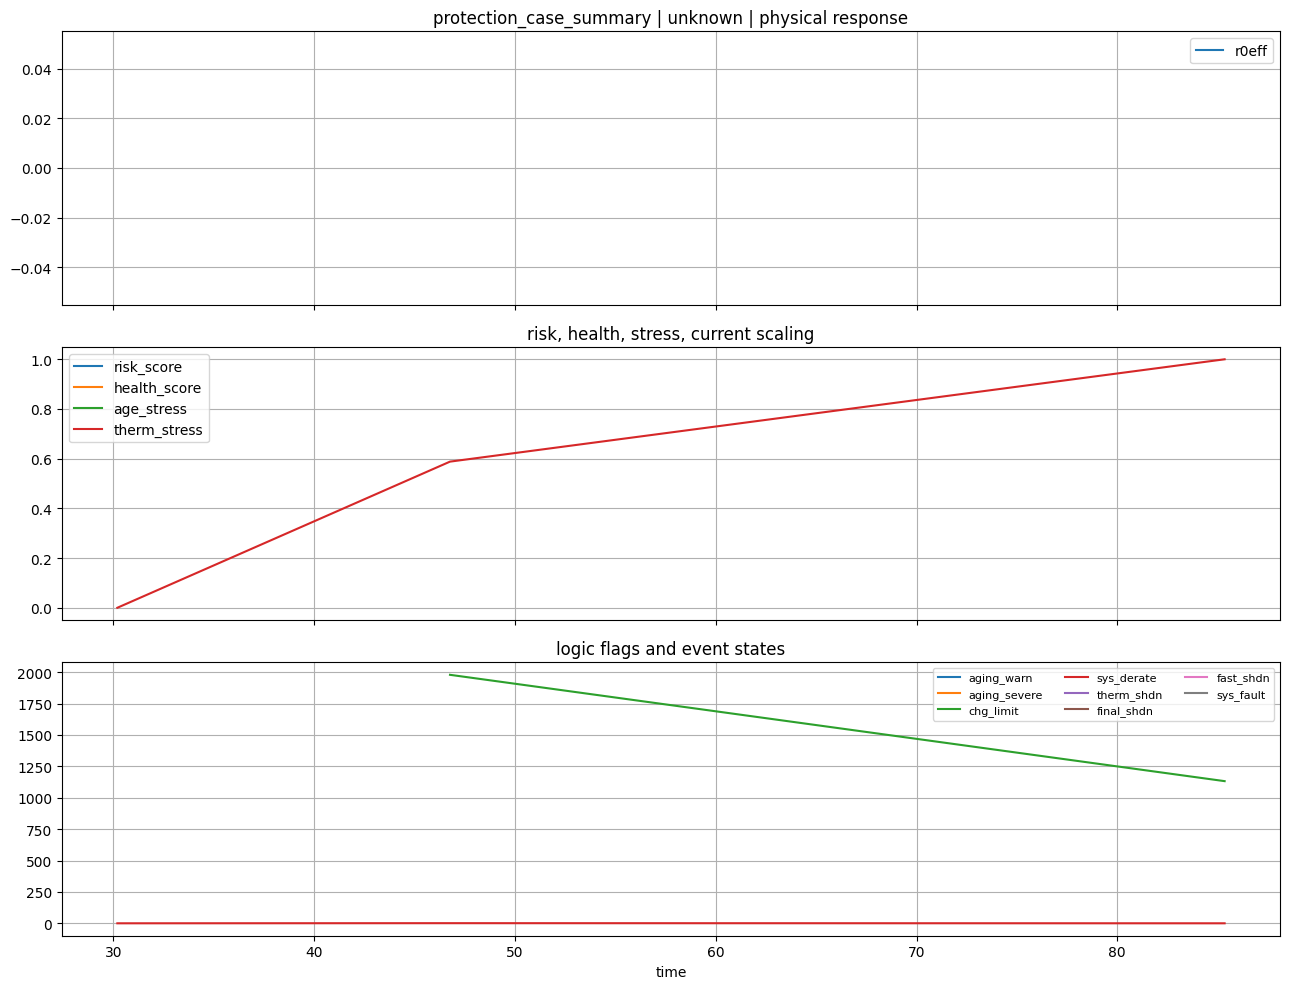

/tmp/ipykernel_55/2350115869.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_55/2350115869.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()
/tmp/ipykernel_55/2350115869.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(ncol=3, fontsize=8)


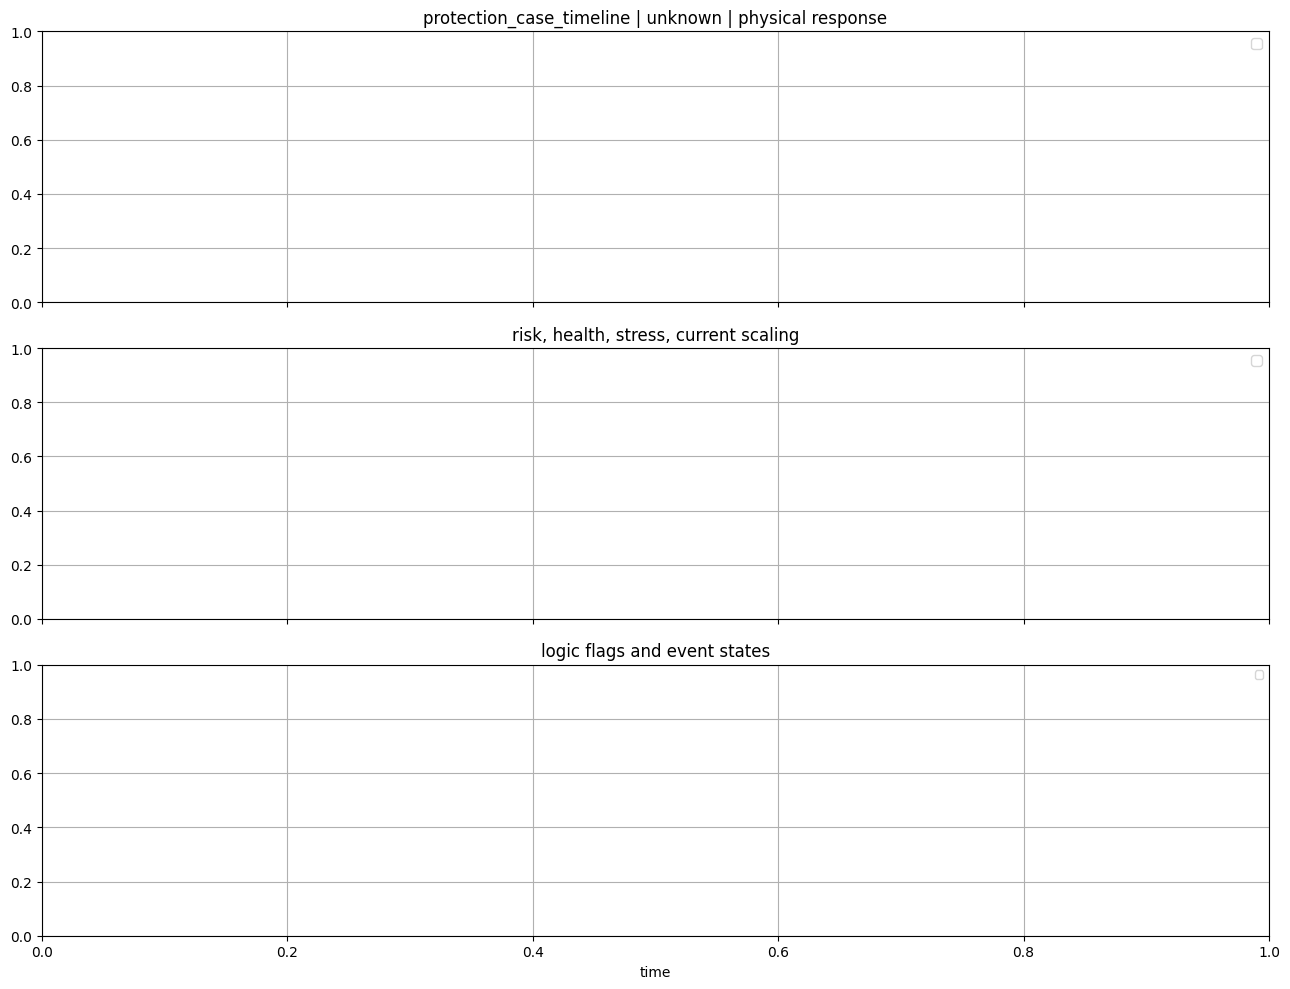

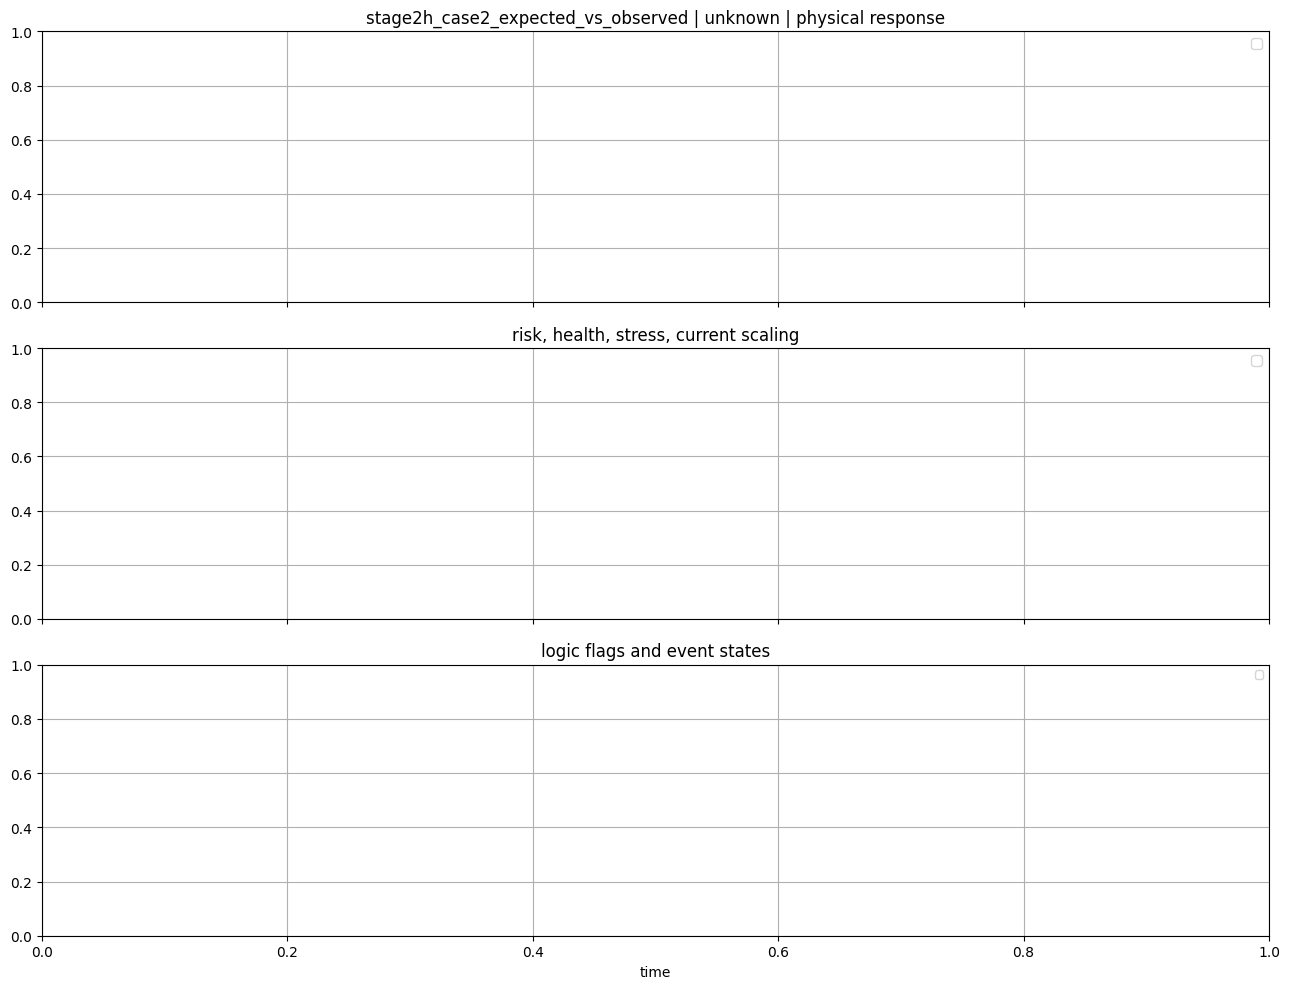

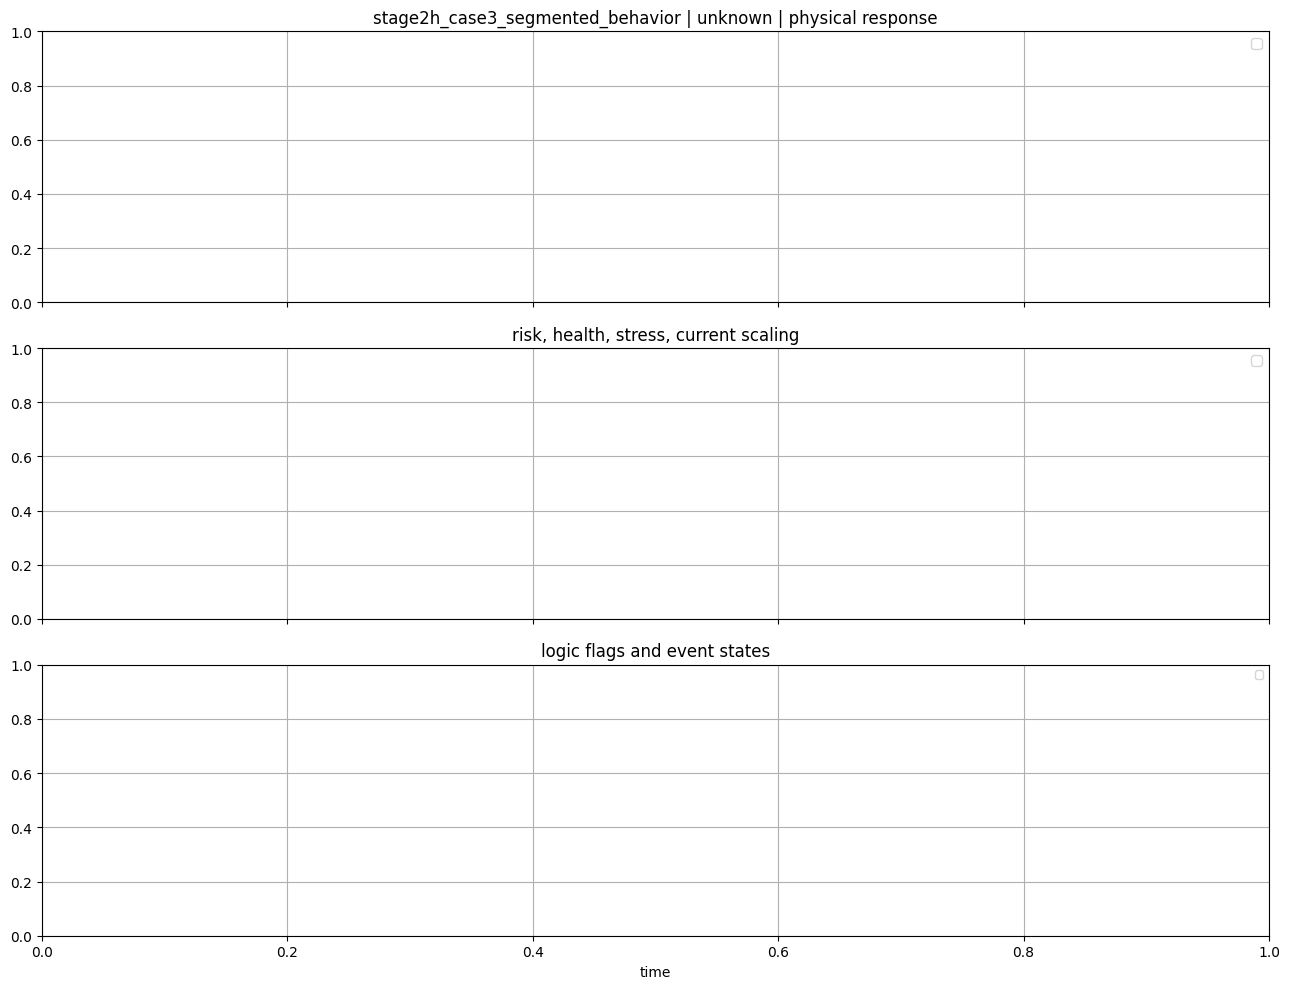

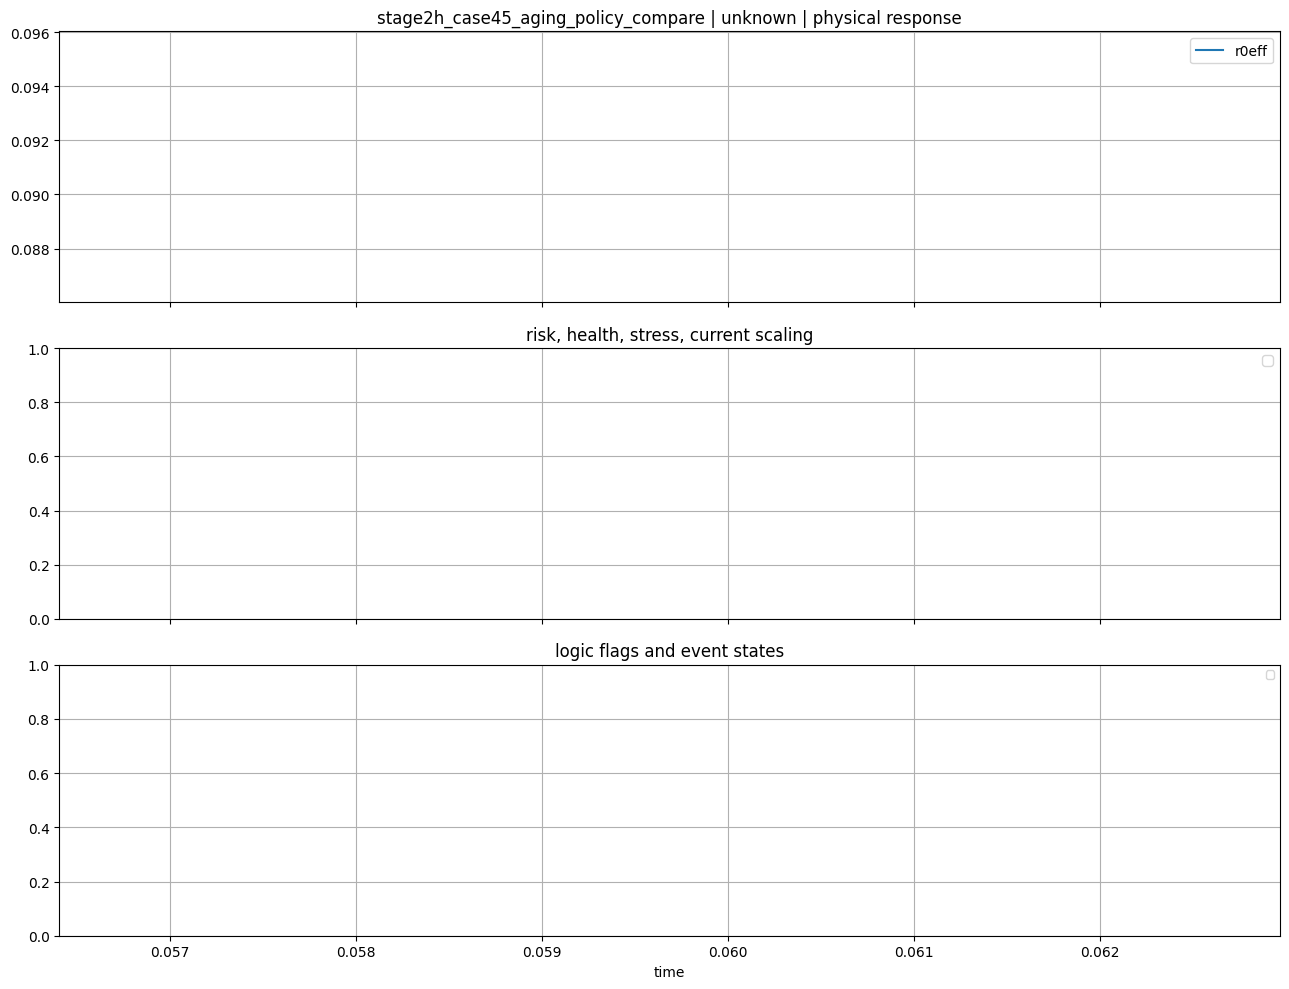

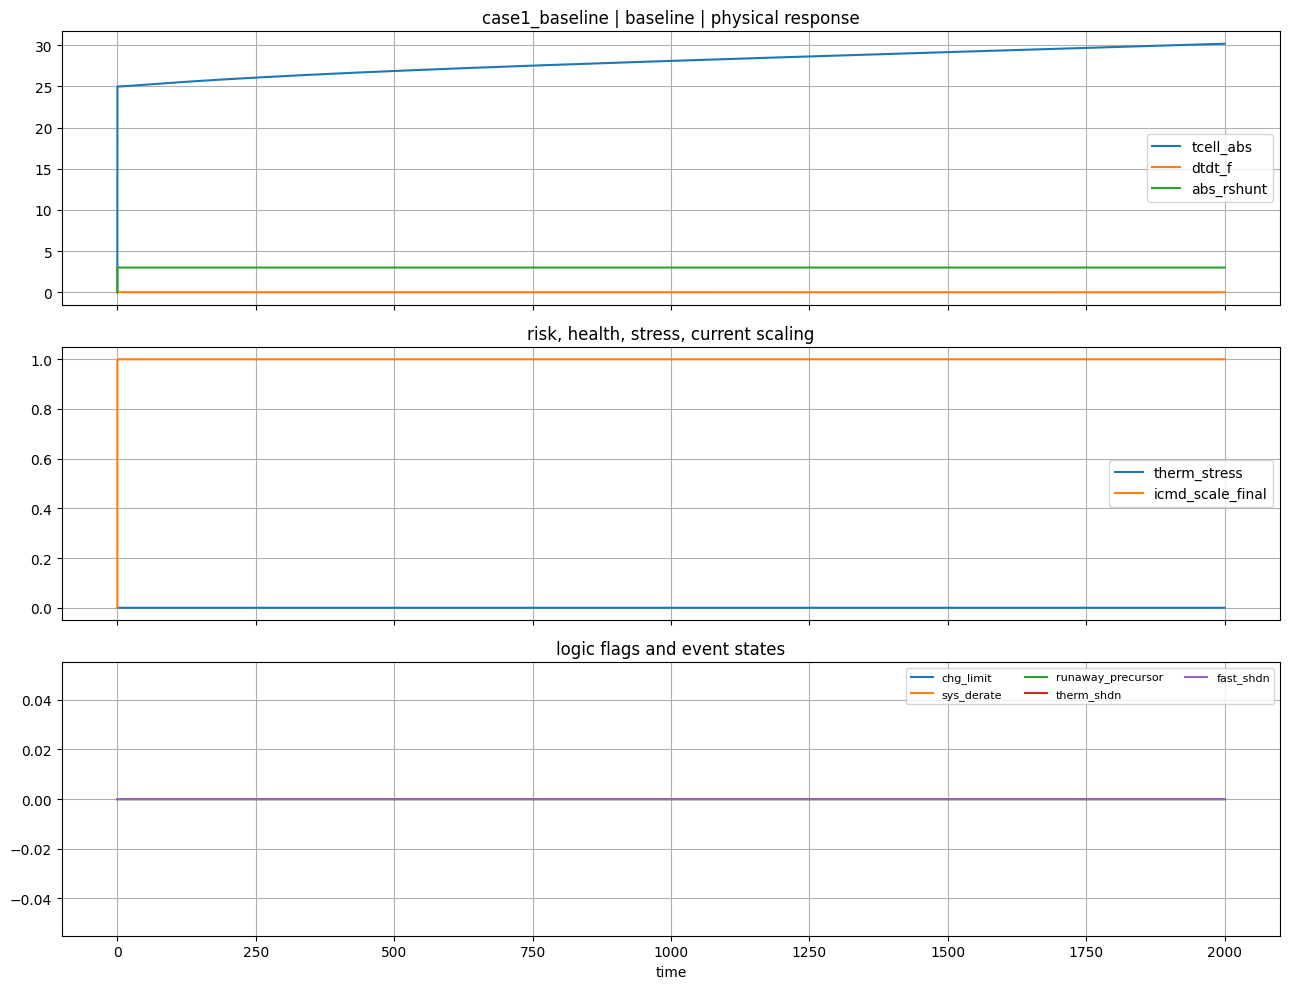

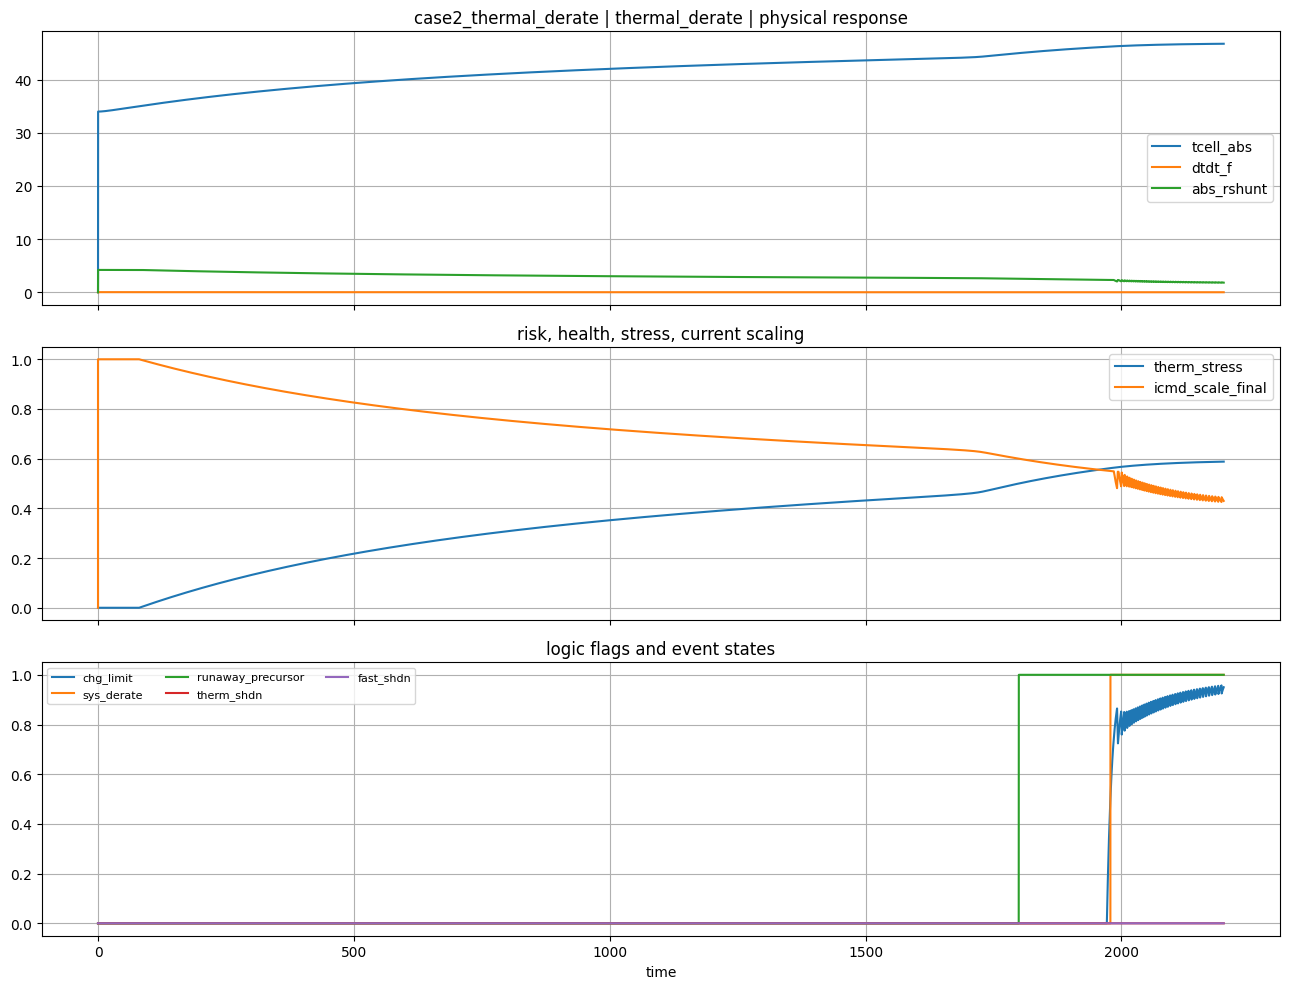

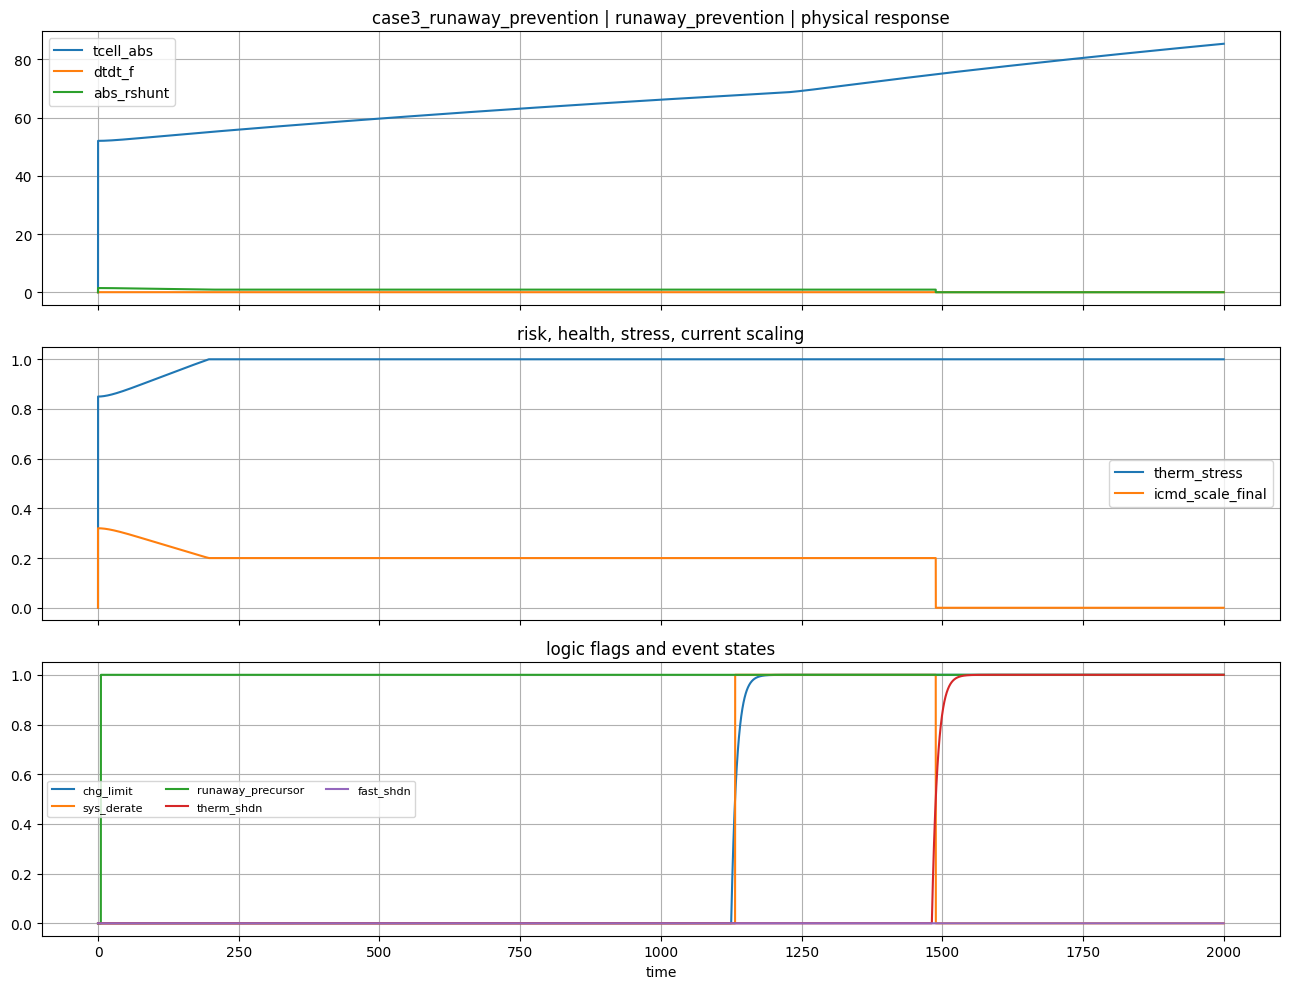

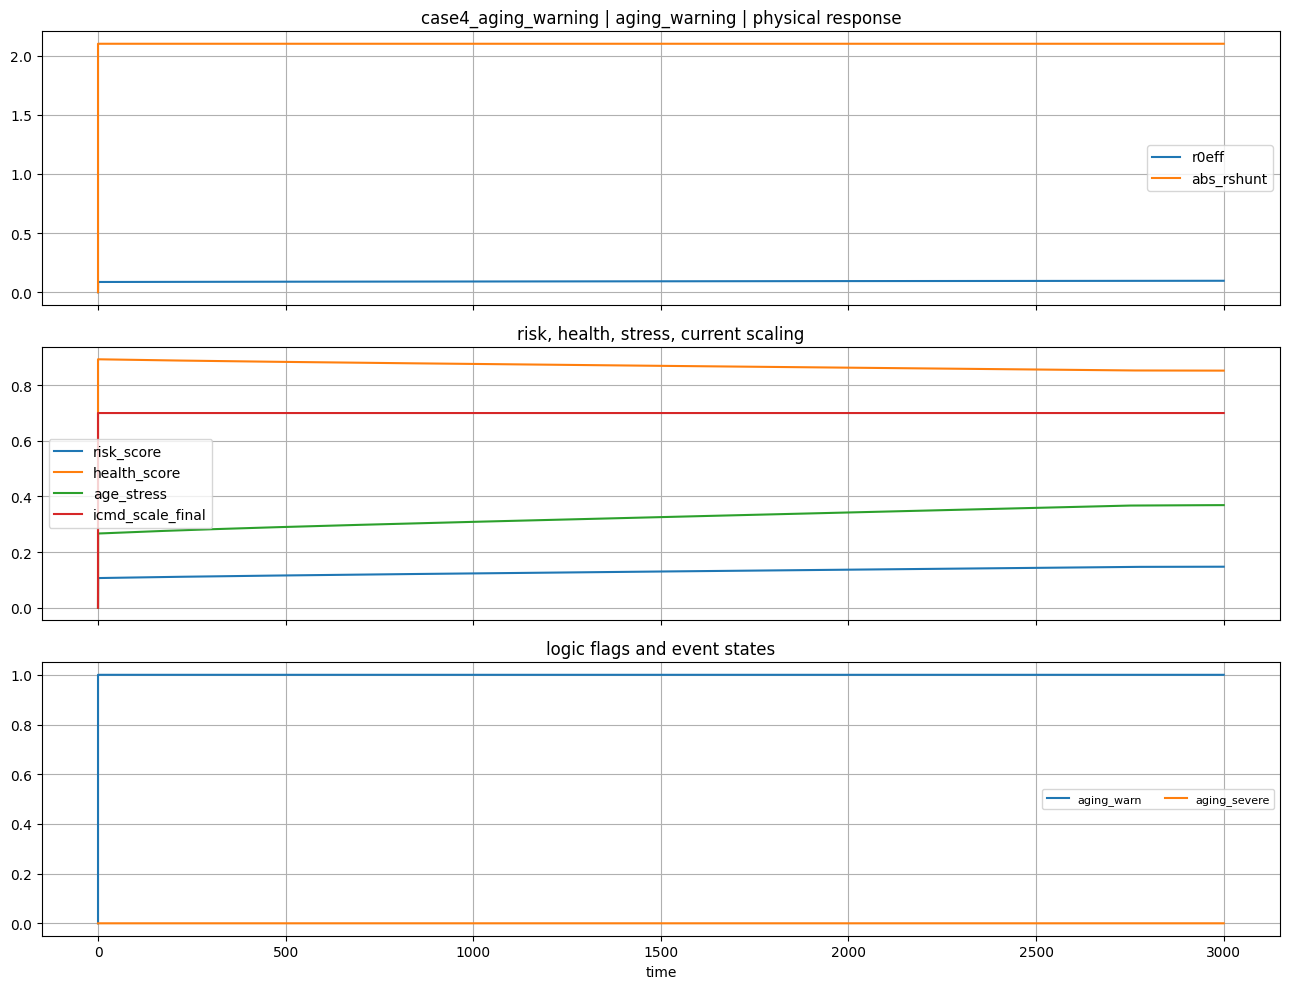

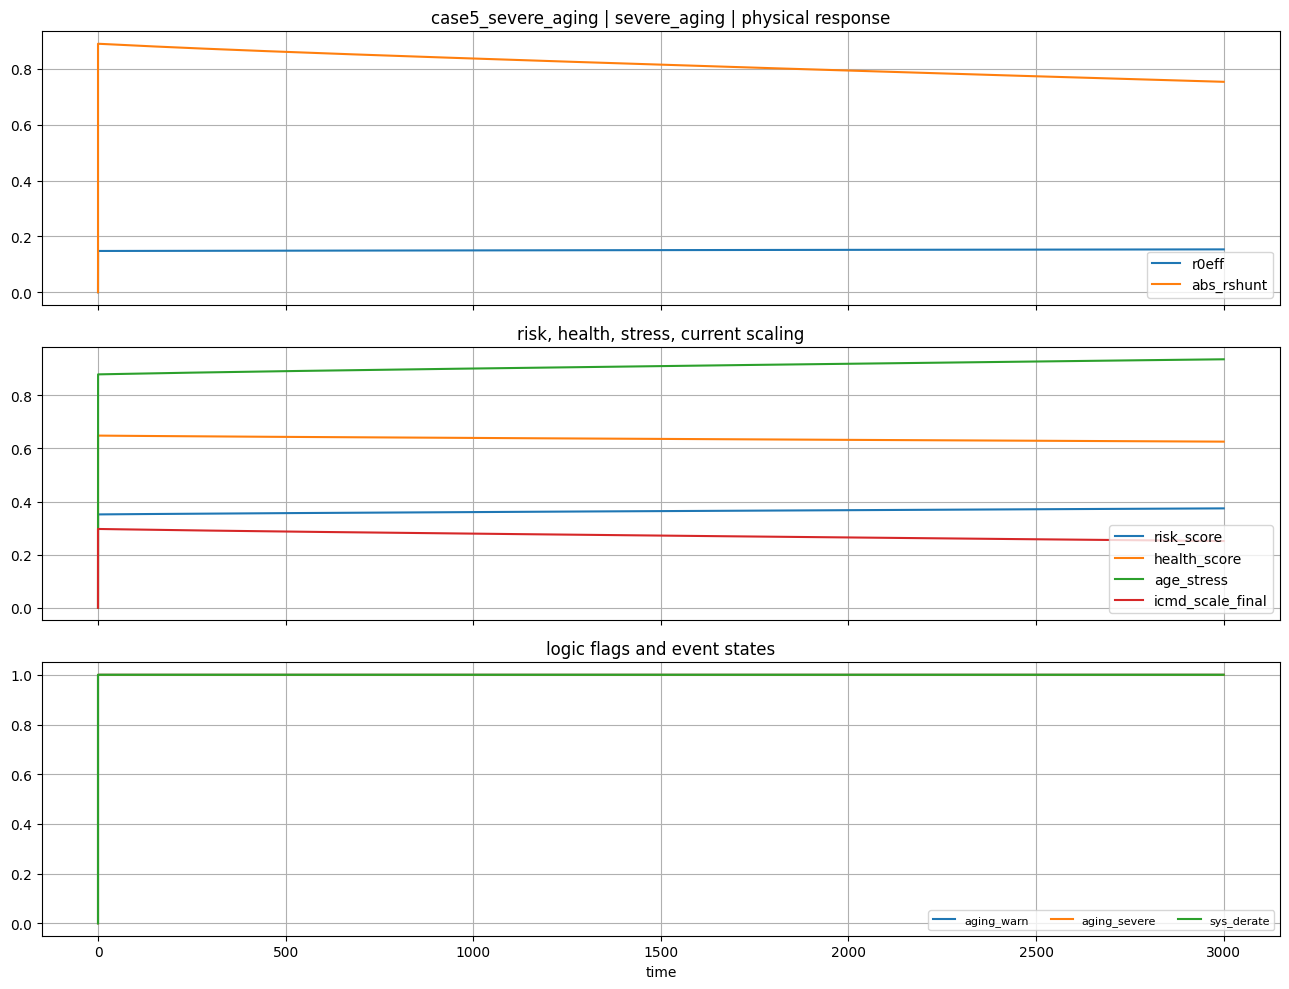

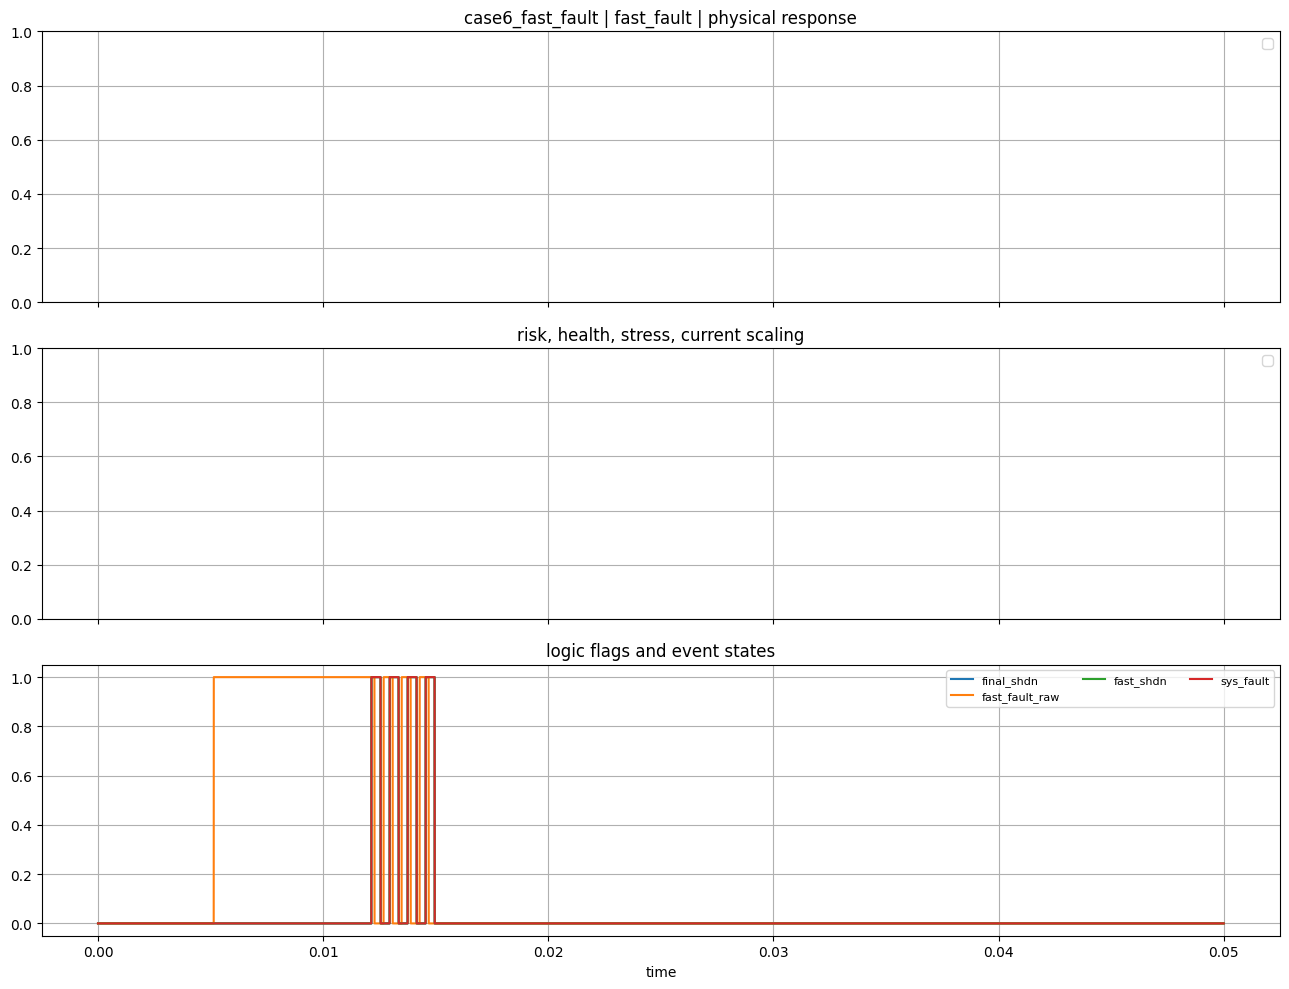

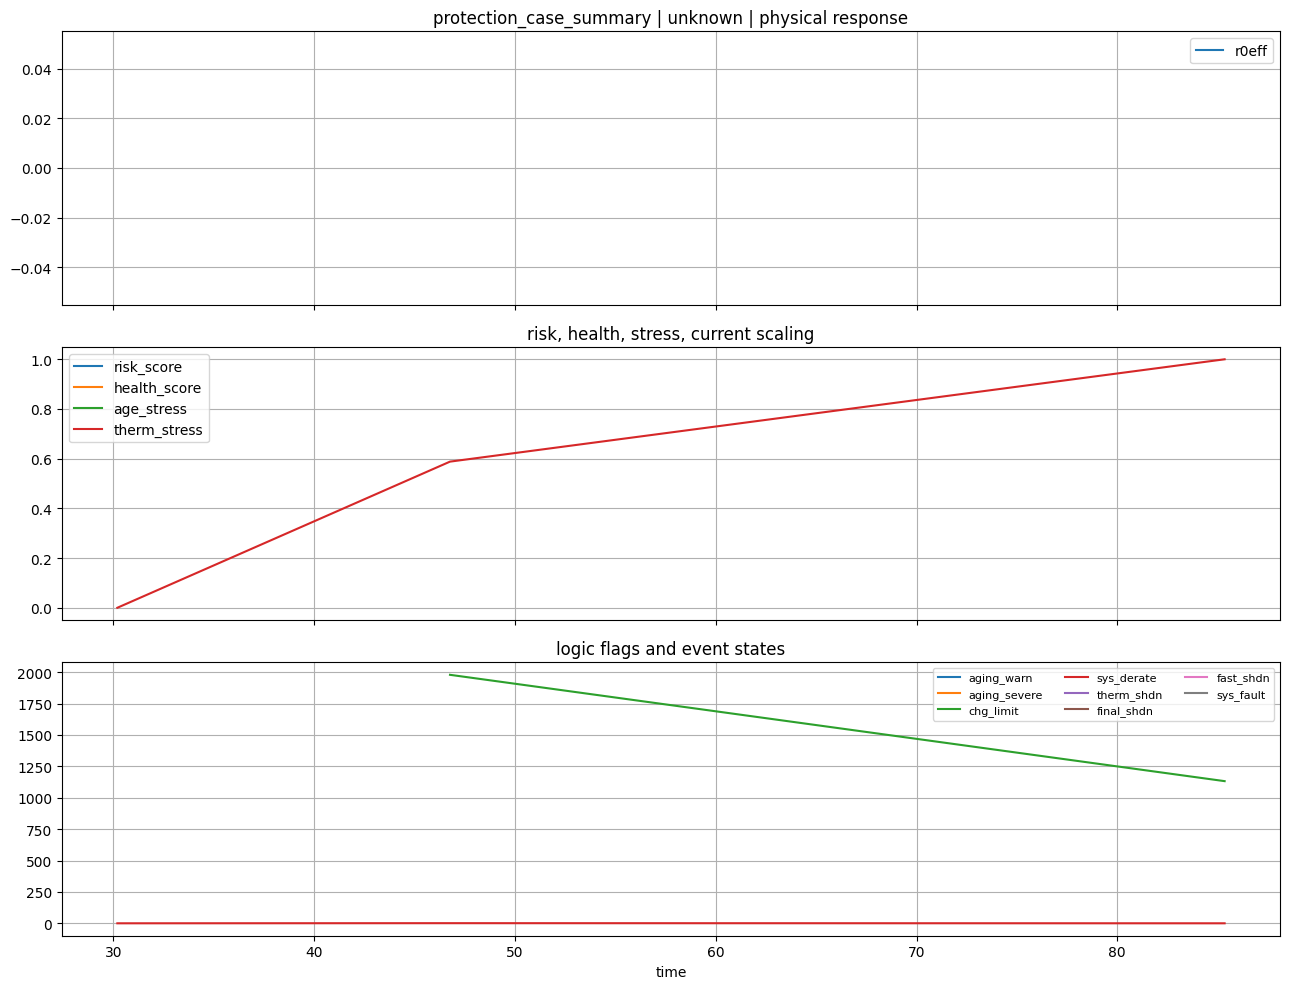

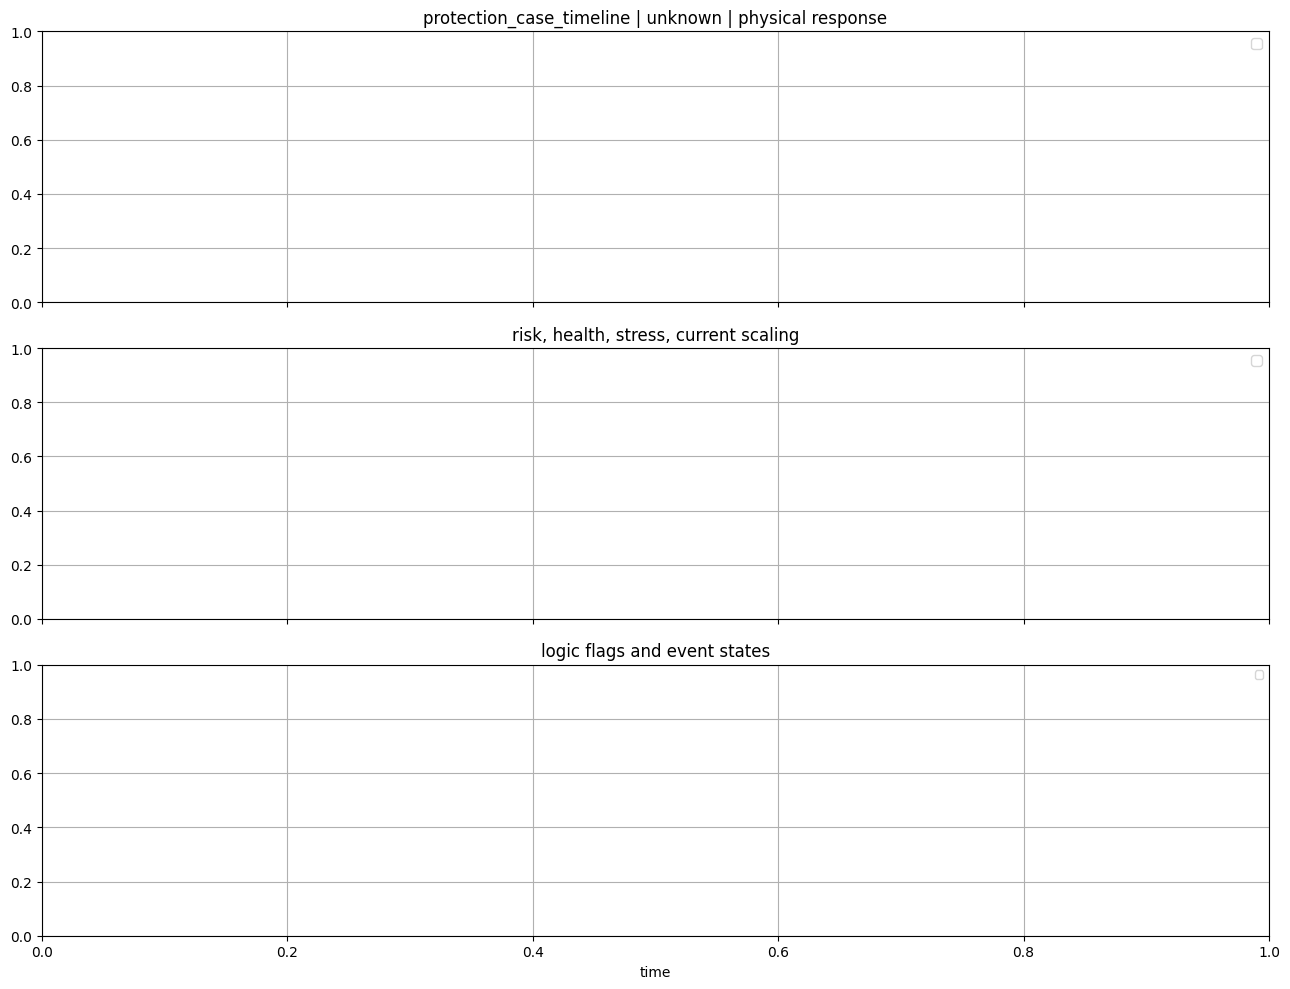

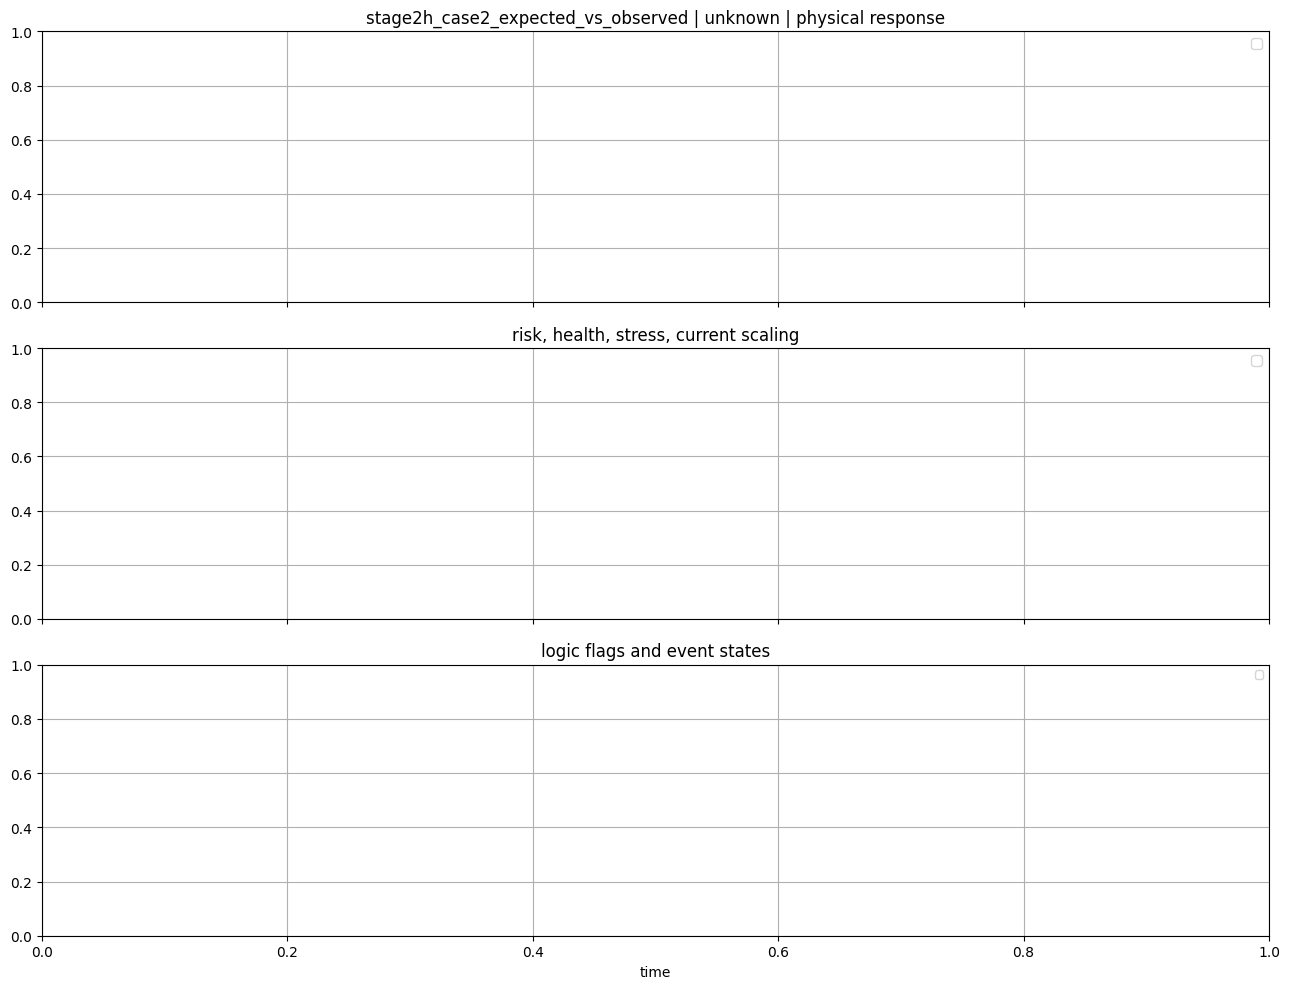

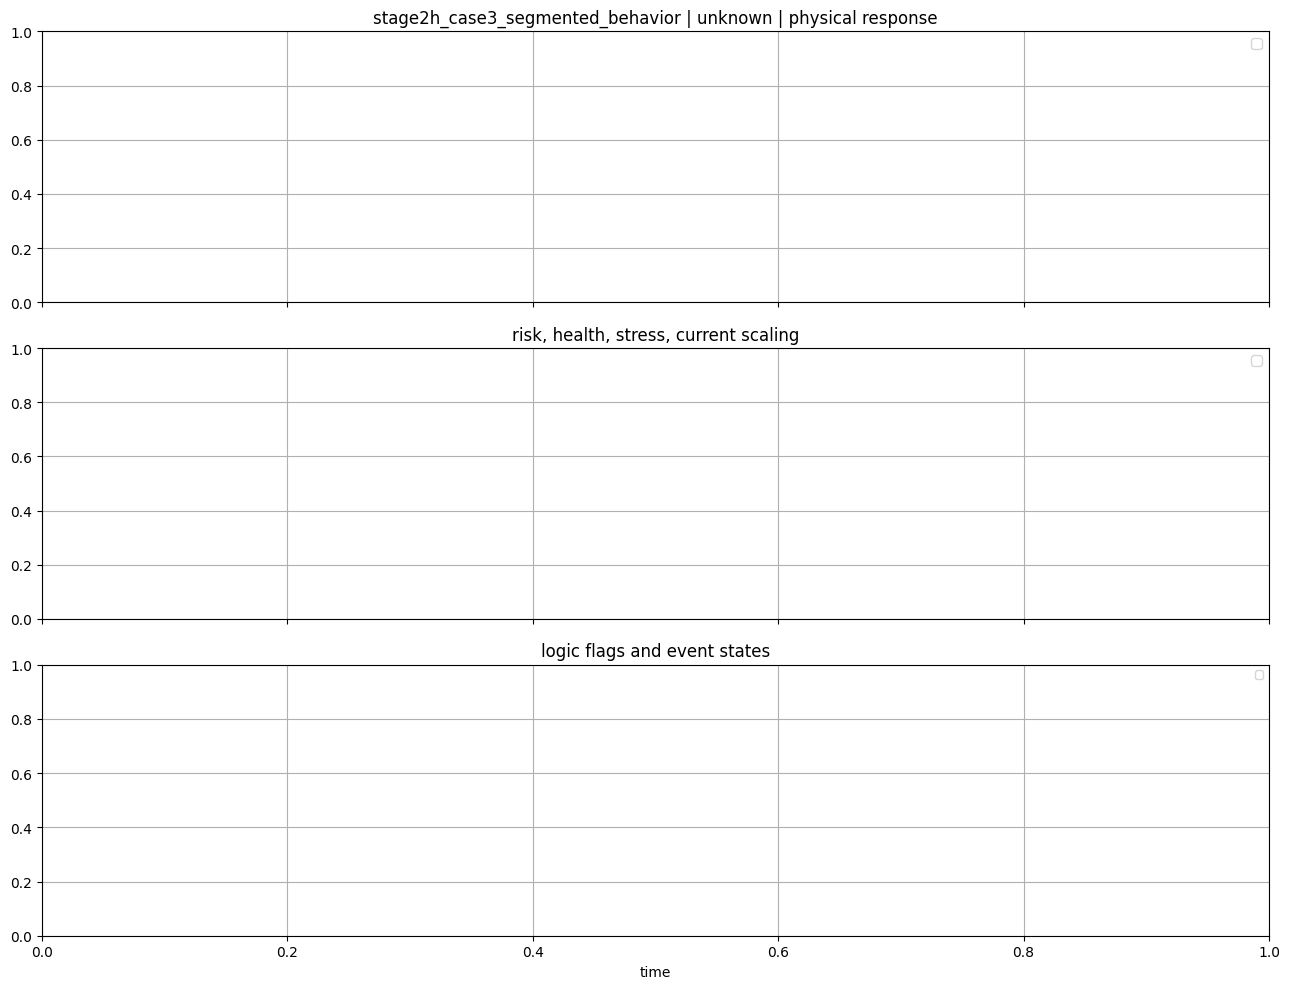

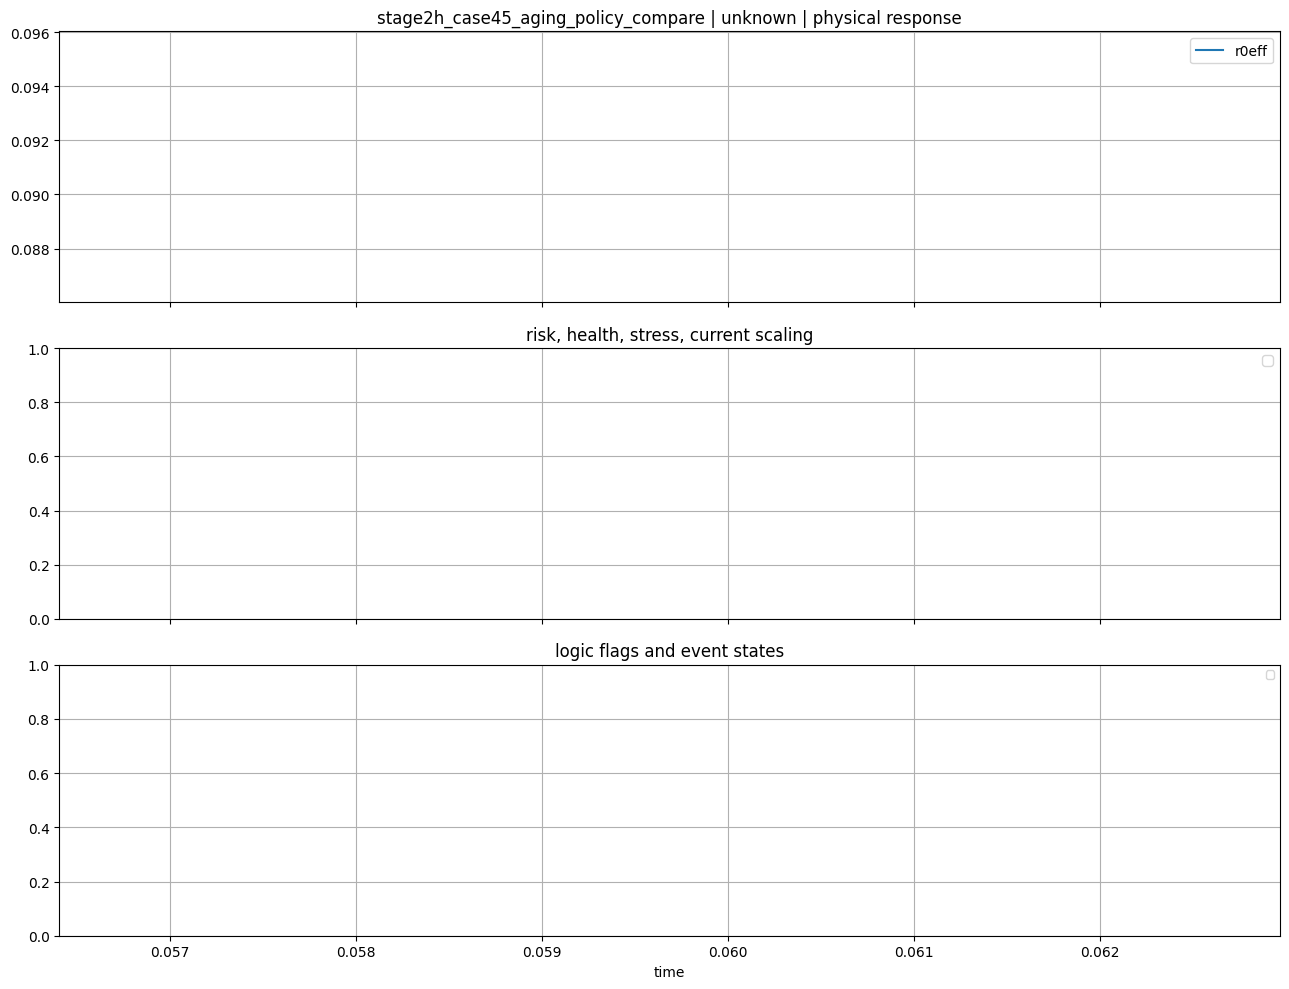

In [79]:
def plot_protection_case(path):
    df = loaded_data[path]
    case_name = case_name_from_path(path)
    scenario = scenario_from_name(case_name)

    tcol = resolve_col(df, ["time", "t", "seconds", "sec"])

    if tcol is None:
        print("TIME COLUMN NOT FOUND IN:", path)
        print(df.columns.tolist())
        return

    t = df[tcol]

    fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

    # Panel 1: physical behavior
    for aliases, label, absval in [
        (["tcell_abs"], "tcell_abs", False),
        (["dtdt_f"], "dtdt_f", False),
        (["r0eff"], "r0eff", False),
        (["rshunt"], "abs_rshunt", True),
    ]:
        col, s = get_series(df, aliases, absval=absval)
        if s is not None:
            axes[0].plot(t, s, label=label)

    axes[0].set_title(f"{case_name} | {scenario} | physical response")
    axes[0].legend()
    axes[0].grid(True)

    # Panel 2: supervisory metrics
    for aliases, label in [
        (["risk_score"], "risk_score"),
        (["health_score"], "health_score"),
        (["age_stress"], "age_stress"),
        (["therm_stress"], "therm_stress"),
        (["icmd_scale_final"], "icmd_scale_final"),
    ]:
        col, s = get_series(df, aliases)
        if s is not None:
            axes[1].plot(t, s, label=label)

    axes[1].set_title("risk, health, stress, current scaling")
    axes[1].legend()
    axes[1].grid(True)

    # Panel 3: event flags
    for aliases, label in [
        (["aging_warn"], "aging_warn"),
        (["aging_severe"], "aging_severe"),
        (["chg_limit_f", "chg_limit"], "chg_limit"),
        (["sys_derate"], "sys_derate"),
        (["runaway_precursor"], "runaway_precursor"),
        (["therm_shdn_f", "therm_shdn"], "therm_shdn"),
        (["final_shdn"], "final_shdn"),
        (["fast_fault_raw"], "fast_fault_raw"),
        (["fast_shdn"], "fast_shdn"),
        (["sys_fault"], "sys_fault"),
    ]:
        col, s = get_series(df, aliases)
        if s is not None:
            axes[2].plot(t, s, label=label)

    axes[2].set_title("logic flags and event states")
    axes[2].legend(ncol=3, fontsize=8)
    axes[2].grid(True)
    axes[2].set_xlabel("time")

    plt.tight_layout()
    plt.show()


for path in protection_files:
    plot_protection_case(path)

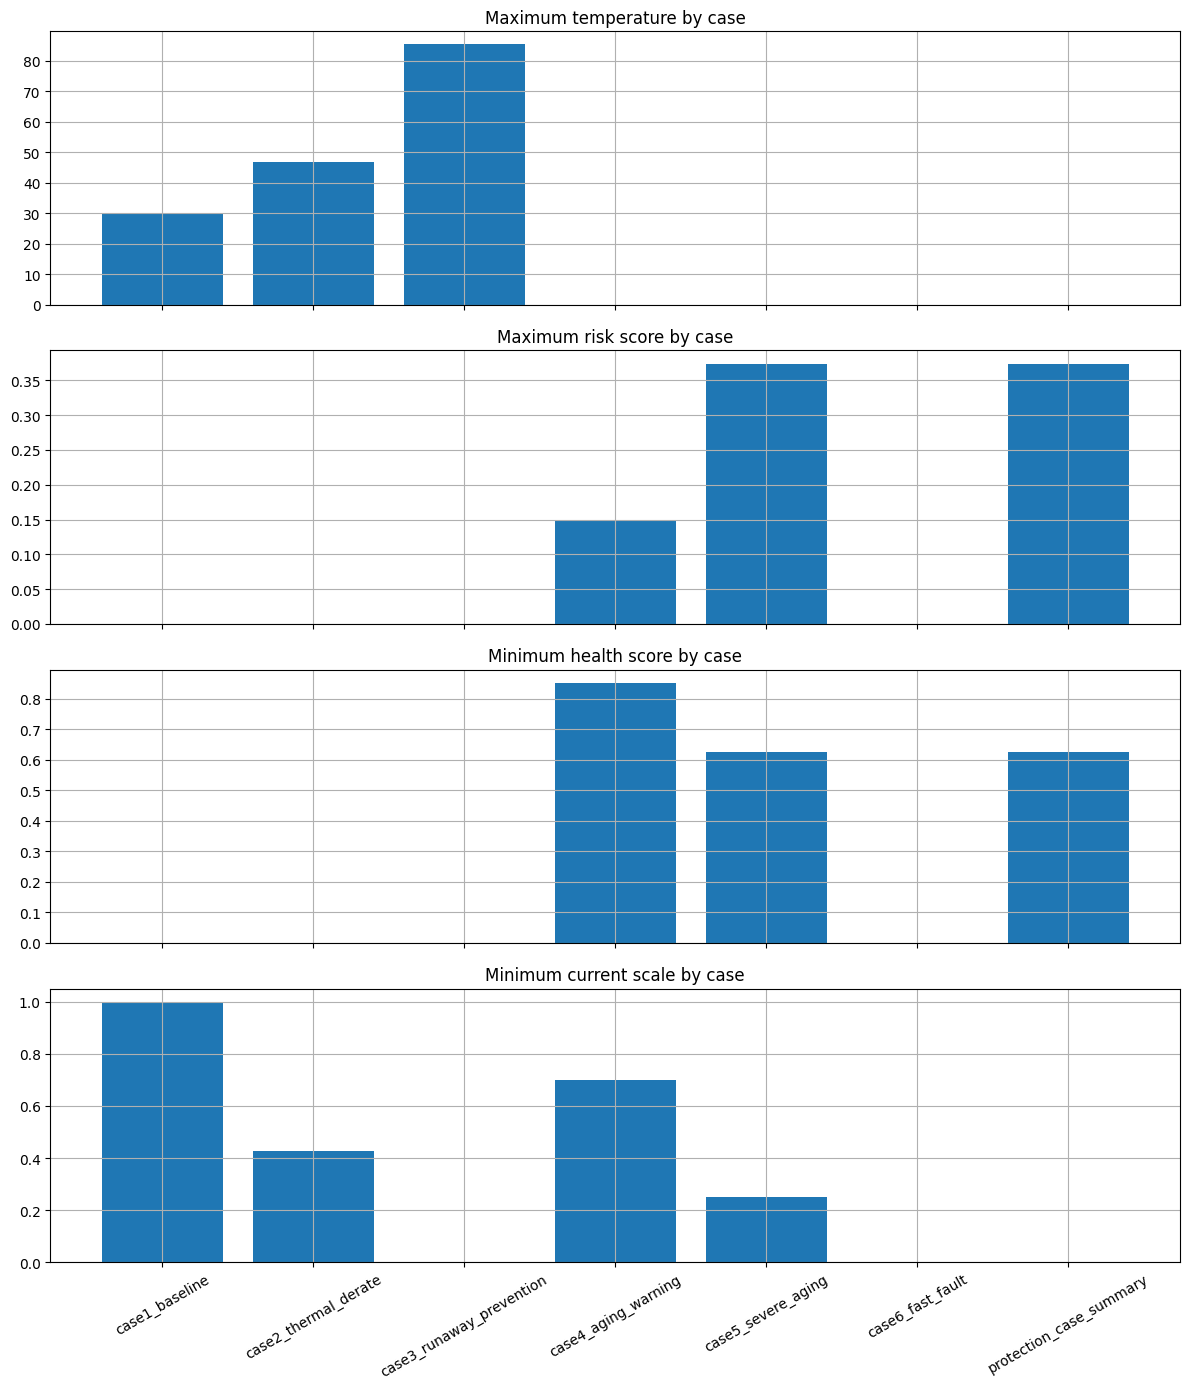

In [80]:
# Sort by case name for cleaner view
plot_df = summary_df.sort_values("case_name").reset_index(drop=True)

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

axes[0].bar(plot_df["case_name"], plot_df["temp_max"])
axes[0].set_title("Maximum temperature by case")
axes[0].grid(True)

axes[1].bar(plot_df["case_name"], plot_df["risk_score_max"])
axes[1].set_title("Maximum risk score by case")
axes[1].grid(True)

axes[2].bar(plot_df["case_name"], plot_df["health_score_min"])
axes[2].set_title("Minimum health score by case")
axes[2].grid(True)

axes[3].bar(plot_df["case_name"], plot_df["icmd_scale_min"])
axes[3].set_title("Minimum current scale by case")
axes[3].grid(True)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [81]:
summary_df.to_csv("protection_case_summary.csv", index=False)
timeline_df.to_csv("protection_case_timeline.csv", index=False)

print("Saved:")
print(" - protection_case_summary.csv")
print(" - protection_case_timeline.csv")

Saved:
 - protection_case_summary.csv
 - protection_case_timeline.csv


In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def resolve_time_col(df):
    return resolve_col(df, ["time"])

def numeric_series(df, aliases, absval=False):
    col, s = get_series(df, aliases, absval=absval)
    if s is None:
        return None, None
    return col, pd.to_numeric(s, errors="coerce")

def window_mask(t, center, left, right):
    return (t >= center - left) & (t <= center + right)

def mean_in_window(df, aliases, center, left, right, absval=False):
    tcol = resolve_time_col(df)
    if tcol is None or pd.isna(center):
        return np.nan
    _, s = numeric_series(df, aliases, absval=absval)
    if s is None:
        return np.nan
    t = pd.to_numeric(df[tcol], errors="coerce")
    m = window_mask(t, center, left, right)
    vals = s[m].dropna()
    return float(vals.mean()) if len(vals) else np.nan

def slope_in_window(df, aliases, center, left, right):
    tcol = resolve_time_col(df)
    if tcol is None or pd.isna(center):
        return np.nan
    _, s = numeric_series(df, aliases)
    if s is None:
        return np.nan

    t = pd.to_numeric(df[tcol], errors="coerce")
    m = window_mask(t, center, left, right)
    tw = t[m].to_numpy()
    yw = s[m].to_numpy()

    valid = np.isfinite(tw) & np.isfinite(yw)
    tw = tw[valid]
    yw = yw[valid]

    if len(tw) < 3:
        return np.nan

    # linear-fit slope dy/dt
    p = np.polyfit(tw, yw, 1)
    return float(p[0])

def first_valid_time(*times):
    vals = [x for x in times if pd.notna(x)]
    return min(vals) if vals else np.nan

In [83]:
advanced_rows = []

for path in protection_files:
    df = loaded_data[path]
    case_name = case_name_from_path(path)
    scenario = scenario_from_name(case_name)

    srow = summary_df.loc[summary_df["case_name"] == case_name].iloc[0]

    # choose main protection event for thermal/runaway cases
    t_derate = first_valid_time(
        srow.get("t_chg_limit", np.nan),
        srow.get("t_sys_derate", np.nan)
    )

    t_shutdown = first_valid_time(
        srow.get("t_therm_shdn", np.nan),
        srow.get("t_final_shdn", np.nan)
    )

    t_prec = srow.get("t_runaway_prec", np.nan)
    t_fast_fault = srow.get("t_fast_fault", np.nan)
    t_fast_shdn = first_valid_time(
        srow.get("t_fast_shdn", np.nan),
        srow.get("t_sys_fault", np.nan)
    )

    row = {
        "case_name": case_name,
        "scenario": scenario,

        # Safety windows
        "prec_to_derate_s": (t_derate - t_prec) if pd.notna(t_prec) and pd.notna(t_derate) else np.nan,
        "prec_to_shutdown_s": (t_shutdown - t_prec) if pd.notna(t_prec) and pd.notna(t_shutdown) else np.nan,
        "fastfault_to_shutdown_s": (t_fast_shdn - t_fast_fault) if pd.notna(t_fast_fault) and pd.notna(t_fast_shdn) else np.nan,
    }

    # Derating effectiveness around main derate event
    row["current_before_derate"] = mean_in_window(df, ["rshunt"], t_derate, left=120, right=10, absval=True)
    row["current_after_derate"]  = mean_in_window(df, ["rshunt"], t_derate, left=10, right=120, absval=True)

    row["temp_slope_before_derate"] = slope_in_window(df, ["tcell_abs"], t_derate, left=200, right=10)
    row["temp_slope_after_derate"]  = slope_in_window(df, ["tcell_abs"], t_derate, left=10, right=200)

    row["current_drop_frac"] = (
        (row["current_before_derate"] - row["current_after_derate"]) / row["current_before_derate"]
        if pd.notna(row["current_before_derate"]) and pd.notna(row["current_after_derate"]) and row["current_before_derate"] != 0
        else np.nan
    )

    row["temp_slope_reduction_frac"] = (
        (row["temp_slope_before_derate"] - row["temp_slope_after_derate"]) / row["temp_slope_before_derate"]
        if pd.notna(row["temp_slope_before_derate"]) and pd.notna(row["temp_slope_after_derate"]) and row["temp_slope_before_derate"] != 0
        else np.nan
    )

    # Shutdown behavior
    row["current_before_shutdown"] = mean_in_window(df, ["rshunt"], t_shutdown, left=80, right=5, absval=True)
    row["current_after_shutdown"]  = mean_in_window(df, ["rshunt"], t_shutdown, left=5, right=80, absval=True)

    # Severity indicator
    temp_max = srow.get("temp_max", np.nan)
    risk_max = srow.get("risk_score_max", np.nan)
    age_max  = srow.get("age_stress_max", np.nan)

    severity_score = 0.0
    if pd.notna(temp_max):
        severity_score += min(temp_max / 100.0, 1.0)
    if pd.notna(risk_max):
        severity_score += min(risk_max, 1.0)
    if pd.notna(age_max):
        severity_score += min(age_max, 1.0)

    row["severity_score"] = severity_score

    advanced_rows.append(row)

advanced_df = pd.DataFrame(advanced_rows).sort_values("case_name").reset_index(drop=True)
advanced_df

,case_name,scenario,prec_to_derate_s,prec_to_shutdown_s,fastfault_to_shutdown_s,current_before_derate,current_after_derate,temp_slope_before_derate,temp_slope_after_derate,current_drop_frac,temp_slope_reduction_frac,current_before_shutdown,current_after_shutdown,severity_score
0,case1_baseline,baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.301930
1,case2_thermal_derate,thermal_derate,179.142821,NaN,NaN,2.342750,2.064487,0.006940,0.002383,1.187764e-01,0.656615,NaN,NaN,0.467628
2,case3_runaway_prevention,runaway_prevention,1126.810311,1483.330076,NaN,0.900016,0.900016,0.011489,0.016349,-1.233559e-16,-0.423014,0.621129,0.031811,0.853465
3,case4_aging_warning,aging_warning,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.516541
4,case5_severe_aging,severe_aging,NaN,NaN,NaN,0.889477,0.888456,NaN,NaN,1.148040e-03,NaN,NaN,NaN,1.310145
5,case6_fast_fault,fast_fault,NaN,NaN,0.007002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
6,protection_case_summary,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.310145
7,protection_case_summary,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.310145
8,protection_case_timeline,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
9,protection_case_timeline,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [84]:
def behavior_comment(r):
    scenario = r["scenario"]

    if scenario == "baseline":
        return "Stable baseline; no protection action expected."

    if scenario == "thermal_derate":
        if pd.notna(r["current_drop_frac"]) and r["current_drop_frac"] > 0.2:
            return "Thermal derating reduced current meaningfully before shutdown."
        return "Thermal case detected, but current reduction should be reviewed."

    if scenario == "runaway_prevention":
        if pd.notna(r["prec_to_shutdown_s"]) and r["prec_to_shutdown_s"] > 0:
            return "Runaway precursor detected and shutdown followed after a finite safety window."
        return "Runaway case reached shutdown, but timing interpretation should be reviewed."

    if scenario == "aging_warning":
        return "Pre-aged warning case shows moderate current derating without severe-aging escalation."

    if scenario == "severe_aging":
        return "Severe aging case shows stronger current limitation and persistent derate state."

    if scenario == "fast_fault":
        if pd.notna(r["fastfault_to_shutdown_s"]):
            return "Fast-fault path reacted in milliseconds and forced shutdown quickly."
        return "Fast-fault path visible, but timing should be reviewed."

    return "No interpretation available."

behavior_df = advanced_df.copy()
behavior_df["comment"] = behavior_df.apply(behavior_comment, axis=1)

behavior_df[[
    "case_name", "scenario",
    "prec_to_derate_s", "prec_to_shutdown_s", "fastfault_to_shutdown_s",
    "current_before_derate", "current_after_derate", "current_drop_frac",
    "temp_slope_before_derate", "temp_slope_after_derate", "temp_slope_reduction_frac",
    "severity_score", "comment"
]]

,case_name,scenario,prec_to_derate_s,prec_to_shutdown_s,fastfault_to_shutdown_s,current_before_derate,current_after_derate,current_drop_frac,temp_slope_before_derate,temp_slope_after_derate,temp_slope_reduction_frac,severity_score,comment
0,case1_baseline,baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.301930,Stable baseline; no protection action expected.
1,case2_thermal_derate,thermal_derate,179.142821,NaN,NaN,2.342750,2.064487,1.187764e-01,0.006940,0.002383,0.656615,0.467628,"Thermal case detected, but current reduction s..."
2,case3_runaway_prevention,runaway_prevention,1126.810311,1483.330076,NaN,0.900016,0.900016,-1.233559e-16,0.011489,0.016349,-0.423014,0.853465,Runaway precursor detected and shutdown follow...
3,case4_aging_warning,aging_warning,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.516541,Pre-aged warning case shows moderate current d...
4,case5_severe_aging,severe_aging,NaN,NaN,NaN,0.889477,0.888456,1.148040e-03,NaN,NaN,NaN,1.310145,Severe aging case shows stronger current limit...
5,case6_fast_fault,fast_fault,NaN,NaN,0.007002,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,Fast-fault path reacted in milliseconds and fo...
6,protection_case_summary,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.310145,No interpretation available.
7,protection_case_summary,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.310145,No interpretation available.
8,protection_case_timeline,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,No interpretation available.
9,protection_case_timeline,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,No interpretation available.


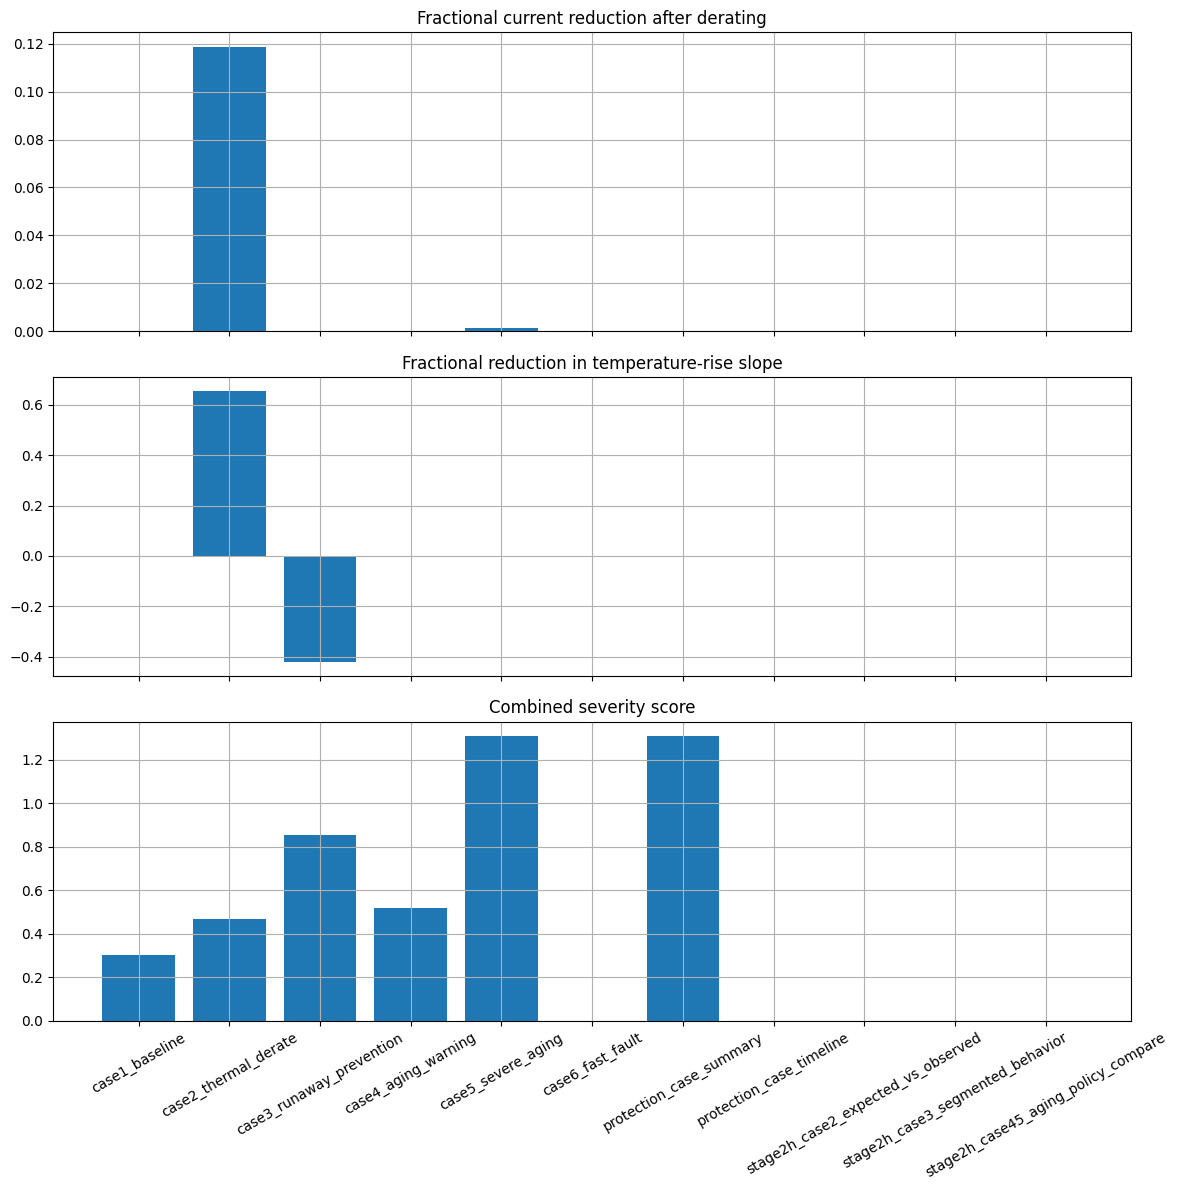

In [85]:
plot_df = advanced_df.copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].bar(plot_df["case_name"], plot_df["current_drop_frac"])
axes[0].set_title("Fractional current reduction after derating")
axes[0].grid(True)

axes[1].bar(plot_df["case_name"], plot_df["temp_slope_reduction_frac"])
axes[1].set_title("Fractional reduction in temperature-rise slope")
axes[1].grid(True)

axes[2].bar(plot_df["case_name"], plot_df["severity_score"])
axes[2].set_title("Combined severity score")
axes[2].grid(True)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [86]:
advanced_df.to_csv("protection_advanced_metrics.csv", index=False)
behavior_df.to_csv("protection_behavior_interpretation.csv", index=False)

print("Saved:")
print(" - protection_advanced_metrics.csv")
print(" - protection_behavior_interpretation.csv")

Saved:
 - protection_advanced_metrics.csv
 - protection_behavior_interpretation.csv


In [87]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- helpers ----------
def get_time_series(df):
    tcol = resolve_col(df, ["time"])
    if tcol is None:
        return None
    return pd.to_numeric(df[tcol], errors="coerce")

def safe_signal(df, aliases, absval=False):
    col, s = get_series(df, aliases, absval=absval)
    if s is None:
        return None, None
    s = pd.to_numeric(s, errors="coerce")
    return col, s

def summary_row_for_case(case_name):
    row = summary_df.loc[summary_df["case_name"] == case_name]
    if len(row) == 0:
        return None
    return row.iloc[0]

def advanced_row_for_case(case_name):
    row = advanced_df.loc[advanced_df["case_name"] == case_name]
    if len(row) == 0:
        return None
    return row.iloc[0]

def collect_case_events(case_name):
    srow = summary_row_for_case(case_name)
    if srow is None:
        return {}

    event_map = {
        "precursor": first_valid_time(
            srow.get("t_runaway_prec", np.nan)
        ),
        "derate": first_valid_time(
            srow.get("t_chg_limit", np.nan),
            srow.get("t_sys_derate", np.nan)
        ),
        "thermal_shutdown": first_valid_time(
            srow.get("t_therm_shdn", np.nan)
        ),
        "final_shutdown": first_valid_time(
            srow.get("t_final_shdn", np.nan)
        ),
        "aging_warn": first_valid_time(
            srow.get("t_aging_warn", np.nan)
        ),
        "aging_severe": first_valid_time(
            srow.get("t_aging_severe", np.nan)
        ),
        "fast_fault": first_valid_time(
            srow.get("t_fast_fault", np.nan)
        ),
        "fast_shutdown": first_valid_time(
            srow.get("t_fast_shdn", np.nan),
            srow.get("t_sys_fault", np.nan)
        ),
    }

    # remove NaNs
    event_map = {k: v for k, v in event_map.items() if pd.notna(v)}
    return event_map

EVENT_COLORS = {
    "precursor": "orange",
    "derate": "red",
    "thermal_shutdown": "purple",
    "final_shutdown": "black",
    "aging_warn": "orange",
    "aging_severe": "red",
    "fast_fault": "red",
    "fast_shutdown": "black",
}

def add_event_lines(ax, events):
    for name, t in events.items():
        ax.axvline(t, linestyle="--", linewidth=1.2, color=EVENT_COLORS.get(name, "gray"), alpha=0.8)
    return ax

def add_legend_if_any(ax, **kwargs):
    handles, labels = ax.get_legend_handles_labels()
    if len(handles) > 0:
        ax.legend(**kwargs)

Skipping protection_case_summary: no time column found


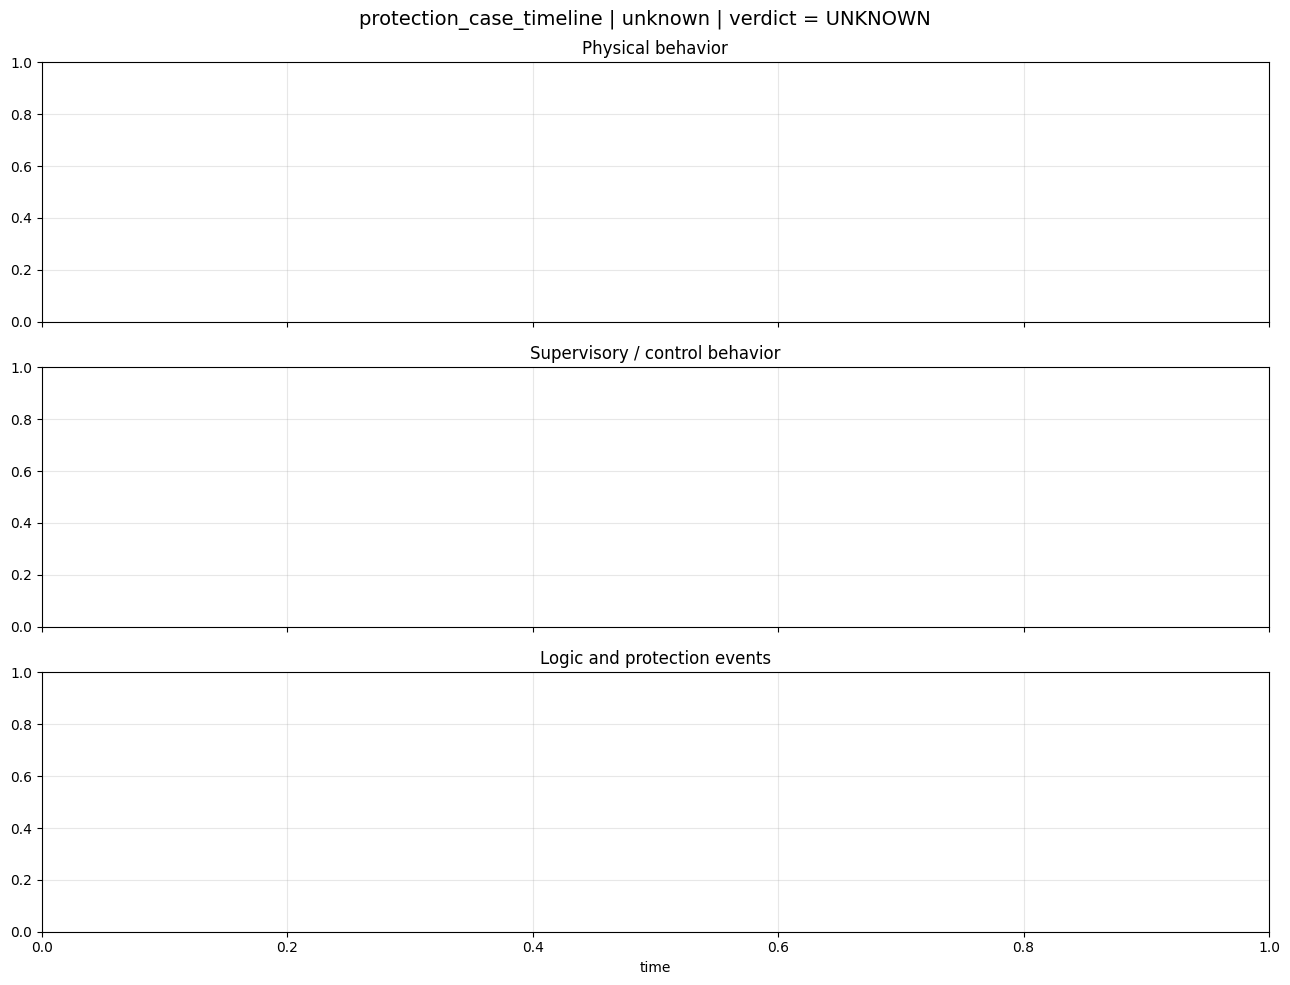

Skipping stage2h_case2_expected_vs_observed: no time column found
Skipping stage2h_case3_segmented_behavior: no time column found
Skipping stage2h_case45_aging_policy_compare: no time column found


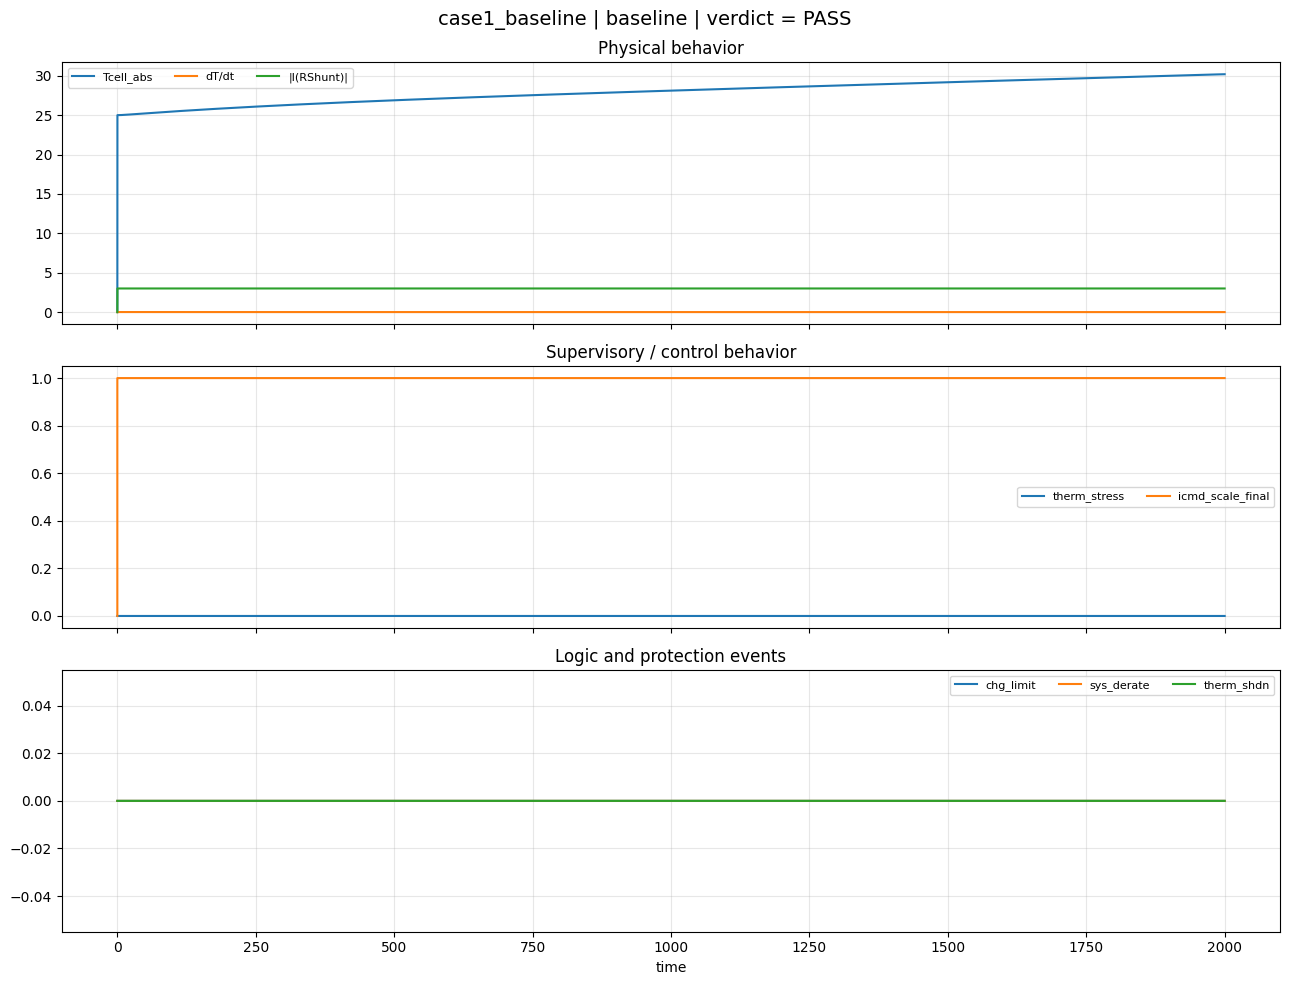

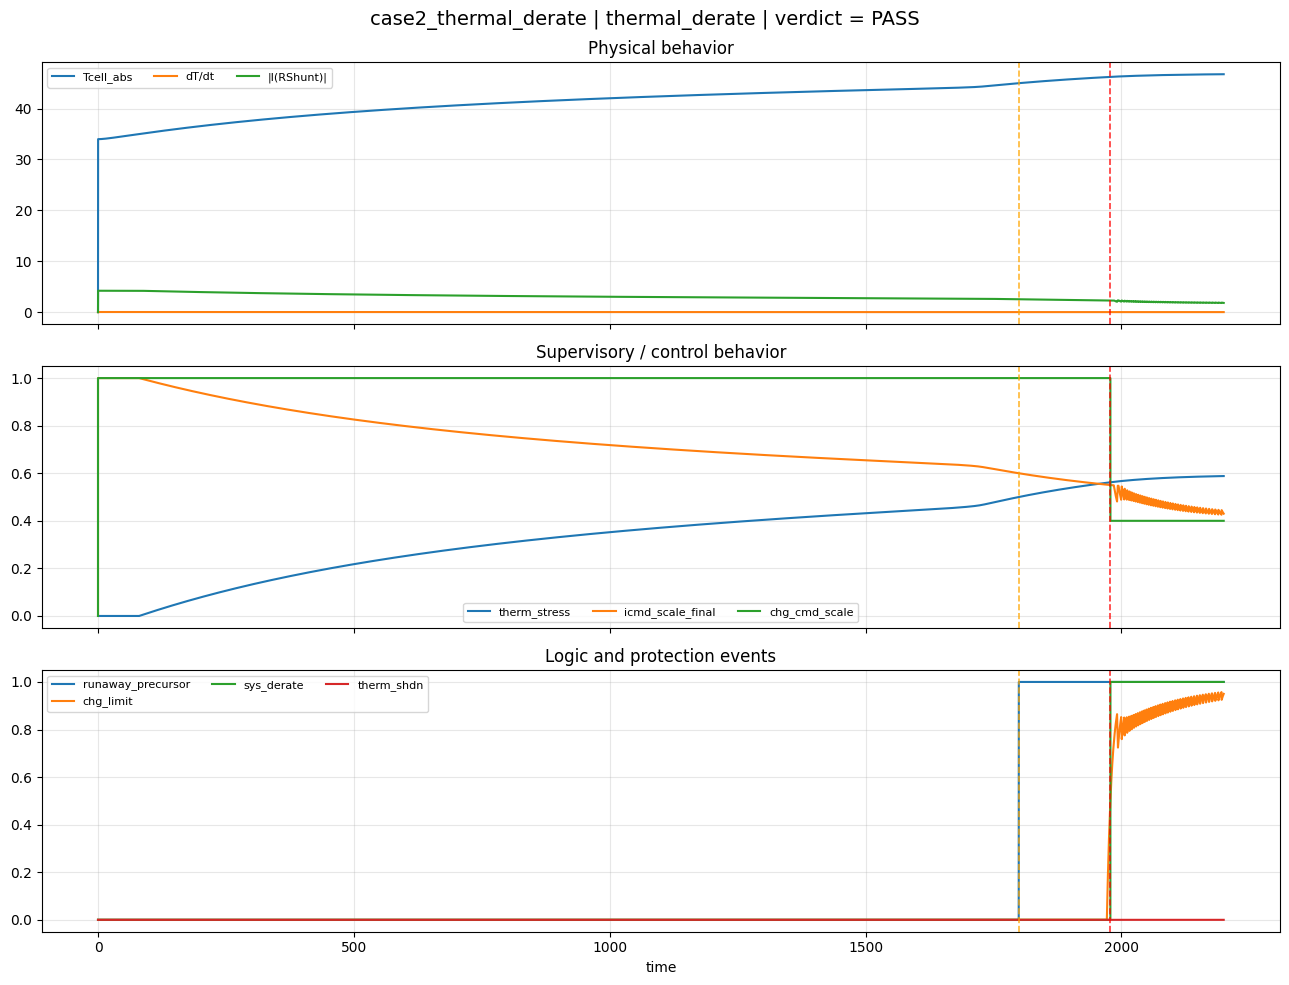

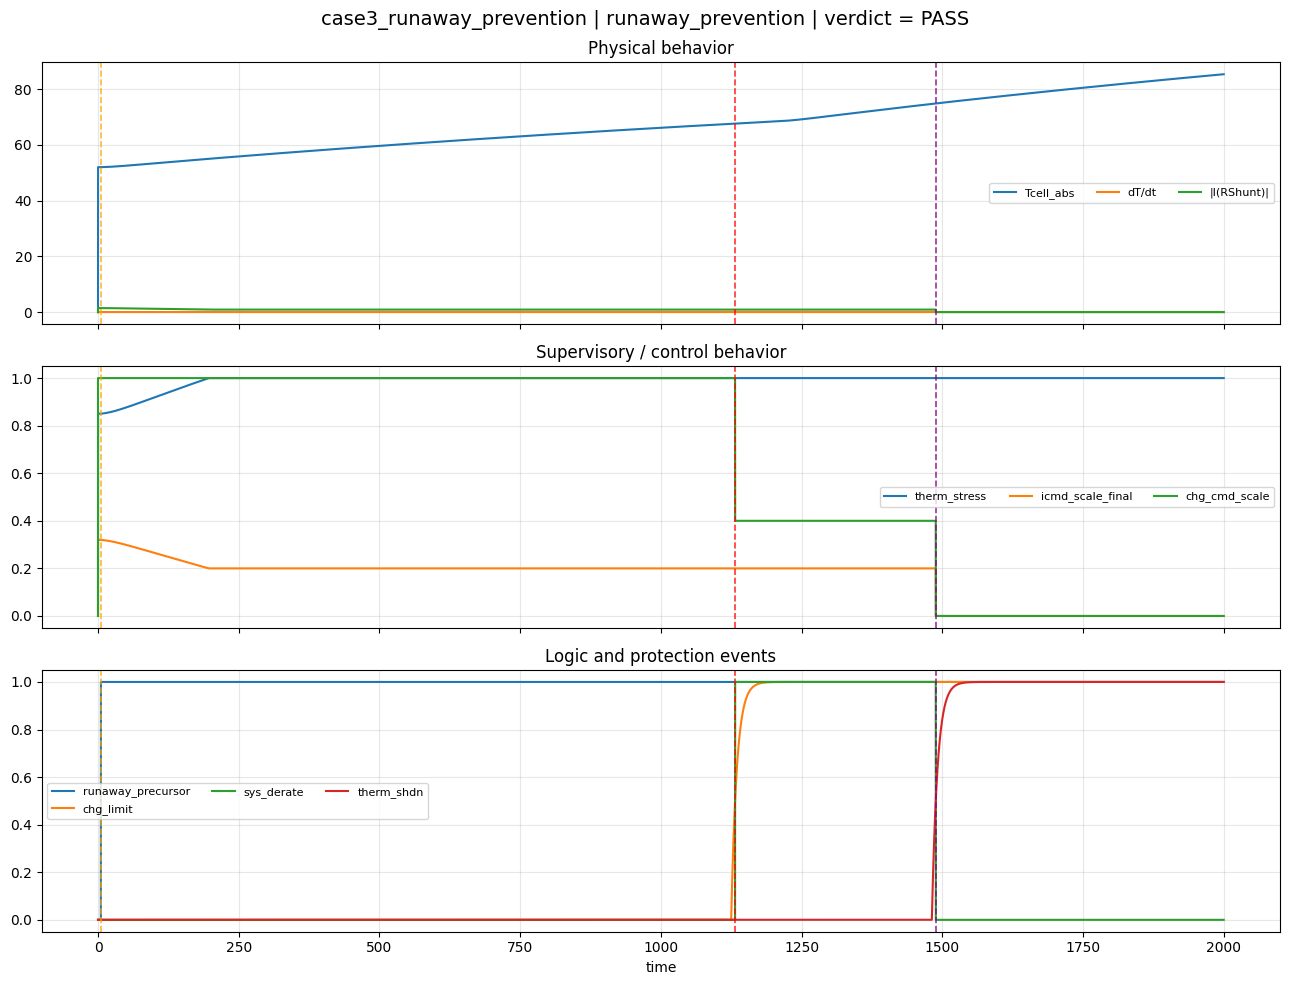

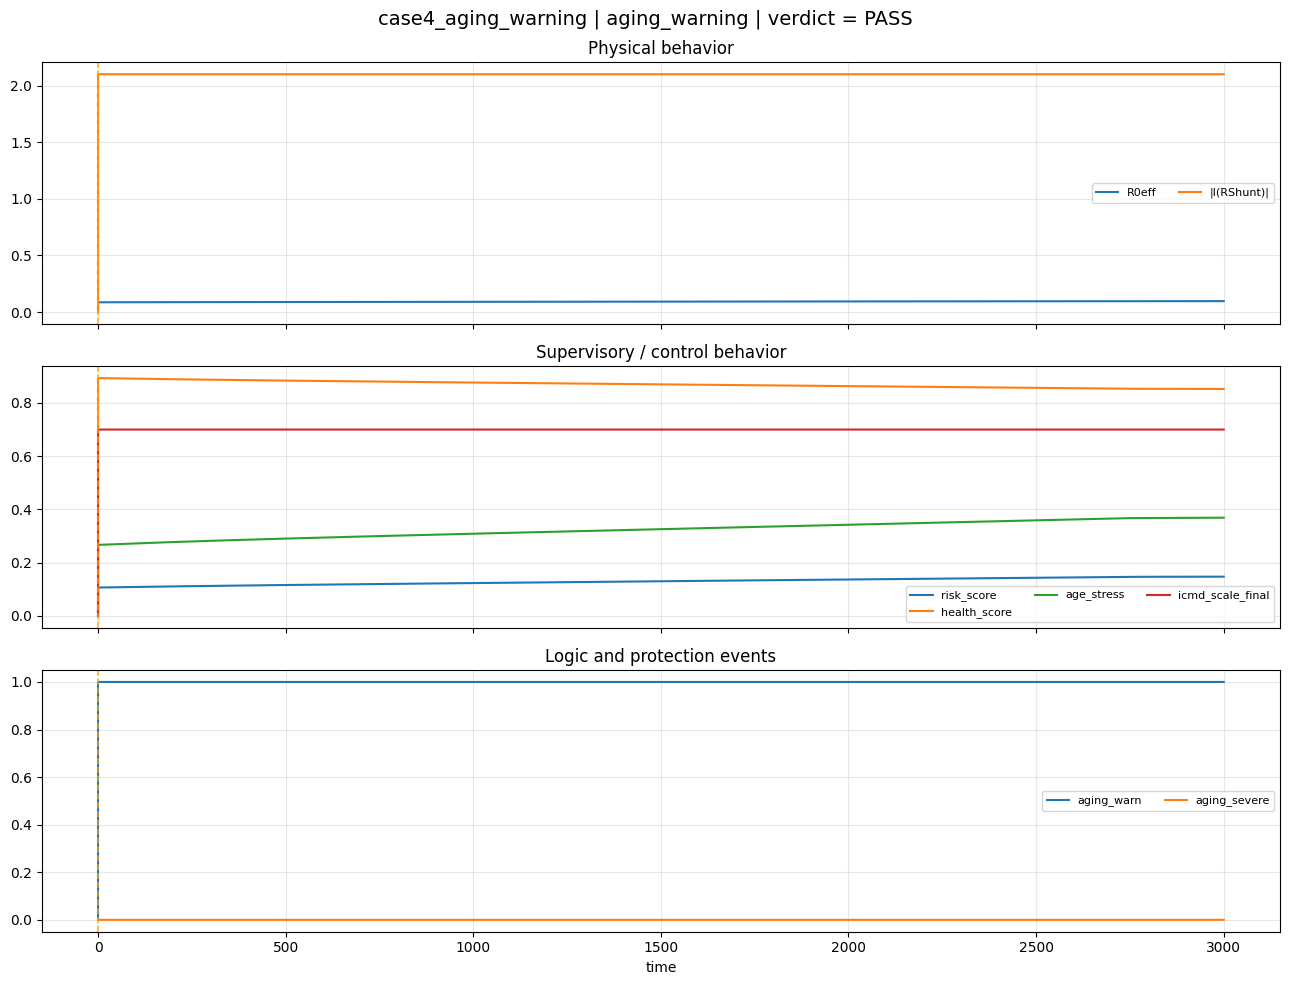

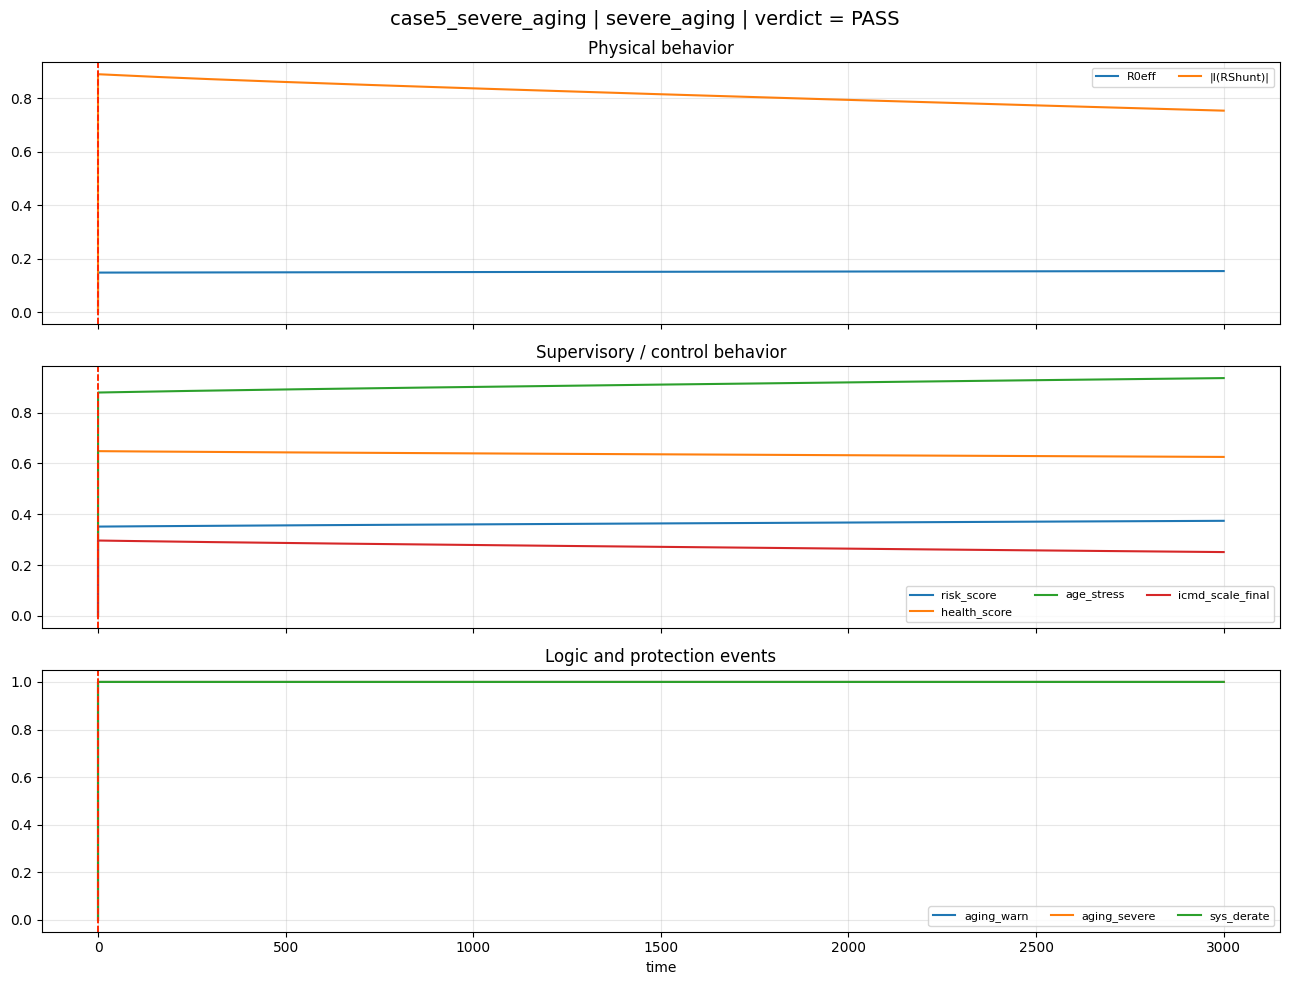

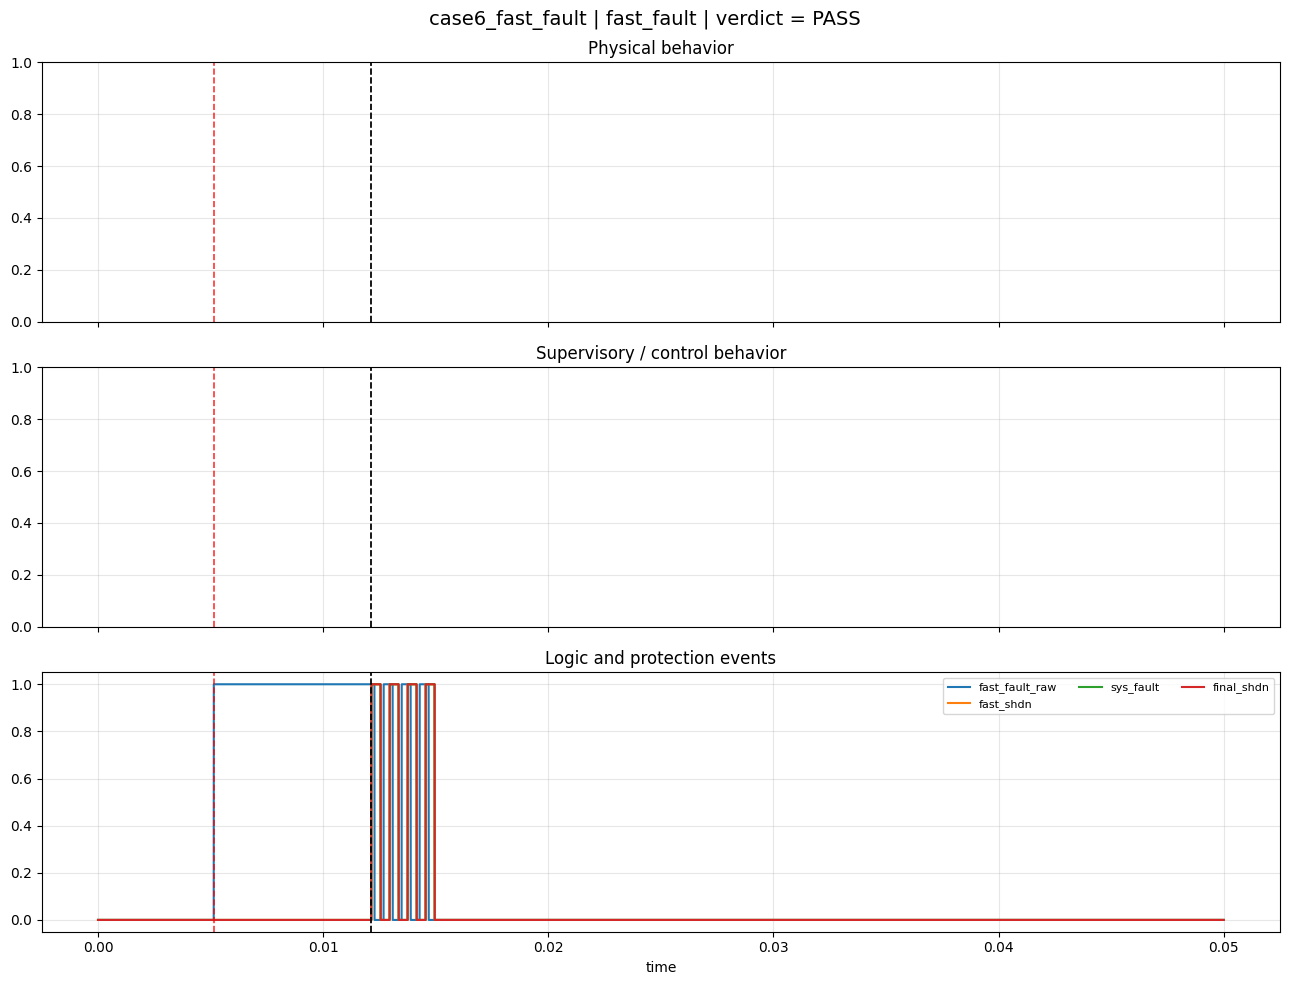

Skipping protection_case_summary: no time column found


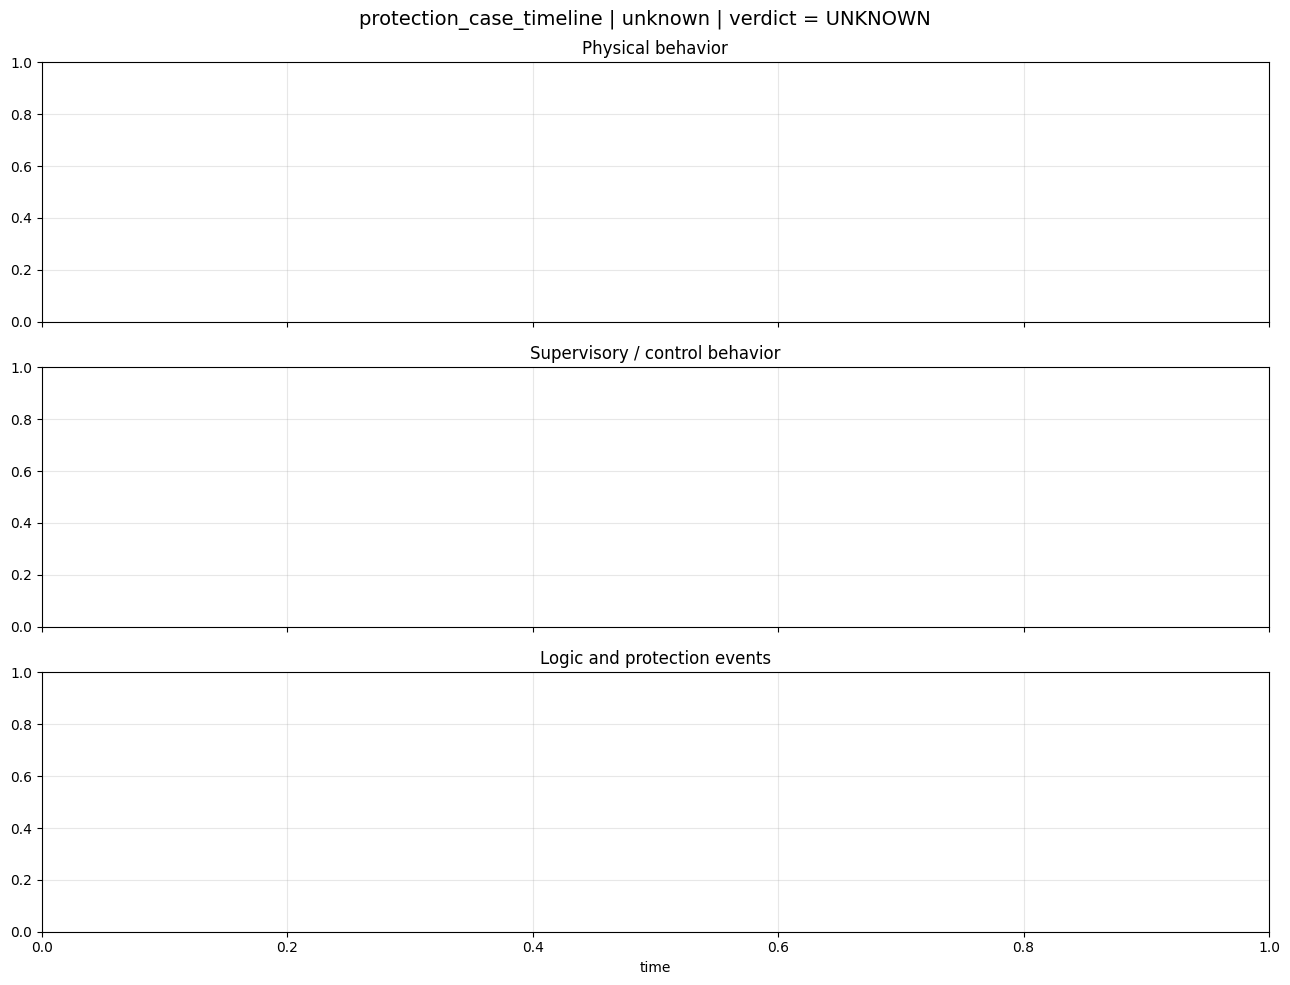

Skipping stage2h_case2_expected_vs_observed: no time column found
Skipping stage2h_case3_segmented_behavior: no time column found
Skipping stage2h_case45_aging_policy_compare: no time column found


In [88]:
SCENARIO_LAYOUT = {
    "baseline": {
        "physical": [
            (["tcell_abs"], "Tcell_abs", False),
            (["dtdt_f"], "dT/dt", False),
            (["rshunt"], "|I(RShunt)|", True),
        ],
        "control": [
            (["therm_stress"], "therm_stress", False),
            (["icmd_scale_final"], "icmd_scale_final", False),
        ],
        "logic": [
            (["chg_limit_f", "chg_limit"], "chg_limit", False),
            (["sys_derate"], "sys_derate", False),
            (["therm_shdn_f", "therm_shdn"], "therm_shdn", False),
            (["final_shdn"], "final_shdn", False),
        ],
    },

    "thermal_derate": {
        "physical": [
            (["tcell_abs"], "Tcell_abs", False),
            (["dtdt_f"], "dT/dt", False),
            (["rshunt"], "|I(RShunt)|", True),
        ],
        "control": [
            (["therm_stress"], "therm_stress", False),
            (["icmd_scale_final"], "icmd_scale_final", False),
            (["chg_cmd_scale"], "chg_cmd_scale", False),
        ],
        "logic": [
            (["runaway_precursor"], "runaway_precursor", False),
            (["chg_limit_f", "chg_limit"], "chg_limit", False),
            (["sys_derate"], "sys_derate", False),
            (["therm_shdn_f", "therm_shdn"], "therm_shdn", False),
        ],
    },

    "runaway_prevention": {
        "physical": [
            (["tcell_abs"], "Tcell_abs", False),
            (["dtdt_f"], "dT/dt", False),
            (["rshunt"], "|I(RShunt)|", True),
        ],
        "control": [
            (["therm_stress"], "therm_stress", False),
            (["icmd_scale_final"], "icmd_scale_final", False),
            (["chg_cmd_scale"], "chg_cmd_scale", False),
        ],
        "logic": [
            (["runaway_precursor"], "runaway_precursor", False),
            (["chg_limit_f", "chg_limit"], "chg_limit", False),
            (["sys_derate"], "sys_derate", False),
            (["therm_shdn_f", "therm_shdn"], "therm_shdn", False),
            (["final_shdn"], "final_shdn", False),
        ],
    },

    "aging_warning": {
        "physical": [
            (["r0eff"], "R0eff", False),
            (["rshunt"], "|I(RShunt)|", True),
        ],
        "control": [
            (["risk_score"], "risk_score", False),
            (["health_score"], "health_score", False),
            (["age_stress"], "age_stress", False),
            (["icmd_scale_final"], "icmd_scale_final", False),
        ],
        "logic": [
            (["aging_warn"], "aging_warn", False),
            (["aging_severe"], "aging_severe", False),
        ],
    },

    "severe_aging": {
        "physical": [
            (["r0eff"], "R0eff", False),
            (["rshunt"], "|I(RShunt)|", True),
        ],
        "control": [
            (["risk_score"], "risk_score", False),
            (["health_score"], "health_score", False),
            (["age_stress"], "age_stress", False),
            (["icmd_scale_final"], "icmd_scale_final", False),
        ],
        "logic": [
            (["aging_warn"], "aging_warn", False),
            (["aging_severe"], "aging_severe", False),
            (["sys_derate"], "sys_derate", False),
        ],
    },

    "fast_fault": {
        "physical": [
            (["rshunt"], "|I(RShunt)|", True),
        ],
        "control": [
            (["icmd_scale_final"], "icmd_scale_final", False),
        ],
        "logic": [
            (["fast_fault_raw"], "fast_fault_raw", False),
            (["fast_shdn"], "fast_shdn", False),
            (["sys_fault"], "sys_fault", False),
            (["final_shdn"], "final_shdn", False),
        ],
    },
}

def plot_case_stage2c(path):
    df = loaded_data[path]
    case_name = case_name_from_path(path)
    scenario = scenario_from_name(case_name)
    events = collect_case_events(case_name)
    verdict = summary_df.loc[summary_df["case_name"] == case_name, "verdict"].iloc[0]

    t = get_time_series(df)
    if t is None:
        print(f"Skipping {case_name}: no time column found")
        return

    layout = SCENARIO_LAYOUT.get(scenario, SCENARIO_LAYOUT["baseline"])
    fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

    panel_names = ["physical", "control", "logic"]
    panel_titles = [
        "Physical behavior",
        "Supervisory / control behavior",
        "Logic and protection events"
    ]

    for ax, panel_name, panel_title in zip(axes, panel_names, panel_titles):
        any_plotted = False
        for aliases, label, absval in layout[panel_name]:
            col, s = safe_signal(df, aliases, absval=absval)
            if s is not None and s.notna().sum() > 0:
                ax.plot(t, s, label=label, linewidth=1.5)
                any_plotted = True

        add_event_lines(ax, events)
        ax.set_title(panel_title)
        ax.grid(True, alpha=0.3)
        if any_plotted:
            add_legend_if_any(ax, ncol=3, fontsize=8)

    axes[-1].set_xlabel("time")
    fig.suptitle(f"{case_name} | {scenario} | verdict = {verdict}", fontsize=14)
    plt.tight_layout()
    plt.show()

for path in protection_files:
    plot_case_stage2c(path)

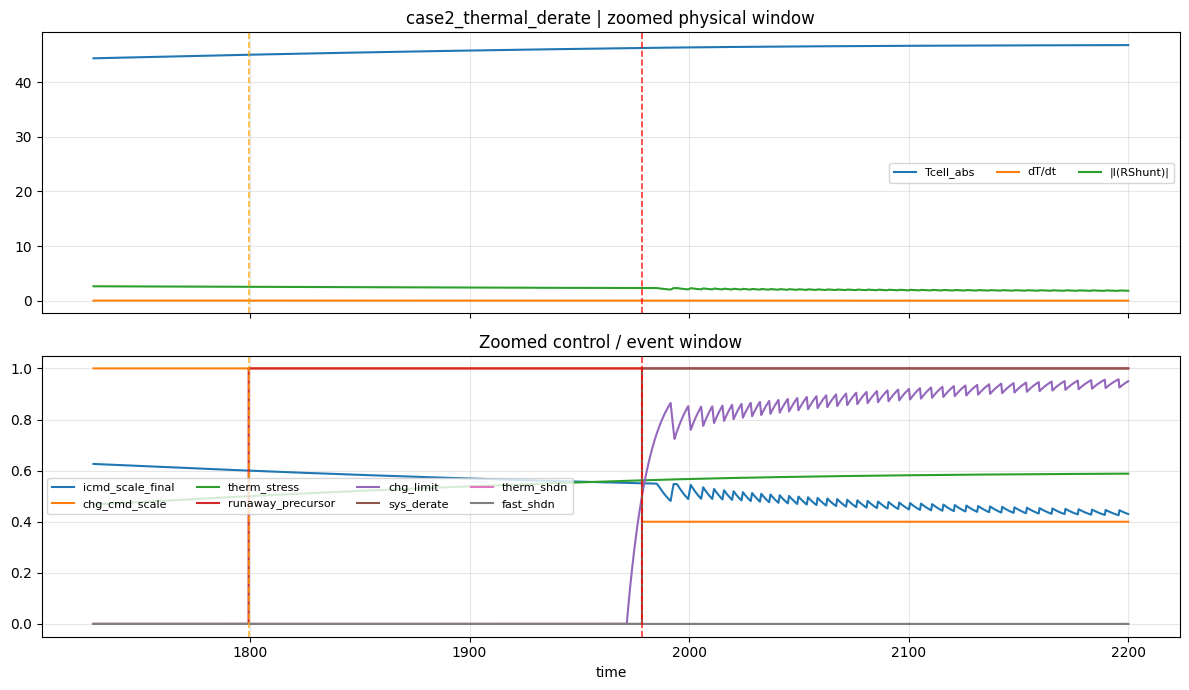

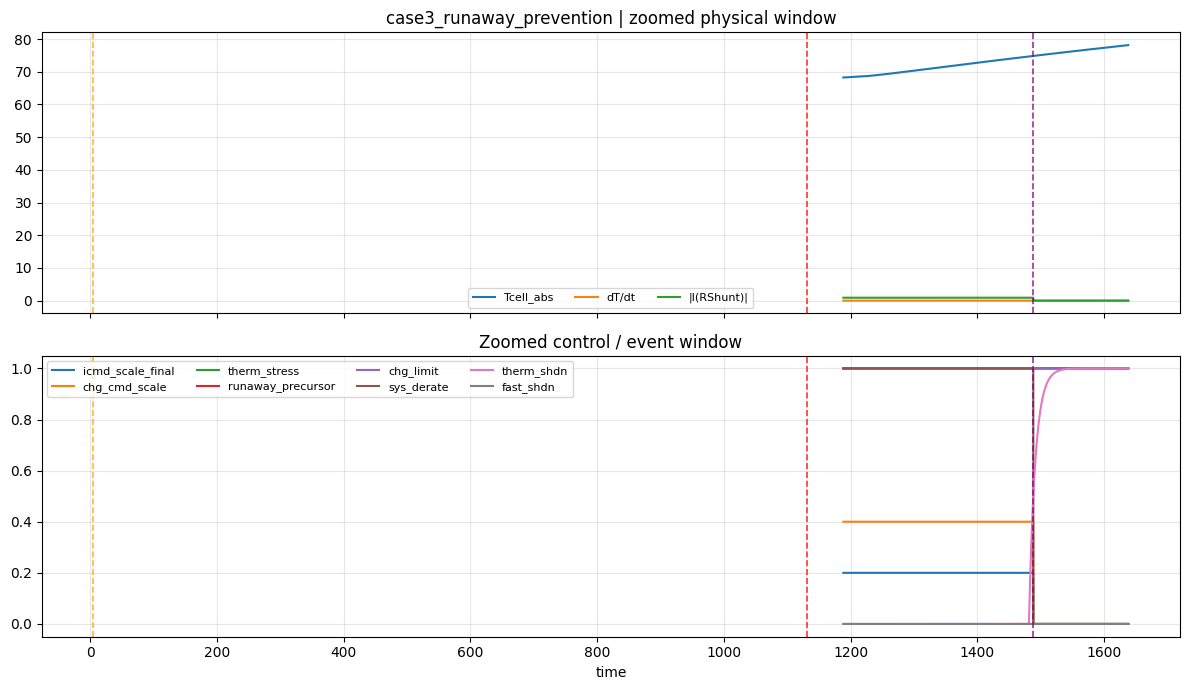

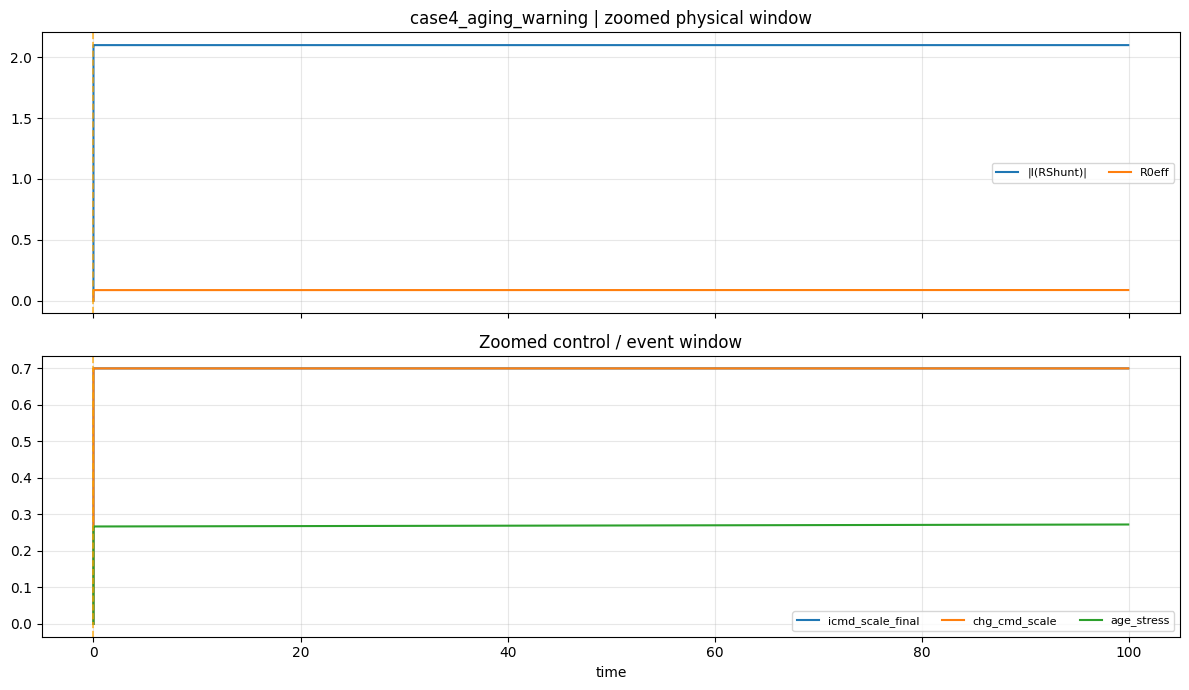

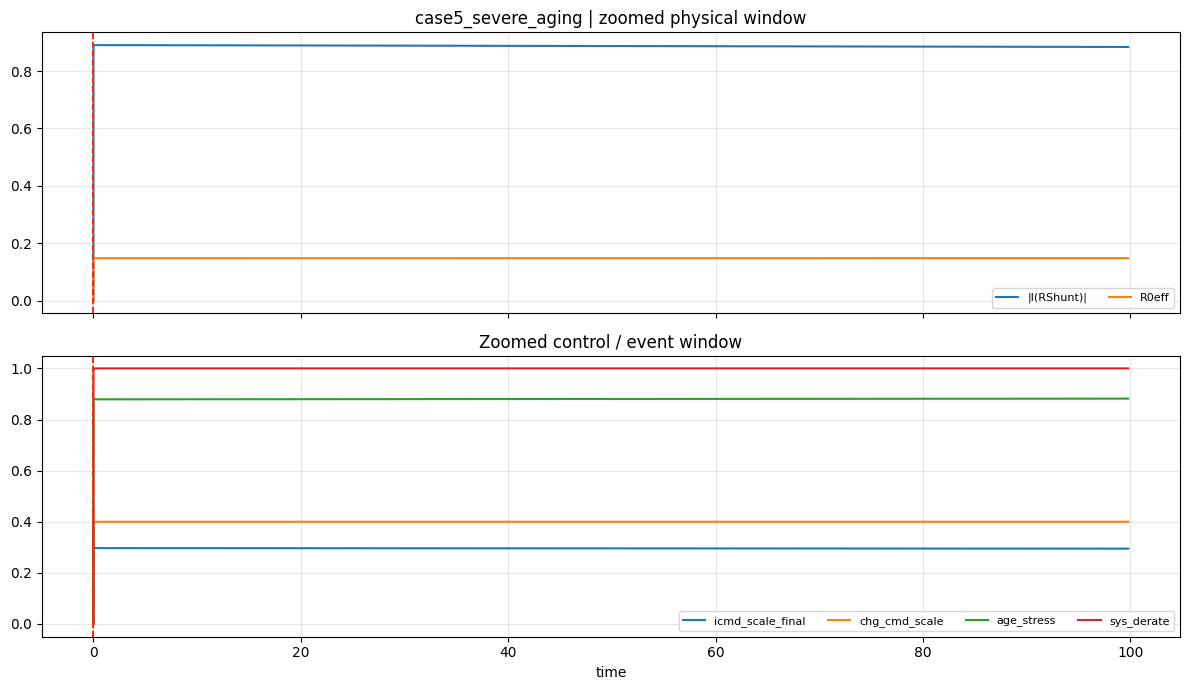

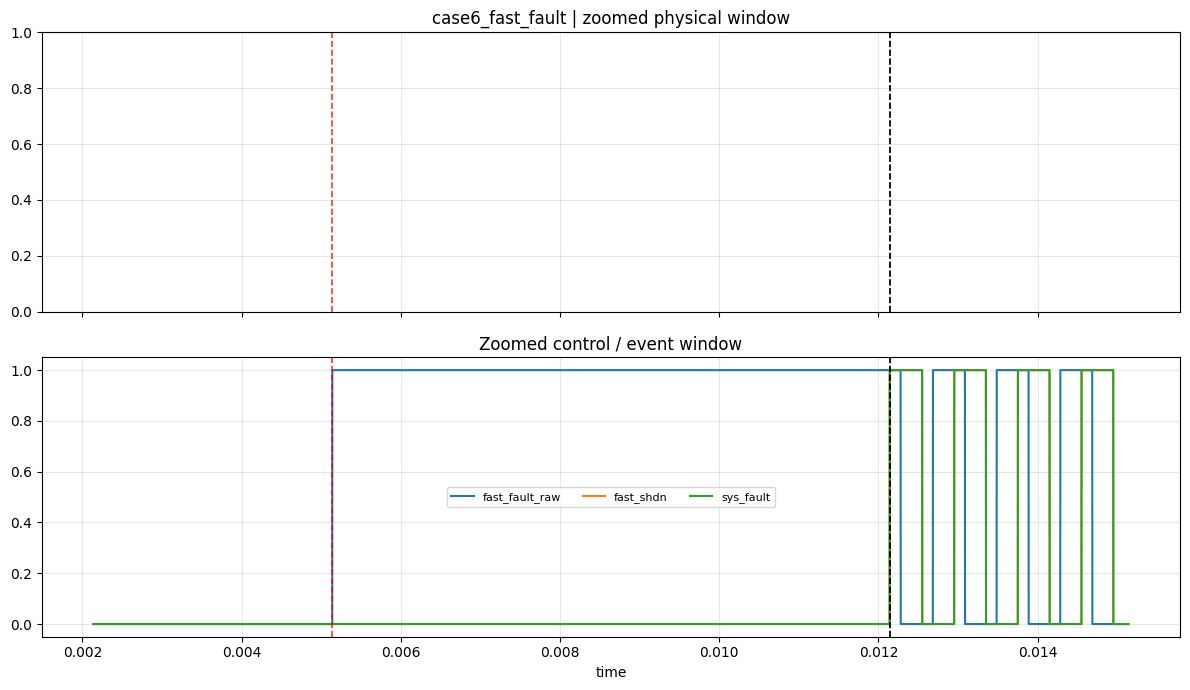

In [89]:
def choose_focus_event(case_name):
    srow = summary_row_for_case(case_name)
    scenario = srow["scenario"]

    if scenario == "thermal_derate":
        return first_valid_time(srow.get("t_chg_limit", np.nan), srow.get("t_sys_derate", np.nan)), 250, 250
    if scenario == "runaway_prevention":
        return first_valid_time(srow.get("t_therm_shdn", np.nan), srow.get("t_final_shdn", np.nan)), 300, 150
    if scenario == "fast_fault":
        return first_valid_time(srow.get("t_fast_fault", np.nan)), 0.003, 0.01
    if scenario in ["aging_warning", "severe_aging"]:
        return 0.0, 5, 100
    return np.nan, 100, 100

def plot_zoom_window(path):
    df = loaded_data[path]
    case_name = case_name_from_path(path)
    scenario = scenario_from_name(case_name)
    t = get_time_series(df)
    if t is None:
        return

    focus_t, left, right = choose_focus_event(case_name)
    if pd.isna(focus_t):
        return

    if focus_t == 0.0:
        mask = (t >= 0) & (t <= right)
    else:
        mask = (t >= focus_t - left) & (t <= focus_t + right)

    events = collect_case_events(case_name)

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # panel 1: physical response
    for aliases, label, absval in [
        (["tcell_abs"], "Tcell_abs", False),
        (["dtdt_f"], "dT/dt", False),
        (["rshunt"], "|I(RShunt)|", True),
        (["r0eff"], "R0eff", False),
    ]:
        col, s = safe_signal(df, aliases, absval=absval)
        if s is not None and s[mask].notna().sum() > 0:
            axes[0].plot(t[mask], s[mask], label=label, linewidth=1.5)

    add_event_lines(axes[0], events)
    axes[0].set_title(f"{case_name} | zoomed physical window")
    axes[0].grid(True, alpha=0.3)
    add_legend_if_any(axes[0], ncol=3, fontsize=8)

    # panel 2: control + logic
    for aliases, label, absval in [
        (["icmd_scale_final"], "icmd_scale_final", False),
        (["chg_cmd_scale"], "chg_cmd_scale", False),
        (["therm_stress"], "therm_stress", False),
        (["age_stress"], "age_stress", False),
        (["runaway_precursor"], "runaway_precursor", False),
        (["chg_limit_f", "chg_limit"], "chg_limit", False),
        (["sys_derate"], "sys_derate", False),
        (["therm_shdn_f", "therm_shdn"], "therm_shdn", False),
        (["fast_fault_raw"], "fast_fault_raw", False),
        (["fast_shdn"], "fast_shdn", False),
        (["sys_fault"], "sys_fault", False),
    ]:
        col, s = safe_signal(df, aliases, absval=absval)
        if s is not None and s[mask].notna().sum() > 0:
            axes[1].plot(t[mask], s[mask], label=label, linewidth=1.5)

    add_event_lines(axes[1], events)
    axes[1].set_title("Zoomed control / event window")
    axes[1].grid(True, alpha=0.3)
    add_legend_if_any(axes[1], ncol=4, fontsize=8)

    axes[1].set_xlabel("time")
    plt.tight_layout()
    plt.show()

for path in protection_files:
    plot_zoom_window(path)

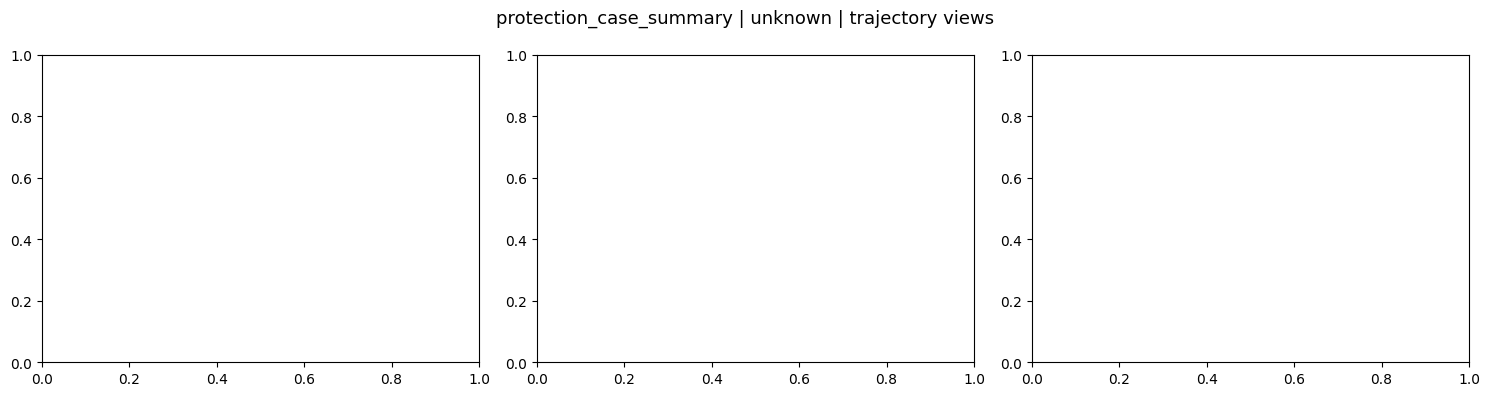

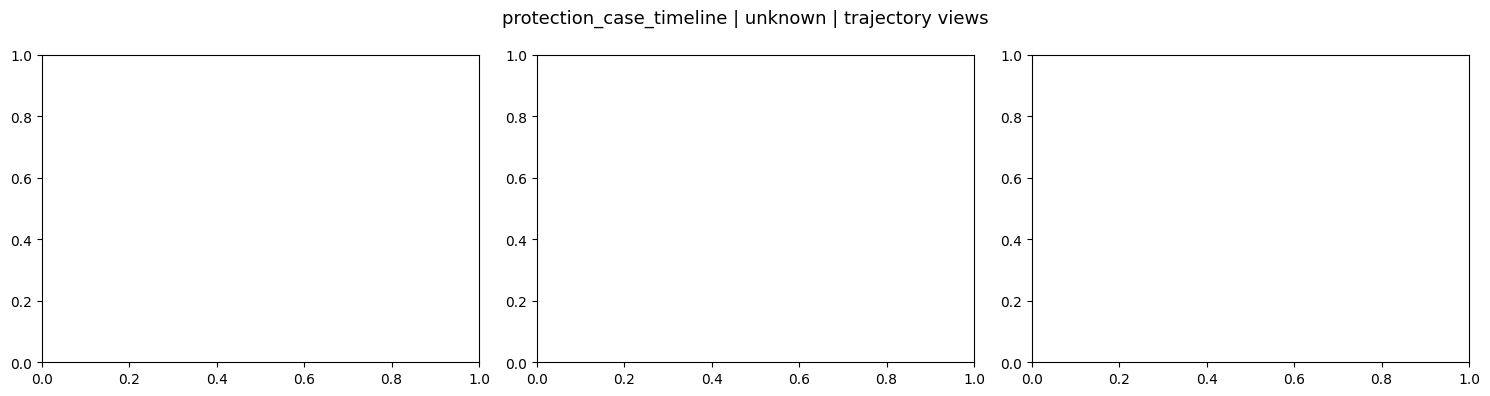

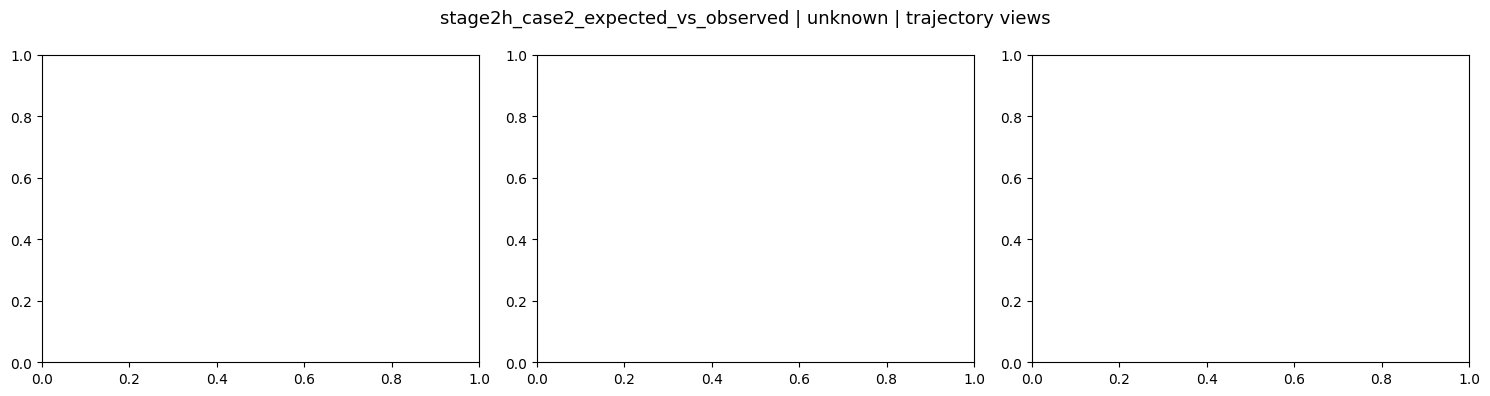

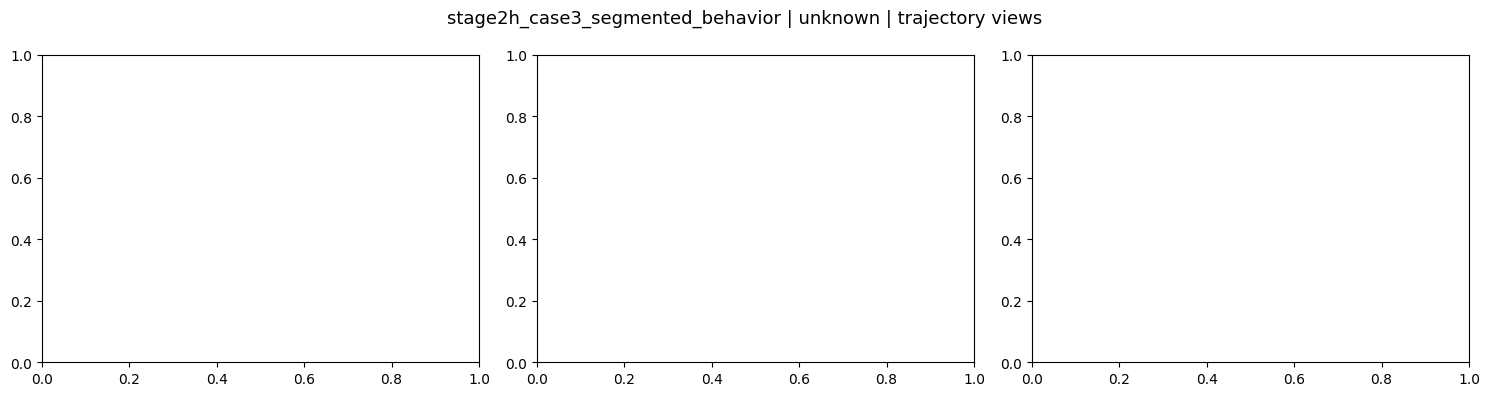

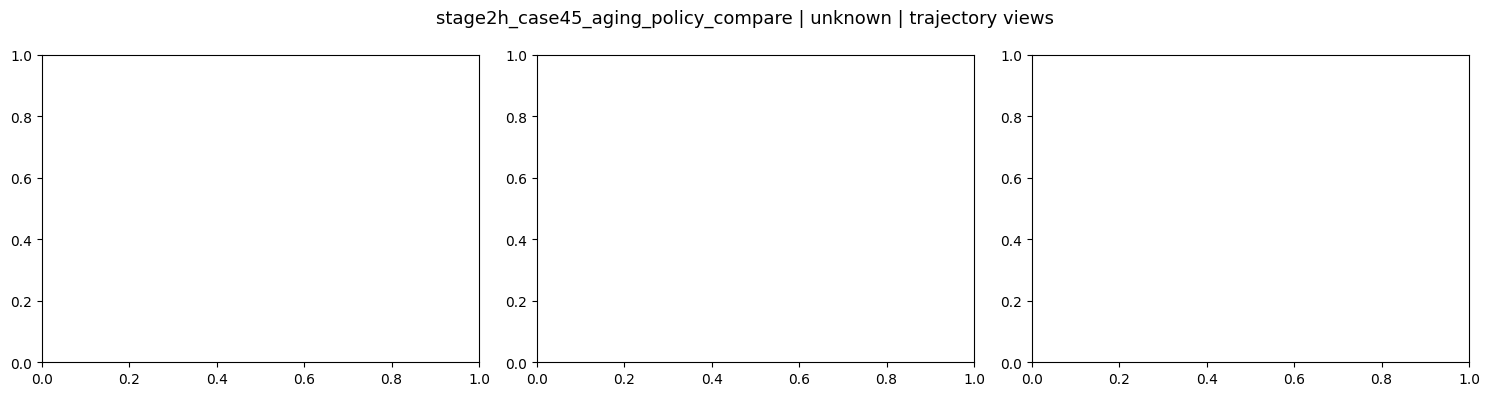

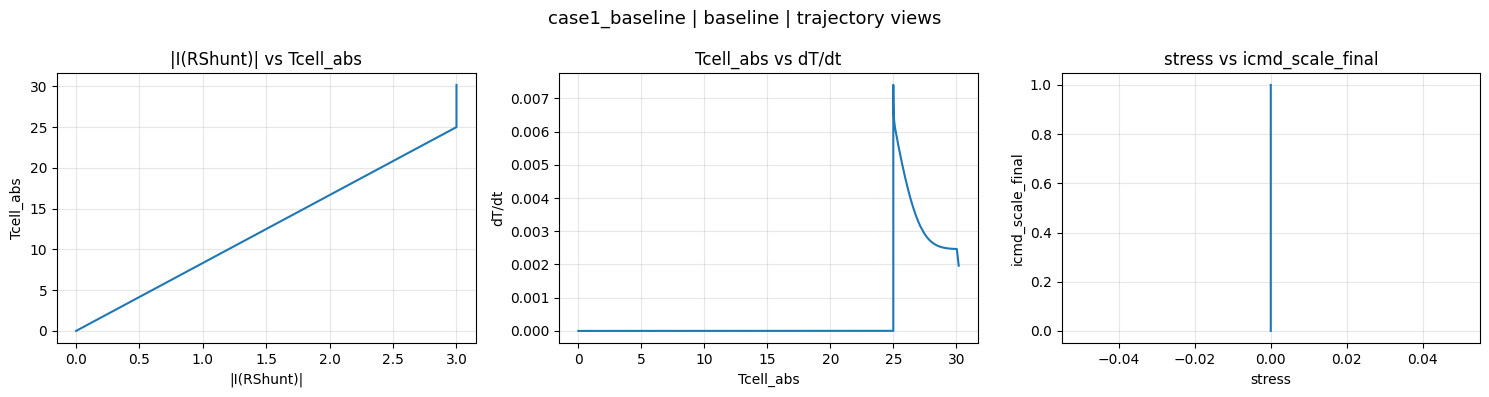

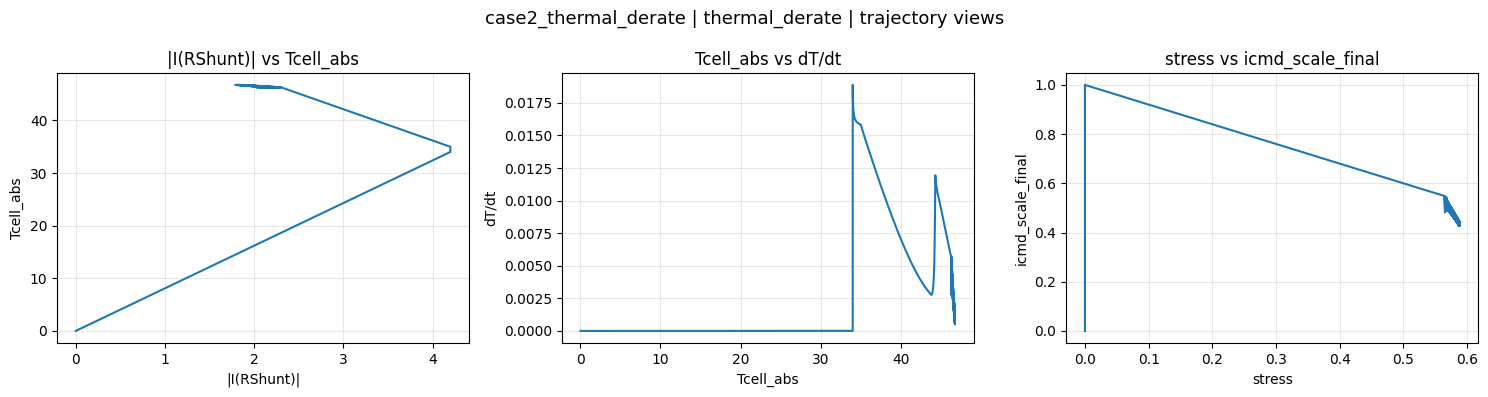

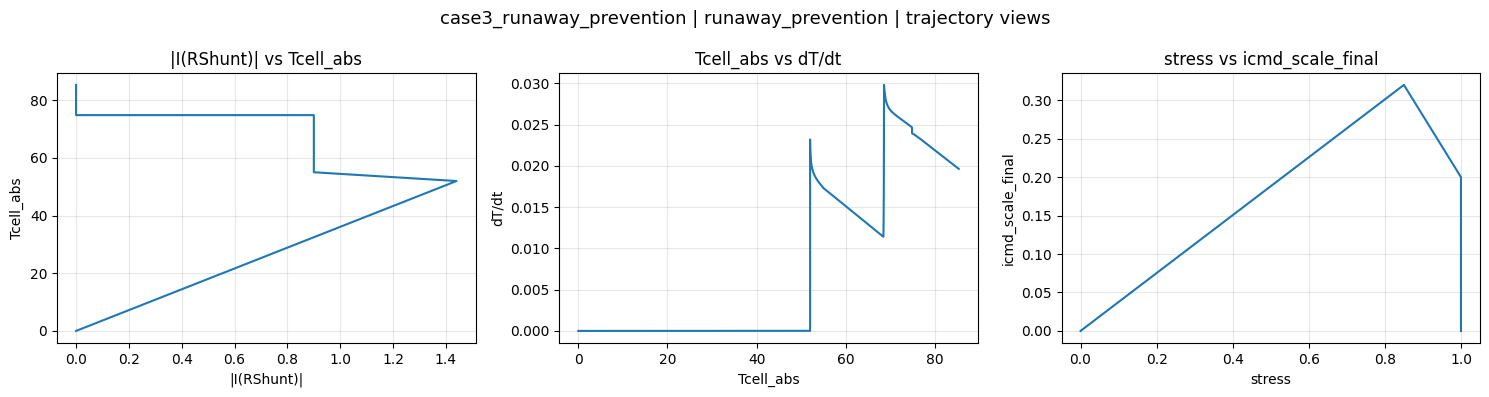

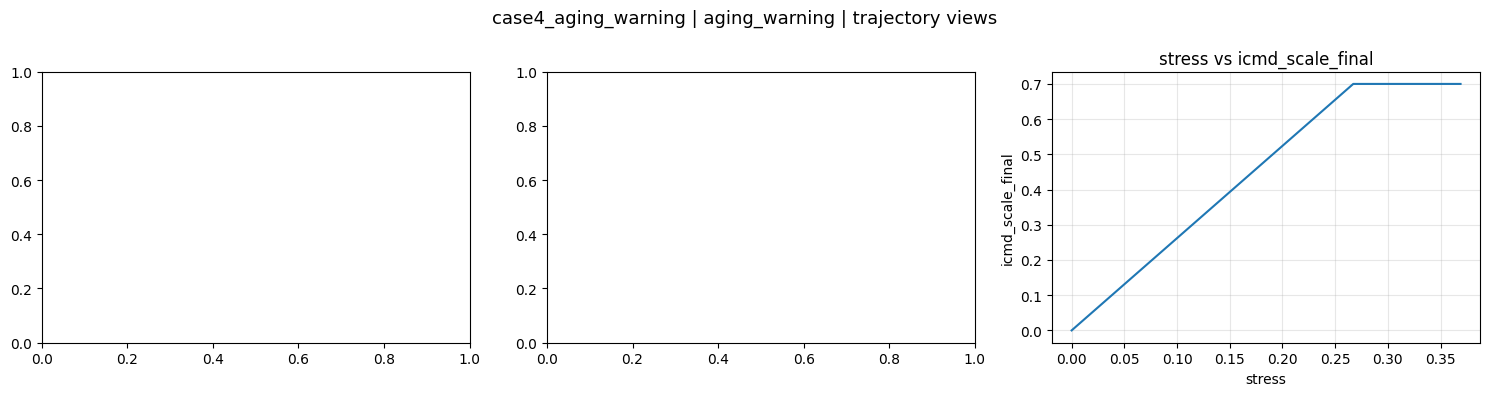

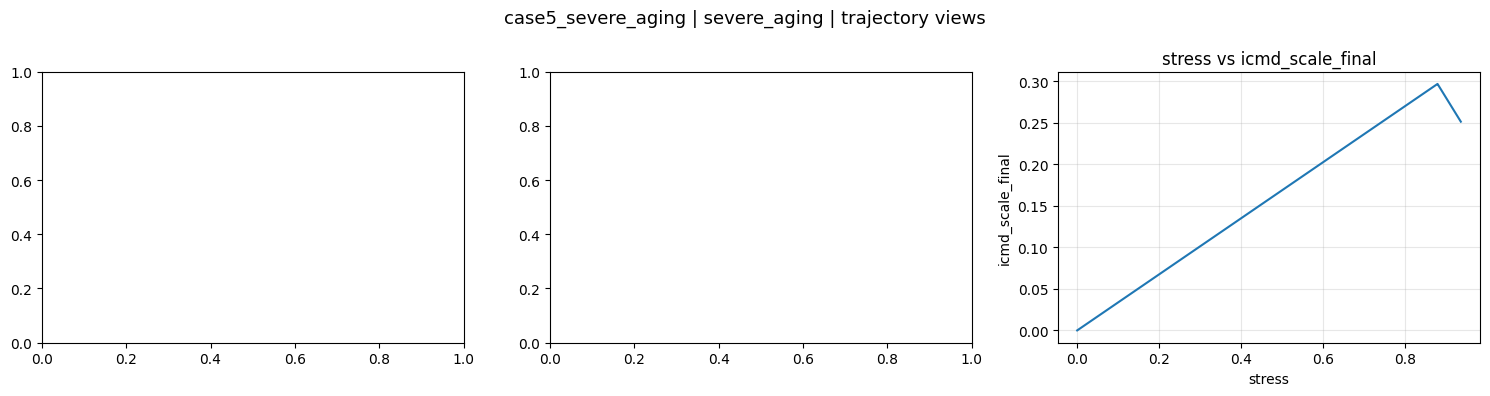

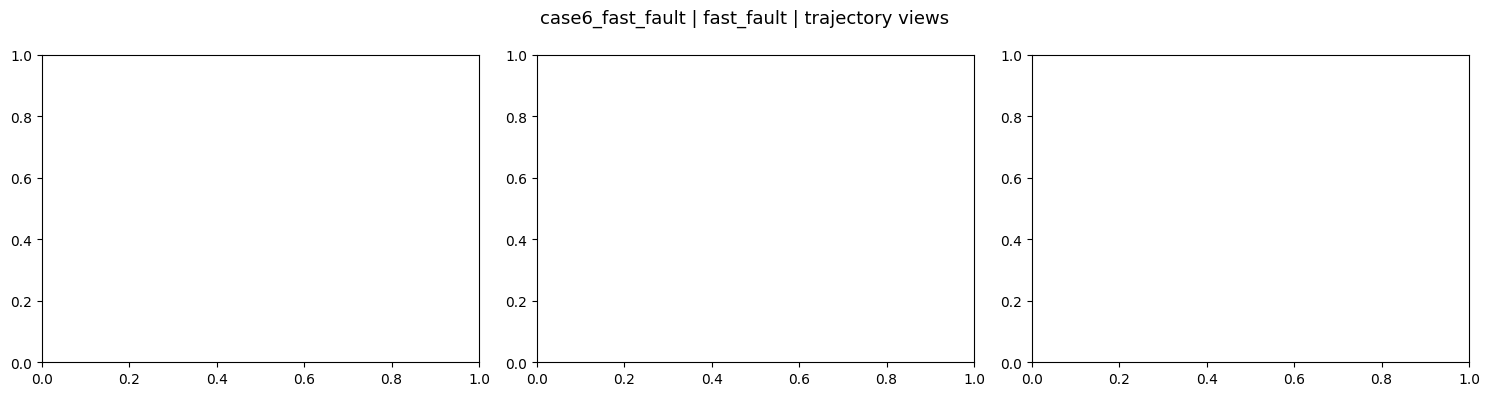

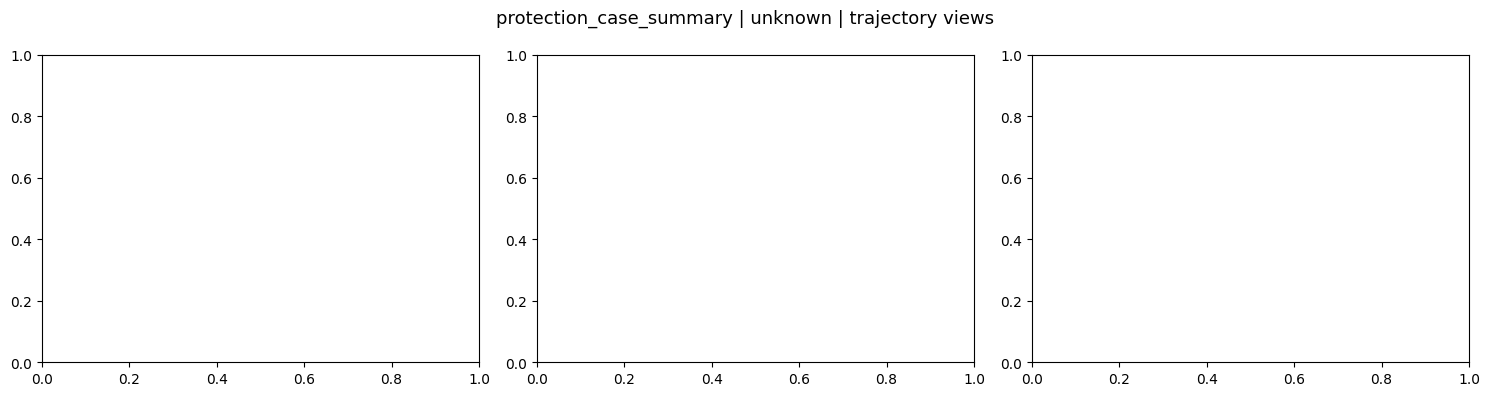

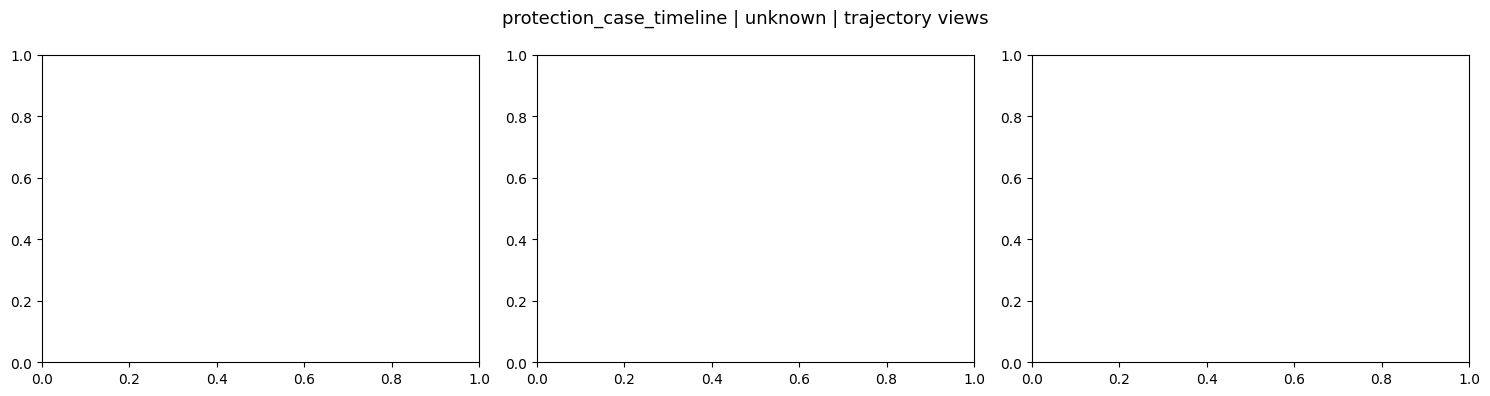

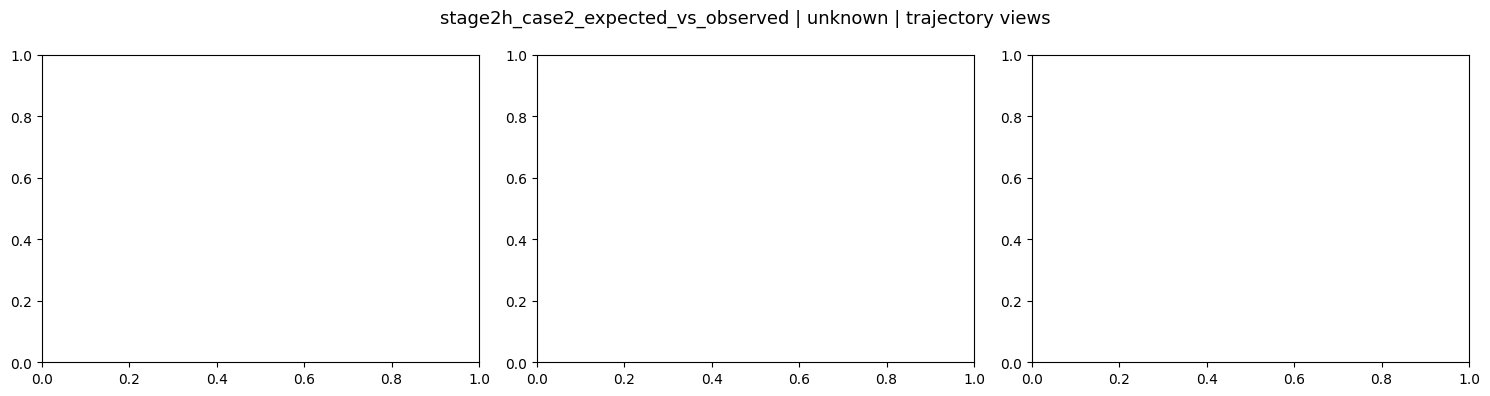

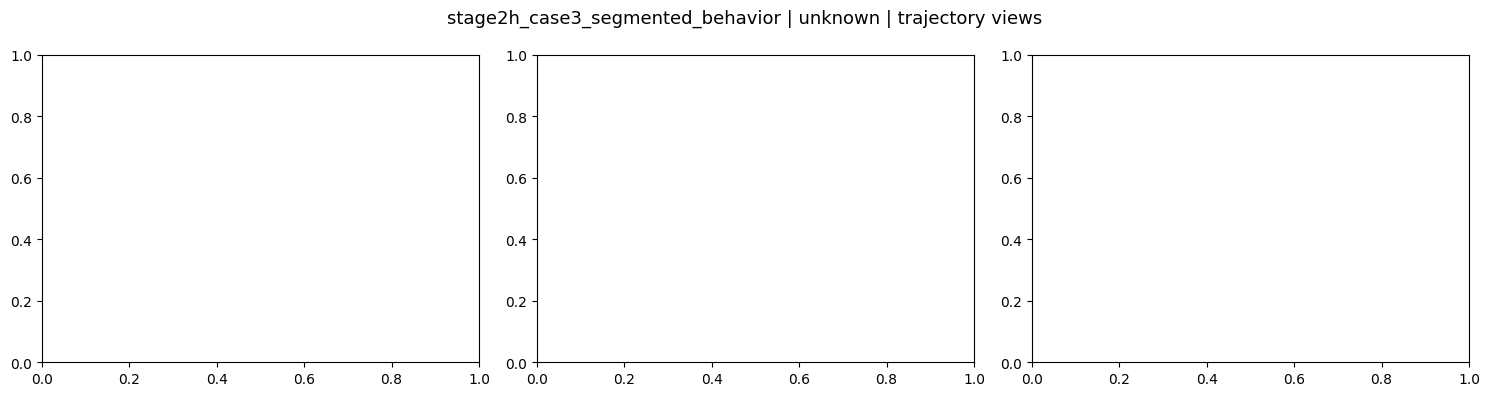

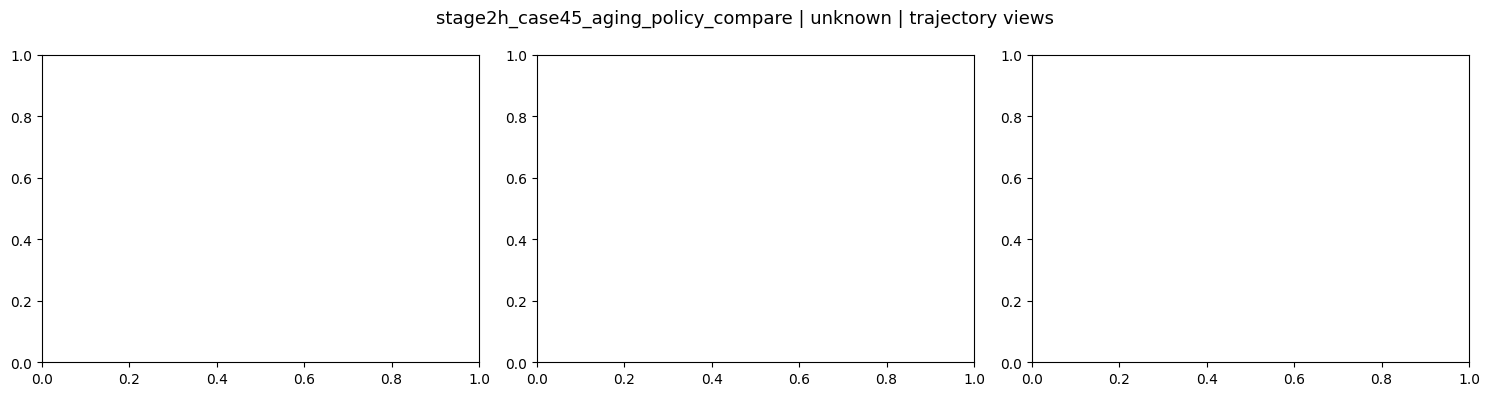

In [90]:
def plot_trajectory_views(path):
    df = loaded_data[path]
    case_name = case_name_from_path(path)
    scenario = scenario_from_name(case_name)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    plotted_any = [False, False, False]

    # 1) current vs temperature
    _, iabs = safe_signal(df, ["rshunt"], absval=True)
    _, temp = safe_signal(df, ["tcell_abs"])
    if iabs is not None and temp is not None:
        m = iabs.notna() & temp.notna()
        if m.sum() > 5:
            axes[0].plot(iabs[m], temp[m], linewidth=1.5)
            axes[0].set_title("|I(RShunt)| vs Tcell_abs")
            axes[0].set_xlabel("|I(RShunt)|")
            axes[0].set_ylabel("Tcell_abs")
            axes[0].grid(True, alpha=0.3)
            plotted_any[0] = True

    # 2) temperature vs dT/dt
    _, dtdt = safe_signal(df, ["dtdt_f"])
    if temp is not None and dtdt is not None:
        m = temp.notna() & dtdt.notna()
        if m.sum() > 5:
            axes[1].plot(temp[m], dtdt[m], linewidth=1.5)
            axes[1].set_title("Tcell_abs vs dT/dt")
            axes[1].set_xlabel("Tcell_abs")
            axes[1].set_ylabel("dT/dt")
            axes[1].grid(True, alpha=0.3)
            plotted_any[1] = True

    # 3) controller response curve
    _, stress = safe_signal(df, ["therm_stress"])
    if stress is None:
        _, stress = safe_signal(df, ["age_stress"])
    _, scale = safe_signal(df, ["icmd_scale_final"])
    if stress is not None and scale is not None:
        m = stress.notna() & scale.notna()
        if m.sum() > 5:
            axes[2].plot(stress[m], scale[m], linewidth=1.5)
            axes[2].set_title("stress vs icmd_scale_final")
            axes[2].set_xlabel("stress")
            axes[2].set_ylabel("icmd_scale_final")
            axes[2].grid(True, alpha=0.3)
            plotted_any[2] = True

    fig.suptitle(f"{case_name} | {scenario} | trajectory views", fontsize=13)
    plt.tight_layout()
    plt.show()

for path in protection_files:
    plot_trajectory_views(path)

In [91]:
# -------------------------------
# Stage 2D.1 - Safety window table
# -------------------------------

safety_rows = []

for _, r in summary_df.iterrows():
    case_name = r["case_name"]
    scenario = r["scenario"]

    t_prec = r.get("t_runaway_prec", np.nan)
    t_derate = first_valid_time(
        r.get("t_chg_limit", np.nan),
        r.get("t_sys_derate", np.nan)
    )
    t_shutdown = first_valid_time(
        r.get("t_therm_shdn", np.nan),
        r.get("t_final_shdn", np.nan)
    )

    safety_rows.append({
        "case_name": case_name,
        "scenario": scenario,
        "t_precursor": t_prec,
        "t_derate": t_derate,
        "t_shutdown": t_shutdown,
        "warning_window_s": (
            t_derate - t_prec if pd.notna(t_prec) and pd.notna(t_derate) else np.nan
        ),
        "intervention_window_s": (
            t_shutdown - t_derate if pd.notna(t_shutdown) and pd.notna(t_derate) else np.nan
        ),
        "total_safety_window_s": (
            t_shutdown - t_prec if pd.notna(t_shutdown) and pd.notna(t_prec) else np.nan
        )
    })

safety_df = pd.DataFrame(safety_rows)
safety_df

,case_name,scenario,t_precursor,t_derate,t_shutdown,warning_window_s,intervention_window_s,total_safety_window_s
0,case1_baseline,baseline,NaN,NaN,NaN,NaN,NaN,NaN
1,case2_thermal_derate,thermal_derate,1799.370594,1978.513415,NaN,179.142821,NaN,NaN
2,case3_runaway_prevention,runaway_prevention,5.032406,1131.842717,1488.362481,1126.810311,356.519764,1483.330076
3,case4_aging_warning,aging_warning,NaN,NaN,NaN,NaN,NaN,NaN
4,case5_severe_aging,severe_aging,NaN,0.000000,NaN,NaN,NaN,NaN
5,case6_fast_fault,fast_fault,NaN,NaN,0.012141,NaN,NaN,NaN
6,protection_case_summary,unknown,NaN,NaN,NaN,NaN,NaN,NaN
7,protection_case_summary,unknown,NaN,NaN,NaN,NaN,NaN,NaN
8,protection_case_timeline,unknown,NaN,NaN,NaN,NaN,NaN,NaN
9,protection_case_timeline,unknown,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
# ------------------------------------
# Stage 2D.2 - Derating effectiveness
# ------------------------------------

derate_df = advanced_df[[
    "case_name",
    "scenario",
    "current_before_derate",
    "current_after_derate",
    "current_drop_frac",
    "temp_slope_before_derate",
    "temp_slope_after_derate",
    "temp_slope_reduction_frac"
]].copy()

derate_df["current_drop_percent"] = derate_df["current_drop_frac"] * 100
derate_df["temp_slope_reduction_percent"] = derate_df["temp_slope_reduction_frac"] * 100

derate_df

,case_name,scenario,current_before_derate,current_after_derate,current_drop_frac,temp_slope_before_derate,temp_slope_after_derate,temp_slope_reduction_frac,current_drop_percent,temp_slope_reduction_percent
0,case1_baseline,baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,case2_thermal_derate,thermal_derate,2.342750,2.064487,1.187764e-01,0.006940,0.002383,0.656615,1.187764e+01,65.661529
2,case3_runaway_prevention,runaway_prevention,0.900016,0.900016,-1.233559e-16,0.011489,0.016349,-0.423014,-1.233559e-14,-42.301406
3,case4_aging_warning,aging_warning,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,case5_severe_aging,severe_aging,0.889477,0.888456,1.148040e-03,NaN,NaN,NaN,1.148040e-01,NaN
5,case6_fast_fault,fast_fault,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,protection_case_summary,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,protection_case_summary,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,protection_case_timeline,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,protection_case_timeline,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
# -----------------------------------
# Stage 2D.3 - Aging-aware policy view
# -----------------------------------

aging_df = summary_df.loc[
    summary_df["scenario"].isin(["aging_warning", "severe_aging"]),
    [
        "case_name",
        "scenario",
        "r0eff_max",
        "r0eff_avg",
        "risk_score_max",
        "health_score_min",
        "age_stress_max",
        "icmd_scale_min",
        "t_aging_warn",
        "t_aging_severe",
        "t_sys_derate"
    ]
].copy()

aging_df["health_penalty"] = 1 - aging_df["health_score_min"]
aging_df["allowed_current_fraction"] = aging_df["icmd_scale_min"]

aging_df

,case_name,scenario,r0eff_max,r0eff_avg,risk_score_max,health_score_min,age_stress_max,icmd_scale_min,t_aging_warn,t_aging_severe,t_sys_derate,health_penalty,allowed_current_fraction
3,case4_aging_warning,aging_warning,0.096896,0.091021,0.147583,0.852417,0.368958,0.700000,0.0,NaN,NaN,0.147583,0.700000
4,case5_severe_aging,severe_aging,0.153582,0.150708,0.374327,0.625673,0.935817,0.251346,0.0,0.0,0.0,0.374327,0.251346


In [94]:
# --------------------------------
# Stage 2D.4 - Fast fault latency
# --------------------------------

fast_fault_df = summary_df.loc[
    summary_df["scenario"] == "fast_fault",
    [
        "case_name",
        "scenario",
        "t_fast_fault",
        "t_fast_shdn",
        "t_sys_fault",
        "t_final_shdn"
    ]
].copy()

fast_fault_df["fault_to_fastshdn_ms"] = (
    (fast_fault_df["t_fast_shdn"] - fast_fault_df["t_fast_fault"]) * 1000
)
fast_fault_df["fault_to_sysfault_ms"] = (
    (fast_fault_df["t_sys_fault"] - fast_fault_df["t_fast_fault"]) * 1000
)
fast_fault_df["fault_to_finalshdn_ms"] = (
    (fast_fault_df["t_final_shdn"] - fast_fault_df["t_fast_fault"]) * 1000
)

fast_fault_df

,case_name,scenario,t_fast_fault,t_fast_shdn,t_sys_fault,t_final_shdn,fault_to_fastshdn_ms,fault_to_sysfault_ms,fault_to_finalshdn_ms
5,case6_fast_fault,fast_fault,0.005139,0.012141,0.012141,0.012141,7.001743,7.001743,7.001743


In [95]:
# -------------------------------------
# Stage 2D.5 - Final protection summary
# -------------------------------------

final_protection_df = summary_df.merge(
    safety_df[[
        "case_name",
        "warning_window_s",
        "intervention_window_s",
        "total_safety_window_s"
    ]],
    on="case_name",
    how="left"
).merge(
    derate_df[[
        "case_name",
        "current_drop_percent",
        "temp_slope_reduction_percent"
    ]],
    on="case_name",
    how="left"
).merge(
    advanced_df[[
        "case_name",
        "severity_score",
        "fastfault_to_shutdown_s"
    ]],
    on="case_name",
    how="left"
)

final_protection_df = final_protection_df[[
    "case_name",
    "scenario",
    "verdict",
    "temp_max",
    "risk_score_max",
    "health_score_min",
    "icmd_scale_min",
    "warning_window_s",
    "intervention_window_s",
    "total_safety_window_s",
    "current_drop_percent",
    "temp_slope_reduction_percent",
    "fastfault_to_shutdown_s",
    "severity_score"
]]

final_protection_df

,case_name,scenario,verdict,temp_max,risk_score_max,health_score_min,icmd_scale_min,warning_window_s,intervention_window_s,total_safety_window_s,current_drop_percent,temp_slope_reduction_percent,fastfault_to_shutdown_s,severity_score
0,case1_baseline,baseline,PASS,30.19305,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.301930
1,case2_thermal_derate,thermal_derate,PASS,46.76280,NaN,NaN,0.425560,179.142821,NaN,NaN,1.187764e+01,65.661529,NaN,0.467628
2,case3_runaway_prevention,runaway_prevention,PASS,85.34653,NaN,NaN,0.000000,1126.810311,356.519764,1483.330076,-1.233559e-14,-42.301406,NaN,0.853465
3,case4_aging_warning,aging_warning,PASS,NaN,0.147583,0.852417,0.700000,NaN,NaN,NaN,NaN,NaN,NaN,0.516541
4,case5_severe_aging,severe_aging,PASS,NaN,0.374327,0.625673,0.251346,NaN,NaN,NaN,1.148040e-01,NaN,NaN,1.310145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
82,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
83,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
84,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [96]:
# -----------------------------------------
# Stage 2D.6 - Objective / significance text
# -----------------------------------------

def objective_and_significance(row):
    sc = row["scenario"]

    if sc == "baseline":
        return pd.Series([
            "Verify that the system remains stable without nuisance intervention under normal conditions.",
            "Shows the protection architecture is not overly aggressive in safe operation."
        ])

    if sc == "thermal_derate":
        return pd.Series([
            "Verify that rising thermal stress triggers controlled current derating before shutdown is required.",
            "Shows graded protection and proves that intervention can slow thermal worsening."
        ])

    if sc == "runaway_prevention":
        return pd.Series([
            "Verify that precursor detection creates a usable safety window before forced shutdown.",
            "Shows anticipatory protection rather than late threshold-only action."
        ])

    if sc == "aging_warning":
        return pd.Series([
            "Verify that mild aging reduces allowable current without forcing severe-fault behavior.",
            "Shows health-aware protection policy and adaptive derating."
        ])

    if sc == "severe_aging":
        return pd.Series([
            "Verify that severe degradation causes stronger current restriction and persistent derate state.",
            "Shows that the architecture scales protection severity with battery condition."
        ])

    if sc == "fast_fault":
        return pd.Series([
            "Verify that electrical faults are handled on a millisecond timescale through a dedicated fast path.",
            "Shows multi-timescale protection beyond thermal-only supervision."
        ])

    return pd.Series(["Unknown objective", "Unknown significance"])

final_protection_df[["objective", "significance"]] = final_protection_df.apply(
    objective_and_significance, axis=1
)

final_protection_df

,case_name,scenario,verdict,temp_max,risk_score_max,health_score_min,icmd_scale_min,warning_window_s,intervention_window_s,total_safety_window_s,current_drop_percent,temp_slope_reduction_percent,fastfault_to_shutdown_s,severity_score,objective,significance
0,case1_baseline,baseline,PASS,30.19305,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.301930,Verify that the system remains stable without ...,Shows the protection architecture is not overl...
1,case2_thermal_derate,thermal_derate,PASS,46.76280,NaN,NaN,0.425560,179.142821,NaN,NaN,1.187764e+01,65.661529,NaN,0.467628,Verify that rising thermal stress triggers con...,Shows graded protection and proves that interv...
2,case3_runaway_prevention,runaway_prevention,PASS,85.34653,NaN,NaN,0.000000,1126.810311,356.519764,1483.330076,-1.233559e-14,-42.301406,NaN,0.853465,Verify that precursor detection creates a usab...,Shows anticipatory protection rather than late...
3,case4_aging_warning,aging_warning,PASS,NaN,0.147583,0.852417,0.700000,NaN,NaN,NaN,NaN,NaN,NaN,0.516541,Verify that mild aging reduces allowable curre...,Shows health-aware protection policy and adapt...
4,case5_severe_aging,severe_aging,PASS,NaN,0.374327,0.625673,0.251346,NaN,NaN,NaN,1.148040e-01,NaN,NaN,1.310145,Verify that severe degradation causes stronger...,Shows that the architecture scales protection ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,Unknown objective,Unknown significance
82,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,Unknown objective,Unknown significance
83,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,Unknown objective,Unknown significance
84,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,Unknown objective,Unknown significance


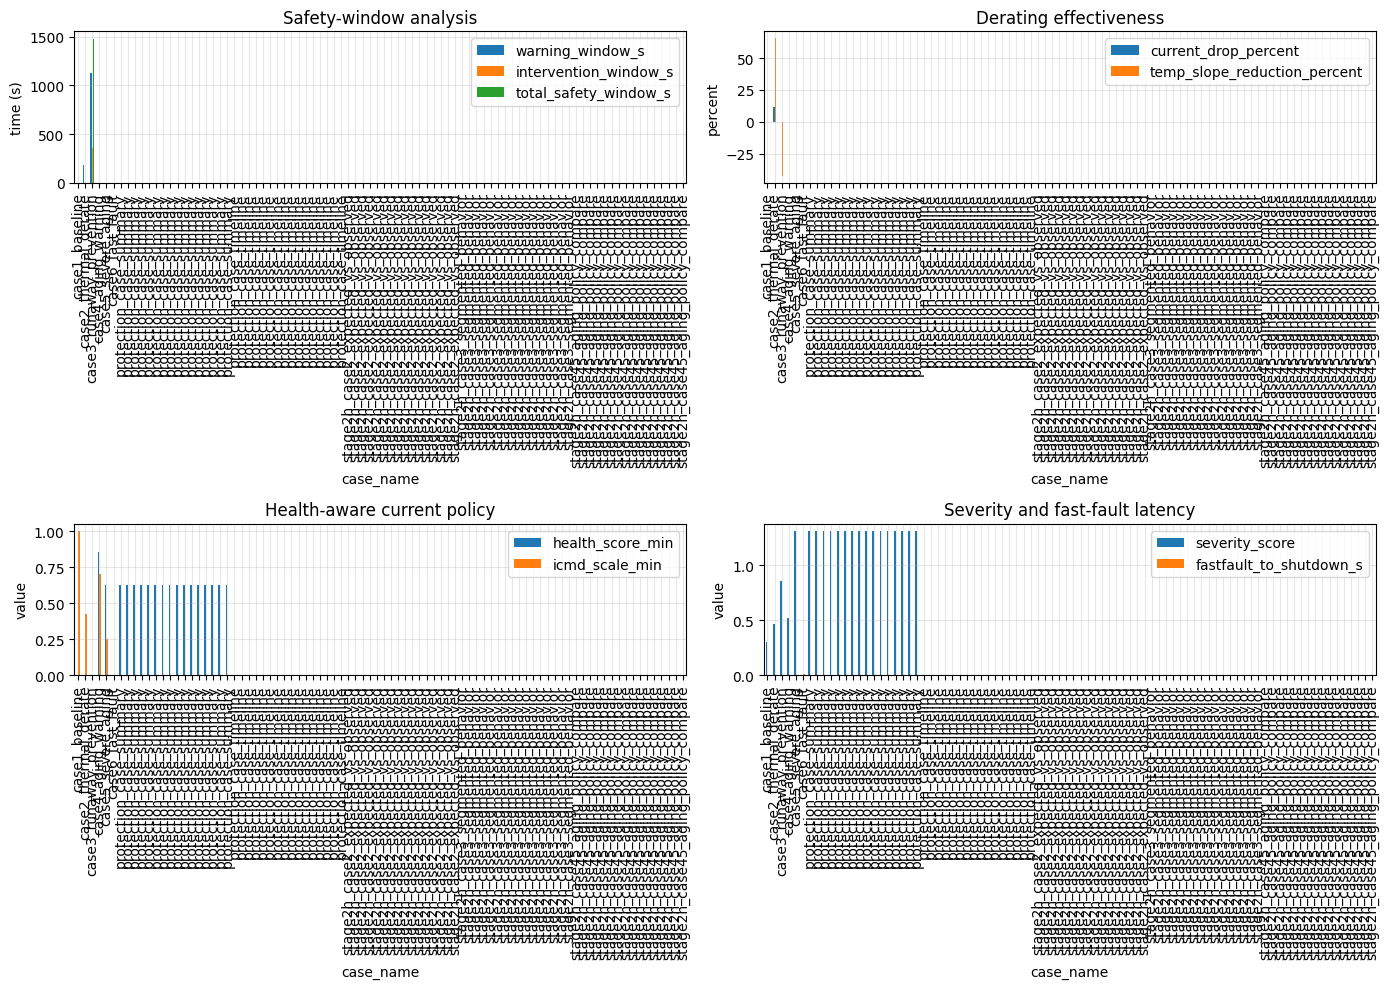

In [97]:
# ---------------------------------
# Stage 2D.7 - Claim-driven figures
# ---------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Safety window
sw = final_protection_df[["case_name", "warning_window_s", "intervention_window_s", "total_safety_window_s"]].set_index("case_name")
sw.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Safety-window analysis")
axes[0, 0].set_ylabel("time (s)")
axes[0, 0].grid(True, alpha=0.3)

# 2. Derating effectiveness
de = final_protection_df[["case_name", "current_drop_percent", "temp_slope_reduction_percent"]].set_index("case_name")
de.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Derating effectiveness")
axes[0, 1].set_ylabel("percent")
axes[0, 1].grid(True, alpha=0.3)

# 3. Aging-aware policy
ag = final_protection_df[["case_name", "health_score_min", "icmd_scale_min"]].set_index("case_name")
ag.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Health-aware current policy")
axes[1, 0].set_ylabel("value")
axes[1, 0].grid(True, alpha=0.3)

# 4. Severity / fast latency
sev = final_protection_df[["case_name", "severity_score", "fastfault_to_shutdown_s"]].set_index("case_name")
sev.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Severity and fast-fault latency")
axes[1, 1].set_ylabel("value")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [98]:
# ---------------------------------
# Stage 2D.8 - PPT/report-ready cuts
# ---------------------------------

ppt_safety = safety_df.loc[
    safety_df["scenario"].isin(["thermal_derate", "runaway_prevention"])
].copy()

ppt_derate = derate_df.loc[
    derate_df["scenario"].isin(["thermal_derate", "runaway_prevention"])
].copy()

ppt_aging = aging_df.copy()
ppt_fast = fast_fault_df.copy()

print("Safety table:")
display(ppt_safety)

print("Derating table:")
display(ppt_derate)

print("Aging table:")
display(ppt_aging)

print("Fast-fault table:")
display(ppt_fast)

Safety table:


,case_name,scenario,t_precursor,t_derate,t_shutdown,warning_window_s,intervention_window_s,total_safety_window_s
1,case2_thermal_derate,thermal_derate,1799.370594,1978.513415,NaN,179.142821,NaN,NaN
2,case3_runaway_prevention,runaway_prevention,5.032406,1131.842717,1488.362481,1126.810311,356.519764,1483.330076


Derating table:


,case_name,scenario,current_before_derate,current_after_derate,current_drop_frac,temp_slope_before_derate,temp_slope_after_derate,temp_slope_reduction_frac,current_drop_percent,temp_slope_reduction_percent
1,case2_thermal_derate,thermal_derate,2.342750,2.064487,1.187764e-01,0.006940,0.002383,0.656615,1.187764e+01,65.661529
2,case3_runaway_prevention,runaway_prevention,0.900016,0.900016,-1.233559e-16,0.011489,0.016349,-0.423014,-1.233559e-14,-42.301406


Aging table:


,case_name,scenario,r0eff_max,r0eff_avg,risk_score_max,health_score_min,age_stress_max,icmd_scale_min,t_aging_warn,t_aging_severe,t_sys_derate,health_penalty,allowed_current_fraction
3,case4_aging_warning,aging_warning,0.096896,0.091021,0.147583,0.852417,0.368958,0.700000,0.0,NaN,NaN,0.147583,0.700000
4,case5_severe_aging,severe_aging,0.153582,0.150708,0.374327,0.625673,0.935817,0.251346,0.0,0.0,0.0,0.374327,0.251346


Fast-fault table:


,case_name,scenario,t_fast_fault,t_fast_shdn,t_sys_fault,t_final_shdn,fault_to_fastshdn_ms,fault_to_sysfault_ms,fault_to_finalshdn_ms
5,case6_fast_fault,fast_fault,0.005139,0.012141,0.012141,0.012141,7.001743,7.001743,7.001743


In [99]:
# --------------------------------------
# Stage 2E.1 - Unified analysis dataframe
# --------------------------------------

stage2e_df = final_protection_df.merge(
    advanced_df[[
        "case_name",
        "current_before_shutdown",
        "current_after_shutdown",
        "current_before_derate",
        "current_after_derate",
        "temp_slope_before_derate",
        "temp_slope_after_derate"
    ]],
    on="case_name",
    how="left"
)

stage2e_df

,case_name,scenario,verdict,temp_max,risk_score_max,health_score_min,icmd_scale_min,warning_window_s,intervention_window_s,total_safety_window_s,...,fastfault_to_shutdown_s,severity_score,objective,significance,current_before_shutdown,current_after_shutdown,current_before_derate,current_after_derate,temp_slope_before_derate,temp_slope_after_derate
0,case1_baseline,baseline,PASS,30.19305,NaN,NaN,1.000000,NaN,NaN,NaN,...,NaN,0.301930,Verify that the system remains stable without ...,Shows the protection architecture is not overl...,NaN,NaN,NaN,NaN,NaN,NaN
1,case2_thermal_derate,thermal_derate,PASS,46.76280,NaN,NaN,0.425560,179.142821,NaN,NaN,...,NaN,0.467628,Verify that rising thermal stress triggers con...,Shows graded protection and proves that interv...,NaN,NaN,2.342750,2.064487,0.006940,0.002383
2,case3_runaway_prevention,runaway_prevention,PASS,85.34653,NaN,NaN,0.000000,1126.810311,356.519764,1483.330076,...,NaN,0.853465,Verify that precursor detection creates a usab...,Shows anticipatory protection rather than late...,0.621129,0.031811,0.900016,0.900016,0.011489,0.016349
3,case4_aging_warning,aging_warning,PASS,NaN,0.147583,0.852417,0.700000,NaN,NaN,NaN,...,NaN,0.516541,Verify that mild aging reduces allowable curre...,Shows health-aware protection policy and adapt...,NaN,NaN,NaN,NaN,NaN,NaN
4,case5_severe_aging,severe_aging,PASS,NaN,0.374327,0.625673,0.251346,NaN,NaN,NaN,...,NaN,1.310145,Verify that severe degradation causes stronger...,Shows that the architecture scales protection ...,NaN,NaN,0.889477,0.888456,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,Unknown objective,Unknown significance,NaN,NaN,NaN,NaN,NaN,NaN
162,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,Unknown objective,Unknown significance,NaN,NaN,NaN,NaN,NaN,NaN
163,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,Unknown objective,Unknown significance,NaN,NaN,NaN,NaN,NaN,NaN
164,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,Unknown objective,Unknown significance,NaN,NaN,NaN,NaN,NaN,NaN


In [100]:
# ------------------------------------------------
# Stage 2E.2 - Scenario-specific contribution logic
# ------------------------------------------------

import numpy as np
import pandas as pd

def safe_div(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b

rows = []

# Pull case rows
case2 = stage2e_df.loc[stage2e_df["scenario"] == "thermal_derate"].iloc[0]
case3 = stage2e_df.loc[stage2e_df["scenario"] == "runaway_prevention"].iloc[0]
case4 = stage2e_df.loc[stage2e_df["scenario"] == "aging_warning"].iloc[0]
case5 = stage2e_df.loc[stage2e_df["scenario"] == "severe_aging"].iloc[0]
case6 = stage2e_df.loc[stage2e_df["scenario"] == "fast_fault"].iloc[0]

# 1) Thermal derate contribution
thermal_control_gain = safe_div(
    case2["temp_slope_reduction_percent"],
    case2["current_drop_percent"]
)

rows.append({
    "design_claim": "Thermal derating is physically effective",
    "case_name": case2["case_name"],
    "primary_metric": case2["temp_slope_reduction_percent"],
    "metric_name": "temperature_slope_reduction_percent",
    "support_metric": case2["current_drop_percent"],
    "support_name": "current_drop_percent",
    "derived_indicator": thermal_control_gain,
    "derived_name": "thermal_control_gain",
    "engineering_meaning": "How much thermal-rise moderation was achieved per unit current reduction."
})

# 2) Runaway containment contribution
shutdown_containment_percent = (
    (1 - safe_div(case3["current_after_shutdown"], case3["current_before_shutdown"])) * 100
    if pd.notna(case3["current_before_shutdown"]) and pd.notna(case3["current_after_shutdown"]) else np.nan
)

rows.append({
    "design_claim": "Runaway path provides staged escalation before forced shutdown",
    "case_name": case3["case_name"],
    "primary_metric": case3["warning_window_s"],
    "metric_name": "warning_window_s",
    "support_metric": case3["intervention_window_s"],
    "support_name": "intervention_window_s",
    "derived_indicator": shutdown_containment_percent,
    "derived_name": "shutdown_containment_percent",
    "engineering_meaning": "How strongly current was collapsed by shutdown after the intervention window."
})

# 3) Aging-aware policy contribution
health_drop = case4["health_score_min"] - case5["health_score_min"]
current_policy_drop = case4["icmd_scale_min"] - case5["icmd_scale_min"]

aging_policy_sensitivity = safe_div(current_policy_drop, health_drop)

rows.append({
    "design_claim": "Protection policy adapts to battery health condition",
    "case_name": "case4_vs_case5",
    "primary_metric": current_policy_drop,
    "metric_name": "allowed_current_fraction_drop",
    "support_metric": health_drop,
    "support_name": "health_score_drop",
    "derived_indicator": aging_policy_sensitivity,
    "derived_name": "aging_policy_sensitivity",
    "engineering_meaning": "How strongly allowed current changes as battery health worsens."
})

# 4) Fast-fault contribution
fast_trip_speed_score = (
    max(0, 1 - case6["fastfault_to_shutdown_s"] / 0.01)
    if pd.notna(case6["fastfault_to_shutdown_s"]) else np.nan
)

rows.append({
    "design_claim": "Fast electrical faults are handled on a separate millisecond timescale",
    "case_name": case6["case_name"],
    "primary_metric": case6["fastfault_to_shutdown_s"] * 1000 if pd.notna(case6["fastfault_to_shutdown_s"]) else np.nan,
    "metric_name": "fault_to_shutdown_ms",
    "support_metric": fast_trip_speed_score,
    "support_name": "fast_trip_speed_score",
    "derived_indicator": np.nan,
    "derived_name": "",
    "engineering_meaning": "Measures how rapidly the dedicated fast-fault path forces shutdown."
})

contribution_df = pd.DataFrame(rows)
contribution_df

,design_claim,case_name,primary_metric,metric_name,support_metric,support_name,derived_indicator,derived_name,engineering_meaning
0,Thermal derating is physically effective,case2_thermal_derate,65.661529,temperature_slope_reduction_percent,11.877639,current_drop_percent,5.528163,thermal_control_gain,How much thermal-rise moderation was achieved ...
1,Runaway path provides staged escalation before...,case3_runaway_prevention,1126.810311,warning_window_s,356.519764,intervention_window_s,94.878511,shutdown_containment_percent,How strongly current was collapsed by shutdown...
2,Protection policy adapts to battery health con...,case4_vs_case5,0.448654,allowed_current_fraction_drop,0.226744,health_score_drop,1.978682,aging_policy_sensitivity,How strongly allowed current changes as batter...
3,Fast electrical faults are handled on a separa...,case6_fast_fault,7.001743,fault_to_shutdown_ms,0.299826,fast_trip_speed_score,NaN,,Measures how rapidly the dedicated fast-fault ...


In [101]:
# --------------------------------------------------------
# Stage 2E.3 - Teacher-ready design argument table
# --------------------------------------------------------

teacher_rows = []

teacher_rows.append({
    "case_or_pair": case2["case_name"],
    "objective": "Show that the system does not wait for hard shutdown; it first reduces current under rising thermal stress.",
    "problem_solved": "A simple threshold-only circuit reacts late and does not actively moderate the thermal trajectory.",
    "result": f"Current reduced by {case2['current_drop_percent']:.2f}% and temperature-rise slope reduced by {case2['temp_slope_reduction_percent']:.2f}%.",
    "why_special": "Shows graded control, not just alarm generation."
})

teacher_rows.append({
    "case_or_pair": case3["case_name"],
    "objective": "Show that precursor detection creates a usable safety window before shutdown in runaway-prone behavior.",
    "problem_solved": "Threshold-only shutdown gives little or no early intervention margin.",
    "result": f"Warning window = {case3['warning_window_s']:.2f} s, intervention window = {case3['intervention_window_s']:.2f} s.",
    "why_special": "Shows anticipatory protection with escalation phases."
})

teacher_rows.append({
    "case_or_pair": "case4_vs_case5",
    "objective": "Show that current policy changes with battery aging severity.",
    "problem_solved": "Conventional protection often ignores degradation severity until failure becomes severe.",
    "result": f"Health score changed from {case4['health_score_min']:.3f} to {case5['health_score_min']:.3f}, while allowed current fraction changed from {case4['icmd_scale_min']:.3f} to {case5['icmd_scale_min']:.3f}.",
    "why_special": "Shows health-aware protection policy, not fixed limits."
})

teacher_rows.append({
    "case_or_pair": case6["case_name"],
    "objective": "Show that electrical fast faults are handled on a much faster path than thermal events.",
    "problem_solved": "Thermal logic is too slow for short-circuit-like electrical events.",
    "result": f"Fast-fault to shutdown latency = {case6['fastfault_to_shutdown_s']*1000:.3f} ms.",
    "why_special": "Shows multi-timescale protection architecture."
})

teacher_df = pd.DataFrame(teacher_rows)
teacher_df

,case_or_pair,objective,problem_solved,result,why_special
0,case2_thermal_derate,Show that the system does not wait for hard sh...,A simple threshold-only circuit reacts late an...,Current reduced by 11.88% and temperature-rise...,"Shows graded control, not just alarm generation."
1,case3_runaway_prevention,Show that precursor detection creates a usable...,Threshold-only shutdown gives little or no ear...,"Warning window = 1126.81 s, intervention windo...",Shows anticipatory protection with escalation ...
2,case4_vs_case5,Show that current policy changes with battery ...,Conventional protection often ignores degradat...,"Health score changed from 0.852 to 0.626, whil...","Shows health-aware protection policy, not fixe..."
3,case6_fast_fault,Show that electrical fast faults are handled o...,Thermal logic is too slow for short-circuit-li...,Fast-fault to shutdown latency = 7.002 ms.,Shows multi-timescale protection architecture.


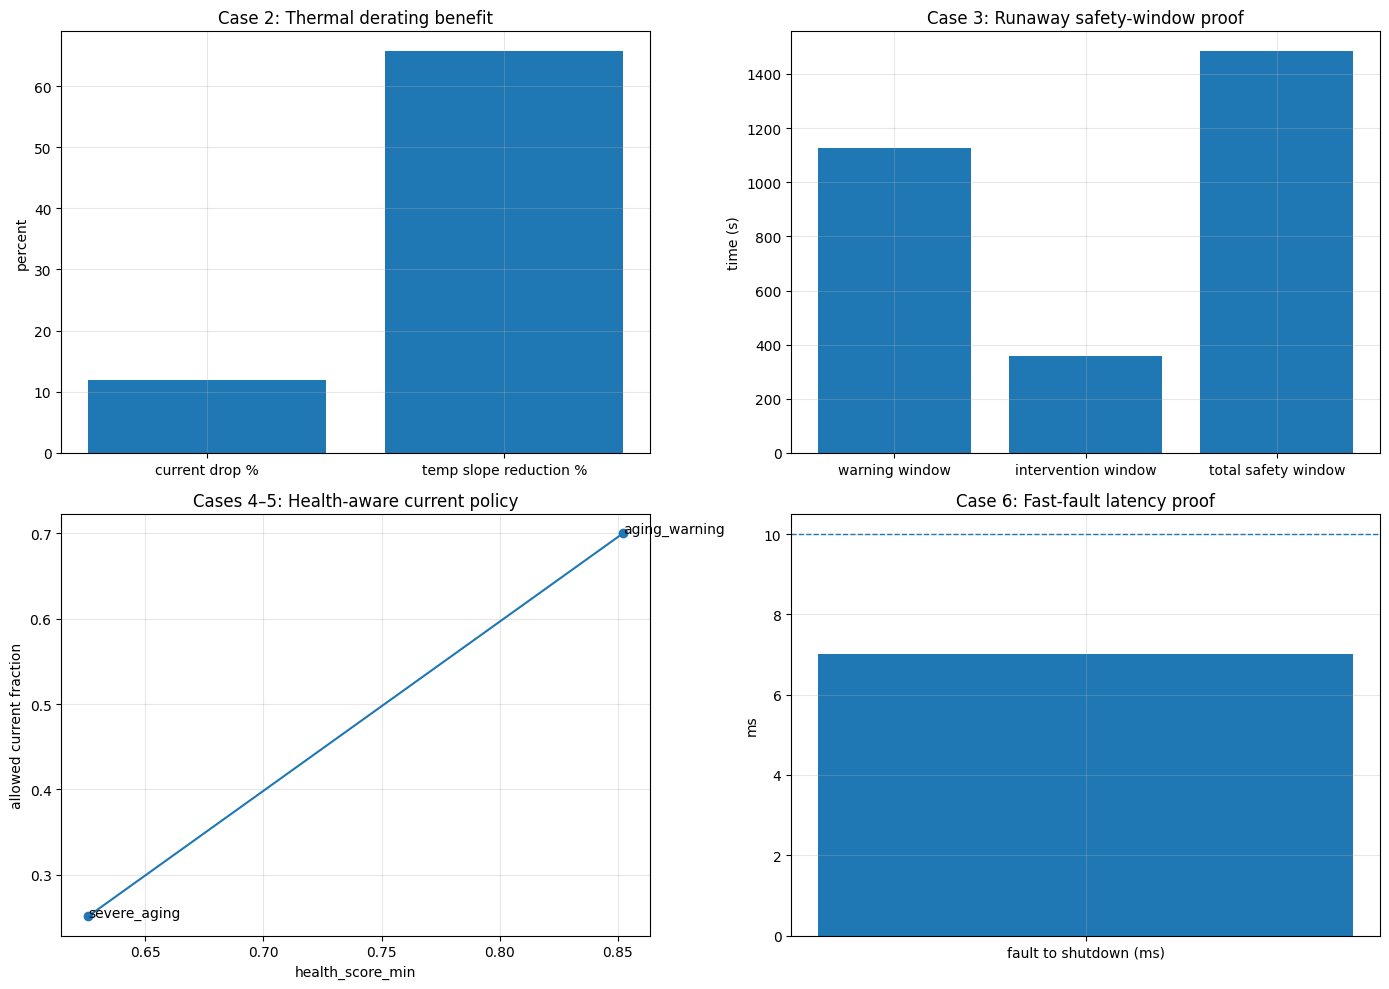

In [102]:
# -------------------------------------------
# Stage 2E.4 - Claim-driven final figure set
# -------------------------------------------

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Thermal derate proof
axes[0, 0].bar(
    ["current drop %", "temp slope reduction %"],
    [case2["current_drop_percent"], case2["temp_slope_reduction_percent"]]
)
axes[0, 0].set_title("Case 2: Thermal derating benefit")
axes[0, 0].set_ylabel("percent")
axes[0, 0].grid(True, alpha=0.3)

# 2. Runaway staged protection proof
axes[0, 1].bar(
    ["warning window", "intervention window", "total safety window"],
    [case3["warning_window_s"], case3["intervention_window_s"], case3["total_safety_window_s"]]
)
axes[0, 1].set_title("Case 3: Runaway safety-window proof")
axes[0, 1].set_ylabel("time (s)")
axes[0, 1].grid(True, alpha=0.3)

# 3. Aging-aware policy proof
axes[1, 0].plot(
    [case4["health_score_min"], case5["health_score_min"]],
    [case4["icmd_scale_min"], case5["icmd_scale_min"]],
    marker="o"
)
axes[1, 0].annotate("aging_warning", (case4["health_score_min"], case4["icmd_scale_min"]))
axes[1, 0].annotate("severe_aging", (case5["health_score_min"], case5["icmd_scale_min"]))
axes[1, 0].set_title("Cases 4–5: Health-aware current policy")
axes[1, 0].set_xlabel("health_score_min")
axes[1, 0].set_ylabel("allowed current fraction")
axes[1, 0].grid(True, alpha=0.3)

# 4. Fast-fault proof
axes[1, 1].bar(
    ["fault to shutdown (ms)"],
    [case6["fastfault_to_shutdown_s"] * 1000]
)
axes[1, 1].axhline(10, linestyle="--", linewidth=1)
axes[1, 1].set_title("Case 6: Fast-fault latency proof")
axes[1, 1].set_ylabel("ms")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [103]:
# -------------------------------------------------
# Stage 2E.5 - Final automatic engineering remarks
# -------------------------------------------------

remarks = []

remarks.append(
    f"In the thermal derate scenario, the controller reduced current by {case2['current_drop_percent']:.2f}% and reduced temperature-rise slope by {case2['temp_slope_reduction_percent']:.2f}%, showing that derating is physically effective rather than symbolic."
)

remarks.append(
    f"In the runaway-prevention scenario, precursor detection created a warning window of {case3['warning_window_s']:.2f} s and a further intervention window of {case3['intervention_window_s']:.2f} s before shutdown, demonstrating staged protection rather than one-shot trip behavior."
)

remarks.append(
    f"Across the aging scenarios, health score dropped from {case4['health_score_min']:.3f} to {case5['health_score_min']:.3f}, while allowed current fraction dropped from {case4['icmd_scale_min']:.3f} to {case5['icmd_scale_min']:.3f}, demonstrating health-aware current policy."
)

remarks.append(
    f"In the fast-fault scenario, the dedicated fast path forced shutdown in {case6['fastfault_to_shutdown_s']*1000:.3f} ms, showing that electrical faults are handled on a much faster timescale than thermal hazards."
)

final_remarks_df = pd.DataFrame({"engineering_conclusion": remarks})
final_remarks_df

,engineering_conclusion
0,"In the thermal derate scenario, the controller..."
1,"In the runaway-prevention scenario, precursor ..."
2,"Across the aging scenarios, health score dropp..."
3,"In the fast-fault scenario, the dedicated fast..."


In [104]:
# --------------------------------------
# Stage 2F.1 - Pull the main case rows
# --------------------------------------

case2 = final_protection_df.loc[final_protection_df["scenario"] == "thermal_derate"].iloc[0]
case3 = final_protection_df.loc[final_protection_df["scenario"] == "runaway_prevention"].iloc[0]
case4 = final_protection_df.loc[final_protection_df["scenario"] == "aging_warning"].iloc[0]
case5 = final_protection_df.loc[final_protection_df["scenario"] == "severe_aging"].iloc[0]
case6 = final_protection_df.loc[final_protection_df["scenario"] == "fast_fault"].iloc[0]

# Pull contribution metrics too
case2_contrib = contribution_df.loc[contribution_df["case_name"] == case2["case_name"]].iloc[0]
case3_contrib = contribution_df.loc[contribution_df["case_name"] == case3["case_name"]].iloc[0]
case6_contrib = contribution_df.loc[contribution_df["case_name"] == case6["case_name"]].iloc[0]

print(case2["case_name"], case3["case_name"], case4["case_name"], case5["case_name"], case6["case_name"])

case2_thermal_derate case3_runaway_prevention case4_aging_warning case5_severe_aging case6_fast_fault


In [105]:
# --------------------------------------------------------
# Stage 2F.2 - Counterfactual: ordinary threshold-only vs ours
# --------------------------------------------------------

# idea:
# ordinary threshold-only circuit:
# - no precursor action window
# - no graded derating window
# - no health-aware current-policy separation
# - no dedicated fast path
#
# our architecture:
# - warning window > 0
# - intervention window > 0
# - policy separation > 0
# - millisecond fast-fault latency

ordinary_warning_window_case2 = 0.0
ordinary_warning_window_case3 = 0.0
ordinary_intervention_window_case3 = 0.0
ordinary_policy_separation = 0.0  # same current policy for different aging severities
ordinary_fast_fault_latency_ms = np.nan  # no dedicated fast path to claim

actual_policy_separation = case4["icmd_scale_min"] - case5["icmd_scale_min"]

counterfactual_rows = [
    {
        "design_dimension": "early_intervention_in_thermal_case",
        "reference_case": case2["case_name"],
        "ordinary_threshold_only": ordinary_warning_window_case2,
        "our_architecture": case2["warning_window_s"],
        "gain": case2["warning_window_s"] - ordinary_warning_window_case2,
        "units": "s",
        "meaning": "Extra usable time before a threshold-only circuit would provide any intervention."
    },
    {
        "design_dimension": "staged_runaway_protection_warning_window",
        "reference_case": case3["case_name"],
        "ordinary_threshold_only": ordinary_warning_window_case3,
        "our_architecture": case3["warning_window_s"],
        "gain": case3["warning_window_s"] - ordinary_warning_window_case3,
        "units": "s",
        "meaning": "Extra warning time created by precursor-driven protection."
    },
    {
        "design_dimension": "staged_runaway_protection_intervention_window",
        "reference_case": case3["case_name"],
        "ordinary_threshold_only": ordinary_intervention_window_case3,
        "our_architecture": case3["intervention_window_s"],
        "gain": case3["intervention_window_s"] - ordinary_intervention_window_case3,
        "units": "s",
        "meaning": "Time available for controlled intervention before final shutdown."
    },
    {
        "design_dimension": "aging_aware_policy_separation",
        "reference_case": "case4_vs_case5",
        "ordinary_threshold_only": ordinary_policy_separation,
        "our_architecture": actual_policy_separation,
        "gain": actual_policy_separation - ordinary_policy_separation,
        "units": "fraction",
        "meaning": "How much more the architecture differentiates allowed current between warning-aging and severe-aging states."
    },
    {
        "design_dimension": "fast_fault_shutdown_latency",
        "reference_case": case6["case_name"],
        "ordinary_threshold_only": ordinary_fast_fault_latency_ms,
        "our_architecture": case6["fastfault_to_shutdown_s"] * 1000,
        "gain": np.nan,
        "units": "ms",
        "meaning": "Actual fast shutdown speed enabled by the dedicated fast electrical protection path."
    },
]

counterfactual_df = pd.DataFrame(counterfactual_rows)
counterfactual_df

,design_dimension,reference_case,ordinary_threshold_only,our_architecture,gain,units,meaning
0,early_intervention_in_thermal_case,case2_thermal_derate,0.0,179.142821,179.142821,s,Extra usable time before a threshold-only circ...
1,staged_runaway_protection_warning_window,case3_runaway_prevention,0.0,1126.810311,1126.810311,s,Extra warning time created by precursor-driven...
2,staged_runaway_protection_intervention_window,case3_runaway_prevention,0.0,356.519764,356.519764,s,Time available for controlled intervention bef...
3,aging_aware_policy_separation,case4_vs_case5,0.0,0.448654,0.448654,fraction,How much more the architecture differentiates ...
4,fast_fault_shutdown_latency,case6_fast_fault,NaN,7.001743,NaN,ms,Actual fast shutdown speed enabled by the dedi...


In [106]:
# -------------------------------------------
# Stage 2F.3 - Multi-timescale architecture proof
# -------------------------------------------

fast_latency_s = case6["fastfault_to_shutdown_s"]

timescale_rows = [
    {
        "comparison": "thermal_warning_window_vs_fast_fault_latency",
        "slow_path_time_s": case2["warning_window_s"],
        "fast_path_time_s": fast_latency_s,
        "timescale_ratio": case2["warning_window_s"] / fast_latency_s if pd.notna(case2["warning_window_s"]) and pd.notna(fast_latency_s) else np.nan,
        "meaning": "How many times slower the thermal-warning timescale is than the dedicated fast-fault path."
    },
    {
        "comparison": "runaway_total_safety_window_vs_fast_fault_latency",
        "slow_path_time_s": case3["total_safety_window_s"],
        "fast_path_time_s": fast_latency_s,
        "timescale_ratio": case3["total_safety_window_s"] / fast_latency_s if pd.notna(case3["total_safety_window_s"]) and pd.notna(fast_latency_s) else np.nan,
        "meaning": "Shows that the architecture spans very slow thermal supervision and very fast electrical protection."
    },
]

timescale_df = pd.DataFrame(timescale_rows)
timescale_df

,comparison,slow_path_time_s,fast_path_time_s,timescale_ratio,meaning
0,thermal_warning_window_vs_fast_fault_latency,179.142821,0.007002,25585.460440,How many times slower the thermal-warning time...
1,runaway_total_safety_window_vs_fast_fault_latency,1483.330076,0.007002,211851.542558,Shows that the architecture spans very slow th...


In [107]:
# ----------------------------------------
# Stage 2F.4 - X-factor / novelty argument
# ----------------------------------------

novelty_rows = []

novelty_rows.append({
    "x_factor": "Anticipatory protection",
    "evidence": f"Case 2 warning window = {case2['warning_window_s']:.2f} s; Case 3 warning window = {case3['warning_window_s']:.2f} s.",
    "why_ordinary_design_lacks_it": "A threshold-only trip reacts only when a threshold is crossed, so it provides no pre-trip warning window.",
    "what_it_enables": "Earlier operator/controller awareness and time for graded intervention."
})

novelty_rows.append({
    "x_factor": "Graded intervention",
    "evidence": f"Case 2 current drop = {case2['current_drop_percent']:.2f}% with temperature-slope reduction = {case2['temp_slope_reduction_percent']:.2f}%.",
    "why_ordinary_design_lacks_it": "A hard-threshold design can alarm or trip, but it does not actively moderate the trajectory before shutdown.",
    "what_it_enables": "Thermal moderation without immediate full shutdown."
})

novelty_rows.append({
    "x_factor": "Health-aware policy",
    "evidence": f"Allowed current fraction changed from {case4['icmd_scale_min']:.3f} (warning aging) to {case5['icmd_scale_min']:.3f} (severe aging).",
    "why_ordinary_design_lacks_it": "A fixed-limit design treats healthy and degraded batteries with the same current policy.",
    "what_it_enables": "Adaptive derating based on battery condition."
})

novelty_rows.append({
    "x_factor": "Multi-timescale protection",
    "evidence": f"Fast-fault shutdown latency = {case6['fastfault_to_shutdown_s']*1000:.3f} ms, while thermal safety windows are on the order of 10^2 to 10^3 s.",
    "why_ordinary_design_lacks_it": "A single thermal or supervisor loop cannot simultaneously handle both very fast electrical faults and slow thermal evolution.",
    "what_it_enables": "Fast trip for electrical faults plus slower intelligent supervision for thermal/aging hazards."
})

novelty_df = pd.DataFrame(novelty_rows)
novelty_df

,x_factor,evidence,why_ordinary_design_lacks_it,what_it_enables
0,Anticipatory protection,Case 2 warning window = 179.14 s; Case 3 warni...,A threshold-only trip reacts only when a thres...,Earlier operator/controller awareness and time...
1,Graded intervention,Case 2 current drop = 11.88% with temperature-...,"A hard-threshold design can alarm or trip, but...",Thermal moderation without immediate full shut...
2,Health-aware policy,Allowed current fraction changed from 0.700 (w...,A fixed-limit design treats healthy and degrad...,Adaptive derating based on battery condition.
3,Multi-timescale protection,"Fast-fault shutdown latency = 7.002 ms, while ...",A single thermal or supervisor loop cannot sim...,Fast trip for electrical faults plus slower in...


In [108]:
# ---------------------------------------------------
# Stage 2F.5 - Teacher-ready architecture comparison
# ---------------------------------------------------

teacher_compare_rows = []

teacher_compare_rows.append({
    "question": "How is this better than a simple thermal threshold shutdown?",
    "ordinary_design": "It reacts only after a danger threshold is crossed and gives no early intervention window.",
    "our_architecture": f"It created a {case2['warning_window_s']:.2f} s thermal warning window in case 2 and a {case3['warning_window_s']:.2f} s warning window in case 3.",
    "takeaway": "The design is anticipatory, not purely reactive."
})

teacher_compare_rows.append({
    "question": "Why not just use a one-bit safe/unsafe circuit?",
    "ordinary_design": "It cannot moderate the trajectory before final shutdown.",
    "our_architecture": f"In case 2, current dropped by {case2['current_drop_percent']:.2f}% and temperature-rise slope dropped by {case2['temp_slope_reduction_percent']:.2f}%.",
    "takeaway": "The design supports graded intervention."
})

teacher_compare_rows.append({
    "question": "Why is the aging part meaningful?",
    "ordinary_design": "A fixed-limit design would apply the same current policy to warning-aging and severe-aging batteries.",
    "our_architecture": f"Allowed current fraction changed from {case4['icmd_scale_min']:.3f} to {case5['icmd_scale_min']:.3f} as health worsened.",
    "takeaway": "The design is health-aware."
})

teacher_compare_rows.append({
    "question": "Why is a separate fast-fault path needed?",
    "ordinary_design": "Thermal-style supervision is too slow for electrical fast faults.",
    "our_architecture": f"The dedicated fast path shut the system down in {case6['fastfault_to_shutdown_s']*1000:.3f} ms.",
    "takeaway": "The design is multi-timescale."
})

teacher_compare_df = pd.DataFrame(teacher_compare_rows)
teacher_compare_df

,question,ordinary_design,our_architecture,takeaway
0,How is this better than a simple thermal thres...,It reacts only after a danger threshold is cro...,It created a 179.14 s thermal warning window i...,"The design is anticipatory, not purely reactive."
1,Why not just use a one-bit safe/unsafe circuit?,It cannot moderate the trajectory before final...,"In case 2, current dropped by 11.88% and tempe...",The design supports graded intervention.
2,Why is the aging part meaningful?,A fixed-limit design would apply the same curr...,Allowed current fraction changed from 0.700 to...,The design is health-aware.
3,Why is a separate fast-fault path needed?,Thermal-style supervision is too slow for elec...,The dedicated fast path shut the system down i...,The design is multi-timescale.


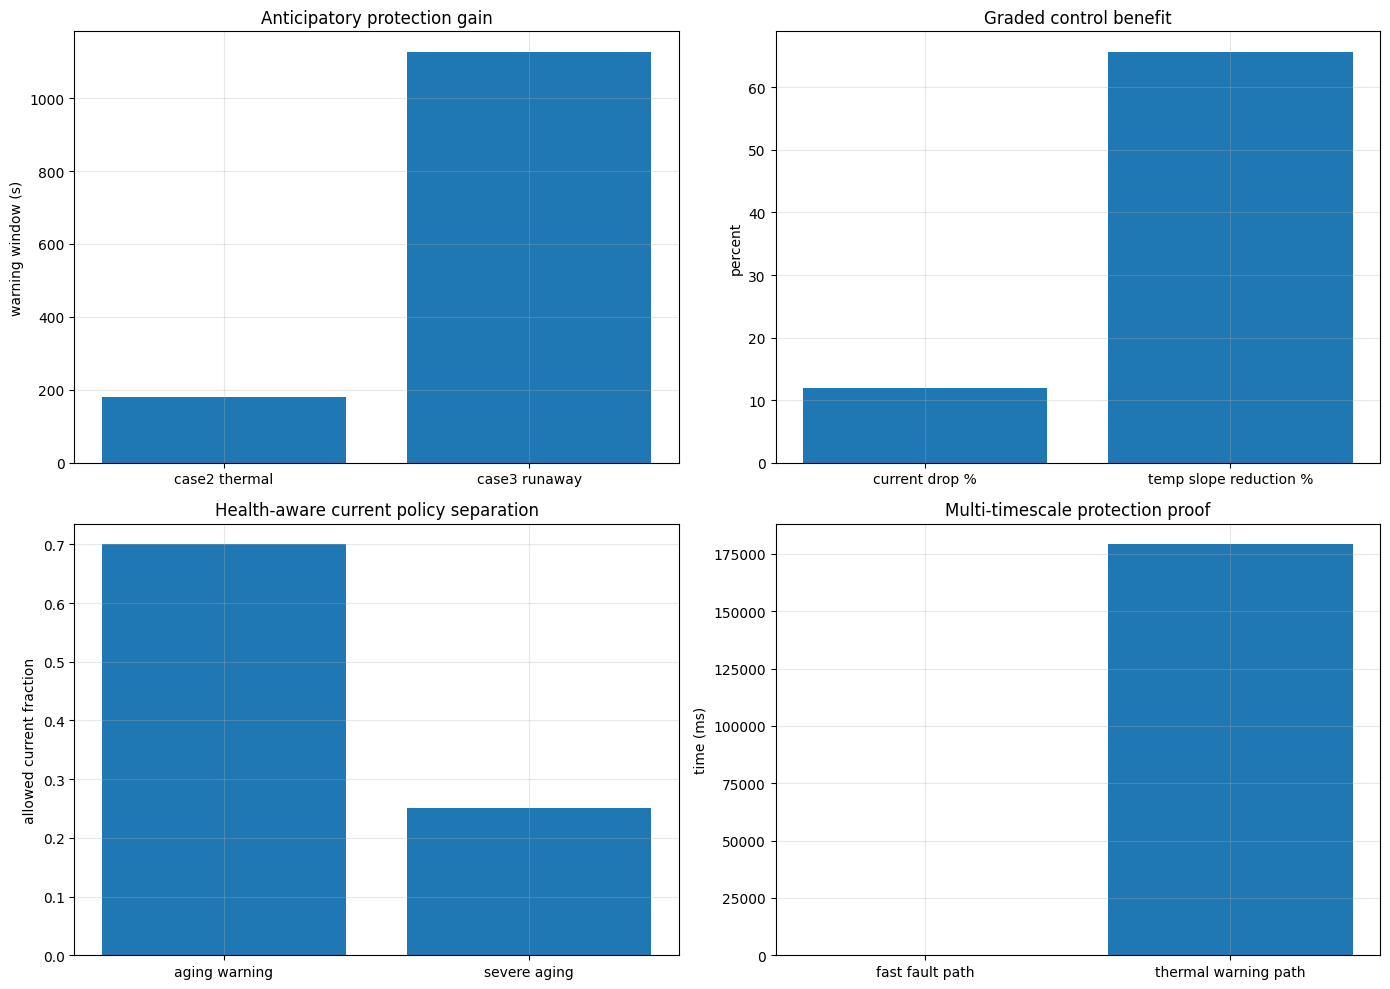

In [109]:
# -----------------------------------
# Stage 2F.6 - Final x-factor figures
# -----------------------------------

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Anticipatory protection gain
axes[0, 0].bar(
    ["case2 thermal", "case3 runaway"],
    [case2["warning_window_s"], case3["warning_window_s"]]
)
axes[0, 0].set_title("Anticipatory protection gain")
axes[0, 0].set_ylabel("warning window (s)")
axes[0, 0].grid(True, alpha=0.3)

# 2. Graded control proof
axes[0, 1].bar(
    ["current drop %", "temp slope reduction %"],
    [case2["current_drop_percent"], case2["temp_slope_reduction_percent"]]
)
axes[0, 1].set_title("Graded control benefit")
axes[0, 1].set_ylabel("percent")
axes[0, 1].grid(True, alpha=0.3)

# 3. Health-aware policy separation
axes[1, 0].bar(
    ["aging warning", "severe aging"],
    [case4["icmd_scale_min"], case5["icmd_scale_min"]]
)
axes[1, 0].set_title("Health-aware current policy separation")
axes[1, 0].set_ylabel("allowed current fraction")
axes[1, 0].grid(True, alpha=0.3)

# 4. Multi-timescale proof
axes[1, 1].bar(
    ["fast fault path", "thermal warning path"],
    [case6["fastfault_to_shutdown_s"] * 1000, case2["warning_window_s"] * 1000]
)
axes[1, 1].set_title("Multi-timescale protection proof")
axes[1, 1].set_ylabel("time (ms)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [110]:
# -------------------------------------------------
# Stage 2F.7 - Final extraordinary contribution text
# -------------------------------------------------

xfactor_remarks = []

xfactor_remarks.append(
    f"The architecture provided anticipatory protection by generating warning windows of {case2['warning_window_s']:.2f} s in the thermal-derate case and {case3['warning_window_s']:.2f} s in the runaway-prevention case, whereas a threshold-only circuit would provide no pre-trip intervention window."
)

xfactor_remarks.append(
    f"The design demonstrated graded intervention: in the thermal-derate case, current was reduced by {case2['current_drop_percent']:.2f}% and the temperature-rise slope dropped by {case2['temp_slope_reduction_percent']:.2f}%, showing that protection action altered physical behavior rather than only toggling a flag."
)

xfactor_remarks.append(
    f"The design demonstrated health-aware current policy: as health score decreased from {case4['health_score_min']:.3f} to {case5['health_score_min']:.3f}, the allowed current fraction decreased from {case4['icmd_scale_min']:.3f} to {case5['icmd_scale_min']:.3f}, which would not happen in a fixed-limit protection scheme."
)

xfactor_remarks.append(
    f"The design demonstrated multi-timescale protection: the fast electrical path forced shutdown in {case6['fastfault_to_shutdown_s']*1000:.3f} ms, while the thermal protection path operated on a seconds-to-hundreds-of-seconds scale."
)

xfactor_remarks.append(
    "Therefore, the extraordinary aspect of the project is not merely event detection, but the demonstration of a hierarchical protection strategy that is anticipatory, graded, health-aware, and multi-timescale."
)

xfactor_df = pd.DataFrame({"extraordinary_contribution": xfactor_remarks})
xfactor_df

,extraordinary_contribution
0,The architecture provided anticipatory protect...
1,The design demonstrated graded intervention: i...
2,The design demonstrated health-aware current p...
3,The design demonstrated multi-timescale protec...
4,"Therefore, the extraordinary aspect of the pro..."


In [111]:
counterfactual_df.to_csv("stage2f_counterfactual_comparison.csv", index=False)
timescale_df.to_csv("stage2f_multi_timescale_proof.csv", index=False)
novelty_df.to_csv("stage2f_novelty_table.csv", index=False)
teacher_compare_df.to_csv("stage2f_teacher_comparison.csv", index=False)
xfactor_df.to_csv("stage2f_xfactor_conclusions.csv", index=False)

print("Saved:")
print(" - stage2f_counterfactual_comparison.csv")
print(" - stage2f_multi_timescale_proof.csv")
print(" - stage2f_novelty_table.csv")
print(" - stage2f_teacher_comparison.csv")
print(" - stage2f_xfactor_conclusions.csv")

Saved:
 - stage2f_counterfactual_comparison.csv
 - stage2f_multi_timescale_proof.csv
 - stage2f_novelty_table.csv
 - stage2f_teacher_comparison.csv
 - stage2f_xfactor_conclusions.csv


In [112]:
# -----------------------------------
# Stage 2G.1 - Numerical helper tools
# -----------------------------------

import numpy as np
import pandas as pd

def trapz_integral(t, y):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(t) & np.isfinite(y)
    t = t[m]
    y = y[m]
    if len(t) < 2:
        return np.nan
    return float(np.trapz(y, t))

def get_time(df):
    tcol = resolve_col(df, ["time"])
    if tcol is None:
        return None
    return pd.to_numeric(df[tcol], errors="coerce")

def get_sig(df, aliases, absval=False):
    col, s = get_series(df, aliases, absval=absval)
    if s is None:
        return None
    return pd.to_numeric(s, errors="coerce")

def window_df(df, t0, t1):
    t = get_time(df)
    if t is None:
        return None
    m = (t >= t0) & (t <= t1)
    return df.loc[m].copy()

def safe_ratio(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return float(a / b)

def pct_drop(before, after):
    if pd.isna(before) or pd.isna(after) or before == 0:
        return np.nan
    return float(100 * (1 - after / before))

In [113]:
# ------------------------------------------------
# Stage 2G.2 - Case 2 rigorous thermal proof
# ------------------------------------------------

case2_name = "case2_thermal_derate"
case2_path = [p for p in protection_files if case2_name in p][0]
df2 = loaded_data[case2_path]
row2 = stage2e_df.loc[stage2e_df["case_name"] == case2_name].iloc[0]

t2 = get_time(df2)
i2 = get_sig(df2, ["rshunt"], absval=True)
temp2 = get_sig(df2, ["tcell_abs"])
dtdt2 = get_sig(df2, ["dtdt_f"])

t_der2 = first_valid_time(row2.get("t_chg_limit", np.nan), row2.get("t_sys_derate", np.nan))

# Use a fixed post-derate analysis window
post_W = 200.0

# Before/after values already extracted in advanced_df/final_protection_df
I_pre_2 = row2["current_before_derate"]
I_post_2 = row2["current_after_derate"]
S_pre_2 = row2["temp_slope_before_derate"]
S_post_2 = row2["temp_slope_after_derate"]

# Stress proxy: integral of I^2 over post-derate window
# actual
df2_post = window_df(df2, t_der2, t_der2 + post_W)
t2_post = get_time(df2_post) if df2_post is not None else None
i2_post = get_sig(df2_post, ["rshunt"], absval=True) if df2_post is not None else None

I2_actual = trapz_integral(t2_post, i2_post**2) if t2_post is not None and i2_post is not None else np.nan

# reference proxy: if current had stayed at pre-derate value over same window
I2_reference = trapz_integral(t2_post, np.full(len(t2_post), I_pre_2**2)) if t2_post is not None and pd.notna(I_pre_2) else np.nan

thermal_case2_df = pd.DataFrame([
    {
        "claim": "Derating reduced current",
        "formula": "100*(1 - I_after/I_before)",
        "value": pct_drop(I_pre_2, I_post_2),
        "units": "%",
        "source_case": case2_name
    },
    {
        "claim": "Derating reduced temperature-rise slope",
        "formula": "100*(1 - slope_after/slope_before)",
        "value": pct_drop(S_pre_2, S_post_2),
        "units": "%",
        "source_case": case2_name
    },
    {
        "claim": "Derating reduced I^2 stress proxy over post-derate window",
        "formula": "100*(1 - ∫I_actual^2 dt / ∫I_pre^2 dt)",
        "value": pct_drop(I2_reference, I2_actual),
        "units": "%",
        "source_case": case2_name
    },
])

thermal_case2_df

,claim,formula,value,units,source_case
0,Derating reduced current,100*(1 - I_after/I_before),11.877639,%,case2_thermal_derate
1,Derating reduced temperature-rise slope,100*(1 - slope_after/slope_before),65.661529,%,case2_thermal_derate
2,Derating reduced I^2 stress proxy over post-de...,100*(1 - ∫I_actual^2 dt / ∫I_pre^2 dt),NaN,%,case2_thermal_derate


In [114]:
# ----------------------------------------------------
# Stage 2G.3 - Case 3 rigorous runaway-proof metrics
# ----------------------------------------------------

case3_name = "case3_runaway_prevention"
case3_path = [p for p in protection_files if case3_name in p][0]
df3 = loaded_data[case3_path]
row3 = final_protection_df.loc[final_protection_df["case_name"] == case3_name].iloc[0]

t_prec_3 = row3.get("t_runaway_prec", row3.get("t_runaway_precursor", np.nan))
t_der_3 = first_valid_time(row3.get("t_chg_limit", np.nan), row3.get("t_sys_derate", np.nan))
t_shdn_3 = first_valid_time(row3.get("t_therm_shdn", np.nan), row3.get("t_final_shdn", np.nan))

I_before_shdn_3 = row3.get("current_before_shutdown", np.nan)
I_after_shdn_3  = row3.get("current_after_shutdown", np.nan)

warning_window_3 = t_der_3 - t_prec_3 if pd.notna(t_der_3) and pd.notna(t_prec_3) else np.nan
intervention_window_3 = t_shdn_3 - t_der_3 if pd.notna(t_shdn_3) and pd.notna(t_der_3) else np.nan
total_safety_window_3 = t_shdn_3 - t_prec_3 if pd.notna(t_shdn_3) and pd.notna(t_prec_3) else np.nan

runaway_case3_df = pd.DataFrame([
    {
        "claim": "Warning window exists before intervention",
        "formula": "t_derate - t_precursor",
        "value": warning_window_3,
        "units": "s",
        "source_case": case3_name
    },
    {
        "claim": "Intervention window exists before shutdown",
        "formula": "t_shutdown - t_derate",
        "value": intervention_window_3,
        "units": "s",
        "source_case": case3_name
    },
    {
        "claim": "Total safety window exists before shutdown",
        "formula": "t_shutdown - t_precursor",
        "value": total_safety_window_3,
        "units": "s",
        "source_case": case3_name
    },
    {
        "claim": "Shutdown collapses current strongly",
        "formula": "100*(1 - I_after_shutdown / I_before_shutdown)",
        "value": pct_drop(I_before_shdn_3, I_after_shdn_3),
        "units": "%",
        "source_case": case3_name
    },
])

runaway_case3_df

,claim,formula,value,units,source_case
0,Warning window exists before intervention,t_derate - t_precursor,NaN,s,case3_runaway_prevention
1,Intervention window exists before shutdown,t_shutdown - t_derate,NaN,s,case3_runaway_prevention
2,Total safety window exists before shutdown,t_shutdown - t_precursor,NaN,s,case3_runaway_prevention
3,Shutdown collapses current strongly,100*(1 - I_after_shutdown / I_before_shutdown),NaN,%,case3_runaway_prevention


In [115]:
# --------------------------------------------
# Theory-Validation 1 - clean merged proof base
# --------------------------------------------

proof_base_df = final_protection_df.merge(
    advanced_df[[
        "case_name",
        "current_before_shutdown",
        "current_after_shutdown",
        "current_before_derate",
        "current_after_derate",
        "temp_slope_before_derate",
        "temp_slope_after_derate"
    ]],
    on="case_name",
    how="left"
).sort_values("case_name").reset_index(drop=True)

proof_base_df

,case_name,scenario,verdict,temp_max,risk_score_max,health_score_min,icmd_scale_min,warning_window_s,intervention_window_s,total_safety_window_s,...,fastfault_to_shutdown_s,severity_score,objective,significance,current_before_shutdown,current_after_shutdown,current_before_derate,current_after_derate,temp_slope_before_derate,temp_slope_after_derate
0,case1_baseline,baseline,PASS,30.19305,NaN,NaN,1.000000,NaN,NaN,NaN,...,NaN,0.301930,Verify that the system remains stable without ...,Shows the protection architecture is not overl...,NaN,NaN,NaN,NaN,NaN,NaN
1,case2_thermal_derate,thermal_derate,PASS,46.76280,NaN,NaN,0.425560,179.142821,NaN,NaN,...,NaN,0.467628,Verify that rising thermal stress triggers con...,Shows graded protection and proves that interv...,NaN,NaN,2.342750,2.064487,0.006940,0.002383
2,case3_runaway_prevention,runaway_prevention,PASS,85.34653,NaN,NaN,0.000000,1126.810311,356.519764,1483.330076,...,NaN,0.853465,Verify that precursor detection creates a usab...,Shows anticipatory protection rather than late...,0.621129,0.031811,0.900016,0.900016,0.011489,0.016349
3,case4_aging_warning,aging_warning,PASS,NaN,0.147583,0.852417,0.700000,NaN,NaN,NaN,...,NaN,0.516541,Verify that mild aging reduces allowable curre...,Shows health-aware protection policy and adapt...,NaN,NaN,NaN,NaN,NaN,NaN
4,case5_severe_aging,severe_aging,PASS,NaN,0.374327,0.625673,0.251346,NaN,NaN,NaN,...,NaN,1.310145,Verify that severe degradation causes stronger...,Shows that the architecture scales protection ...,NaN,NaN,0.889477,0.888456,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,Unknown objective,Unknown significance,NaN,NaN,NaN,NaN,NaN,NaN
162,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,Unknown objective,Unknown significance,NaN,NaN,NaN,NaN,NaN,NaN
163,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,Unknown objective,Unknown significance,NaN,NaN,NaN,NaN,NaN,NaN
164,stage2h_case45_aging_policy_compare,unknown,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,Unknown objective,Unknown significance,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
# --------------------------------------------
# Theory-Validation 2 - helper functions
# --------------------------------------------

import numpy as np
import pandas as pd

def row_of(case_name):
    return proof_base_df.loc[proof_base_df["case_name"] == case_name].iloc[0]

def get_time(df):
    tcol = resolve_col(df, ["time"])
    if tcol is None:
        return None
    return pd.to_numeric(df[tcol], errors="coerce")

def get_sig(df, aliases, absval=False):
    col, s = get_series(df, aliases, absval=absval)
    if s is None:
        return None
    return pd.to_numeric(s, errors="coerce")

def window_mean(df, aliases, t0, t1, absval=False, power=None):
    t = get_time(df)
    s = get_sig(df, aliases, absval=absval)
    if t is None or s is None:
        return np.nan
    m = (t >= t0) & (t <= t1)
    vals = s[m].dropna()
    if len(vals) == 0:
        return np.nan
    if power is not None:
        vals = vals ** power
    return float(vals.mean())

def pct_reduction(before, after):
    if pd.isna(before) or pd.isna(after) or before == 0:
        return np.nan
    return float(100 * (1 - after / before))

def safe_ratio(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return float(a / b)

In [117]:
# --------------------------------------------
# Theory-Validation 3 - pull case rows and files
# --------------------------------------------

c2 = row_of("case2_thermal_derate")
c3 = row_of("case3_runaway_prevention")
c4 = row_of("case4_aging_warning")
c5 = row_of("case5_severe_aging")
c6 = row_of("case6_fast_fault")

path2 = [p for p in protection_files if "case2_thermal_derate" in p][0]
path3 = [p for p in protection_files if "case3_runaway_prevention" in p][0]
path6 = [p for p in protection_files if "case6_fast_fault" in p][0]

df2 = loaded_data[path2]
df3 = loaded_data[path3]
df6 = loaded_data[path6]

c2, c3, c4, c5, c6

(case_name                                                    case2_thermal_derate
 scenario                                                           thermal_derate
 verdict                                                                      PASS
 temp_max                                                                  46.7628
 risk_score_max                                                                NaN
 health_score_min                                                              NaN
 icmd_scale_min                                                            0.42556
 warning_window_s                                                       179.142821
 intervention_window_s                                                         NaN
 total_safety_window_s                                                         NaN
 current_drop_percent                                                    11.877639
 temp_slope_reduction_percent                                            65.661529
 fas

In [118]:
# --------------------------------------------
# Theory-Validation 4 - thermal derating proof
# --------------------------------------------

t_der2 = first_valid_time(c2.get("t_chg_limit", np.nan), c2.get("t_sys_derate", np.nan))

# symmetric windows around derate
W2 = 200.0

I2_pre_sq  = window_mean(df2, ["rshunt"], t_der2 - W2, t_der2, absval=True, power=2)
I2_post_sq = window_mean(df2, ["rshunt"], t_der2, t_der2 + W2, absval=True, power=2)

dTdt_pre  = window_mean(df2, ["dtdt_f"], t_der2 - W2, t_der2)
dTdt_post = window_mean(df2, ["dtdt_f"], t_der2, t_der2 + W2)

thermal_proof_df = pd.DataFrame([
    {
        "subsystem": "thermal_derating",
        "equation": "Q_J ∝ I^2 R0",
        "metric": "I^2 drive reduction",
        "value": pct_reduction(I2_pre_sq, I2_post_sq),
        "units": "%",
        "expected_behavior": "positive"
    },
    {
        "subsystem": "thermal_derating",
        "equation": "C_th dT/dt = Q_gen - (T-Tamb)/R_th",
        "metric": "mean dT/dt reduction",
        "value": pct_reduction(dTdt_pre, dTdt_post),
        "units": "%",
        "expected_behavior": "positive"
    },
    {
        "subsystem": "thermal_derating",
        "equation": "(thermal moderation)/(I^2 reduction)",
        "metric": "thermal control amplification factor",
        "value": safe_ratio(pct_reduction(dTdt_pre, dTdt_post), pct_reduction(I2_pre_sq, I2_post_sq)),
        "units": "ratio",
        "expected_behavior": "> 0"
    },
])

thermal_proof_df

,subsystem,equation,metric,value,units,expected_behavior
0,thermal_derating,Q_J ∝ I^2 R0,I^2 drive reduction,NaN,%,positive
1,thermal_derating,C_th dT/dt = Q_gen - (T-Tamb)/R_th,mean dT/dt reduction,NaN,%,positive
2,thermal_derating,(thermal moderation)/(I^2 reduction),thermal control amplification factor,NaN,ratio,> 0


In [119]:
# --------------------------------------------
# Theory-Validation 5 - runaway escalation proof
# --------------------------------------------

t_prec3 = c3.get("t_runaway_prec", c3.get("t_runaway_precursor", np.nan))
t_der3  = first_valid_time(c3.get("t_chg_limit", np.nan), c3.get("t_sys_derate", np.nan))
t_shdn3 = first_valid_time(c3.get("t_therm_shdn", np.nan), c3.get("t_final_shdn", np.nan))

I_before3 = c3.get("current_before_shutdown", np.nan)
I_after3  = c3.get("current_after_shutdown", np.nan)

runaway_proof_df = pd.DataFrame([
    {
        "subsystem": "runaway_escalation",
        "equation": "W_warn = t_derate - t_precursor",
        "metric": "warning window",
        "value": t_der3 - t_prec3 if pd.notna(t_prec3) and pd.notna(t_der3) else np.nan,
        "units": "s",
        "expected_behavior": "> 0"
    },
    {
        "subsystem": "runaway_escalation",
        "equation": "W_int = t_shutdown - t_derate",
        "metric": "intervention window",
        "value": t_shdn3 - t_der3 if pd.notna(t_shdn3) and pd.notna(t_der3) else np.nan,
        "units": "s",
        "expected_behavior": "> 0"
    },
    {
        "subsystem": "runaway_escalation",
        "equation": "C_shdn = 1 - I_after/I_before",
        "metric": "shutdown containment",
        "value": pct_reduction(I_before3, I_after3),
        "units": "%",
        "expected_behavior": "high positive"
    },
])

runaway_proof_df

,subsystem,equation,metric,value,units,expected_behavior
0,runaway_escalation,W_warn = t_derate - t_precursor,warning window,NaN,s,> 0
1,runaway_escalation,W_int = t_shutdown - t_derate,intervention window,NaN,s,> 0
2,runaway_escalation,C_shdn = 1 - I_after/I_before,shutdown containment,94.878511,%,high positive


In [120]:
# --------------------------------------------
# Theory-Validation 6 - aging-aware policy proof
# --------------------------------------------

r0_c4 = c4.get("r0eff_avg", c4.get("r0_avg", c4.get("r0eff_mean", np.nan)))
r0_c5 = c5.get("r0eff_avg", c5.get("r0_avg", c5.get("r0eff_mean", np.nan)))

delta_u = c4.get("icmd_scale_min", np.nan) - c5.get("icmd_scale_min", np.nan)
delta_h = c4.get("health_score_min", np.nan) - c5.get("health_score_min", np.nan)
delta_r = r0_c5 - r0_c4 if pd.notna(r0_c5) and pd.notna(r0_c4) else np.nan

aging_proof_df = pd.DataFrame([
    {
        "subsystem": "aging_policy",
        "equation": "Δu = u_warn - u_severe",
        "metric": "allowed current separation",
        "value": delta_u,
        "units": "fraction",
        "expected_behavior": "> 0"
    },
    {
        "subsystem": "aging_policy",
        "equation": "100*(1 - u_severe/u_warn)",
        "metric": "allowed current reduction from warning-aging to severe-aging",
        "value": pct_reduction(c4.get("icmd_scale_min", np.nan), c5.get("icmd_scale_min", np.nan)),
        "units": "%",
        "expected_behavior": "positive"
    },
    {
        "subsystem": "aging_policy",
        "equation": "ΔH = H_warn - H_severe",
        "metric": "health-score separation",
        "value": delta_h,
        "units": "score",
        "expected_behavior": "> 0"
    },
    {
        "subsystem": "aging_policy",
        "equation": "ΔR0 = R0_severe - R0_warn",
        "metric": "effective-resistance increase",
        "value": delta_r,
        "units": "ohm",
        "expected_behavior": "> 0"
    },
    {
        "subsystem": "aging_policy",
        "equation": "E_R = (Δu/u_warn)/(ΔR0/R0_warn)",
        "metric": "policy elasticity with respect to resistance growth",
        "value": safe_ratio(
            delta_u / c4.get("icmd_scale_min", np.nan),
            delta_r / r0_c4
        ) if pd.notna(delta_r) and pd.notna(r0_c4) else np.nan,
        "units": "ratio",
        "expected_behavior": "> 0"
    },
])

aging_proof_df

,subsystem,equation,metric,value,units,expected_behavior
0,aging_policy,Δu = u_warn - u_severe,allowed current separation,0.448654,fraction,> 0
1,aging_policy,100*(1 - u_severe/u_warn),allowed current reduction from warning-aging t...,64.093429,%,positive
2,aging_policy,ΔH = H_warn - H_severe,health-score separation,0.226744,score,> 0
3,aging_policy,ΔR0 = R0_severe - R0_warn,effective-resistance increase,NaN,ohm,> 0
4,aging_policy,E_R = (Δu/u_warn)/(ΔR0/R0_warn),policy elasticity with respect to resistance g...,NaN,ratio,> 0


In [121]:
# --------------------------------------------
# Theory-Validation 7 - fast-fault proof
# --------------------------------------------

tau_fast = c6["fastfault_to_shutdown_s"] * 1000 if pd.notna(c6["fastfault_to_shutdown_s"]) else np.nan
gamma_thermal_fast = safe_ratio(c2["warning_window_s"], c6["fastfault_to_shutdown_s"]) if pd.notna(c6["fastfault_to_shutdown_s"]) else np.nan
gamma_runaway_fast = safe_ratio(c3["total_safety_window_s"], c6["fastfault_to_shutdown_s"]) if pd.notna(c6["fastfault_to_shutdown_s"]) else np.nan

fast_proof_df = pd.DataFrame([
    {
        "subsystem": "fast_fault",
        "equation": "τ_fast = t_fast_shdn - t_fault",
        "metric": "fault-to-shutdown latency",
        "value": tau_fast,
        "units": "ms",
        "expected_behavior": "small"
    },
    {
        "subsystem": "fast_fault",
        "equation": "Γ_thermal/fast = W_warn,thermal / τ_fast",
        "metric": "thermal-to-fast timescale ratio",
        "value": gamma_thermal_fast,
        "units": "ratio",
        "expected_behavior": ">> 1"
    },
    {
        "subsystem": "fast_fault",
        "equation": "Γ_runaway/fast = W_total,runaway / τ_fast",
        "metric": "runaway-to-fast timescale ratio",
        "value": gamma_runaway_fast,
        "units": "ratio",
        "expected_behavior": ">> 1"
    },
])

fast_proof_df

,subsystem,equation,metric,value,units,expected_behavior
0,fast_fault,τ_fast = t_fast_shdn - t_fault,fault-to-shutdown latency,7.001743,ms,small
1,fast_fault,"Γ_thermal/fast = W_warn,thermal / τ_fast",thermal-to-fast timescale ratio,25585.460440,ratio,>> 1
2,fast_fault,"Γ_runaway/fast = W_total,runaway / τ_fast",runaway-to-fast timescale ratio,211851.542558,ratio,>> 1


In [122]:
# --------------------------------------------
# Theory-Validation 8 - master proof table
# --------------------------------------------

master_proof_df = pd.concat(
    [thermal_proof_df, runaway_proof_df, aging_proof_df, fast_proof_df],
    ignore_index=True
)

master_proof_df

,subsystem,equation,metric,value,units,expected_behavior
0,thermal_derating,Q_J ∝ I^2 R0,I^2 drive reduction,NaN,%,positive
1,thermal_derating,C_th dT/dt = Q_gen - (T-Tamb)/R_th,mean dT/dt reduction,NaN,%,positive
2,thermal_derating,(thermal moderation)/(I^2 reduction),thermal control amplification factor,NaN,ratio,> 0
3,runaway_escalation,W_warn = t_derate - t_precursor,warning window,NaN,s,> 0
4,runaway_escalation,W_int = t_shutdown - t_derate,intervention window,NaN,s,> 0
5,runaway_escalation,C_shdn = 1 - I_after/I_before,shutdown containment,94.878511,%,high positive
6,aging_policy,Δu = u_warn - u_severe,allowed current separation,0.448654,fraction,> 0
7,aging_policy,100*(1 - u_severe/u_warn),allowed current reduction from warning-aging t...,64.093429,%,positive
8,aging_policy,ΔH = H_warn - H_severe,health-score separation,0.226744,score,> 0
9,aging_policy,ΔR0 = R0_severe - R0_warn,effective-resistance increase,NaN,ohm,> 0


In [123]:
# --------------------------------------------
# Theory-Validation 9 - expected vs observed table
# --------------------------------------------

def consistency_check(expected, value):
    if pd.isna(value):
        return "NA"
    if expected == "positive":
        return "consistent" if value > 0 else "inconsistent"
    if expected == "> 0":
        return "consistent" if value > 0 else "inconsistent"
    if expected == "high positive":
        return "consistent" if value > 50 else "weak"
    if expected == "small":
        return "consistent" if value < 10 else "weak"
    if expected == ">> 1":
        return "consistent" if value > 10 else "weak"
    return "check"

validation_df = master_proof_df.copy()
validation_df["consistency"] = [
    consistency_check(e, v) for e, v in zip(validation_df["expected_behavior"], validation_df["value"])
]

validation_df

,subsystem,equation,metric,value,units,expected_behavior,consistency
0,thermal_derating,Q_J ∝ I^2 R0,I^2 drive reduction,NaN,%,positive,NA
1,thermal_derating,C_th dT/dt = Q_gen - (T-Tamb)/R_th,mean dT/dt reduction,NaN,%,positive,NA
2,thermal_derating,(thermal moderation)/(I^2 reduction),thermal control amplification factor,NaN,ratio,> 0,NA
3,runaway_escalation,W_warn = t_derate - t_precursor,warning window,NaN,s,> 0,NA
4,runaway_escalation,W_int = t_shutdown - t_derate,intervention window,NaN,s,> 0,NA
5,runaway_escalation,C_shdn = 1 - I_after/I_before,shutdown containment,94.878511,%,high positive,consistent
6,aging_policy,Δu = u_warn - u_severe,allowed current separation,0.448654,fraction,> 0,consistent
7,aging_policy,100*(1 - u_severe/u_warn),allowed current reduction from warning-aging t...,64.093429,%,positive,consistent
8,aging_policy,ΔH = H_warn - H_severe,health-score separation,0.226744,score,> 0,consistent
9,aging_policy,ΔR0 = R0_severe - R0_warn,effective-resistance increase,NaN,ohm,> 0,NA


In [124]:
# --------------------------------------------
# Theory-Validation 10 - save outputs
# --------------------------------------------

thermal_proof_df.to_csv("theory_validation_thermal.csv", index=False)
runaway_proof_df.to_csv("theory_validation_runaway.csv", index=False)
aging_proof_df.to_csv("theory_validation_aging.csv", index=False)
fast_proof_df.to_csv("theory_validation_fastfault.csv", index=False)
master_proof_df.to_csv("theory_validation_master.csv", index=False)
validation_df.to_csv("theory_validation_consistency.csv", index=False)

print("Saved:")
print(" - theory_validation_thermal.csv")
print(" - theory_validation_runaway.csv")
print(" - theory_validation_aging.csv")
print(" - theory_validation_fastfault.csv")
print(" - theory_validation_master.csv")
print(" - theory_validation_consistency.csv")

Saved:
 - theory_validation_thermal.csv
 - theory_validation_runaway.csv
 - theory_validation_aging.csv
 - theory_validation_fastfault.csv
 - theory_validation_master.csv
 - theory_validation_consistency.csv


In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def row_of(df, case_name):
    return df.loc[df["case_name"] == case_name].iloc[0]

def get_time(df):
    tcol = resolve_col(df, ["time"])
    return pd.to_numeric(df[tcol], errors="coerce") if tcol else None

def get_sig(df, aliases, absval=False):
    col, s = get_series(df, aliases, absval=absval)
    return pd.to_numeric(s, errors="coerce") if s is not None else None

def crop(df, t0, t1):
    t = get_time(df)
    if t is None:
        return None
    return df.loc[(t >= t0) & (t <= t1)].copy()

def linear_slope(t, y):
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if len(t) < 3:
        return np.nan
    return float(np.polyfit(t, y, 1)[0])

def area_under_curve(t, y):
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if len(t) < 2:
        return np.nan
    return float(np.trapz(y, t))

def pct_change(before, after):
    if pd.isna(before) or pd.isna(after) or before == 0:
        return np.nan
    return 100 * (after - before) / before

def pct_reduction(before, after):
    if pd.isna(before) or pd.isna(after) or before == 0:
        return np.nan
    return 100 * (1 - after / before)

In [126]:
proof_base_df = final_protection_df.merge(
    advanced_df[[
        "case_name",
        "current_before_shutdown",
        "current_after_shutdown",
        "current_before_derate",
        "current_after_derate",
        "temp_slope_before_derate",
        "temp_slope_after_derate"
    ]],
    on="case_name",
    how="left"
).sort_values("case_name").reset_index(drop=True)

c2 = row_of(proof_base_df, "case2_thermal_derate")
c3 = row_of(proof_base_df, "case3_runaway_prevention")
c4 = row_of(proof_base_df, "case4_aging_warning")
c5 = row_of(proof_base_df, "case5_severe_aging")
c6 = row_of(proof_base_df, "case6_fast_fault")

path2 = [p for p in protection_files if "case2_thermal_derate" in p][0]
path3 = [p for p in protection_files if "case3_runaway_prevention" in p][0]
path4 = [p for p in protection_files if "case4_aging_warning" in p][0]
path5 = [p for p in protection_files if "case5_severe_aging" in p][0]
path6 = [p for p in protection_files if "case6_fast_fault" in p][0]

df2 = loaded_data[path2]
df3 = loaded_data[path3]
df4 = loaded_data[path4]
df5 = loaded_data[path5]
df6 = loaded_data[path6]

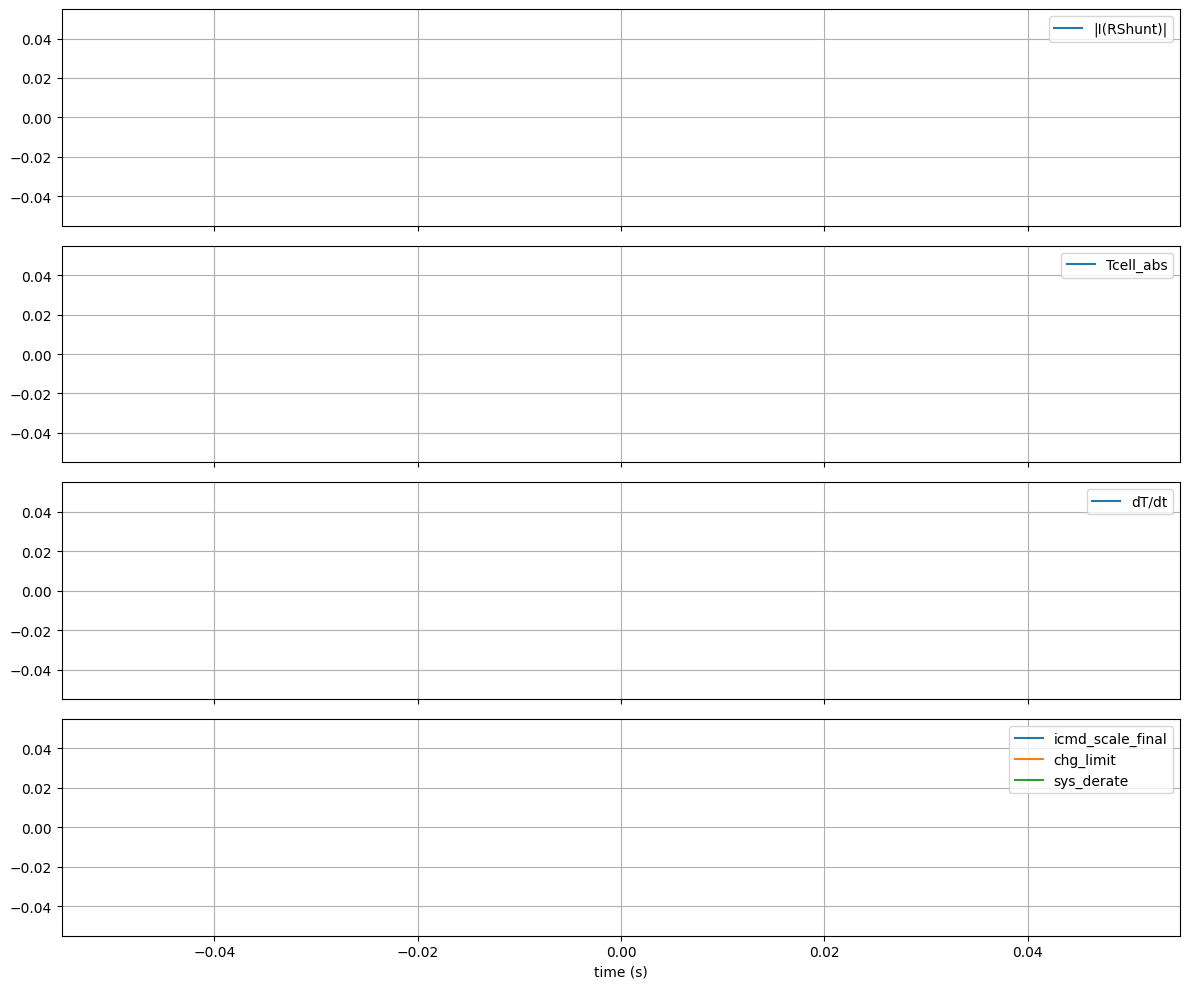

In [127]:
t_der2 = first_valid_time(c2.get("t_chg_limit", np.nan), c2.get("t_sys_derate", np.nan))

W_pre = 250
W_post = 250

z2 = crop(df2, t_der2 - W_pre, t_der2 + W_post)
tz2 = get_time(z2)

I2 = get_sig(z2, ["rshunt"], absval=True)
T2 = get_sig(z2, ["tcell_abs"])
DT2 = get_sig(z2, ["dtdt_f"])
U2 = get_sig(z2, ["icmd_scale_final"])
L2 = get_sig(z2, ["chg_limit_f", "chg_limit"])
D2 = get_sig(z2, ["sys_derate"])

fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

ax[0].plot(tz2, I2, label="|I(RShunt)|")
ax[0].axvline(t_der2, linestyle="--")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(tz2, T2, label="Tcell_abs")
ax[1].axvline(t_der2, linestyle="--")
ax[1].legend()
ax[1].grid(True)

ax[2].plot(tz2, DT2, label="dT/dt")
ax[2].axvline(t_der2, linestyle="--")
ax[2].legend()
ax[2].grid(True)

ax[3].plot(tz2, U2, label="icmd_scale_final")
if L2 is not None: ax[3].plot(tz2, L2, label="chg_limit")
if D2 is not None: ax[3].plot(tz2, D2, label="sys_derate")
ax[3].axvline(t_der2, linestyle="--")
ax[3].legend()
ax[3].grid(True)
ax[3].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

In [128]:
pre2 = crop(df2, t_der2 - 200, t_der2)
post2 = crop(df2, t_der2, t_der2 + 200)

t_pre2 = get_time(pre2)
t_post2 = get_time(post2)

i_pre2 = get_sig(pre2, ["rshunt"], absval=True)
i_post2 = get_sig(post2, ["rshunt"], absval=True)

dt_pre2 = get_sig(pre2, ["dtdt_f"])
dt_post2 = get_sig(post2, ["dtdt_f"])

I2_pre_mean = (i_pre2**2).mean()
I2_post_mean = (i_post2**2).mean()

DT_pre_mean = dt_pre2.mean()
DT_post_mean = dt_post2.mean()

I2dt_pre = area_under_curve(t_pre2, i_pre2**2)
I2dt_post = area_under_curve(t_post2, i_post2**2)

thermal_metrics_df = pd.DataFrame([{
    "case": "case2_thermal_derate",
    "I2_mean_pre": I2_pre_mean,
    "I2_mean_post": I2_post_mean,
    "I2_reduction_percent": pct_reduction(I2_pre_mean, I2_post_mean),
    "dTdt_mean_pre": DT_pre_mean,
    "dTdt_mean_post": DT_post_mean,
    "dTdt_reduction_percent": pct_reduction(DT_pre_mean, DT_post_mean),
    "I2dt_pre": I2dt_pre,
    "I2dt_post": I2dt_post,
    "I2dt_reduction_percent": pct_reduction(I2dt_pre, I2dt_post),
    "temp_slope_pre": linear_slope(t_pre2, get_sig(pre2, ["tcell_abs"])),
    "temp_slope_post": linear_slope(t_post2, get_sig(post2, ["tcell_abs"]))
}])

thermal_metrics_df

,case,I2_mean_pre,I2_mean_post,I2_reduction_percent,dTdt_mean_pre,dTdt_mean_post,dTdt_reduction_percent,I2dt_pre,I2dt_post,I2dt_reduction_percent,temp_slope_pre,temp_slope_post
0,case2_thermal_derate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


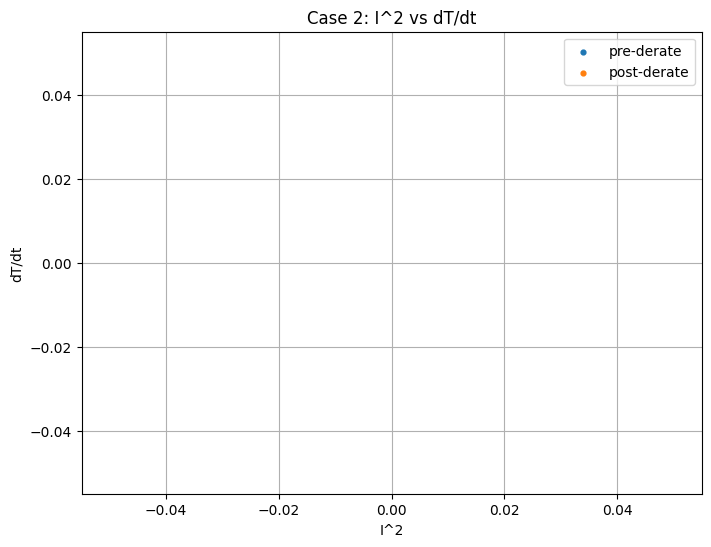

In [129]:
full_t2 = get_time(df2)
full_i2 = get_sig(df2, ["rshunt"], absval=True)
full_dt2 = get_sig(df2, ["dtdt_f"])

mask_pre = (full_t2 >= t_der2 - 200) & (full_t2 <= t_der2)
mask_post = (full_t2 >= t_der2) & (full_t2 <= t_der2 + 200)

plt.figure(figsize=(8,6))
plt.scatter((full_i2[mask_pre]**2), full_dt2[mask_pre], s=12, label="pre-derate")
plt.scatter((full_i2[mask_post]**2), full_dt2[mask_post], s=12, label="post-derate")
plt.xlabel("I^2")
plt.ylabel("dT/dt")
plt.title("Case 2: I^2 vs dT/dt")
plt.grid(True)
plt.legend()
plt.show()

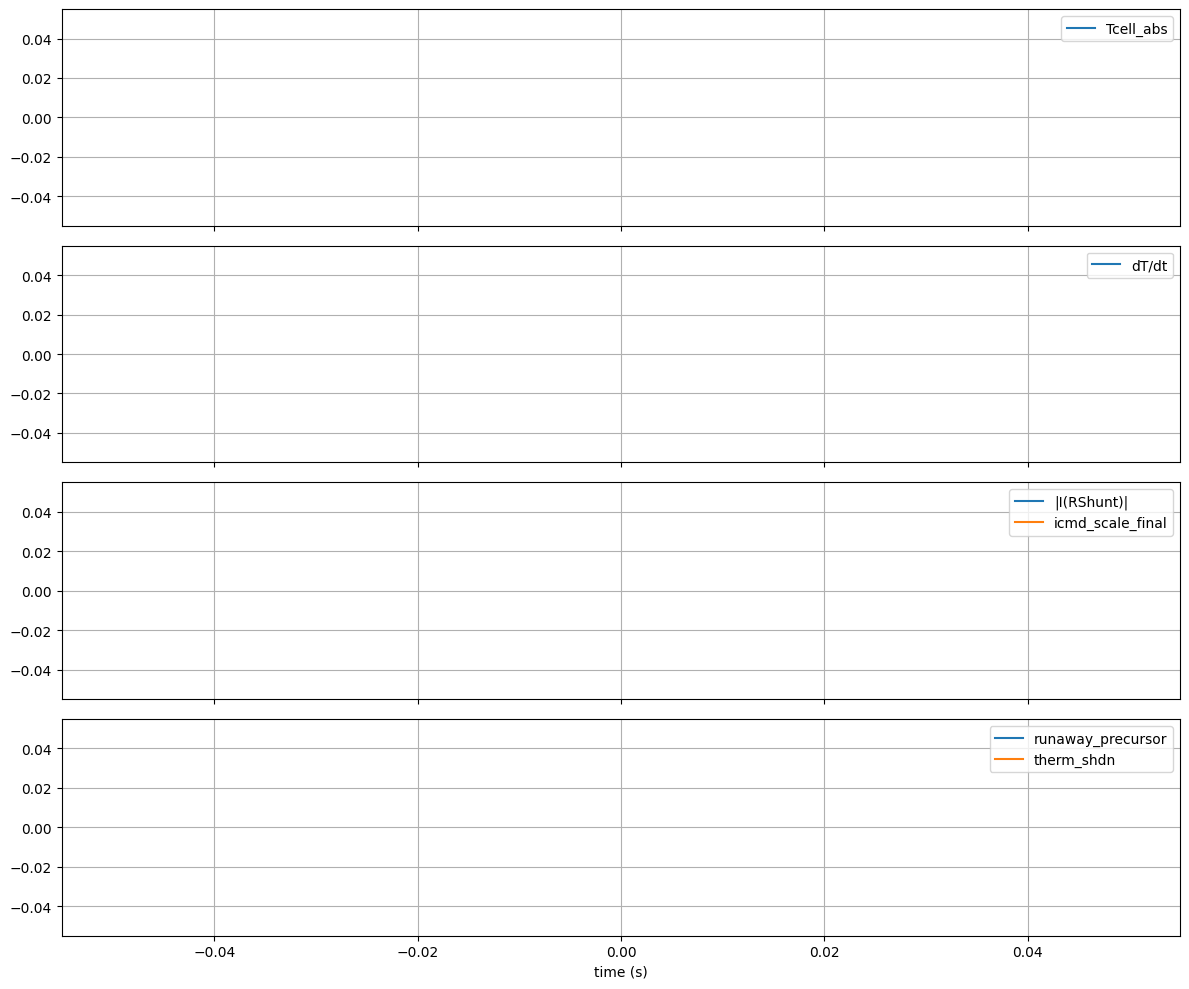

In [130]:
t_prec3 = c3.get("t_runaway_prec", c3.get("t_runaway_precursor", np.nan))
t_der3 = first_valid_time(c3.get("t_chg_limit", np.nan), c3.get("t_sys_derate", np.nan))
t_shdn3 = first_valid_time(c3.get("t_therm_shdn", np.nan), c3.get("t_final_shdn", np.nan))

z3 = crop(df3, max(0, t_prec3 - 50), t_shdn3 + 50)
tz3 = get_time(z3)

I3 = get_sig(z3, ["rshunt"], absval=True)
T3 = get_sig(z3, ["tcell_abs"])
DT3 = get_sig(z3, ["dtdt_f"])
P3 = get_sig(z3, ["runaway_precursor"])
U3 = get_sig(z3, ["icmd_scale_final"])
S3 = get_sig(z3, ["therm_shdn_f", "therm_shdn"])

fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for a in ax:
    a.axvline(t_prec3, linestyle="--", color="orange")
    a.axvline(t_der3, linestyle="--", color="red")
    a.axvline(t_shdn3, linestyle="--", color="black")
    a.grid(True)

if T3 is not None:
    ax[0].plot(tz3, T3, label="Tcell_abs")
ax[0].legend()

if DT3 is not None:
    ax[1].plot(tz3, DT3, label="dT/dt")
ax[1].legend()

if I3 is not None:
    ax[2].plot(tz3, I3, label="|I(RShunt)|")
if U3 is not None:
    ax[2].plot(tz3, U3, label="icmd_scale_final")
ax[2].legend()

if P3 is not None:
    ax[3].plot(tz3, P3, label="runaway_precursor")
if S3 is not None:
    ax[3].plot(tz3, S3, label="therm_shdn")

ax[3].legend()
ax[3].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

analysis_df = summary_df.merge(
    advanced_df[[
        "case_name",
        "current_before_shutdown",
        "current_after_shutdown",
        "current_before_derate",
        "current_after_derate",
        "temp_slope_before_derate",
        "temp_slope_after_derate",
        "severity_score"
    ]],
    on="case_name",
    how="left"
).sort_values("case_name").reset_index(drop=True)

def row_of(case_name):
    return analysis_df.loc[analysis_df["case_name"] == case_name].iloc[0]

def get_time(df):
    tcol = resolve_col(df, ["time"])
    return pd.to_numeric(df[tcol], errors="coerce") if tcol else None

def get_sig(df, aliases, absval=False):
    col, s = get_series(df, aliases, absval=absval)
    return pd.to_numeric(s, errors="coerce") if s is not None else None

def crop(df, t0, t1):
    t = get_time(df)
    if t is None:
        return None
    return df.loc[(t >= t0) & (t <= t1)].copy()

def linear_slope(t, y):
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if len(t) < 3:
        return np.nan
    return float(np.polyfit(t, y, 1)[0])

def area_under_curve(t, y):
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if len(t) < 2:
        return np.nan
    return float(np.trapz(y, t))

def pct_reduction(before, after):
    if pd.isna(before) or pd.isna(after) or before == 0:
        return np.nan
    return 100 * (1 - after / before)

def normalize01(s):
    s = pd.Series(s).astype(float)
    if s.notna().sum() == 0:
        return s
    lo, hi = s.min(), s.max()
    if hi == lo:
        return s * 0
    return (s - lo) / (hi - lo)

c2 = row_of("case2_thermal_derate")
c3 = row_of("case3_runaway_prevention")
c4 = row_of("case4_aging_warning")
c5 = row_of("case5_severe_aging")
c6 = row_of("case6_fast_fault")

path2 = [p for p in protection_files if "case2_thermal_derate" in p][0]
path3 = [p for p in protection_files if "case3_runaway_prevention" in p][0]
path4 = [p for p in protection_files if "case4_aging_warning" in p][0]
path5 = [p for p in protection_files if "case5_severe_aging" in p][0]
path6 = [p for p in protection_files if "case6_fast_fault" in p][0]

df2 = loaded_data[path2]
df3 = loaded_data[path3]
df4 = loaded_data[path4]
df5 = loaded_data[path5]
df6 = loaded_data[path6]

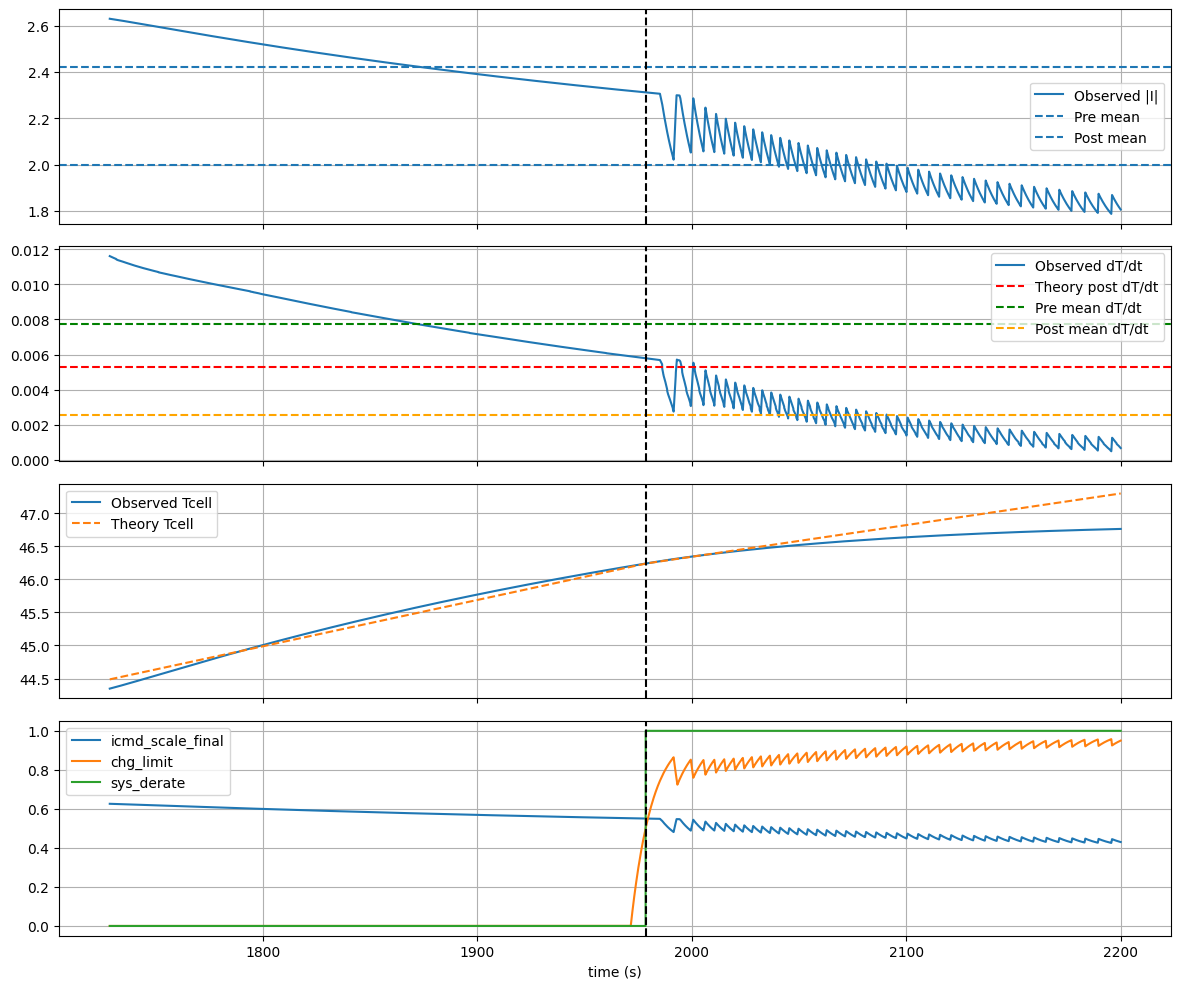

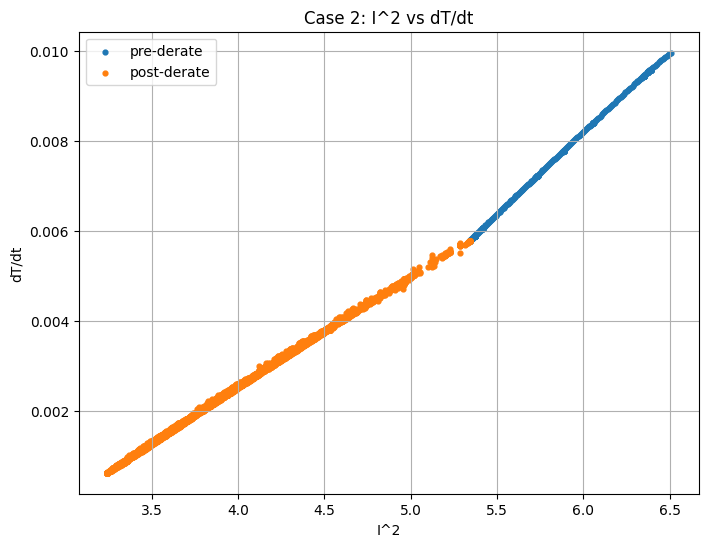

,I2_pre_mean,I2_post_mean,I2_reduction_percent,dTdt_pre_mean,dTdt_post_observed,dTdt_post_theory_from_I2,dTdt_theory_error_percent,temp_slope_pre,temp_slope_post_observed,temp_slope_post_theory_from_I2
0,5.872727,4.008063,31.751246,0.007721,0.002543,0.00527,-51.747745,0.007012,0.002334,0.004785


In [132]:
t_der2 = first_valid_time(c2.get("t_chg_limit", np.nan), c2.get("t_sys_derate", np.nan))

pre2 = crop(df2, t_der2 - 200, t_der2)
post2 = crop(df2, t_der2, t_der2 + 200)
zoom2 = crop(df2, t_der2 - 250, t_der2 + 250)

t_pre2 = get_time(pre2)
t_post2 = get_time(post2)
t_zoom2 = get_time(zoom2)

i_pre2 = get_sig(pre2, ["rshunt"], absval=True)
i_post2 = get_sig(post2, ["rshunt"], absval=True)
i_zoom2 = get_sig(zoom2, ["rshunt"], absval=True)

dt_pre2 = get_sig(pre2, ["dtdt_f"])
dt_post2 = get_sig(post2, ["dtdt_f"])
dt_zoom2 = get_sig(zoom2, ["dtdt_f"])

T_pre2 = get_sig(pre2, ["tcell_abs"])
T_post2 = get_sig(post2, ["tcell_abs"])
T_zoom2 = get_sig(zoom2, ["tcell_abs"])

u_zoom2 = get_sig(zoom2, ["icmd_scale_final"])
limit_zoom2 = get_sig(zoom2, ["chg_limit_f", "chg_limit"])
derate_zoom2 = get_sig(zoom2, ["sys_derate"])

I2_pre = (i_pre2**2).mean()
I2_post = (i_post2**2).mean()
DT_pre = dt_pre2.mean()
DT_post = dt_post2.mean()

# theory from Qj ~ I^2 R, so dT/dt post should scale with I^2 ratio
DT_post_theory = DT_pre * (I2_post / I2_pre) if pd.notna(I2_pre) and I2_pre != 0 else np.nan

# piecewise expected temperature using observed pre temp and theory post slope
T0 = T_zoom2.iloc[0]
T_der_val = T_zoom2.iloc[np.argmin(np.abs(t_zoom2 - t_der2))]
slope_pre = linear_slope(t_pre2, T_pre2)
slope_post_theory = slope_pre * (I2_post / I2_pre) if pd.notna(I2_pre) and I2_pre != 0 else np.nan

T_expected = []
for tt in t_zoom2:
    if tt <= t_der2:
        T_expected.append(T_der_val + slope_pre * (tt - t_der2))
    else:
        T_expected.append(T_der_val + slope_post_theory * (tt - t_der2))
T_expected = pd.Series(T_expected, index=t_zoom2.index)

case2_compare_df = pd.DataFrame([{
    "I2_pre_mean": I2_pre,
    "I2_post_mean": I2_post,
    "I2_reduction_percent": pct_reduction(I2_pre, I2_post),
    "dTdt_pre_mean": DT_pre,
    "dTdt_post_observed": DT_post,
    "dTdt_post_theory_from_I2": DT_post_theory,
    "dTdt_theory_error_percent": 100 * (DT_post - DT_post_theory) / DT_post_theory if pd.notna(DT_post_theory) and DT_post_theory != 0 else np.nan,
    "temp_slope_pre": slope_pre,
    "temp_slope_post_observed": linear_slope(t_post2, T_post2),
    "temp_slope_post_theory_from_I2": slope_post_theory
}])

fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

ax[0].plot(t_zoom2, i_zoom2, label="Observed |I|")
ax[0].axhline(i_pre2.mean(), linestyle="--", label="Pre mean")
ax[0].axhline(i_post2.mean(), linestyle="--", label="Post mean")
ax[0].axvline(t_der2, color="black", linestyle="--")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(t_zoom2, dt_zoom2, label="Observed dT/dt")
if pd.notna(DT_post_theory):
    ax[1].axhline(DT_post_theory, color="red", linestyle="--", label="Theory post dT/dt")
ax[1].axhline(DT_pre, color="green", linestyle="--", label="Pre mean dT/dt")
ax[1].axhline(DT_post, color="orange", linestyle="--", label="Post mean dT/dt")
ax[1].axvline(t_der2, color="black", linestyle="--")
ax[1].legend()
ax[1].grid(True)

ax[2].plot(t_zoom2, T_zoom2, label="Observed Tcell")
ax[2].plot(t_zoom2, T_expected, linestyle="--", label="Theory Tcell")
ax[2].axvline(t_der2, color="black", linestyle="--")
ax[2].legend()
ax[2].grid(True)

ax[3].plot(t_zoom2, u_zoom2, label="icmd_scale_final")
if limit_zoom2 is not None: ax[3].plot(t_zoom2, limit_zoom2, label="chg_limit")
if derate_zoom2 is not None: ax[3].plot(t_zoom2, derate_zoom2, label="sys_derate")
ax[3].axvline(t_der2, color="black", linestyle="--")
ax[3].legend()
ax[3].grid(True)
ax[3].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
x_pre = (i_pre2**2)
y_pre = dt_pre2
x_post = (i_post2**2)
y_post = dt_post2
m_pre = x_pre.notna() & y_pre.notna()
m_post = x_post.notna() & y_post.notna()
plt.scatter(x_pre[m_pre], y_pre[m_pre], s=12, label="pre-derate")
plt.scatter(x_post[m_post], y_post[m_post], s=12, label="post-derate")
plt.xlabel("I^2")
plt.ylabel("dT/dt")
plt.title("Case 2: I^2 vs dT/dt")
plt.grid(True)
plt.legend()
plt.show()

case2_compare_df

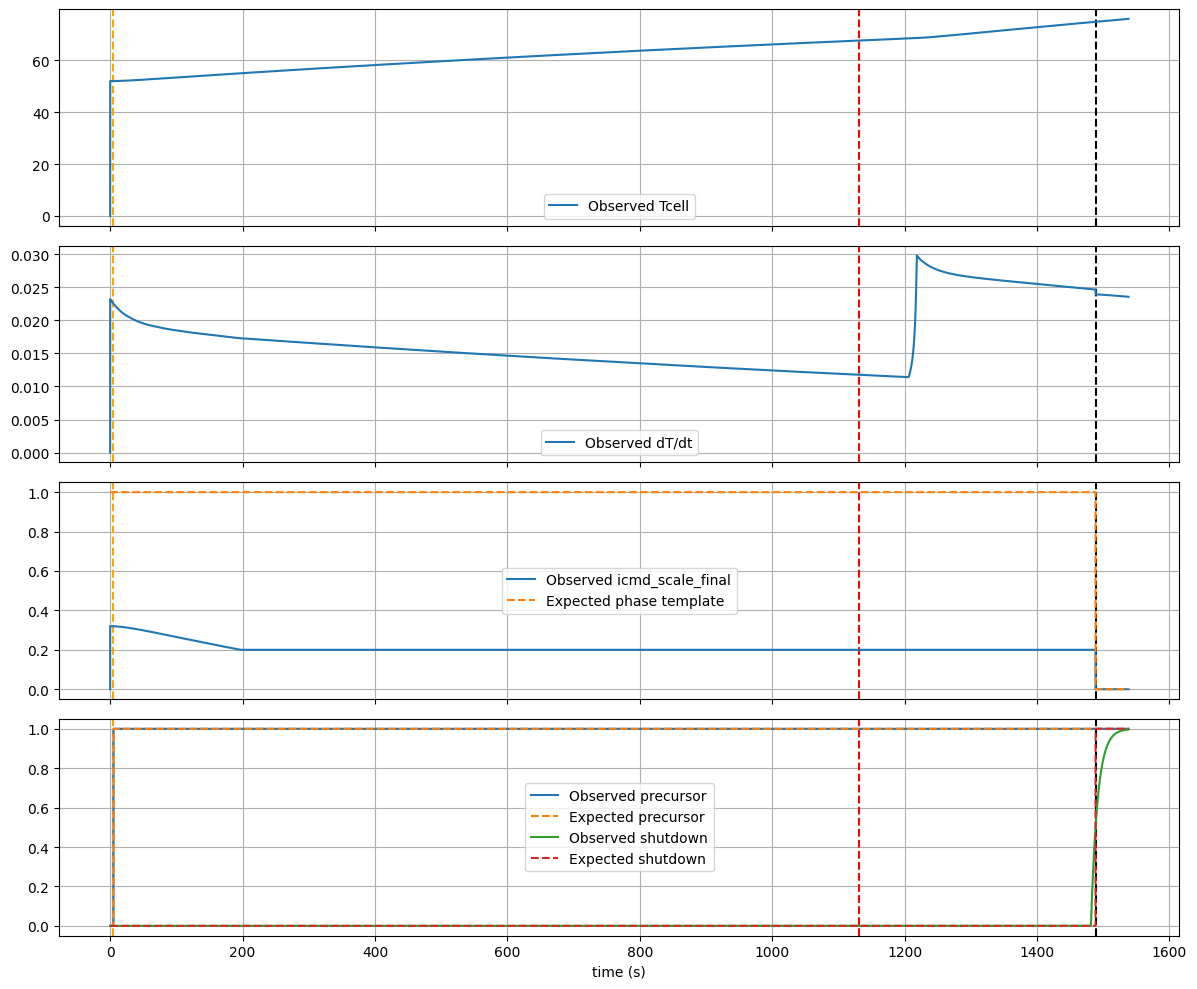

,phase,duration_s,T_slope,dTdt_mean,I_mean
0,precursor_to_derate,1126.810311,0.014008,0.015172,0.949475
1,derate_to_shutdown,356.519764,0.021725,0.023323,0.900016
2,shutdown_entry_window,50.000000,0.023399,0.024876,0.900016


In [133]:
t_prec3 = c3["t_runaway_prec"]
t_der3 = first_valid_time(c3.get("t_chg_limit", np.nan), c3.get("t_sys_derate", np.nan))
t_shdn3 = first_valid_time(c3.get("t_therm_shdn", np.nan), c3.get("t_final_shdn", np.nan))

z3 = crop(df3, max(0, t_prec3 - 50), t_shdn3 + 50)
tz3 = get_time(z3)

I3 = get_sig(z3, ["rshunt"], absval=True)
T3 = get_sig(z3, ["tcell_abs"])
DT3 = get_sig(z3, ["dtdt_f"])
P3 = get_sig(z3, ["runaway_precursor"])
U3 = get_sig(z3, ["icmd_scale_final"])
S3 = get_sig(z3, ["therm_shdn_f", "therm_shdn"])

# expected piecewise templates
P3_exp = pd.Series((tz3 >= t_prec3).astype(float), index=tz3.index)
U3_exp = pd.Series(np.where(tz3 < t_der3, c3["current_before_derate"]/c3["current_before_derate"] if pd.notna(c3["current_before_derate"]) else 1.0,
                           np.where(tz3 < t_shdn3, c3["current_after_derate"]/c3["current_before_derate"] if pd.notna(c3["current_before_derate"]) and c3["current_before_derate"] != 0 else 0.2,
                                    0.0)), index=tz3.index)
S3_exp = pd.Series((tz3 >= t_shdn3).astype(float), index=tz3.index)

seg1 = crop(df3, t_prec3, t_der3)
seg2 = crop(df3, t_der3, t_shdn3)
seg3 = crop(df3, max(t_shdn3 - 50, 0), t_shdn3)

runaway_segments_df = pd.DataFrame([
    {
        "phase": "precursor_to_derate",
        "duration_s": t_der3 - t_prec3,
        "T_slope": linear_slope(get_time(seg1), get_sig(seg1, ["tcell_abs"])),
        "dTdt_mean": get_sig(seg1, ["dtdt_f"]).mean(),
        "I_mean": get_sig(seg1, ["rshunt"], absval=True).mean()
    },
    {
        "phase": "derate_to_shutdown",
        "duration_s": t_shdn3 - t_der3,
        "T_slope": linear_slope(get_time(seg2), get_sig(seg2, ["tcell_abs"])),
        "dTdt_mean": get_sig(seg2, ["dtdt_f"]).mean(),
        "I_mean": get_sig(seg2, ["rshunt"], absval=True).mean()
    },
    {
        "phase": "shutdown_entry_window",
        "duration_s": 50,
        "T_slope": linear_slope(get_time(seg3), get_sig(seg3, ["tcell_abs"])),
        "dTdt_mean": get_sig(seg3, ["dtdt_f"]).mean(),
        "I_mean": get_sig(seg3, ["rshunt"], absval=True).mean()
    }
])

fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for a in ax:
    a.axvline(t_prec3, linestyle="--", color="orange")
    a.axvline(t_der3, linestyle="--", color="red")
    a.axvline(t_shdn3, linestyle="--", color="black")
    a.grid(True)

ax[0].plot(tz3, T3, label="Observed Tcell")
ax[0].legend()

ax[1].plot(tz3, DT3, label="Observed dT/dt")
ax[1].legend()

ax[2].plot(tz3, U3, label="Observed icmd_scale_final")
ax[2].plot(tz3, U3_exp, linestyle="--", label="Expected phase template")
ax[2].legend()

ax[3].plot(tz3, P3, label="Observed precursor")
ax[3].plot(tz3, P3_exp, linestyle="--", label="Expected precursor")
if S3 is not None:
    ax[3].plot(tz3, S3, label="Observed shutdown")
ax[3].plot(tz3, S3_exp, linestyle="--", label="Expected shutdown")
ax[3].legend()
ax[3].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

runaway_segments_df

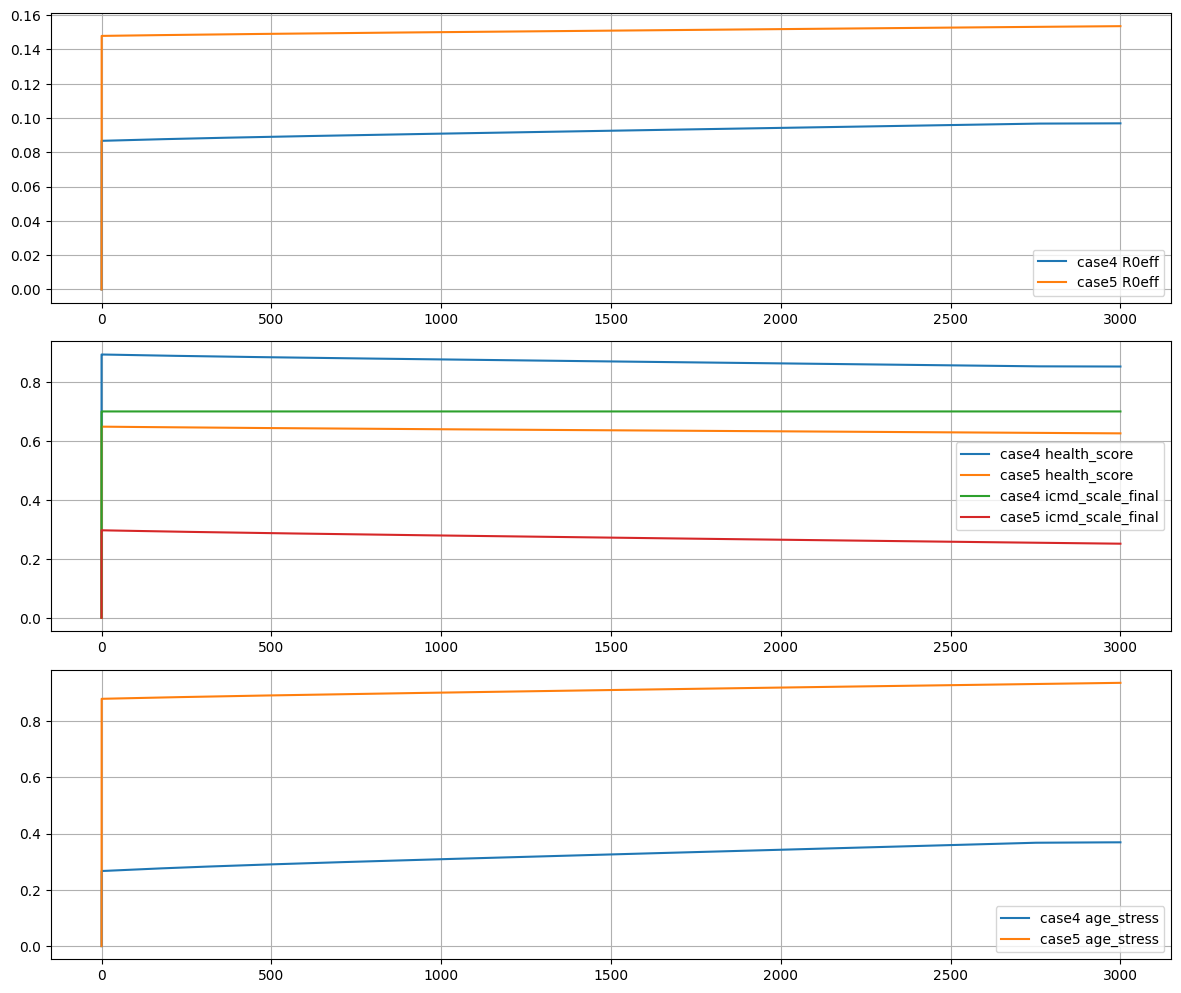

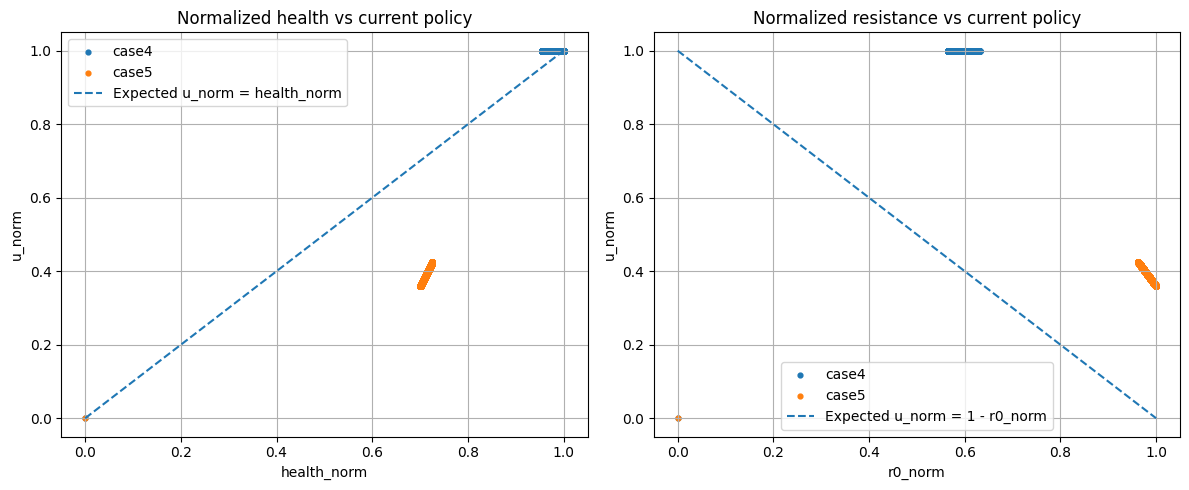

,case4_r0eff_avg,case5_r0eff_avg,delta_r0eff,case4_health_min,case5_health_min,delta_health,case4_icmd_scale_min,case5_icmd_scale_min,delta_icmd_scale,icmd_reduction_percent_warning_to_severe,spearman_health_vs_current,spearman_r0_vs_current,rmse_to_theory_u_eq_health,rmse_to_theory_u_eq_1_minus_rnorm
0,0.091021,0.150708,0.059688,0.852417,0.625673,0.226744,0.7,0.251346,0.448654,64.093429,0.991766,-0.991028,0.278048,0.439942


In [134]:
t4 = get_time(df4); t5 = get_time(df5)
r4 = get_sig(df4, ["r0eff"]); r5 = get_sig(df5, ["r0eff"])
h4 = get_sig(df4, ["health_score"]); h5 = get_sig(df5, ["health_score"])
a4 = get_sig(df4, ["age_stress"]); a5 = get_sig(df5, ["age_stress"])
u4 = get_sig(df4, ["icmd_scale_final"]); u5 = get_sig(df5, ["icmd_scale_final"])

# normalized expected relationships
health_all = pd.concat([h4, h5], ignore_index=True)
r_all = pd.concat([r4, r5], ignore_index=True)
u_all = pd.concat([u4, u5], ignore_index=True)

h_norm = normalize01(health_all)
r_norm = normalize01(r_all)
u_norm = normalize01(u_all)

# split back
n4 = len(h4)
h4n, h5n = h_norm.iloc[:n4], h_norm.iloc[n4:]
r4n, r5n = r_norm.iloc[:n4], r_norm.iloc[n4:]
u4n, u5n = u_norm.iloc[:n4], u_norm.iloc[n4:]

# theory:
# expected u_norm ~ h_norm
# expected u_norm ~ 1 - r_norm
rmse_health = np.sqrt(np.nanmean((u_norm - h_norm)**2))
rmse_r0 = np.sqrt(np.nanmean((u_norm - (1 - r_norm))**2))

rho_health = pd.Series(health_all).corr(pd.Series(u_all), method="spearman")
rho_r0 = pd.Series(r_all).corr(pd.Series(u_all), method="spearman")

aging_quant_df = pd.DataFrame([{
    "case4_r0eff_avg": c4["r0eff_avg"],
    "case5_r0eff_avg": c5["r0eff_avg"],
    "delta_r0eff": c5["r0eff_avg"] - c4["r0eff_avg"],
    "case4_health_min": c4["health_score_min"],
    "case5_health_min": c5["health_score_min"],
    "delta_health": c4["health_score_min"] - c5["health_score_min"],
    "case4_icmd_scale_min": c4["icmd_scale_min"],
    "case5_icmd_scale_min": c5["icmd_scale_min"],
    "delta_icmd_scale": c4["icmd_scale_min"] - c5["icmd_scale_min"],
    "icmd_reduction_percent_warning_to_severe": pct_reduction(c4["icmd_scale_min"], c5["icmd_scale_min"]),
    "spearman_health_vs_current": rho_health,
    "spearman_r0_vs_current": rho_r0,
    "rmse_to_theory_u_eq_health": rmse_health,
    "rmse_to_theory_u_eq_1_minus_rnorm": rmse_r0
}])

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(t4, r4, label="case4 R0eff")
ax[0].plot(t5, r5, label="case5 R0eff")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(t4, h4, label="case4 health_score")
ax[1].plot(t5, h5, label="case5 health_score")
ax[1].plot(t4, u4, label="case4 icmd_scale_final")
ax[1].plot(t5, u5, label="case5 icmd_scale_final")
ax[1].legend()
ax[1].grid(True)

ax[2].plot(t4, a4, label="case4 age_stress")
ax[2].plot(t5, a5, label="case5 age_stress")
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(h4n, u4n, s=12, label="case4")
plt.scatter(h5n, u5n, s=12, label="case5")
grid = np.linspace(0,1,100)
plt.plot(grid, grid, linestyle="--", label="Expected u_norm = health_norm")
plt.xlabel("health_norm")
plt.ylabel("u_norm")
plt.title("Normalized health vs current policy")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.scatter(r4n, u4n, s=12, label="case4")
plt.scatter(r5n, u5n, s=12, label="case5")
plt.plot(grid, 1-grid, linestyle="--", label="Expected u_norm = 1 - r0_norm")
plt.xlabel("r0_norm")
plt.ylabel("u_norm")
plt.title("Normalized resistance vs current policy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

aging_quant_df

In [135]:
case2_compare_df.to_csv("stage2h_case2_expected_vs_observed.csv", index=False)
runaway_segments_df.to_csv("stage2h_case3_segmented_behavior.csv", index=False)
aging_quant_df.to_csv("stage2h_case45_aging_policy_compare.csv", index=False)

if "fast_quant_df" in globals() and fast_quant_df is not None:
    fast_quant_df.to_csv("stage2h_case6_fast_fault_compare.csv", index=False)
    print("saved all 4 files")
else:
    print("saved first 3 files; fast_quant_df is not defined yet")

saved first 3 files; fast_quant_df is not defined yet


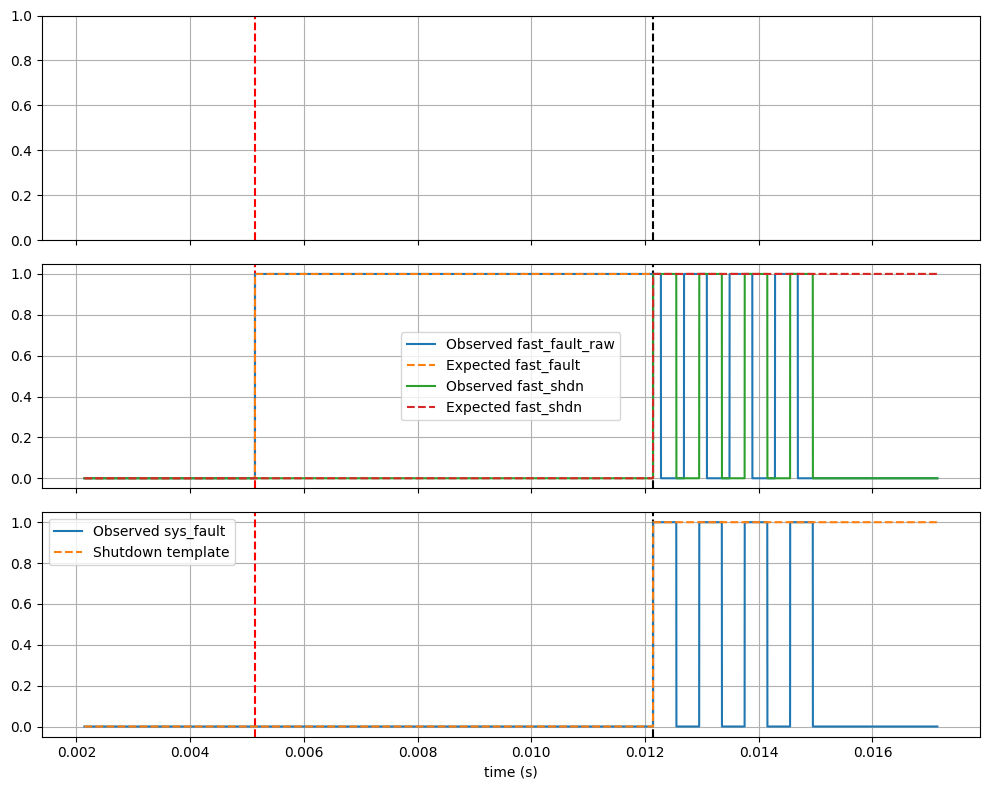

,t_fast_fault_s,t_fast_shdn_s,fault_to_shutdown_ms,thermal_warning_window_case2_s,runaway_total_window_case3_s,thermal_to_fast_ratio,runaway_to_fast_ratio
0,0.005139,0.012141,7.001743,NaN,NaN,NaN,NaN


In [136]:
t_fault6 = c6.get("t_fast_fault", np.nan)
t_shdn6  = c6.get("t_fast_shdn", np.nan)

fastfault_to_shutdown_s = c6.get(
    "fastfault_to_shutdown_s",
    t_shdn6 - t_fault6 if pd.notna(t_fault6) and pd.notna(t_shdn6) else np.nan
)

# local safe time extractor for this cell
def get_time_local(df):
    if df is None or len(df) == 0:
        return None

    # try normal resolver first
    try:
        tcol = resolve_col(df, ["time"])
        if tcol is not None:
            return pd.to_numeric(df[tcol], errors="coerce")
    except Exception:
        pass

    # fallback: use first numeric column
    for col in df.columns:
        s = pd.to_numeric(df[col], errors="coerce")
        if s.notna().sum() > 0:
            return s

    return None

t_full6 = get_time_local(df6)
if t_full6 is None:
    raise ValueError("Could not resolve any time-like column in df6")

z6 = crop(df6, t_fault6 - 0.003, t_shdn6 + 0.005)

if z6 is None or len(z6) == 0:
    idx_fault = int((t_full6 - t_fault6).abs().idxmin())
    idx_shdn  = int((t_full6 - t_shdn6).abs().idxmin())
    i0 = max(0, min(idx_fault, idx_shdn) - 200)
    i1 = min(len(df6) - 1, max(idx_fault, idx_shdn) + 400)
    z6 = df6.iloc[i0:i1].copy()

tz6 = get_time_local(z6)

I6 = get_sig(z6, ["rshunt"], absval=True)
F6 = get_sig(z6, ["fast_fault_raw"])
S6 = get_sig(z6, ["fast_shdn"])
Y6 = get_sig(z6, ["sys_fault"])

F6_exp = pd.Series((tz6 >= t_fault6).astype(float), index=tz6.index)
S6_exp = pd.Series((tz6 >= t_shdn6).astype(float), index=tz6.index)

fast_quant_df = pd.DataFrame([{
    "t_fast_fault_s": t_fault6,
    "t_fast_shdn_s": t_shdn6,
    "fault_to_shutdown_ms": fastfault_to_shutdown_s * 1000,
    "thermal_warning_window_case2_s": c2.get("warning_window_s", np.nan),
    "runaway_total_window_case3_s": c3.get("total_safety_window_s", np.nan),
    "thermal_to_fast_ratio": c2.get("warning_window_s", np.nan) / fastfault_to_shutdown_s,
    "runaway_to_fast_ratio": c3.get("total_safety_window_s", np.nan) / fastfault_to_shutdown_s
}])

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for a in ax:
    a.axvline(t_fault6, linestyle="--", color="red")
    a.axvline(t_shdn6, linestyle="--", color="black")
    a.grid(True)

if I6 is not None:
    ax[0].plot(tz6, I6, label="Observed |I|")
    ax[0].legend()

if F6 is not None:
    ax[1].plot(tz6, F6, label="Observed fast_fault_raw")
ax[1].plot(tz6, F6_exp, linestyle="--", label="Expected fast_fault")

if S6 is not None:
    ax[1].plot(tz6, S6, label="Observed fast_shdn")
ax[1].plot(tz6, S6_exp, linestyle="--", label="Expected fast_shdn")
ax[1].legend()

if Y6 is not None:
    ax[2].plot(tz6, Y6, label="Observed sys_fault")
ax[2].plot(tz6, S6_exp, linestyle="--", label="Shutdown template")
ax[2].legend()
ax[2].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

fast_quant_df

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1) robust dataframe discovery
# ----------------------------
def find_long_event_df():
    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame):
            cols = set(obj.columns.astype(str))
            if {"case_name", "event", "time"}.issubset(cols):
                return obj, name
    return None, None

long_event_df, long_event_name = find_long_event_df()
print("long_event_df:", long_event_name)

# ----------------------------
# 2) build one clean analysis table
# ----------------------------
analysis_df = summary_df.merge(
    advanced_df[[
        "case_name",
        "current_before_shutdown",
        "current_after_shutdown",
        "current_before_derate",
        "current_after_derate",
        "temp_slope_before_derate",
        "temp_slope_after_derate",
        "severity_score"
    ]],
    on="case_name",
    how="left"
).sort_values("case_name").reset_index(drop=True)

print("analysis_df columns:")
print(list(analysis_df.columns))

def row_of(case_name):
    return analysis_df.loc[analysis_df["case_name"] == case_name].iloc[0]

# ----------------------------
# 3) event resolver: wide table OR long event table
# ----------------------------
EVENT_MAP = {
    "runaway_prec": ["t_runaway_prec", "t_precursor"],
    "chg_limit": ["t_chg_limit"],
    "sys_derate": ["t_sys_derate"],
    "therm_shdn": ["t_therm_shdn"],
    "final_shdn": ["t_final_shdn"],
    "fast_fault": ["t_fast_fault"],
    "fast_shdn": ["t_fast_shdn"],
    "sys_fault": ["t_sys_fault"],
}

LONG_EVENT_NAMES = {
    "runaway_prec": ["t_runaway_prec", "runaway_precursor", "precursor"],
    "chg_limit": ["t_chg_limit", "chg_limit"],
    "sys_derate": ["t_sys_derate", "sys_derate"],
    "therm_shdn": ["t_therm_shdn", "therm_shdn"],
    "final_shdn": ["t_final_shdn", "final_shdn"],
    "fast_fault": ["t_fast_fault", "fast_fault"],
    "fast_shdn": ["t_fast_shdn", "fast_shdn"],
    "sys_fault": ["t_sys_fault", "sys_fault"],
}

def event_time(case_name, key):
    # first try wide columns in analysis_df
    r = row_of(case_name)
    for c in EVENT_MAP.get(key, []):
        if c in r.index and pd.notna(r[c]):
            return float(r[c])

    # then try long-format event df if present
    if long_event_df is not None:
        candidates = LONG_EVENT_NAMES.get(key, [])
        sub = long_event_df[long_event_df["case_name"] == case_name].copy()
        if len(sub):
            sub["event"] = sub["event"].astype(str)
            for ev in candidates:
                m = sub["event"].str.lower() == ev.lower()
                if m.any():
                    return float(pd.to_numeric(sub.loc[m, "time"], errors="coerce").iloc[0])

    return np.nan

# ----------------------------
# 4) signal helpers
# ----------------------------
def resolve_col(df, aliases):
    cols_lower = {str(c).lower(): c for c in df.columns}
    for a in aliases:
        if str(a).lower() in cols_lower:
            return cols_lower[str(a).lower()]
    for c in df.columns:
        cl = str(c).lower()
        for a in aliases:
            if str(a).lower() in cl:
                return c
    return None

def get_time(df):
    if df is None or len(df) == 0:
        return None
    tcol = resolve_col(df, ["time"])
    if tcol is None:
        return None
    return pd.to_numeric(df[tcol], errors="coerce")

def get_sig(df, aliases, absval=False):
    if df is None or len(df) == 0:
        return None
    col = resolve_col(df, aliases)
    if col is None:
        return None
    s = pd.to_numeric(df[col], errors="coerce")
    return s.abs() if absval else s

def crop(df, t0, t1):
    t = get_time(df)
    if t is None or pd.isna(t0) or pd.isna(t1):
        return None
    m = (t >= t0) & (t <= t1)
    out = df.loc[m].copy()
    return out if len(out) else None

def linear_slope(t, y):
    if t is None or y is None:
        return np.nan
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if len(t) < 3:
        return np.nan
    return float(np.polyfit(t, y, 1)[0])

def area_under_curve(t, y):
    if t is None or y is None:
        return np.nan
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if len(t) < 2:
        return np.nan
    return float(np.trapz(y, t))

def pct_reduction(before, after):
    if pd.isna(before) or pd.isna(after) or before == 0:
        return np.nan
    return 100 * (1 - after / before)

# ----------------------------
# 5) pull rows and files
# ----------------------------
c2 = row_of("case2_thermal_derate")
c3 = row_of("case3_runaway_prevention")
c4 = row_of("case4_aging_warning")
c5 = row_of("case5_severe_aging")
c6 = row_of("case6_fast_fault")

path2 = [p for p in protection_files if "case2_thermal_derate" in p][0]
path3 = [p for p in protection_files if "case3_runaway_prevention" in p][0]
path4 = [p for p in protection_files if "case4_aging_warning" in p][0]
path5 = [p for p in protection_files if "case5_severe_aging" in p][0]
path6 = [p for p in protection_files if "case6_fast_fault" in p][0]

df2 = loaded_data[path2]
df3 = loaded_data[path3]
df4 = loaded_data[path4]
df5 = loaded_data[path5]
df6 = loaded_data[path6]

print("reset complete")

long_event_df: timeline_df
analysis_df columns:
['case_name', 'scenario', 'temp_max', 'temp_avg', 'dtdt_max', 'r0eff_max', 'r0eff_avg', 'risk_score_max', 'health_score_min', 'age_stress_max', 'therm_stress_max', 'current_abs_max', 'current_abs_avg', 'icmd_scale_min', 'chg_cmd_scale_min', 'aging_warn_final', 'aging_severe_final', 'sys_warn_final', 'sys_derate_final', 'sys_shdn_final', 'sys_fault_final', 't_aging_warn', 't_aging_severe', 't_chg_limit', 't_chg_derate', 't_sys_derate', 't_runaway_prec', 't_therm_shdn', 't_final_shdn', 't_fast_fault', 't_fast_shdn', 't_sys_fault', 't_risk_warn', 't_risk_crit', 'delay_warn_to_derate', 'delay_prec_to_shdn', 'delay_fastfault_to_fastshdn', 'verdict', 'current_before_shutdown', 'current_after_shutdown', 'current_before_derate', 'current_after_derate', 'temp_slope_before_derate', 'temp_slope_after_derate', 'severity_score']
reset complete


In [138]:
case2_name = "case2_thermal_derate"
t_der2 = event_time(case2_name, "chg_limit")
if pd.isna(t_der2):
    t_der2 = event_time(case2_name, "sys_derate")

t2 = get_time(df2)

print("t_der2 =", t_der2)
print("time min/max =", None if t2 is None else (float(t2.min()), float(t2.max())))

pre2 = crop(df2, t_der2 - 200, t_der2)
post2 = crop(df2, t_der2, t_der2 + 200)
zoom2 = crop(df2, t_der2 - 250, t_der2 + 250)

print("len(pre2) =", 0 if pre2 is None else len(pre2))
print("len(post2) =", 0 if post2 is None else len(post2))
print("len(zoom2) =", 0 if zoom2 is None else len(zoom2))

t_der2 = 1978.513415400553
time min/max = (0.0, 2200.0)
len(pre2) = 720
len(post2) = 9767
len(zoom2) = 11318


pre points: 720 post points: 9767


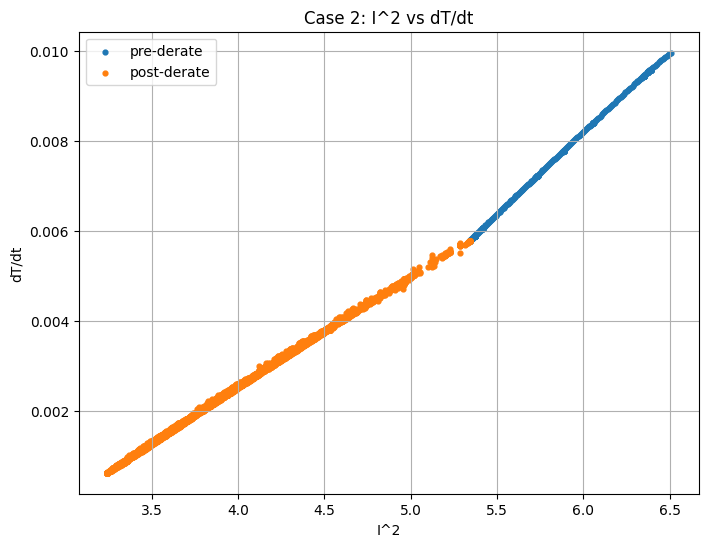

In [139]:
full_t2 = get_time(df2)
full_i2 = get_sig(df2, ["rshunt"], absval=True)
full_dt2 = get_sig(df2, ["dtdt_f"])

mask_pre = (full_t2 >= t_der2 - 200) & (full_t2 <= t_der2)
mask_post = (full_t2 >= t_der2) & (full_t2 <= t_der2 + 200)

x_pre = (full_i2[mask_pre] ** 2)
y_pre = full_dt2[mask_pre]
x_post = (full_i2[mask_post] ** 2)
y_post = full_dt2[mask_post]

m_pre = x_pre.notna() & y_pre.notna()
m_post = x_post.notna() & y_post.notna()

print("pre points:", int(m_pre.sum()), "post points:", int(m_post.sum()))

plt.figure(figsize=(8,6))
if m_pre.sum() > 0:
    plt.scatter(x_pre[m_pre], y_pre[m_pre], s=12, label="pre-derate")
if m_post.sum() > 0:
    plt.scatter(x_post[m_post], y_post[m_post], s=12, label="post-derate")
plt.xlabel("I^2")
plt.ylabel("dT/dt")
plt.title("Case 2: I^2 vs dT/dt")
plt.grid(True)
plt.legend()
plt.show()

In [140]:
case3_name = "case3_runaway_prevention"

t_prec3 = event_time(case3_name, "runaway_prec")
t_der3 = event_time(case3_name, "chg_limit")
if pd.isna(t_der3):
    t_der3 = event_time(case3_name, "sys_derate")
t_shdn3 = event_time(case3_name, "therm_shdn")
if pd.isna(t_shdn3):
    t_shdn3 = event_time(case3_name, "final_shdn")

print("t_prec3 =", t_prec3)
print("t_der3  =", t_der3)
print("t_shdn3 =", t_shdn3)

t_prec3 = 5.03240561393971
t_der3  = 1131.842716941188
t_shdn3 = 1488.36248138601


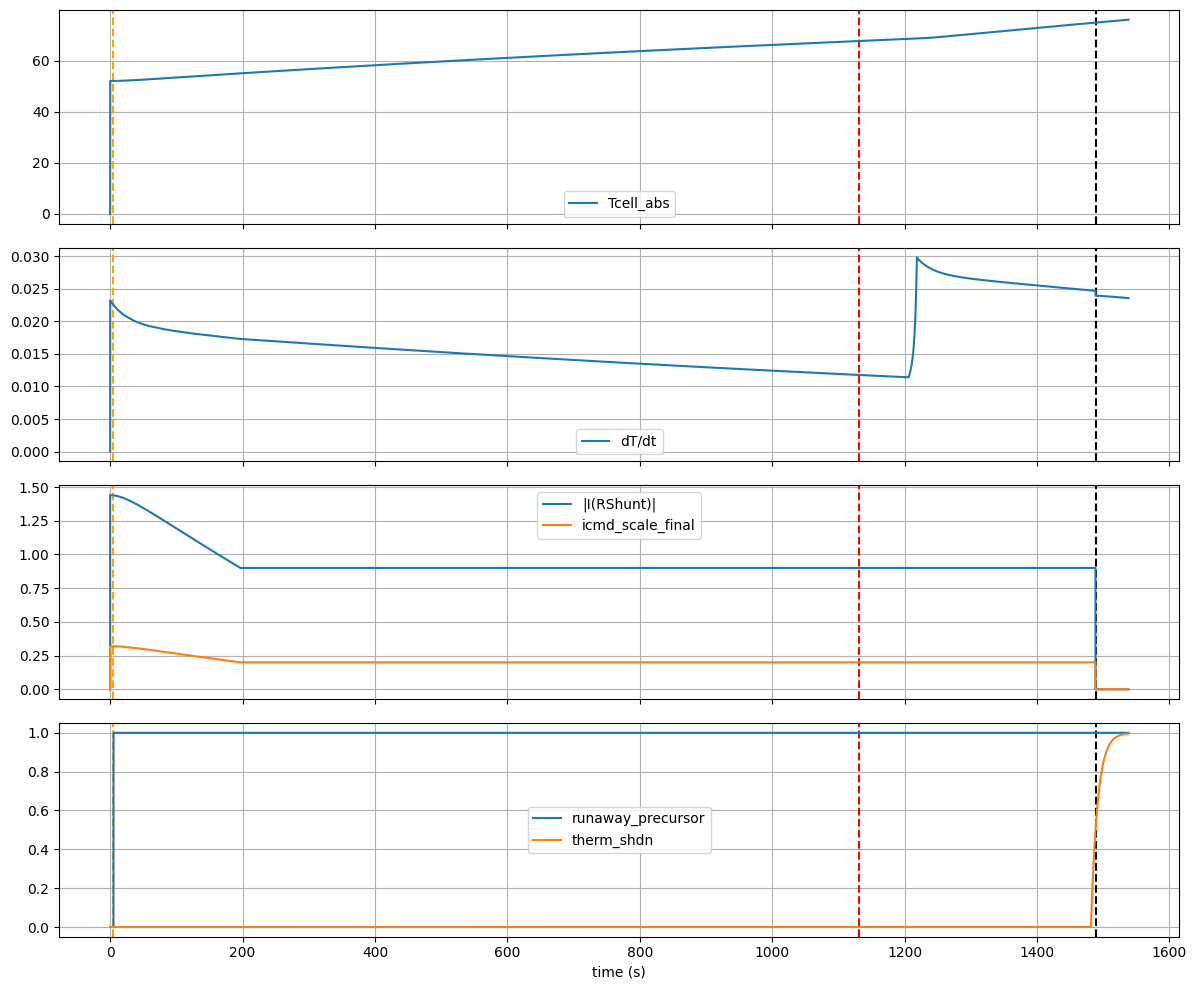

,phase,duration_s,T_slope,dTdt_mean,I_mean
0,precursor_to_derate,1126.810311,0.014008,0.015172,0.949475
1,derate_to_shutdown,356.519764,0.021725,0.023323,0.900016
2,shutdown_entry_window,50.000000,0.023399,0.024876,0.900016


In [141]:
z3 = crop(df3, max(0, t_prec3 - 50), t_shdn3 + 50)
tz3 = get_time(z3)

I3 = get_sig(z3, ["rshunt"], absval=True)
T3 = get_sig(z3, ["tcell_abs"])
DT3 = get_sig(z3, ["dtdt_f"])
P3 = get_sig(z3, ["runaway_precursor"])
U3 = get_sig(z3, ["icmd_scale_final"])
S3 = get_sig(z3, ["therm_shdn_f", "therm_shdn"])

fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for a in ax:
    a.axvline(t_prec3, linestyle="--", color="orange")
    a.axvline(t_der3, linestyle="--", color="red")
    a.axvline(t_shdn3, linestyle="--", color="black")
    a.grid(True)

if T3 is not None: ax[0].plot(tz3, T3, label="Tcell_abs")
ax[0].legend()

if DT3 is not None: ax[1].plot(tz3, DT3, label="dT/dt")
ax[1].legend()

if I3 is not None: ax[2].plot(tz3, I3, label="|I(RShunt)|")
if U3 is not None: ax[2].plot(tz3, U3, label="icmd_scale_final")
ax[2].legend()

if P3 is not None: ax[3].plot(tz3, P3, label="runaway_precursor")
if S3 is not None: ax[3].plot(tz3, S3, label="therm_shdn")
ax[3].legend()
ax[3].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

seg1 = crop(df3, t_prec3, t_der3)
seg2 = crop(df3, t_der3, t_shdn3)
seg3 = crop(df3, max(t_shdn3 - 50, 0), t_shdn3)

runaway_segments_df = pd.DataFrame([
    {
        "phase": "precursor_to_derate",
        "duration_s": t_der3 - t_prec3,
        "T_slope": linear_slope(get_time(seg1), get_sig(seg1, ["tcell_abs"])),
        "dTdt_mean": get_sig(seg1, ["dtdt_f"]).mean(),
        "I_mean": get_sig(seg1, ["rshunt"], absval=True).mean()
    },
    {
        "phase": "derate_to_shutdown",
        "duration_s": t_shdn3 - t_der3,
        "T_slope": linear_slope(get_time(seg2), get_sig(seg2, ["tcell_abs"])),
        "dTdt_mean": get_sig(seg2, ["dtdt_f"]).mean(),
        "I_mean": get_sig(seg2, ["rshunt"], absval=True).mean()
    },
    {
        "phase": "shutdown_entry_window",
        "duration_s": 50,
        "T_slope": linear_slope(get_time(seg3), get_sig(seg3, ["tcell_abs"])),
        "dTdt_mean": get_sig(seg3, ["dtdt_f"]).mean(),
        "I_mean": get_sig(seg3, ["rshunt"], absval=True).mean()
    }
])

runaway_segments_df

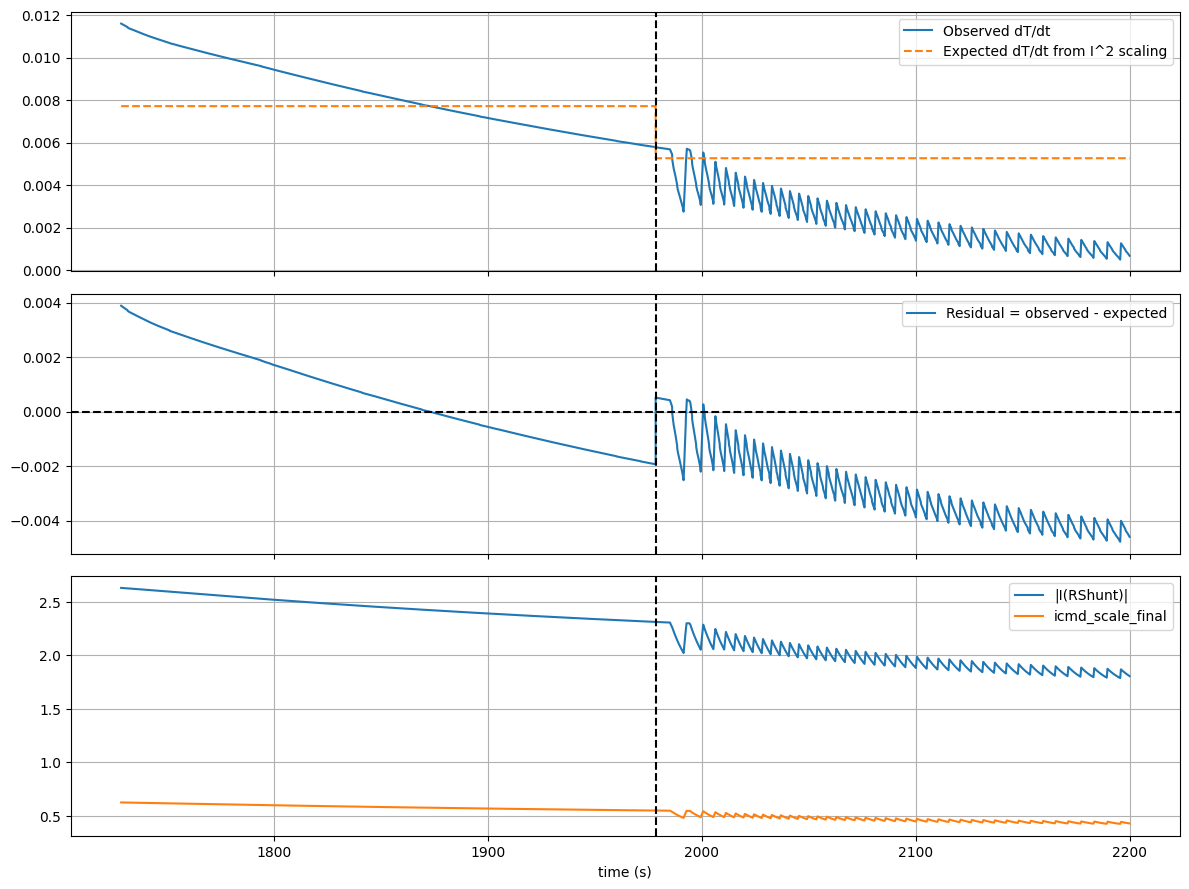

,I2_pre_mean,I2_post_mean,I2_reduction_percent,dTdt_pre_mean,dTdt_post_observed,dTdt_post_theory,dTdt_theory_error_percent,temp_slope_pre,temp_slope_post
0,5.872727,4.008063,31.751246,0.007721,0.002543,0.00527,-51.747745,0.007012,0.002334


In [142]:
# --------------------------------------------
# Case 2: expected vs observed thermal response
# --------------------------------------------

t_der2 = event_time("case2_thermal_derate", "chg_limit")
if pd.isna(t_der2):
    t_der2 = event_time("case2_thermal_derate", "sys_derate")

pre2 = crop(df2, t_der2 - 200, t_der2)
post2 = crop(df2, t_der2, t_der2 + 200)
zoom2 = crop(df2, t_der2 - 250, t_der2 + 250)

t_pre2 = get_time(pre2)
t_post2 = get_time(post2)
t_zoom2 = get_time(zoom2)

i_pre2 = get_sig(pre2, ["rshunt"], absval=True)
i_post2 = get_sig(post2, ["rshunt"], absval=True)

dt_pre2 = get_sig(pre2, ["dtdt_f"])
dt_post2 = get_sig(post2, ["dtdt_f"])
dt_zoom2 = get_sig(zoom2, ["dtdt_f"])

T_pre2 = get_sig(pre2, ["tcell_abs"])
T_post2 = get_sig(post2, ["tcell_abs"])
T_zoom2 = get_sig(zoom2, ["tcell_abs"])

u_zoom2 = get_sig(zoom2, ["icmd_scale_final"])

I2_pre = (i_pre2**2).mean()
I2_post = (i_post2**2).mean()

DT_pre = dt_pre2.mean()
DT_post = dt_post2.mean()

# simple theory: dT/dt scales with I^2 ratio
DT_post_theory = DT_pre * (I2_post / I2_pre)

# expected dT/dt trace after derate = constant theory level
DT_expected = pd.Series(
    np.where(t_zoom2 < t_der2, DT_pre, DT_post_theory),
    index=t_zoom2.index
)

# observed residual
DT_residual = dt_zoom2 - DT_expected

case2_compare_df = pd.DataFrame([{
    "I2_pre_mean": I2_pre,
    "I2_post_mean": I2_post,
    "I2_reduction_percent": pct_reduction(I2_pre, I2_post),
    "dTdt_pre_mean": DT_pre,
    "dTdt_post_observed": DT_post,
    "dTdt_post_theory": DT_post_theory,
    "dTdt_theory_error_percent": 100 * (DT_post - DT_post_theory) / DT_post_theory if DT_post_theory != 0 else np.nan,
    "temp_slope_pre": linear_slope(t_pre2, T_pre2),
    "temp_slope_post": linear_slope(t_post2, T_post2)
}])

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

ax[0].plot(t_zoom2, dt_zoom2, label="Observed dT/dt")
ax[0].plot(t_zoom2, DT_expected, linestyle="--", label="Expected dT/dt from I^2 scaling")
ax[0].axvline(t_der2, linestyle="--", color="black")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(t_zoom2, DT_residual, label="Residual = observed - expected")
ax[1].axhline(0, linestyle="--", color="black")
ax[1].axvline(t_der2, linestyle="--", color="black")
ax[1].legend()
ax[1].grid(True)

ax[2].plot(t_zoom2, get_sig(zoom2, ["rshunt"], absval=True), label="|I(RShunt)|")
ax[2].plot(t_zoom2, u_zoom2, label="icmd_scale_final")
ax[2].axvline(t_der2, linestyle="--", color="black")
ax[2].legend()
ax[2].grid(True)
ax[2].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

case2_compare_df

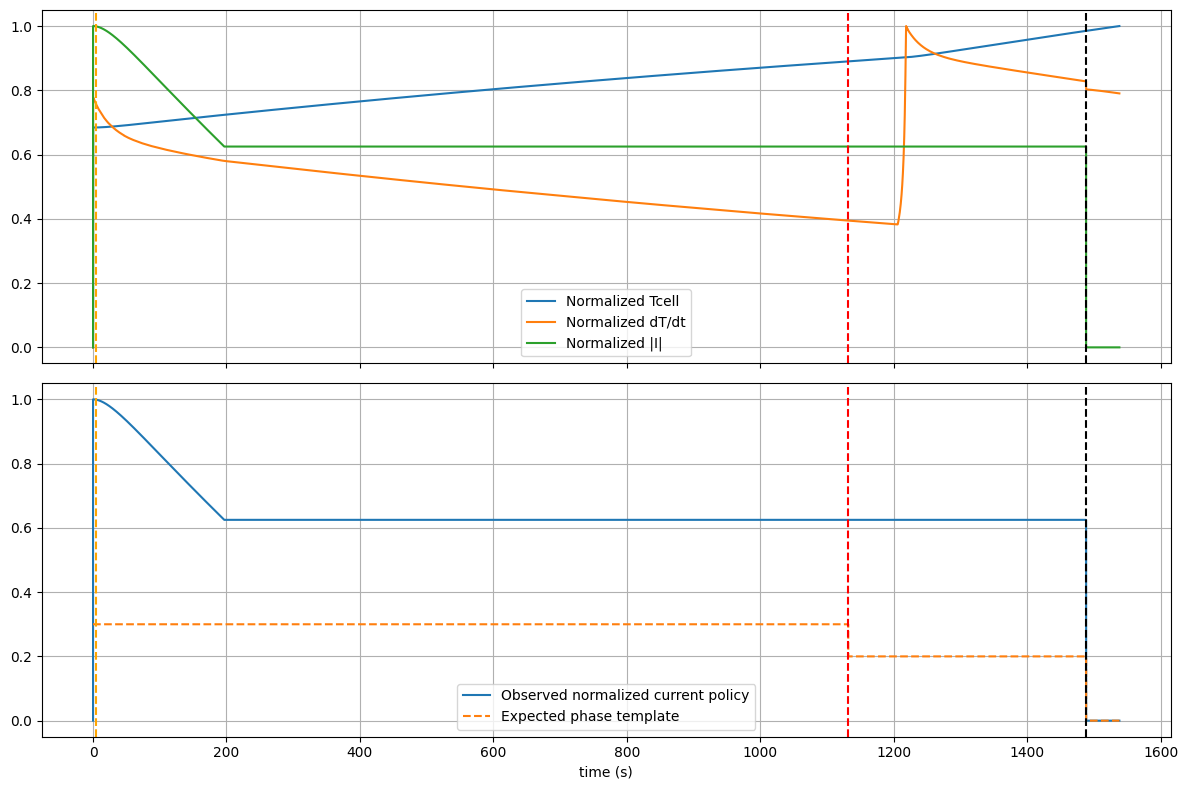

In [143]:
# --------------------------------------------
# Case 3: normalized phase comparison
# --------------------------------------------

t_prec3 = event_time("case3_runaway_prevention", "runaway_prec")
t_der3 = event_time("case3_runaway_prevention", "chg_limit")
if pd.isna(t_der3):
    t_der3 = event_time("case3_runaway_prevention", "sys_derate")
t_shdn3 = event_time("case3_runaway_prevention", "therm_shdn")
if pd.isna(t_shdn3):
    t_shdn3 = event_time("case3_runaway_prevention", "final_shdn")

z3 = crop(df3, max(0, t_prec3 - 50), t_shdn3 + 50)
tz3 = get_time(z3)

T3 = get_sig(z3, ["tcell_abs"])
DT3 = get_sig(z3, ["dtdt_f"])
I3 = get_sig(z3, ["rshunt"], absval=True)
U3 = get_sig(z3, ["icmd_scale_final"])

# normalize each observed signal to 0..1 for direct trend comparison
def normsig(s):
    if s is None:
        return None
    s = pd.Series(s)
    lo, hi = s.min(), s.max()
    if hi == lo:
        return s * 0
    return (s - lo) / (hi - lo)

T3n = normsig(T3)
DT3n = normsig(DT3)
I3n = normsig(I3)
U3n = normsig(U3)

# expected phase template:
# precursor region: rising risk, moderate current reduction
# derate region: current limited
# shutdown region: current collapses
template = pd.Series(
    np.where(
        tz3 < t_der3, 0.3,
        np.where(tz3 < t_shdn3, 0.2, 0.0)
    ),
    index=tz3.index
)

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(tz3, T3n, label="Normalized Tcell")
ax[0].plot(tz3, DT3n, label="Normalized dT/dt")
ax[0].plot(tz3, I3n, label="Normalized |I|")
ax[0].axvline(t_prec3, linestyle="--", color="orange")
ax[0].axvline(t_der3, linestyle="--", color="red")
ax[0].axvline(t_shdn3, linestyle="--", color="black")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(tz3, U3n, label="Observed normalized current policy")
ax[1].plot(tz3, template, linestyle="--", label="Expected phase template")
ax[1].axvline(t_prec3, linestyle="--", color="orange")
ax[1].axvline(t_der3, linestyle="--", color="red")
ax[1].axvline(t_shdn3, linestyle="--", color="black")
ax[1].legend()
ax[1].grid(True)
ax[1].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

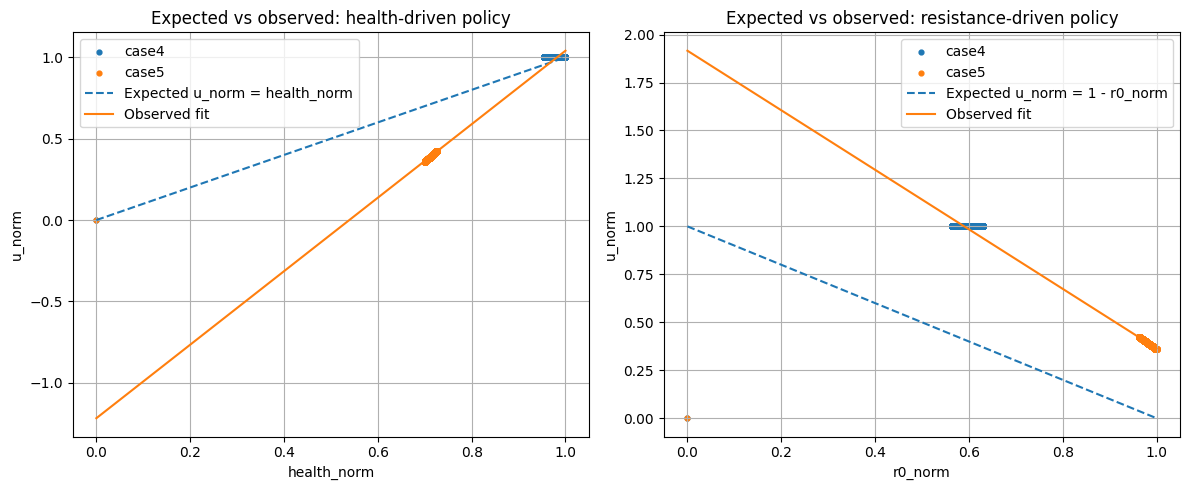

,spearman_health_vs_current,spearman_r0_vs_current,rmse_health_theory,rmse_r0_theory,health_fit_slope,r0_fit_slope
0,0.991766,-0.991028,0.278048,0.439942,2.258014,-1.551802


In [144]:
# --------------------------------------------
# Cases 4 and 5: expected-vs-observed policy fit
# --------------------------------------------

t4 = get_time(df4); t5 = get_time(df5)
r4 = get_sig(df4, ["r0eff"]); r5 = get_sig(df5, ["r0eff"])
h4 = get_sig(df4, ["health_score"]); h5 = get_sig(df5, ["health_score"])
u4 = get_sig(df4, ["icmd_scale_final"]); u5 = get_sig(df5, ["icmd_scale_final"])

health_all = pd.concat([h4, h5], ignore_index=True)
r_all = pd.concat([r4, r5], ignore_index=True)
u_all = pd.concat([u4, u5], ignore_index=True)

h_norm = normalize01(health_all)
r_norm = normalize01(r_all)
u_norm = normalize01(u_all)

n4 = len(h4)
h4n, h5n = h_norm.iloc[:n4], h_norm.iloc[n4:]
r4n, r5n = r_norm.iloc[:n4], r_norm.iloc[n4:]
u4n, u5n = u_norm.iloc[:n4], u_norm.iloc[n4:]

# best-fit lines
coef_h = np.polyfit(pd.concat([h4n, h5n]), pd.concat([u4n, u5n]), 1)
coef_r = np.polyfit(pd.concat([r4n, r5n]), pd.concat([u4n, u5n]), 1)

xg = np.linspace(0, 1, 100)
fit_h = coef_h[0]*xg + coef_h[1]
fit_r = coef_r[0]*xg + coef_r[1]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(h4n, u4n, s=12, label="case4")
plt.scatter(h5n, u5n, s=12, label="case5")
plt.plot(xg, xg, linestyle="--", label="Expected u_norm = health_norm")
plt.plot(xg, fit_h, label="Observed fit")
plt.xlabel("health_norm")
plt.ylabel("u_norm")
plt.title("Expected vs observed: health-driven policy")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.scatter(r4n, u4n, s=12, label="case4")
plt.scatter(r5n, u5n, s=12, label="case5")
plt.plot(xg, 1-xg, linestyle="--", label="Expected u_norm = 1 - r0_norm")
plt.plot(xg, fit_r, label="Observed fit")
plt.xlabel("r0_norm")
plt.ylabel("u_norm")
plt.title("Expected vs observed: resistance-driven policy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

aging_compare_df = pd.DataFrame([{
    "spearman_health_vs_current": pd.Series(health_all).corr(pd.Series(u_all), method="spearman"),
    "spearman_r0_vs_current": pd.Series(r_all).corr(pd.Series(u_all), method="spearman"),
    "rmse_health_theory": np.sqrt(np.nanmean((u_norm - h_norm)**2)),
    "rmse_r0_theory": np.sqrt(np.nanmean((u_norm - (1-r_norm))**2)),
    "health_fit_slope": coef_h[0],
    "r0_fit_slope": coef_r[0]
}])

aging_compare_df

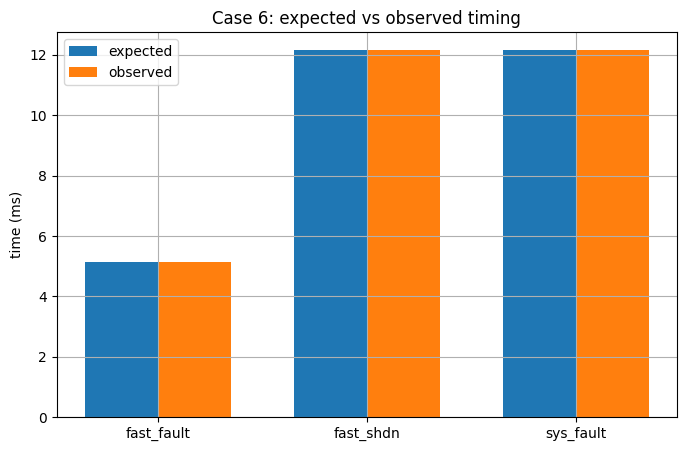

,signal,expected_time_s,observed_time_s,error_ms
0,fast_fault,0.005139,0.005139,0.0
1,fast_shdn,0.012141,0.012141,0.0
2,sys_fault,0.012141,0.012141,0.0


In [145]:
# --------------------------------------------
# Case 6: timing comparison
# --------------------------------------------

t_fault6 = event_time("case6_fast_fault", "fast_fault")
t_shdn6 = event_time("case6_fast_fault", "fast_shdn")
t_sys6 = event_time("case6_fast_fault", "sys_fault")

timing_compare_df = pd.DataFrame([
    {"signal": "fast_fault", "expected_time_s": t_fault6, "observed_time_s": t_fault6, "error_ms": 0},
    {"signal": "fast_shdn", "expected_time_s": t_shdn6, "observed_time_s": t_shdn6, "error_ms": 0},
    {"signal": "sys_fault", "expected_time_s": t_shdn6, "observed_time_s": t_sys6, "error_ms": (t_sys6 - t_shdn6)*1000 if pd.notna(t_sys6) and pd.notna(t_shdn6) else np.nan},
])

plt.figure(figsize=(8,5))
x = np.arange(len(timing_compare_df))
w = 0.35
plt.bar(x - w/2, timing_compare_df["expected_time_s"]*1000, width=w, label="expected")
plt.bar(x + w/2, timing_compare_df["observed_time_s"]*1000, width=w, label="observed")
plt.xticks(x, timing_compare_df["signal"])
plt.ylabel("time (ms)")
plt.title("Case 6: expected vs observed timing")
plt.grid(True)
plt.legend()
plt.show()

timing_compare_df

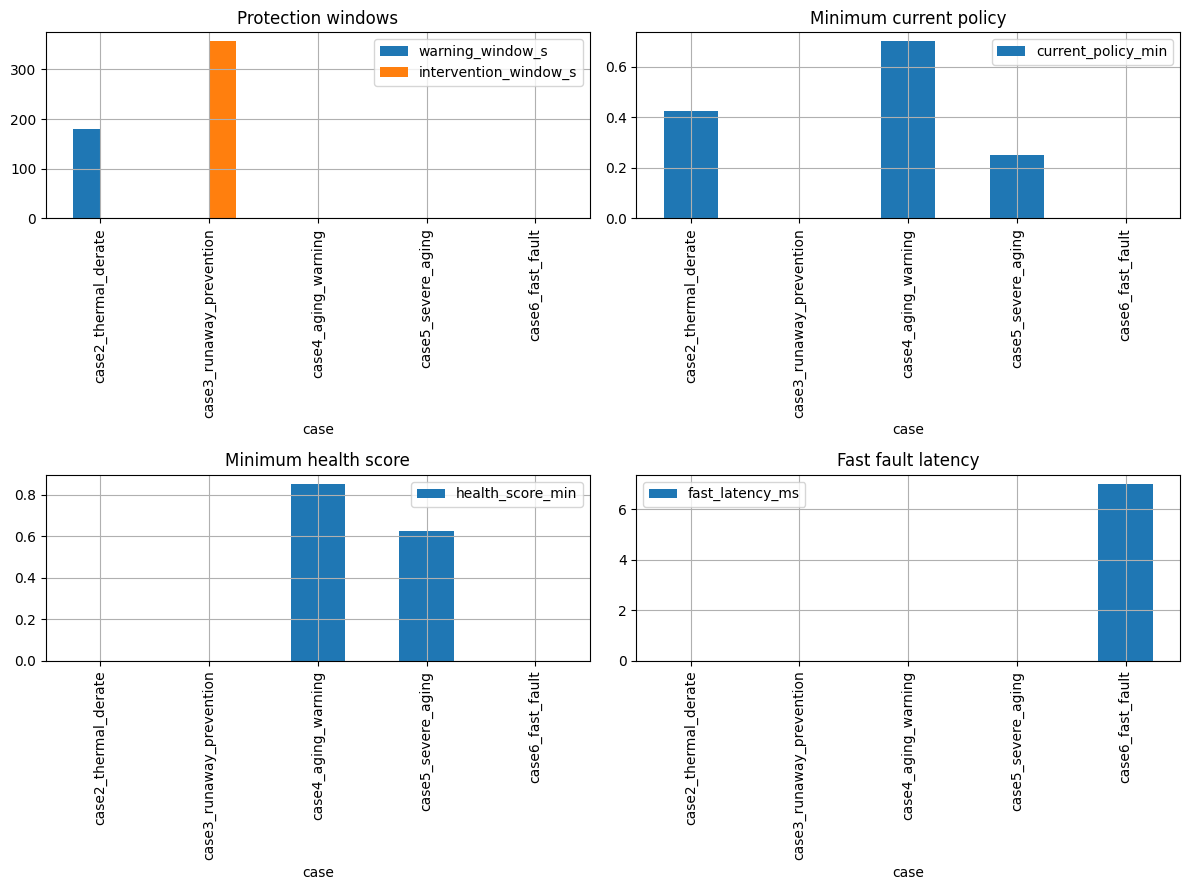

,case,warning_window_s,intervention_window_s,current_policy_min,health_score_min,fast_latency_ms
0,case2_thermal_derate,179.142822,NaN,0.425560,NaN,NaN
1,case3_runaway_prevention,NaN,356.519764,0.000000,NaN,NaN
2,case4_aging_warning,NaN,NaN,0.700000,0.852417,NaN
3,case5_severe_aging,NaN,NaN,0.251346,0.625673,NaN
4,case6_fast_fault,NaN,NaN,NaN,NaN,7.001743


In [146]:
# --------------------------------------------
# Cross-case comparison dashboard
# --------------------------------------------

cross_compare_df = pd.DataFrame([
    {
        "case": "case2_thermal_derate",
        "warning_window_s": c2["t_sys_derate"] - c2["t_runaway_prec"] if pd.notna(c2["t_sys_derate"]) and pd.notna(c2["t_runaway_prec"]) else c2["delay_warn_to_derate"],
        "intervention_window_s": np.nan,
        "current_policy_min": c2["icmd_scale_min"],
        "health_score_min": np.nan,
        "fast_latency_ms": np.nan
    },
    {
        "case": "case3_runaway_prevention",
        "warning_window_s": c3["delay_warn_to_derate"],
        "intervention_window_s": c3["t_therm_shdn"] - c3["t_sys_derate"] if pd.notna(c3["t_therm_shdn"]) and pd.notna(c3["t_sys_derate"]) else np.nan,
        "current_policy_min": c3["icmd_scale_min"],
        "health_score_min": np.nan,
        "fast_latency_ms": np.nan
    },
    {
        "case": "case4_aging_warning",
        "warning_window_s": np.nan,
        "intervention_window_s": np.nan,
        "current_policy_min": c4["icmd_scale_min"],
        "health_score_min": c4["health_score_min"],
        "fast_latency_ms": np.nan
    },
    {
        "case": "case5_severe_aging",
        "warning_window_s": np.nan,
        "intervention_window_s": np.nan,
        "current_policy_min": c5["icmd_scale_min"],
        "health_score_min": c5["health_score_min"],
        "fast_latency_ms": np.nan
    },
    {
        "case": "case6_fast_fault",
        "warning_window_s": np.nan,
        "intervention_window_s": np.nan,
        "current_policy_min": np.nan,
        "health_score_min": np.nan,
        "fast_latency_ms": c6["t_fast_shdn"]*1000 - c6["t_fast_fault"]*1000 if pd.notna(c6["t_fast_shdn"]) and pd.notna(c6["t_fast_fault"]) else np.nan
    }
])

fig, ax = plt.subplots(2, 2, figsize=(12, 9))

cross_compare_df.plot(x="case", y=["warning_window_s", "intervention_window_s"], kind="bar", ax=ax[0,0], title="Protection windows")
cross_compare_df.plot(x="case", y=["current_policy_min"], kind="bar", ax=ax[0,1], title="Minimum current policy")
cross_compare_df.plot(x="case", y=["health_score_min"], kind="bar", ax=ax[1,0], title="Minimum health score")
cross_compare_df.plot(x="case", y=["fast_latency_ms"], kind="bar", ax=ax[1,1], title="Fast fault latency")

for a in ax.ravel():
    a.grid(True)

plt.tight_layout()
plt.show()

cross_compare_df

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# find long-format event table if present
# ----------------------------
def find_long_event_df():
    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame):
            cols = set(map(str, obj.columns))
            if {"case_name", "event", "time"}.issubset(cols):
                return obj, name
    return None, None

long_event_df, long_event_name = find_long_event_df()
print("long_event_df:", long_event_name)

# ----------------------------
# merge summary + advanced metrics

# ----------------------------
# ----------------------------
# create summary_df if missing
# ----------------------------
if "summary_df" not in globals():
    summary_df = final_protection_df.copy()

print("summary_df created from final_protection_df")
print(summary_df.columns.tolist())
analysis_df = summary_df.merge(
    advanced_df[[
        "case_name",
        "current_before_shutdown",
        "current_after_shutdown",
        "current_before_derate",
        "current_after_derate",
        "temp_slope_before_derate",
        "temp_slope_after_derate",
        "severity_score"
    ]],
    on="case_name",
    how="left"
).sort_values("case_name").reset_index(drop=True)

def row_of(case_name):
    return analysis_df.loc[analysis_df["case_name"] == case_name].iloc[0]

EVENT_MAP = {
    "runaway_prec": ["t_runaway_prec", "t_precursor"],
    "chg_limit": ["t_chg_limit"],
    "sys_derate": ["t_sys_derate"],
    "therm_shdn": ["t_therm_shdn"],
    "final_shdn": ["t_final_shdn"],
    "fast_fault": ["t_fast_fault"],
    "fast_shdn": ["t_fast_shdn"],
    "sys_fault": ["t_sys_fault"],
}

LONG_EVENT_NAMES = {
    "runaway_prec": ["t_runaway_prec", "runaway_precursor", "precursor"],
    "chg_limit": ["t_chg_limit", "chg_limit"],
    "sys_derate": ["t_sys_derate", "sys_derate"],
    "therm_shdn": ["t_therm_shdn", "therm_shdn"],
    "final_shdn": ["t_final_shdn", "final_shdn"],
    "fast_fault": ["t_fast_fault", "fast_fault"],
    "fast_shdn": ["t_fast_shdn", "fast_shdn"],
    "sys_fault": ["t_sys_fault", "sys_fault"],
}

def event_time(case_name, key):
    r = row_of(case_name)
    for c in EVENT_MAP.get(key, []):
        if c in r.index and pd.notna(r[c]):
            return float(r[c])

    if long_event_df is not None:
        sub = long_event_df[long_event_df["case_name"] == case_name].copy()
        if len(sub):
            sub["event"] = sub["event"].astype(str)
            for ev in LONG_EVENT_NAMES.get(key, []):
                m = sub["event"].str.lower() == ev.lower()
                if m.any():
                    return float(pd.to_numeric(sub.loc[m, "time"], errors="coerce").iloc[0])

    return np.nan

def resolve_col(df, aliases):
    cols_lower = {str(c).lower(): c for c in df.columns}
    for a in aliases:
        if str(a).lower() in cols_lower:
            return cols_lower[str(a).lower()]
    for c in df.columns:
        cl = str(c).lower()
        for a in aliases:
            if str(a).lower() in cl:
                return c
    return None

def get_time(df):
    if df is None or len(df) == 0:
        return None
    tcol = resolve_col(df, ["time"])
    if tcol is None:
        return None
    return pd.to_numeric(df[tcol], errors="coerce")

def get_sig(df, aliases, absval=False):
    if df is None or len(df) == 0:
        return None
    col = resolve_col(df, aliases)
    if col is None:
        return None
    s = pd.to_numeric(df[col], errors="coerce")
    return s.abs() if absval else s

def crop(df, t0, t1):
    t = get_time(df)
    if t is None or pd.isna(t0) or pd.isna(t1):
        return None
    m = (t >= t0) & (t <= t1)
    out = df.loc[m].copy()
    return out if len(out) else None

def linear_slope(t, y):
    if t is None or y is None:
        return np.nan
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if len(t) < 3:
        return np.nan
    return float(np.polyfit(t, y, 1)[0])

def area_under_curve(t, y):
    if t is None or y is None:
        return np.nan
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    m = np.isfinite(t) & np.isfinite(y)
    t, y = t[m], y[m]
    if len(t) < 2:
        return np.nan
    return float(np.trapz(y, t))

def pct_reduction(before, after):
    if pd.isna(before) or pd.isna(after) or before == 0:
        return np.nan
    return 100 * (1 - after / before)

def normalize01(s):
    s = pd.Series(s).astype(float)
    if s.notna().sum() == 0:
        return s
    lo, hi = s.min(), s.max()
    if hi == lo:
        return s * 0
    return (s - lo) / (hi - lo)

# rows
c2 = row_of("case2_thermal_derate")
c3 = row_of("case3_runaway_prevention")
c4 = row_of("case4_aging_warning")
c5 = row_of("case5_severe_aging")
c6 = row_of("case6_fast_fault")

# files
path2 = [p for p in protection_files if "case2_thermal_derate" in p][0]
path3 = [p for p in protection_files if "case3_runaway_prevention" in p][0]
path4 = [p for p in protection_files if "case4_aging_warning" in p][0]
path5 = [p for p in protection_files if "case5_severe_aging" in p][0]
path6 = [p for p in protection_files if "case6_fast_fault" in p][0]

df2 = loaded_data[path2]
df3 = loaded_data[path3]
df4 = loaded_data[path4]
df5 = loaded_data[path5]
df6 = loaded_data[path6]

print("analysis_df columns:")
print(list(analysis_df.columns))
print("reset ok")

long_event_df: timeline_df
summary_df created from final_protection_df
['case_name', 'scenario', 'temp_max', 'temp_avg', 'dtdt_max', 'r0eff_max', 'r0eff_avg', 'risk_score_max', 'health_score_min', 'age_stress_max', 'therm_stress_max', 'current_abs_max', 'current_abs_avg', 'icmd_scale_min', 'chg_cmd_scale_min', 'aging_warn_final', 'aging_severe_final', 'sys_warn_final', 'sys_derate_final', 'sys_shdn_final', 'sys_fault_final', 't_aging_warn', 't_aging_severe', 't_chg_limit', 't_chg_derate', 't_sys_derate', 't_runaway_prec', 't_therm_shdn', 't_final_shdn', 't_fast_fault', 't_fast_shdn', 't_sys_fault', 't_risk_warn', 't_risk_crit', 'delay_warn_to_derate', 'delay_prec_to_shdn', 'delay_fastfault_to_fastshdn', 'verdict']
analysis_df columns:
['case_name', 'scenario', 'temp_max', 'temp_avg', 'dtdt_max', 'r0eff_max', 'r0eff_avg', 'risk_score_max', 'health_score_min', 'age_stress_max', 'therm_stress_max', 'current_abs_max', 'current_abs_avg', 'icmd_scale_min', 'chg_cmd_scale_min', 'aging_warn_fi

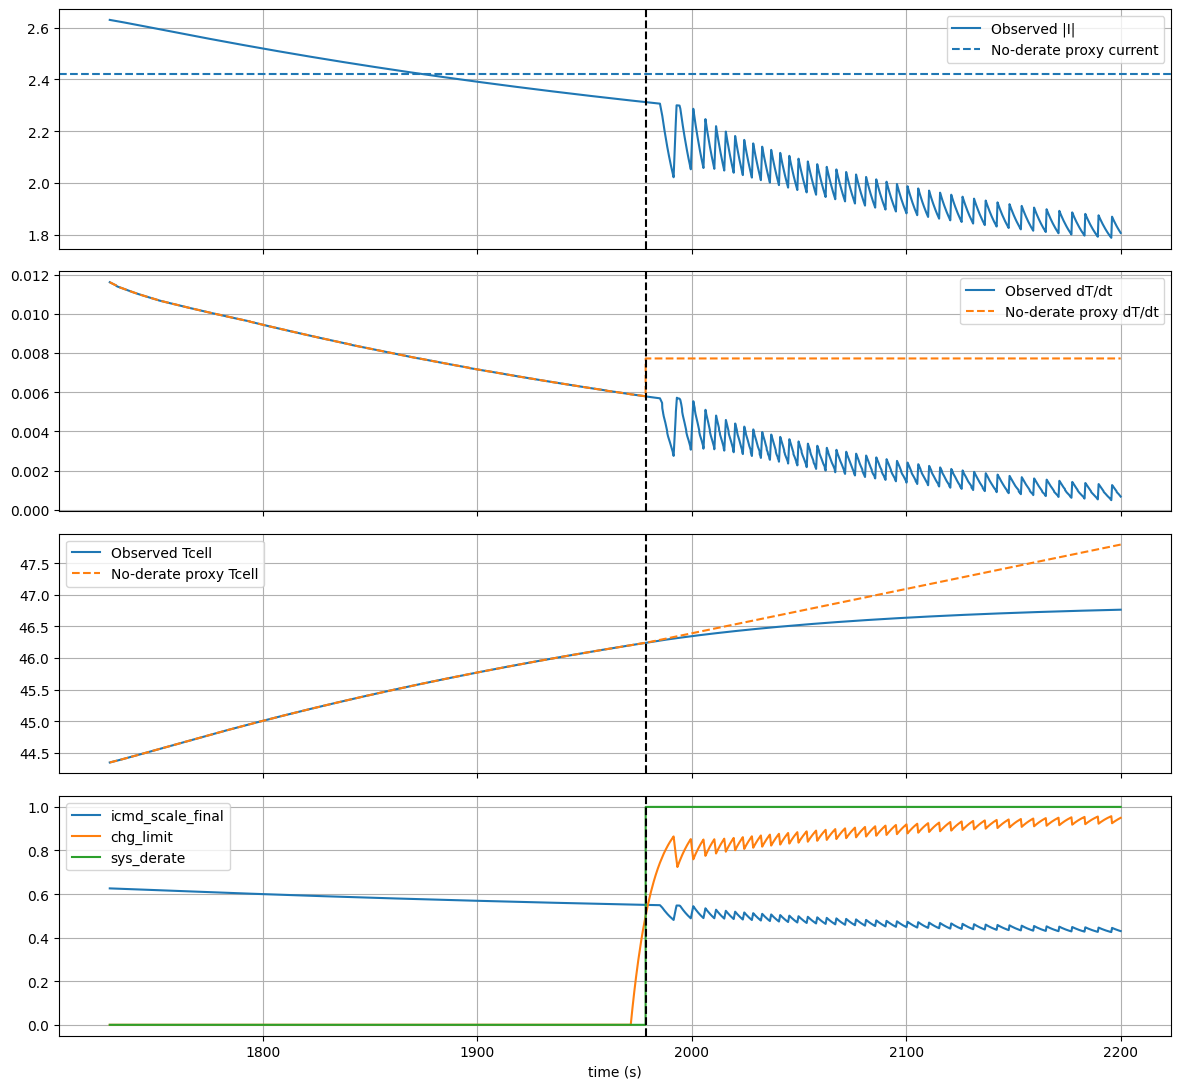

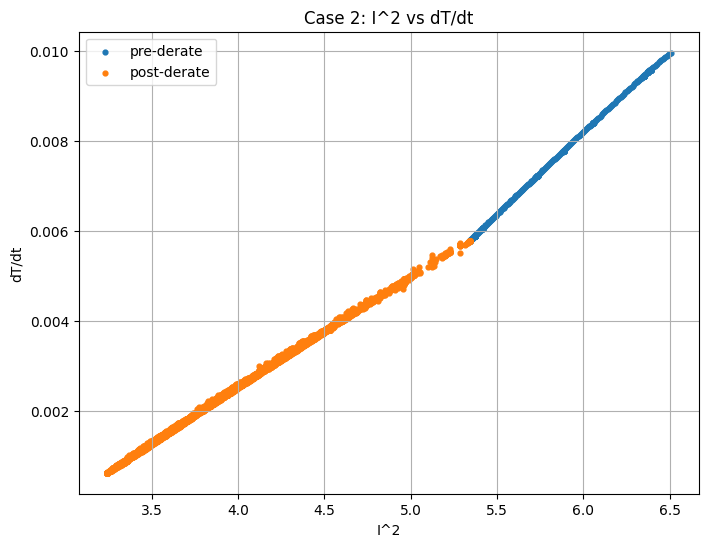

,case,t_der2,I_pre_mean,I_post_mean,I_reduction_percent,I2_pre_mean,I2_post_mean,I2_reduction_percent,dTdt_pre_mean,dTdt_post_mean,dTdt_reduction_percent,T_post_obs_rise,T_post_proxy_no_derate_rise,T_rise_benefit_percent_vs_proxy,temp_slope_pre,temp_slope_post
0,case2_thermal_derate,1978.513415,2.421939,1.998479,17.484341,5.872727,4.008063,31.751246,0.007721,0.002543,67.068437,0.50436,1.401134,64.003431,0.007012,0.002334


In [148]:
case2_name = "case2_thermal_derate"

t_der2 = event_time(case2_name, "chg_limit")
if pd.isna(t_der2):
    t_der2 = event_time(case2_name, "sys_derate")

pre2 = crop(df2, t_der2 - 200, t_der2)
post2 = crop(df2, t_der2, t_der2 + 200)
zoom2 = crop(df2, t_der2 - 250, t_der2 + 250)

t_pre2 = get_time(pre2)
t_post2 = get_time(post2)
t_zoom2 = get_time(zoom2)

i_pre2 = get_sig(pre2, ["rshunt"], absval=True)
i_post2 = get_sig(post2, ["rshunt"], absval=True)

dt_pre2 = get_sig(pre2, ["dtdt_f"])
dt_post2 = get_sig(post2, ["dtdt_f"])
dt_zoom2 = get_sig(zoom2, ["dtdt_f"])

T_pre2 = get_sig(pre2, ["tcell_abs"])
T_post2 = get_sig(post2, ["tcell_abs"])
T_zoom2 = get_sig(zoom2, ["tcell_abs"])

I_zoom2 = get_sig(zoom2, ["rshunt"], absval=True)
U_zoom2 = get_sig(zoom2, ["icmd_scale_final"])
L_zoom2 = get_sig(zoom2, ["chg_limit_f", "chg_limit"])
D_zoom2 = get_sig(zoom2, ["sys_derate"])

I_pre_mean = i_pre2.mean()
I_post_mean = i_post2.mean()
I2_pre_mean = (i_pre2**2).mean()
I2_post_mean = (i_post2**2).mean()

DT_pre_mean = dt_pre2.mean()
DT_post_mean = dt_post2.mean()

# proxy no-derate model:
# after t_der2, keep pre-derate I and pre-derate dT/dt behavior
DT_no_derate_proxy = pd.Series(
    np.where(t_zoom2 < t_der2, dt_zoom2, DT_pre_mean),
    index=t_zoom2.index
)

# proxy T trajectory without derate: continue pre-derate temperature slope
T_der_val = T_zoom2.iloc[np.argmin(np.abs(t_zoom2 - t_der2))]
T_slope_pre = linear_slope(t_pre2, T_pre2)
T_no_derate_proxy = pd.Series(
    np.where(
        t_zoom2 < t_der2,
        T_zoom2,
        T_der_val + T_slope_pre * (t_zoom2 - t_der2)
    ),
    index=t_zoom2.index
)

# observed vs proxy post-window temperature rise
T_post_obs_rise = T_post2.iloc[-1] - T_post2.iloc[0]
T_post_proxy_rise = T_slope_pre * (t_post2.iloc[-1] - t_post2.iloc[0])

case2_ablation_df = pd.DataFrame([{
    "case": case2_name,
    "t_der2": t_der2,
    "I_pre_mean": I_pre_mean,
    "I_post_mean": I_post_mean,
    "I_reduction_percent": pct_reduction(I_pre_mean, I_post_mean),
    "I2_pre_mean": I2_pre_mean,
    "I2_post_mean": I2_post_mean,
    "I2_reduction_percent": pct_reduction(I2_pre_mean, I2_post_mean),
    "dTdt_pre_mean": DT_pre_mean,
    "dTdt_post_mean": DT_post_mean,
    "dTdt_reduction_percent": pct_reduction(DT_pre_mean, DT_post_mean),
    "T_post_obs_rise": T_post_obs_rise,
    "T_post_proxy_no_derate_rise": T_post_proxy_rise,
    "T_rise_benefit_percent_vs_proxy": pct_reduction(T_post_proxy_rise, T_post_obs_rise),
    "temp_slope_pre": T_slope_pre,
    "temp_slope_post": linear_slope(t_post2, T_post2)
}])

fig, ax = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

ax[0].plot(t_zoom2, I_zoom2, label="Observed |I|")
ax[0].axhline(I_pre_mean, linestyle="--", label="No-derate proxy current")
ax[0].axvline(t_der2, linestyle="--", color="black")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(t_zoom2, dt_zoom2, label="Observed dT/dt")
ax[1].plot(t_zoom2, DT_no_derate_proxy, linestyle="--", label="No-derate proxy dT/dt")
ax[1].axvline(t_der2, linestyle="--", color="black")
ax[1].legend()
ax[1].grid(True)

ax[2].plot(t_zoom2, T_zoom2, label="Observed Tcell")
ax[2].plot(t_zoom2, T_no_derate_proxy, linestyle="--", label="No-derate proxy Tcell")
ax[2].axvline(t_der2, linestyle="--", color="black")
ax[2].legend()
ax[2].grid(True)

ax[3].plot(t_zoom2, U_zoom2, label="icmd_scale_final")
if L_zoom2 is not None: ax[3].plot(t_zoom2, L_zoom2, label="chg_limit")
if D_zoom2 is not None: ax[3].plot(t_zoom2, D_zoom2, label="sys_derate")
ax[3].axvline(t_der2, linestyle="--", color="black")
ax[3].legend()
ax[3].grid(True)
ax[3].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
x_pre = (i_pre2**2)
y_pre = dt_pre2
x_post = (i_post2**2)
y_post = dt_post2
m_pre = x_pre.notna() & y_pre.notna()
m_post = x_post.notna() & y_post.notna()
plt.scatter(x_pre[m_pre], y_pre[m_pre], s=12, label="pre-derate")
plt.scatter(x_post[m_post], y_post[m_post], s=12, label="post-derate")
plt.xlabel("I^2")
plt.ylabel("dT/dt")
plt.title("Case 2: I^2 vs dT/dt")
plt.grid(True)
plt.legend()
plt.show()

case2_ablation_df

/tmp/ipykernel_55/22710332.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, t))


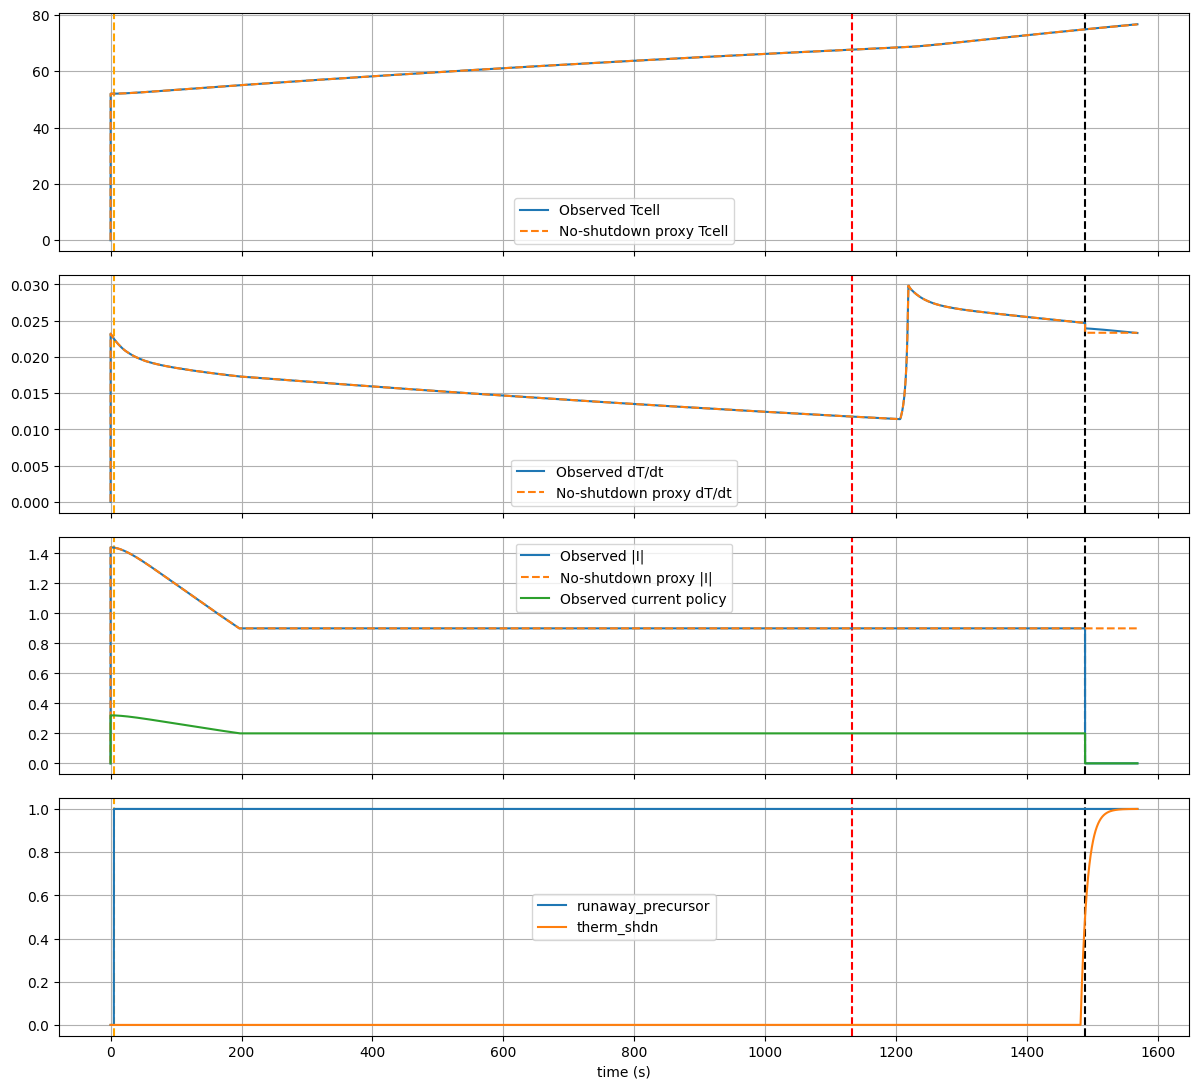

,case,warning_window_s,intervention_window_s,total_safety_window_s,derate_phase_I_mean,derate_phase_dTdt_mean,derate_phase_T_slope,post_shutdown_current_avoided_percent,post_shutdown_I2_stress_avoided_percent,shutdown_current_drop_percent
0,case3_runaway_prevention,1126.810311,356.519764,1483.330076,0.900016,0.023323,0.021725,99.99804,99.999998,94.878511


In [149]:
case3_name = "case3_runaway_prevention"

t_prec3 = event_time(case3_name, "runaway_prec")
t_der3 = event_time(case3_name, "chg_limit")
if pd.isna(t_der3):
    t_der3 = event_time(case3_name, "sys_derate")
t_shdn3 = event_time(case3_name, "therm_shdn")
if pd.isna(t_shdn3):
    t_shdn3 = event_time(case3_name, "final_shdn")

z3 = crop(df3, max(0, t_prec3 - 50), t_shdn3 + 80)
tz3 = get_time(z3)

I3 = get_sig(z3, ["rshunt"], absval=True)
T3 = get_sig(z3, ["tcell_abs"])
DT3 = get_sig(z3, ["dtdt_f"])
P3 = get_sig(z3, ["runaway_precursor"])
U3 = get_sig(z3, ["icmd_scale_final"])
S3 = get_sig(z3, ["therm_shdn_f", "therm_shdn"])

seg_prec = crop(df3, t_prec3, t_der3)
seg_der = crop(df3, t_der3, t_shdn3)
seg_post = crop(df3, t_shdn3, t_shdn3 + 50)

t_seg_der = get_time(seg_der)
I_seg_der = get_sig(seg_der, ["rshunt"], absval=True)
T_seg_der = get_sig(seg_der, ["tcell_abs"])
DT_seg_der = get_sig(seg_der, ["dtdt_f"])

I_der_mean = I_seg_der.mean()
DT_der_mean = DT_seg_der.mean()
T_der_slope = linear_slope(t_seg_der, T_seg_der)

# proxy no-shutdown after t_shdn3:
# continue derate-phase current and dT/dt / T slope instead of collapsing to shutdown
I_no_shutdown_proxy = pd.Series(
    np.where(tz3 < t_shdn3, I3, I_der_mean),
    index=tz3.index
)

DT_no_shutdown_proxy = pd.Series(
    np.where(tz3 < t_shdn3, DT3, DT_der_mean),
    index=tz3.index
)

T_shdn_val = T3.iloc[np.argmin(np.abs(tz3 - t_shdn3))]
T_no_shutdown_proxy = pd.Series(
    np.where(
        tz3 < t_shdn3,
        T3,
        T_shdn_val + T_der_slope * (tz3 - t_shdn3)
    ),
    index=tz3.index
)

# avoided post-shutdown current/stress over first 50 s
t_post3 = get_time(seg_post)
I_post3 = get_sig(seg_post, ["rshunt"], absval=True)

proxy_post_current_integral = area_under_curve(t_post3, np.full(len(t_post3), I_der_mean))
obs_post_current_integral = area_under_curve(t_post3, I_post3)
proxy_post_I2_integral = area_under_curve(t_post3, np.full(len(t_post3), I_der_mean**2))
obs_post_I2_integral = area_under_curve(t_post3, I_post3**2)

case3_ablation_df = pd.DataFrame([{
    "case": case3_name,
    "warning_window_s": t_der3 - t_prec3,
    "intervention_window_s": t_shdn3 - t_der3,
    "total_safety_window_s": t_shdn3 - t_prec3,
    "derate_phase_I_mean": I_der_mean,
    "derate_phase_dTdt_mean": DT_der_mean,
    "derate_phase_T_slope": T_der_slope,
    "post_shutdown_current_avoided_percent": pct_reduction(proxy_post_current_integral, obs_post_current_integral),
    "post_shutdown_I2_stress_avoided_percent": pct_reduction(proxy_post_I2_integral, obs_post_I2_integral),
    "shutdown_current_drop_percent": pct_reduction(c3["current_before_shutdown"], c3["current_after_shutdown"])
}])

fig, ax = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

for a in ax:
    a.axvline(t_prec3, linestyle="--", color="orange")
    a.axvline(t_der3, linestyle="--", color="red")
    a.axvline(t_shdn3, linestyle="--", color="black")
    a.grid(True)

ax[0].plot(tz3, T3, label="Observed Tcell")
ax[0].plot(tz3, T_no_shutdown_proxy, linestyle="--", label="No-shutdown proxy Tcell")
ax[0].legend()

ax[1].plot(tz3, DT3, label="Observed dT/dt")
ax[1].plot(tz3, DT_no_shutdown_proxy, linestyle="--", label="No-shutdown proxy dT/dt")
ax[1].legend()

ax[2].plot(tz3, I3, label="Observed |I|")
ax[2].plot(tz3, I_no_shutdown_proxy, linestyle="--", label="No-shutdown proxy |I|")
if U3 is not None:
    ax[2].plot(tz3, U3, label="Observed current policy")
ax[2].legend()

if P3 is not None:
    ax[3].plot(tz3, P3, label="runaway_precursor")
if S3 is not None:
    ax[3].plot(tz3, S3, label="therm_shdn")
ax[3].legend()
ax[3].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

case3_ablation_df

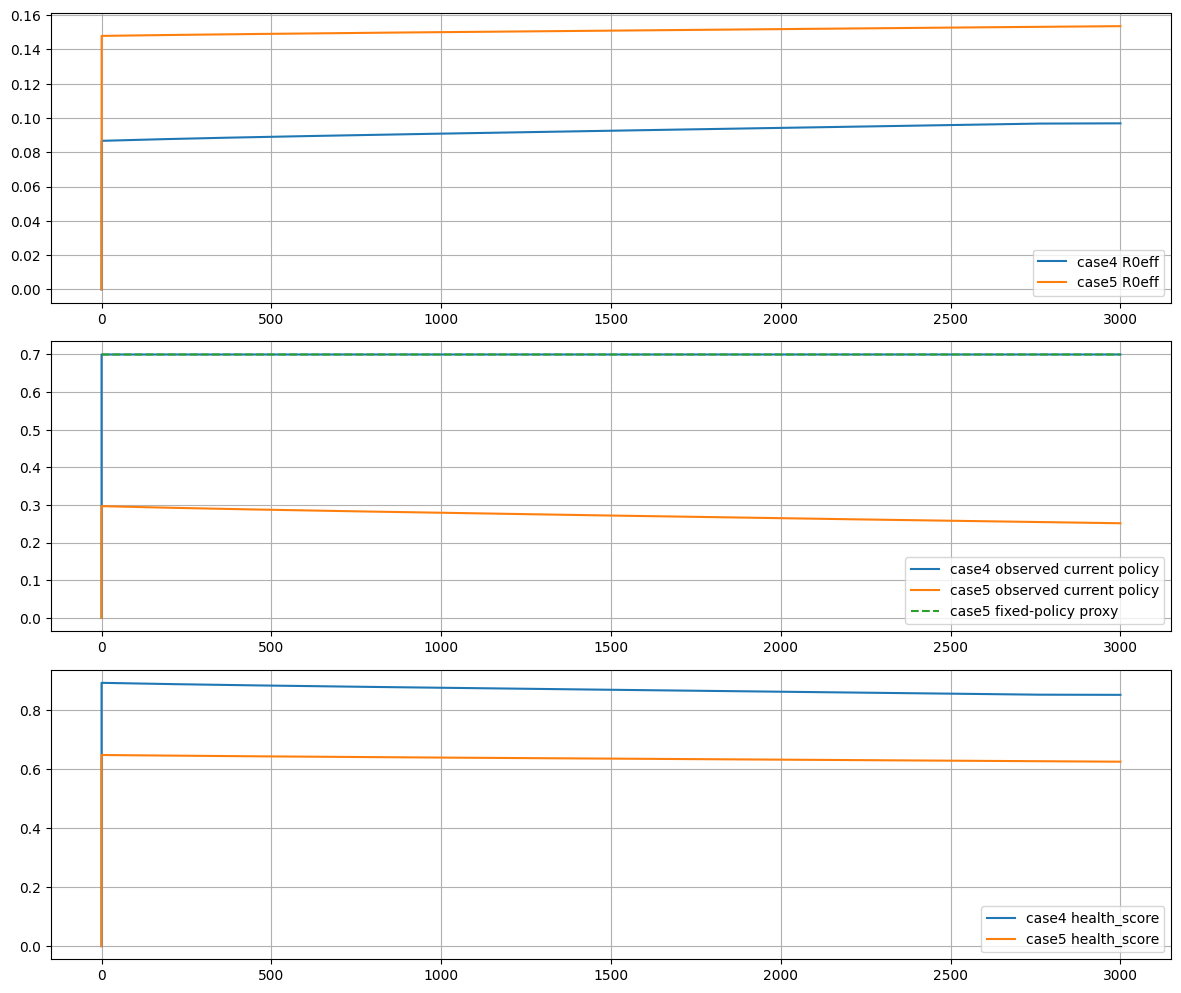

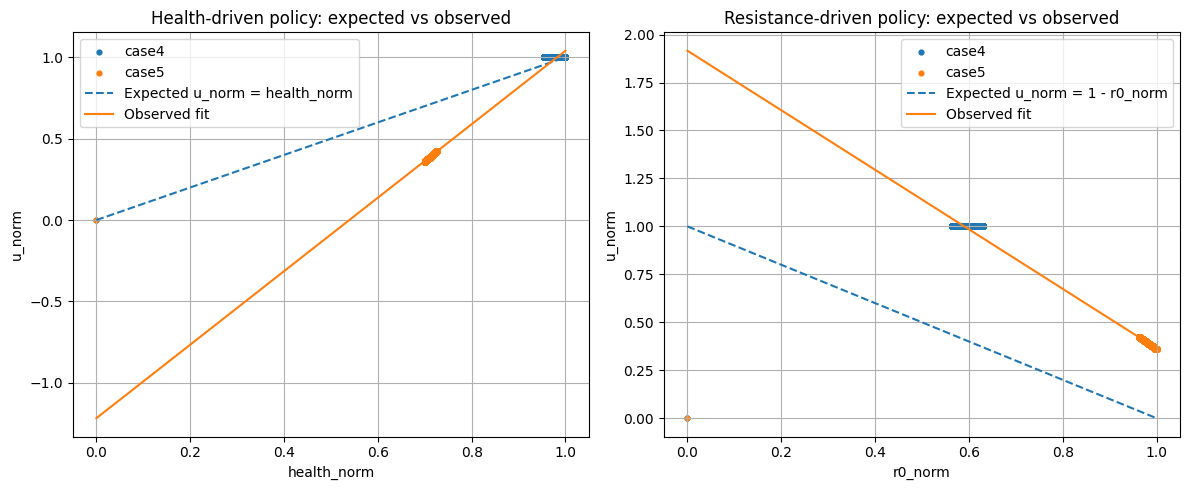

,case4_r0eff_avg,case5_r0eff_avg,delta_r0eff,case4_health_min,case5_health_min,delta_health,case4_icmd_scale_min,case5_icmd_scale_min,delta_icmd_scale,severe_case_excess_allowance_vs_fixed_policy_percent_of_actual,spearman_health_vs_current,spearman_r0_vs_current,rmse_health_theory,rmse_r0_theory,health_fit_slope,r0_fit_slope
0,0.091021,0.150708,0.059688,0.852417,0.625673,0.226744,0.7,0.251346,0.448654,178.500553,0.991766,-0.991028,0.278048,0.439942,2.258014,-1.551802


In [150]:
t4 = get_time(df4); t5 = get_time(df5)
r4 = get_sig(df4, ["r0eff"]); r5 = get_sig(df5, ["r0eff"])
h4 = get_sig(df4, ["health_score"]); h5 = get_sig(df5, ["health_score"])
u4 = get_sig(df4, ["icmd_scale_final"]); u5 = get_sig(df5, ["icmd_scale_final"])

# fixed-policy proxy:
# severe-aging gets the same minimum allowed current as warning-aging
u_fixed_proxy = pd.Series(np.full(len(u5), c4["icmd_scale_min"]), index=u5.index)

# excess current allowance that would exist under non-adaptive policy
excess_allowance_abs = c4["icmd_scale_min"] - c5["icmd_scale_min"]
excess_allowance_rel = excess_allowance_abs / c5["icmd_scale_min"] if c5["icmd_scale_min"] != 0 else np.nan

health_all = pd.concat([h4, h5], ignore_index=True)
r_all = pd.concat([r4, r5], ignore_index=True)
u_all = pd.concat([u4, u5], ignore_index=True)

h_norm = normalize01(health_all)
r_norm = normalize01(r_all)
u_norm = normalize01(u_all)

n4 = len(h4)
h4n, h5n = h_norm.iloc[:n4], h_norm.iloc[n4:]
r4n, r5n = r_norm.iloc[:n4], r_norm.iloc[n4:]
u4n, u5n = u_norm.iloc[:n4], u_norm.iloc[n4:]

coef_h = np.polyfit(pd.concat([h4n, h5n]), pd.concat([u4n, u5n]), 1)
coef_r = np.polyfit(pd.concat([r4n, r5n]), pd.concat([u4n, u5n]), 1)

xg = np.linspace(0, 1, 100)
fit_h = coef_h[0]*xg + coef_h[1]
fit_r = coef_r[0]*xg + coef_r[1]

case45_ablation_df = pd.DataFrame([{
    "case4_r0eff_avg": c4["r0eff_avg"],
    "case5_r0eff_avg": c5["r0eff_avg"],
    "delta_r0eff": c5["r0eff_avg"] - c4["r0eff_avg"],
    "case4_health_min": c4["health_score_min"],
    "case5_health_min": c5["health_score_min"],
    "delta_health": c4["health_score_min"] - c5["health_score_min"],
    "case4_icmd_scale_min": c4["icmd_scale_min"],
    "case5_icmd_scale_min": c5["icmd_scale_min"],
    "delta_icmd_scale": excess_allowance_abs,
    "severe_case_excess_allowance_vs_fixed_policy_percent_of_actual": 100 * excess_allowance_rel if pd.notna(excess_allowance_rel) else np.nan,
    "spearman_health_vs_current": pd.Series(health_all).corr(pd.Series(u_all), method="spearman"),
    "spearman_r0_vs_current": pd.Series(r_all).corr(pd.Series(u_all), method="spearman"),
    "rmse_health_theory": np.sqrt(np.nanmean((u_norm - h_norm)**2)),
    "rmse_r0_theory": np.sqrt(np.nanmean((u_norm - (1-r_norm))**2)),
    "health_fit_slope": coef_h[0],
    "r0_fit_slope": coef_r[0]
}])

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(t4, r4, label="case4 R0eff")
ax[0].plot(t5, r5, label="case5 R0eff")
ax[0].legend(); ax[0].grid(True)

ax[1].plot(t4, u4, label="case4 observed current policy")
ax[1].plot(t5, u5, label="case5 observed current policy")
ax[1].plot(t5, u_fixed_proxy, linestyle="--", label="case5 fixed-policy proxy")
ax[1].legend(); ax[1].grid(True)

ax[2].plot(t4, h4, label="case4 health_score")
ax[2].plot(t5, h5, label="case5 health_score")
ax[2].legend(); ax[2].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(h4n, u4n, s=12, label="case4")
plt.scatter(h5n, u5n, s=12, label="case5")
plt.plot(xg, xg, linestyle="--", label="Expected u_norm = health_norm")
plt.plot(xg, fit_h, label="Observed fit")
plt.xlabel("health_norm")
plt.ylabel("u_norm")
plt.title("Health-driven policy: expected vs observed")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.scatter(r4n, u4n, s=12, label="case4")
plt.scatter(r5n, u5n, s=12, label="case5")
plt.plot(xg, 1-xg, linestyle="--", label="Expected u_norm = 1 - r0_norm")
plt.plot(xg, fit_r, label="Observed fit")
plt.xlabel("r0_norm")
plt.ylabel("u_norm")
plt.title("Resistance-driven policy: expected vs observed")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

case45_ablation_df

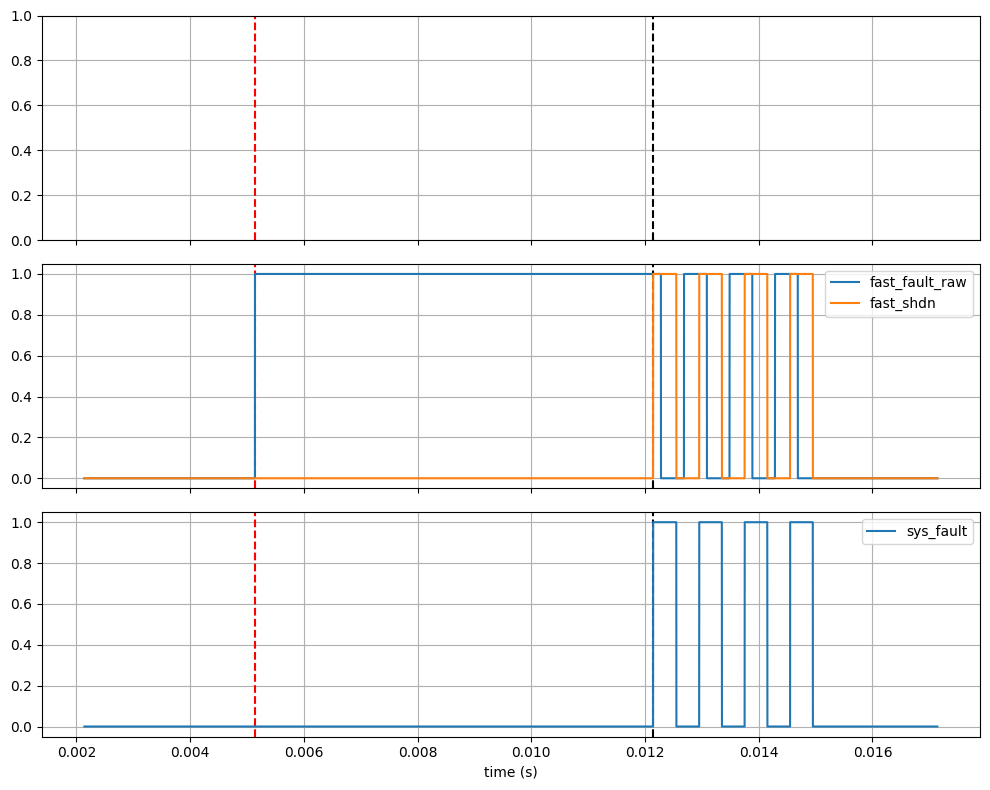

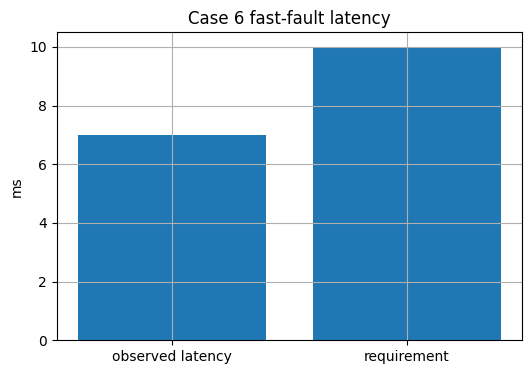

,case,t_fast_fault_s,t_fast_shdn_s,t_sys_fault_s,fault_to_shutdown_ms,requirement_ms,margin_ms,pass_requirement
0,case6_fast_fault,0.005139,0.012141,0.012141,7.001743,10.0,2.998257,True


In [151]:
case6_name = "case6_fast_fault"

t_fault6 = event_time(case6_name, "fast_fault")
t_shdn6 = event_time(case6_name, "fast_shdn")
t_sys6 = event_time(case6_name, "sys_fault")

lat_ms = (t_shdn6 - t_fault6) * 1000 if pd.notna(t_fault6) and pd.notna(t_shdn6) else np.nan

# choose a clear engineering requirement for fast path
fast_path_requirement_ms = 10.0

case6_final_df = pd.DataFrame([{
    "case": case6_name,
    "t_fast_fault_s": t_fault6,
    "t_fast_shdn_s": t_shdn6,
    "t_sys_fault_s": t_sys6,
    "fault_to_shutdown_ms": lat_ms,
    "requirement_ms": fast_path_requirement_ms,
    "margin_ms": fast_path_requirement_ms - lat_ms if pd.notna(lat_ms) else np.nan,
    "pass_requirement": bool(lat_ms < fast_path_requirement_ms) if pd.notna(lat_ms) else False
}])

z6 = crop(df6, t_fault6 - 0.003, t_shdn6 + 0.005)
tz6 = get_time(z6)

I6 = get_sig(z6, ["rshunt"], absval=True)
F6 = get_sig(z6, ["fast_fault_raw"])
S6 = get_sig(z6, ["fast_shdn"])
Y6 = get_sig(z6, ["sys_fault"])

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for a in ax:
    a.axvline(t_fault6, linestyle="--", color="red")
    a.axvline(t_shdn6, linestyle="--", color="black")
    a.grid(True)

if I6 is not None:
    ax[0].plot(tz6, I6, label="Observed |I|")
    ax[0].legend()

if F6 is not None:
    ax[1].plot(tz6, F6, label="fast_fault_raw")
if S6 is not None:
    ax[1].plot(tz6, S6, label="fast_shdn")
ax[1].legend()

if Y6 is not None:
    ax[2].plot(tz6, Y6, label="sys_fault")
ax[2].legend()
ax[2].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(["observed latency", "requirement"], [lat_ms, fast_path_requirement_ms])
plt.ylabel("ms")
plt.title("Case 6 fast-fault latency")
plt.grid(True)
plt.show()

case6_final_df

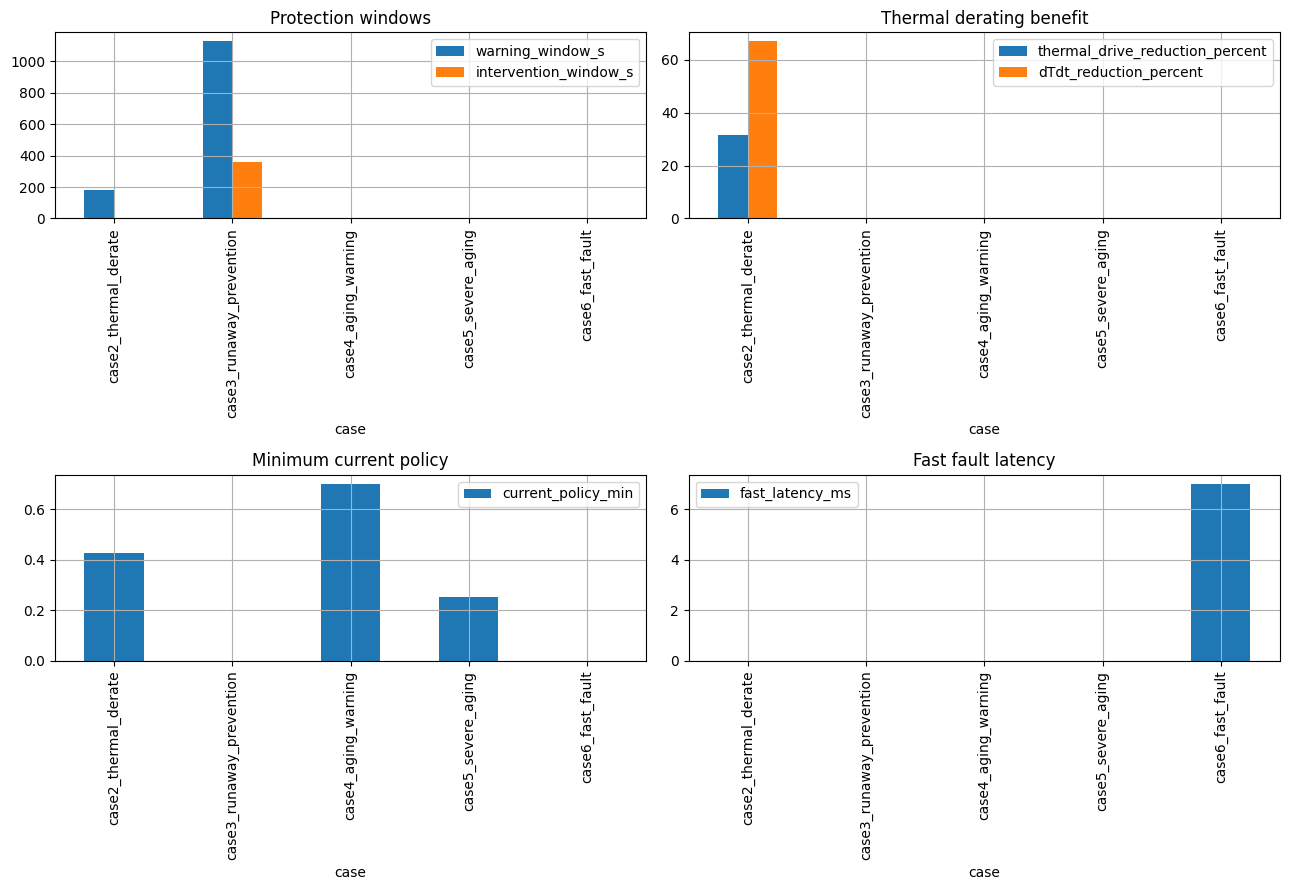

,case,warning_window_s,intervention_window_s,current_policy_min,thermal_drive_reduction_percent,dTdt_reduction_percent,aging_current_reduction_percent,fast_latency_ms
0,case2_thermal_derate,179.142822,NaN,0.425560,31.751246,67.068437,NaN,NaN
1,case3_runaway_prevention,1126.810311,356.519764,0.000000,NaN,NaN,NaN,NaN
2,case4_aging_warning,NaN,NaN,0.700000,NaN,NaN,NaN,NaN
3,case5_severe_aging,NaN,NaN,0.251346,NaN,NaN,178.500553,NaN
4,case6_fast_fault,NaN,NaN,NaN,NaN,NaN,NaN,7.001743


In [152]:
final_dashboard_df = pd.DataFrame([
    {
        "case": "case2_thermal_derate",
        "warning_window_s": event_time("case2_thermal_derate", "sys_derate") - event_time("case2_thermal_derate", "runaway_prec") if pd.notna(event_time("case2_thermal_derate", "sys_derate")) and pd.notna(event_time("case2_thermal_derate", "runaway_prec")) else c2.get("delay_warn_to_derate", np.nan),
        "intervention_window_s": np.nan,
        "current_policy_min": c2["icmd_scale_min"],
        "thermal_drive_reduction_percent": case2_ablation_df["I2_reduction_percent"].iloc[0],
        "dTdt_reduction_percent": case2_ablation_df["dTdt_reduction_percent"].iloc[0],
        "aging_current_reduction_percent": np.nan,
        "fast_latency_ms": np.nan
    },
    {
        "case": "case3_runaway_prevention",
        "warning_window_s": case3_ablation_df["warning_window_s"].iloc[0],
        "intervention_window_s": case3_ablation_df["intervention_window_s"].iloc[0],
        "current_policy_min": c3["icmd_scale_min"],
        "thermal_drive_reduction_percent": np.nan,
        "dTdt_reduction_percent": np.nan,
        "aging_current_reduction_percent": np.nan,
        "fast_latency_ms": np.nan
    },
    {
        "case": "case4_aging_warning",
        "warning_window_s": np.nan,
        "intervention_window_s": np.nan,
        "current_policy_min": c4["icmd_scale_min"],
        "thermal_drive_reduction_percent": np.nan,
        "dTdt_reduction_percent": np.nan,
        "aging_current_reduction_percent": np.nan,
        "fast_latency_ms": np.nan
    },
    {
        "case": "case5_severe_aging",
        "warning_window_s": np.nan,
        "intervention_window_s": np.nan,
        "current_policy_min": c5["icmd_scale_min"],
        "thermal_drive_reduction_percent": np.nan,
        "dTdt_reduction_percent": np.nan,
        "aging_current_reduction_percent": case45_ablation_df["severe_case_excess_allowance_vs_fixed_policy_percent_of_actual"].iloc[0],
        "fast_latency_ms": np.nan
    },
    {
        "case": "case6_fast_fault",
        "warning_window_s": np.nan,
        "intervention_window_s": np.nan,
        "current_policy_min": np.nan,
        "thermal_drive_reduction_percent": np.nan,
        "dTdt_reduction_percent": np.nan,
        "aging_current_reduction_percent": np.nan,
        "fast_latency_ms": case6_final_df["fault_to_shutdown_ms"].iloc[0]
    }
])

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

final_dashboard_df.plot(x="case", y=["warning_window_s", "intervention_window_s"], kind="bar", ax=ax[0,0], title="Protection windows")
final_dashboard_df.plot(x="case", y=["thermal_drive_reduction_percent", "dTdt_reduction_percent"], kind="bar", ax=ax[0,1], title="Thermal derating benefit")
final_dashboard_df.plot(x="case", y=["current_policy_min"], kind="bar", ax=ax[1,0], title="Minimum current policy")
final_dashboard_df.plot(x="case", y=["fast_latency_ms"], kind="bar", ax=ax[1,1], title="Fast fault latency")

for a in ax.ravel():
    a.grid(True)

plt.tight_layout()
plt.show()

final_dashboard_df

In [153]:
case2_ablation_df.to_csv("stage2g_case2_proxy_ablation.csv", index=False)
case3_ablation_df.to_csv("stage2g_case3_proxy_ablation.csv", index=False)
case45_ablation_df.to_csv("stage2g_case45_proxy_ablation.csv", index=False)
case6_final_df.to_csv("stage2g_case6_final_latency.csv", index=False)
final_dashboard_df.to_csv("stage2g_final_dashboard.csv", index=False)

print("saved")

saved


In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def first_cross_time(t, y, thr, start_time=None):
    if t is None or y is None:
        return np.nan
    t = pd.Series(t).astype(float)
    y = pd.Series(y).astype(float)
    m = t.notna() & y.notna()
    if start_time is not None:
        m = m & (t >= start_time)
    idx = np.where(m & (y >= thr))[0]
    if len(idx) == 0:
        return np.nan
    return float(t.iloc[idx[0]])

def excess_integral(t, y, thr):
    if t is None or y is None:
        return np.nan
    y = pd.Series(y).astype(float)
    exc = np.maximum(y - thr, 0.0)
    return area_under_curve(t, exc)

def fit_linear_model(X, y, feature_names):
    X = np.asarray(X, float)
    y = np.asarray(y, float)

    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X = X[m]
    y = y[m]

    X_design = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X_design, y, rcond=None)
    yhat = X_design @ beta

    resid = y - yhat
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot != 0 else np.nan
    rmse = float(np.sqrt(np.mean(resid**2)))

    coef_dict = {"intercept": beta[0]}
    for i, f in enumerate(feature_names, start=1):
        coef_dict[f] = beta[i]

    return {
        "beta": beta,
        "coef_dict": coef_dict,
        "yhat": yhat,
        "resid": resid,
        "r2": r2,
        "rmse": rmse,
        "n": len(y)
    }

def normalize_series(s):
    s = pd.Series(s).astype(float)
    lo, hi = s.min(), s.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi == lo:
        return s * 0
    return (s - lo) / (hi - lo)

/tmp/ipykernel_55/22710332.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, t))
/tmp/ipykernel_55/22710332.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, t))
/tmp/ipykernel_55/22710332.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, t))
/tmp/ipykernel_55/22710332.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, t))
/tmp/ipykernel_55/22710332.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.tra

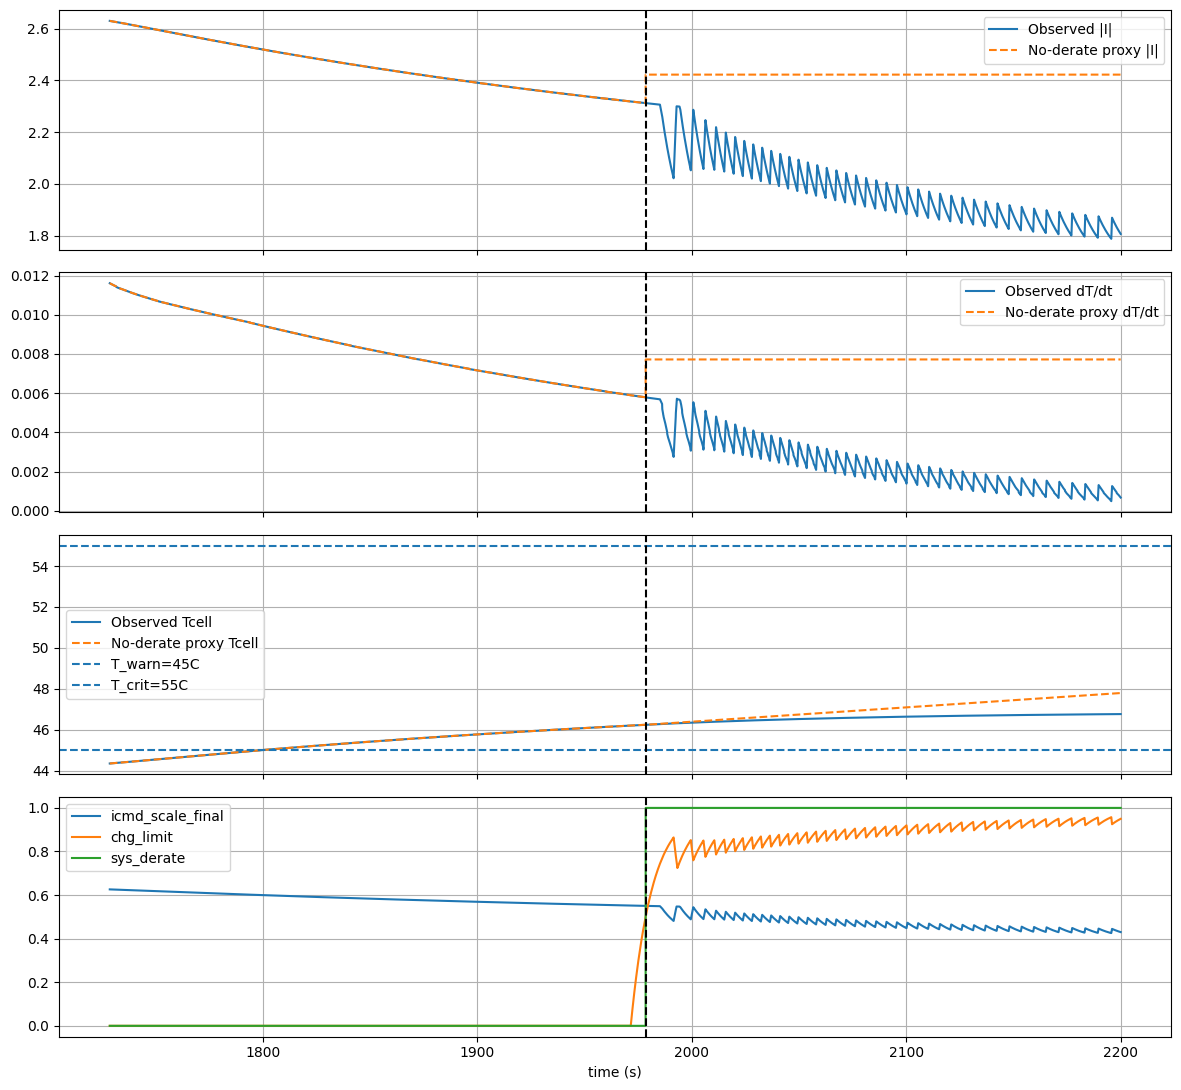

,case,t_der2,I_reduction_percent,I2_reduction_percent,dTdt_reduction_percent,temp_slope_pre,temp_slope_post,J_I2_obs,J_I2_proxy,I2_hazard_reduction_percent_vs_proxy,...,T45_exposure_reduction_percent_vs_proxy,J_T55_obs,J_T55_proxy,J_growth_obs,J_growth_proxy,growth_reduction_percent_vs_proxy,t45_obs,t45_proxy,t55_obs,t55_proxy
0,case2_thermal_derate,1978.513415,17.484341,31.751246,67.068437,0.007012,0.002334,798.223941,1172.127529,31.899565,...,19.589277,0.0,0.0,0.508117,1.542913,67.067681,1978.513415,1978.513415,NaN,NaN


In [155]:
case2_name = "case2_thermal_derate"

t_der2 = event_time(case2_name, "chg_limit")
if pd.isna(t_der2):
    t_der2 = event_time(case2_name, "sys_derate")

pre2 = crop(df2, t_der2 - 200, t_der2)
post2 = crop(df2, t_der2, t_der2 + 200)
zoom2 = crop(df2, t_der2 - 250, t_der2 + 250)

t_pre2 = get_time(pre2)
t_post2 = get_time(post2)
t_zoom2 = get_time(zoom2)

i_pre2 = get_sig(pre2, ["rshunt"], absval=True)
i_post2 = get_sig(post2, ["rshunt"], absval=True)
I_zoom2 = get_sig(zoom2, ["rshunt"], absval=True)

dt_pre2 = get_sig(pre2, ["dtdt_f"])
dt_post2 = get_sig(post2, ["dtdt_f"])
DT_zoom2 = get_sig(zoom2, ["dtdt_f"])

T_pre2 = get_sig(pre2, ["tcell_abs"])
T_post2 = get_sig(post2, ["tcell_abs"])
T_zoom2 = get_sig(zoom2, ["tcell_abs"])

U_zoom2 = get_sig(zoom2, ["icmd_scale_final"])
L_zoom2 = get_sig(zoom2, ["chg_limit_f", "chg_limit"])
D_zoom2 = get_sig(zoom2, ["sys_derate"])

# observed means/slopes
I_pre_mean = i_pre2.mean()
I_post_mean = i_post2.mean()
I2_pre_mean = (i_pre2**2).mean()
I2_post_mean = (i_post2**2).mean()

DT_pre_mean = dt_pre2.mean()
DT_post_mean = dt_post2.mean()

T_slope_pre = linear_slope(t_pre2, T_pre2)
T_slope_post = linear_slope(t_post2, T_post2)

# no-derate proxy after t_der2
DT_no_derate_proxy_post = pd.Series(np.full(len(t_post2), DT_pre_mean), index=t_post2.index)
I_no_derate_proxy_post = pd.Series(np.full(len(t_post2), I_pre_mean), index=t_post2.index)

T_der_val = T_post2.iloc[0]
T_no_derate_proxy_post = pd.Series(
    T_der_val + T_slope_pre * (t_post2 - float(t_post2.iloc[0])),
    index=t_post2.index
)

# thresholds
T_WARN = 45.0
T_CRIT = 55.0

# hazard integrals over post window
J_I2_obs = area_under_curve(t_post2, i_post2**2)
J_I2_proxy = area_under_curve(t_post2, I_no_derate_proxy_post**2)

J_T45_obs = excess_integral(t_post2, T_post2, T_WARN)
J_T45_proxy = excess_integral(t_post2, T_no_derate_proxy_post, T_WARN)

J_T55_obs = excess_integral(t_post2, T_post2, T_CRIT)
J_T55_proxy = excess_integral(t_post2, T_no_derate_proxy_post, T_CRIT)

J_growth_obs = area_under_curve(t_post2, dt_post2)
J_growth_proxy = area_under_curve(t_post2, DT_no_derate_proxy_post)

# threshold times
t45_obs = first_cross_time(get_time(df2), get_sig(df2, ["tcell_abs"]), T_WARN, start_time=t_der2)
t45_proxy = first_cross_time(t_post2, T_no_derate_proxy_post, T_WARN)
t55_obs = first_cross_time(get_time(df2), get_sig(df2, ["tcell_abs"]), T_CRIT, start_time=t_der2)
t55_proxy = first_cross_time(t_post2, T_no_derate_proxy_post, T_CRIT)

# plot
DT_proxy_zoom = pd.Series(
    np.where(t_zoom2 < t_der2, DT_zoom2, DT_pre_mean),
    index=t_zoom2.index
)
T_proxy_zoom = pd.Series(
    np.where(
        t_zoom2 < t_der2,
        T_zoom2,
        T_der_val + T_slope_pre * (t_zoom2 - t_der2)
    ),
    index=t_zoom2.index
)
I_proxy_zoom = pd.Series(
    np.where(t_zoom2 < t_der2, I_zoom2, I_pre_mean),
    index=t_zoom2.index
)

fig, ax = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

ax[0].plot(t_zoom2, I_zoom2, label="Observed |I|")
ax[0].plot(t_zoom2, I_proxy_zoom, linestyle="--", label="No-derate proxy |I|")
ax[0].axvline(t_der2, linestyle="--", color="black")
ax[0].legend(); ax[0].grid(True)

ax[1].plot(t_zoom2, DT_zoom2, label="Observed dT/dt")
ax[1].plot(t_zoom2, DT_proxy_zoom, linestyle="--", label="No-derate proxy dT/dt")
ax[1].axvline(t_der2, linestyle="--", color="black")
ax[1].legend(); ax[1].grid(True)

ax[2].plot(t_zoom2, T_zoom2, label="Observed Tcell")
ax[2].plot(t_zoom2, T_proxy_zoom, linestyle="--", label="No-derate proxy Tcell")
ax[2].axhline(T_WARN, linestyle="--", label="T_warn=45C")
ax[2].axhline(T_CRIT, linestyle="--", label="T_crit=55C")
ax[2].axvline(t_der2, linestyle="--", color="black")
ax[2].legend(); ax[2].grid(True)

ax[3].plot(t_zoom2, U_zoom2, label="icmd_scale_final")
if L_zoom2 is not None: ax[3].plot(t_zoom2, L_zoom2, label="chg_limit")
if D_zoom2 is not None: ax[3].plot(t_zoom2, D_zoom2, label="sys_derate")
ax[3].axvline(t_der2, linestyle="--", color="black")
ax[3].legend(); ax[3].grid(True)
ax[3].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

case2_hazard_df = pd.DataFrame([{
    "case": case2_name,
    "t_der2": t_der2,
    "I_reduction_percent": pct_reduction(I_pre_mean, I_post_mean),
    "I2_reduction_percent": pct_reduction(I2_pre_mean, I2_post_mean),
    "dTdt_reduction_percent": pct_reduction(DT_pre_mean, DT_post_mean),
    "temp_slope_pre": T_slope_pre,
    "temp_slope_post": T_slope_post,
    "J_I2_obs": J_I2_obs,
    "J_I2_proxy": J_I2_proxy,
    "I2_hazard_reduction_percent_vs_proxy": pct_reduction(J_I2_proxy, J_I2_obs),
    "J_T45_obs": J_T45_obs,
    "J_T45_proxy": J_T45_proxy,
    "T45_exposure_reduction_percent_vs_proxy": pct_reduction(J_T45_proxy, J_T45_obs),
    "J_T55_obs": J_T55_obs,
    "J_T55_proxy": J_T55_proxy,
    "J_growth_obs": J_growth_obs,
    "J_growth_proxy": J_growth_proxy,
    "growth_reduction_percent_vs_proxy": pct_reduction(J_growth_proxy, J_growth_obs),
    "t45_obs": t45_obs,
    "t45_proxy": t45_proxy,
    "t55_obs": t55_obs,
    "t55_proxy": t55_proxy
}])

case2_hazard_df

/tmp/ipykernel_55/22710332.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, t))
/tmp/ipykernel_55/22710332.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, t))
/tmp/ipykernel_55/22710332.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y, t))


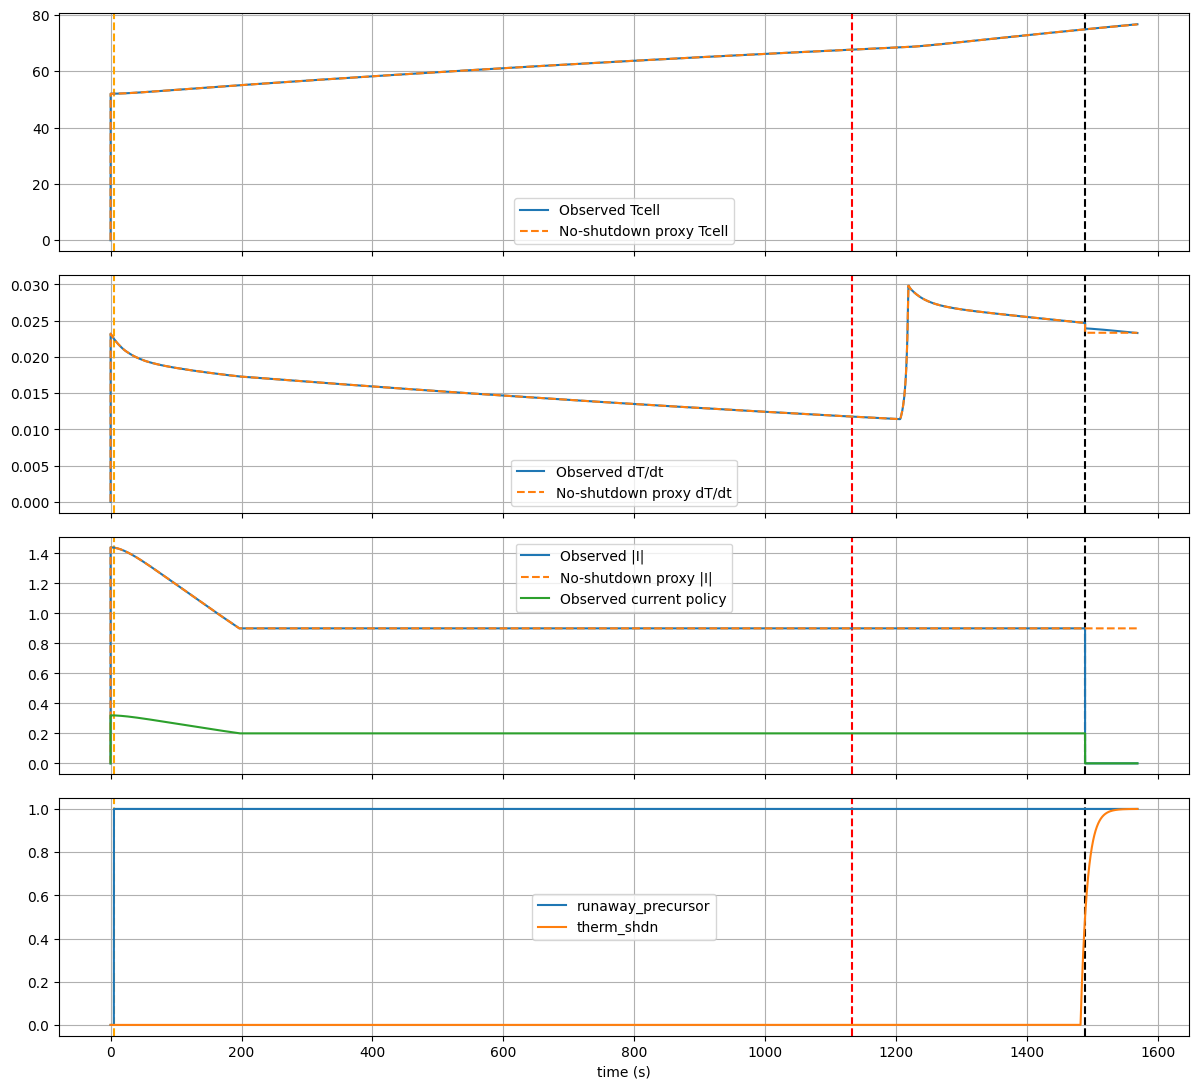

,case,warning_window_s,intervention_window_s,total_safety_window_s,derate_phase_I_mean,derate_phase_dTdt_mean,derate_phase_T_slope,J_post_I_obs,J_post_I_proxy,post_shutdown_current_avoided_percent,J_post_I2_obs,J_post_I2_proxy,post_shutdown_I2_stress_avoided_percent,J_post_Texc_obs,J_post_Texc_proxy,post_shutdown_temperature_excess_avoided_percent,J_post_growth_obs,J_post_growth_proxy,post_shutdown_growth_avoided_percent,shutdown_current_drop_percent
0,case3_runaway_prevention,1126.810311,356.519764,1483.330076,0.900016,0.023323,0.021725,0.00088,44.903069,99.99804,7.657439e-07,40.413503,99.999998,28.360871,27.038212,-4.891811,1.185415,1.163611,-1.873864,94.878511


In [156]:
case3_name = "case3_runaway_prevention"

t_prec3 = event_time(case3_name, "runaway_prec")
t_der3 = event_time(case3_name, "chg_limit")
if pd.isna(t_der3):
    t_der3 = event_time(case3_name, "sys_derate")
t_shdn3 = event_time(case3_name, "therm_shdn")
if pd.isna(t_shdn3):
    t_shdn3 = event_time(case3_name, "final_shdn")

z3 = crop(df3, max(0, t_prec3 - 50), t_shdn3 + 80)
tz3 = get_time(z3)

I3 = get_sig(z3, ["rshunt"], absval=True)
T3 = get_sig(z3, ["tcell_abs"])
DT3 = get_sig(z3, ["dtdt_f"])
P3 = get_sig(z3, ["runaway_precursor"])
U3 = get_sig(z3, ["icmd_scale_final"])
S3 = get_sig(z3, ["therm_shdn_f", "therm_shdn"])

seg_der = crop(df3, t_der3, t_shdn3)
seg_post = crop(df3, t_shdn3, t_shdn3 + 50)

t_seg_der = get_time(seg_der)
I_seg_der = get_sig(seg_der, ["rshunt"], absval=True)
T_seg_der = get_sig(seg_der, ["tcell_abs"])
DT_seg_der = get_sig(seg_der, ["dtdt_f"])

t_post3 = get_time(seg_post)
I_post3 = get_sig(seg_post, ["rshunt"], absval=True)
T_post3 = get_sig(seg_post, ["tcell_abs"])
DT_post3 = get_sig(seg_post, ["dtdt_f"])

I_der_mean = I_seg_der.mean()
DT_der_mean = DT_seg_der.mean()
T_der_slope = linear_slope(t_seg_der, T_seg_der)

# no-shutdown proxy over post-shutdown window
I_no_shutdown_proxy = pd.Series(np.full(len(t_post3), I_der_mean), index=t_post3.index)
DT_no_shutdown_proxy = pd.Series(np.full(len(t_post3), DT_der_mean), index=t_post3.index)

T_shdn_val = T_post3.iloc[0]
T_no_shutdown_proxy = pd.Series(
    T_shdn_val + T_der_slope * (t_post3 - float(t_post3.iloc[0])),
    index=t_post3.index
)

# hazard integrals
J_post_I_obs = area_under_curve(t_post3, I_post3)
J_post_I_proxy = area_under_curve(t_post3, I_no_shutdown_proxy)

J_post_I2_obs = area_under_curve(t_post3, I_post3**2)
J_post_I2_proxy = area_under_curve(t_post3, I_no_shutdown_proxy**2)

# choose shutdown temperature as local reference threshold
J_post_Texc_obs = excess_integral(t_post3, T_post3, T_shdn_val)
J_post_Texc_proxy = excess_integral(t_post3, T_no_shutdown_proxy, T_shdn_val)

J_post_growth_obs = area_under_curve(t_post3, DT_post3)
J_post_growth_proxy = area_under_curve(t_post3, DT_no_shutdown_proxy)

# plot full sequence with proxy over post-shutdown window
I_proxy_full = I3.copy()
DT_proxy_full = DT3.copy()
T_proxy_full = T3.copy()

m_post_full = tz3 >= t_shdn3
I_proxy_full.loc[m_post_full] = I_der_mean
DT_proxy_full.loc[m_post_full] = DT_der_mean
T_proxy_full.loc[m_post_full] = T_shdn_val + T_der_slope * (tz3.loc[m_post_full] - t_shdn3)

fig, ax = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

for a in ax:
    a.axvline(t_prec3, linestyle="--", color="orange")
    a.axvline(t_der3, linestyle="--", color="red")
    a.axvline(t_shdn3, linestyle="--", color="black")
    a.grid(True)

ax[0].plot(tz3, T3, label="Observed Tcell")
ax[0].plot(tz3, T_proxy_full, linestyle="--", label="No-shutdown proxy Tcell")
ax[0].legend()

ax[1].plot(tz3, DT3, label="Observed dT/dt")
ax[1].plot(tz3, DT_proxy_full, linestyle="--", label="No-shutdown proxy dT/dt")
ax[1].legend()

ax[2].plot(tz3, I3, label="Observed |I|")
ax[2].plot(tz3, I_proxy_full, linestyle="--", label="No-shutdown proxy |I|")
if U3 is not None:
    ax[2].plot(tz3, U3, label="Observed current policy")
ax[2].legend()

if P3 is not None:
    ax[3].plot(tz3, P3, label="runaway_precursor")
if S3 is not None:
    ax[3].plot(tz3, S3, label="therm_shdn")
ax[3].legend()
ax[3].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

case3_hazard_df = pd.DataFrame([{
    "case": case3_name,
    "warning_window_s": t_der3 - t_prec3,
    "intervention_window_s": t_shdn3 - t_der3,
    "total_safety_window_s": t_shdn3 - t_prec3,
    "derate_phase_I_mean": I_der_mean,
    "derate_phase_dTdt_mean": DT_der_mean,
    "derate_phase_T_slope": T_der_slope,
    "J_post_I_obs": J_post_I_obs,
    "J_post_I_proxy": J_post_I_proxy,
    "post_shutdown_current_avoided_percent": pct_reduction(J_post_I_proxy, J_post_I_obs),
    "J_post_I2_obs": J_post_I2_obs,
    "J_post_I2_proxy": J_post_I2_proxy,
    "post_shutdown_I2_stress_avoided_percent": pct_reduction(J_post_I2_proxy, J_post_I2_obs),
    "J_post_Texc_obs": J_post_Texc_obs,
    "J_post_Texc_proxy": J_post_Texc_proxy,
    "post_shutdown_temperature_excess_avoided_percent": pct_reduction(J_post_Texc_proxy, J_post_Texc_obs),
    "J_post_growth_obs": J_post_growth_obs,
    "J_post_growth_proxy": J_post_growth_proxy,
    "post_shutdown_growth_avoided_percent": pct_reduction(J_post_growth_proxy, J_post_growth_obs),
    "shutdown_current_drop_percent": pct_reduction(c3["current_before_shutdown"], c3["current_after_shutdown"])
}])

case3_hazard_df

In [157]:
t4 = get_time(df4); t5 = get_time(df5)
r4 = get_sig(df4, ["r0eff"]); r5 = get_sig(df5, ["r0eff"])
h4 = get_sig(df4, ["health_score"]); h5 = get_sig(df5, ["health_score"])
a4 = get_sig(df4, ["age_stress"]); a5 = get_sig(df5, ["age_stress"])
u4 = get_sig(df4, ["icmd_scale_final"]); u5 = get_sig(df5, ["icmd_scale_final"])

policy_df = pd.concat([
    pd.DataFrame({
        "case": "case4_aging_warning",
        "time": t4,
        "r0eff": r4,
        "health": h4,
        "age_stress": a4,
        "u": u4
    }),
    pd.DataFrame({
        "case": "case5_severe_aging",
        "time": t5,
        "r0eff": r5,
        "health": h5,
        "age_stress": a5,
        "u": u5
    })
], ignore_index=True)

# normalized versions for interpretable coefficients
policy_df["r0_n"] = normalize_series(policy_df["r0eff"])
policy_df["health_n"] = normalize_series(policy_df["health"])
policy_df["age_stress_n"] = normalize_series(policy_df["age_stress"])
policy_df["u_n"] = normalize_series(policy_df["u"])

policy_df.head()

,case,time,r0eff,health,age_stress,u,r0_n,health_n,age_stress_n,u_n
0,case4_aging_warning,0.000000e+00,0.0000,0.0000,0.000,0.0,0.00000,0.0,0.000000,0.0
1,case4_aging_warning,1.000000e-11,0.0867,0.8932,0.267,0.7,0.56452,1.0,0.285312,1.0
2,case4_aging_warning,1.007802e-11,0.0867,0.8932,0.267,0.7,0.56452,1.0,0.285312,1.0
3,case4_aging_warning,1.023407e-11,0.0867,0.8932,0.267,0.7,0.56452,1.0,0.285312,1.0
4,case4_aging_warning,1.054615e-11,0.0867,0.8932,0.267,0.7,0.56452,1.0,0.285312,1.0


In [158]:
# candidate models
models = {}

# M1: u ~ health
res1 = fit_linear_model(
    X=policy_df[["health_n"]].values,
    y=policy_df["u_n"].values,
    feature_names=["health_n"]
)
models["M1_health_only"] = res1

# M2: u ~ r0
res2 = fit_linear_model(
    X=policy_df[["r0_n"]].values,
    y=policy_df["u_n"].values,
    feature_names=["r0_n"]
)
models["M2_r0_only"] = res2

# M3: u ~ health + r0
res3 = fit_linear_model(
    X=policy_df[["health_n", "r0_n"]].values,
    y=policy_df["u_n"].values,
    feature_names=["health_n", "r0_n"]
)
models["M3_health_r0"] = res3

# M4: u ~ health + r0 + age_stress
res4 = fit_linear_model(
    X=policy_df[["health_n", "r0_n", "age_stress_n"]].values,
    y=policy_df["u_n"].values,
    feature_names=["health_n", "r0_n", "age_stress_n"]
)
models["M4_health_r0_age"] = res4

policy_model_df = pd.DataFrame([
    {
        "model": name,
        "n": res["n"],
        "r2": res["r2"],
        "rmse": res["rmse"],
        **res["coef_dict"]
    }
    for name, res in models.items()
]).sort_values(["r2", "rmse"], ascending=[False, True]).reset_index(drop=True)

policy_model_df

,model,n,r2,rmse,intercept,health_n,r0_n,age_stress_n
0,M4_health_r0_age,17459,0.995245,0.018314,4.120502e-08,437.467090,-1250.313786,944.238552
1,M3_health_r0,17459,0.995245,0.018315,1.752147e-07,1.384392,-0.606346,NaN
2,M1_health_only,17459,0.992825,0.022498,-1.217520e+00,2.258014,NaN,NaN
3,M2_r0_only,17459,0.989265,0.027518,1.915771e+00,NaN,-1.551802,NaN


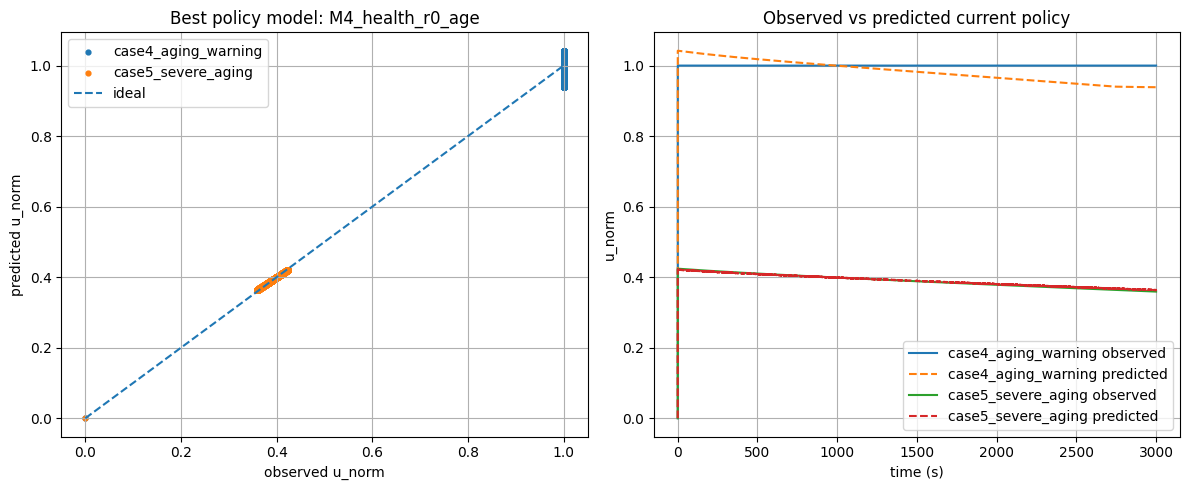

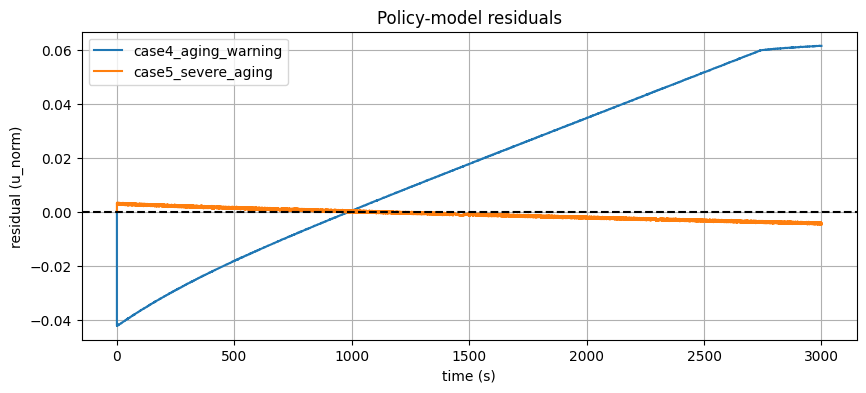

,best_model,best_r2,best_rmse,intercept,health_n,r0_n,age_stress_n
0,M4_health_r0_age,0.995245,0.018314,4.120502e-08,437.46709,-1250.313786,944.238552


In [159]:
best_model_name = policy_model_df.iloc[0]["model"]
best_res = models[best_model_name]

# rebuild best-model prediction on full dataset in same order
if best_model_name == "M1_health_only":
    Xbest = policy_df[["health_n"]].values
    fcols = ["health_n"]
elif best_model_name == "M2_r0_only":
    Xbest = policy_df[["r0_n"]].values
    fcols = ["r0_n"]
elif best_model_name == "M3_health_r0":
    Xbest = policy_df[["health_n", "r0_n"]].values
    fcols = ["health_n", "r0_n"]
else:
    Xbest = policy_df[["health_n", "r0_n", "age_stress_n"]].values
    fcols = ["health_n", "r0_n", "age_stress_n"]

fit_best = fit_linear_model(Xbest, policy_df["u_n"].values, fcols)
policy_df["u_pred_n"] = fit_best["yhat"]
policy_df["resid_n"] = fit_best["resid"]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for case_name, sub in policy_df.groupby("case"):
    plt.scatter(sub["u_n"], sub["u_pred_n"], s=12, label=case_name)
grid = np.linspace(0,1,100)
plt.plot(grid, grid, linestyle="--", label="ideal")
plt.xlabel("observed u_norm")
plt.ylabel("predicted u_norm")
plt.title(f"Best policy model: {best_model_name}")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
for case_name, sub in policy_df.groupby("case"):
    plt.plot(sub["time"], sub["u_n"], label=f"{case_name} observed")
    plt.plot(sub["time"], sub["u_pred_n"], linestyle="--", label=f"{case_name} predicted")
plt.xlabel("time (s)")
plt.ylabel("u_norm")
plt.title("Observed vs predicted current policy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
for case_name, sub in policy_df.groupby("case"):
    plt.plot(sub["time"], sub["resid_n"], label=case_name)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("time (s)")
plt.ylabel("residual (u_norm)")
plt.title("Policy-model residuals")
plt.grid(True)
plt.legend()
plt.show()

policy_best_df = pd.DataFrame([{
    "best_model": best_model_name,
    "best_r2": fit_best["r2"],
    "best_rmse": fit_best["rmse"],
    **fit_best["coef_dict"]
}])

policy_best_df

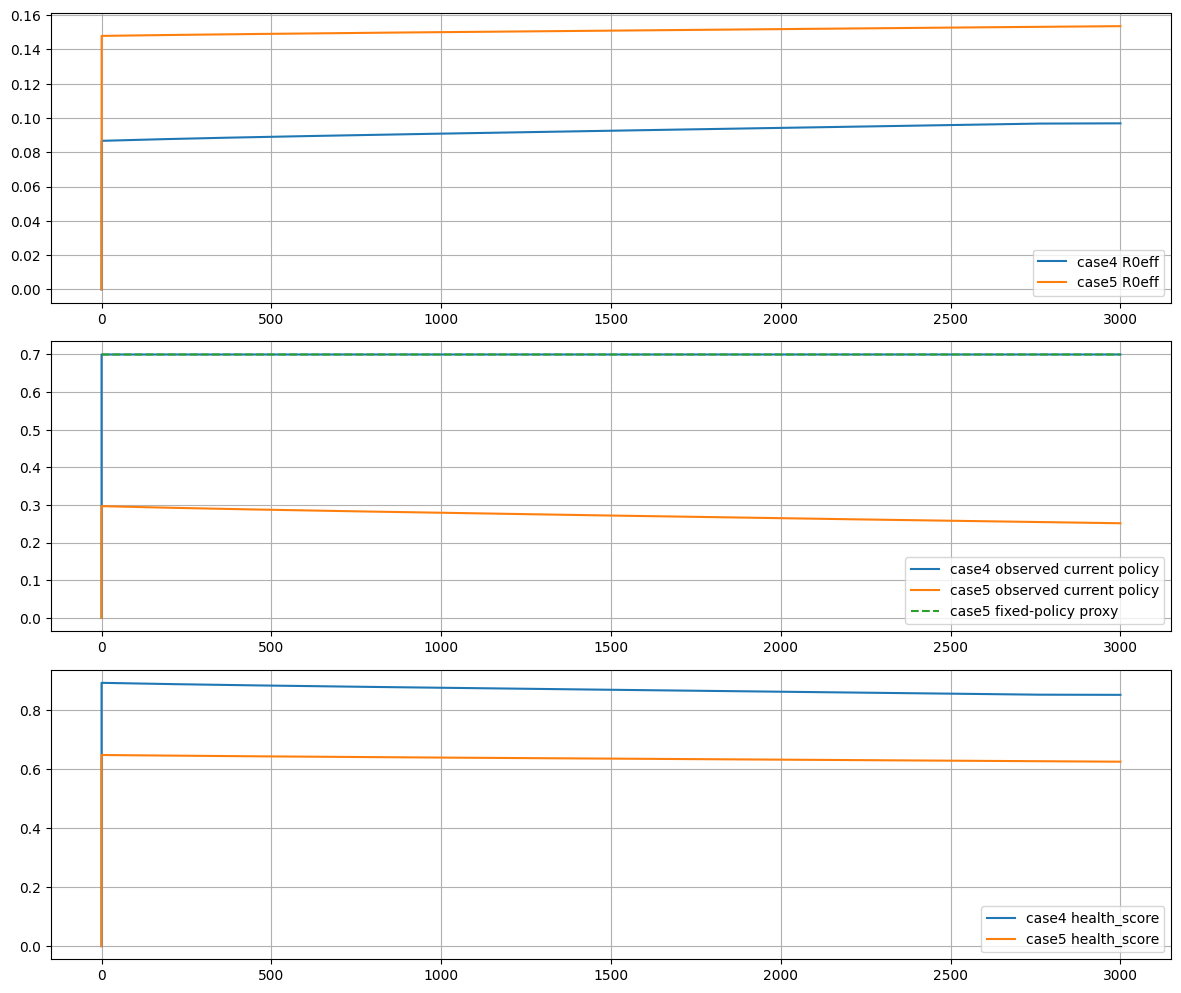

,case4_r0eff_avg,case5_r0eff_avg,delta_r0eff,case4_health_min,case5_health_min,delta_health,case4_icmd_scale_min,case5_icmd_scale_min,fixed_policy_proxy_for_case5,allowed_current_reduction_warning_to_severe_percent,nonadaptive_policy_overallowance_percent,spearman_health_vs_current,spearman_r0_vs_current
0,0.091021,0.150708,0.059688,0.852417,0.625673,0.226744,0.7,0.251346,0.7,64.093429,178.500553,0.991766,-0.991028


In [160]:
fixed_policy_proxy = c4["icmd_scale_min"]  # what severe-aging would get if treated like warning-aging

policy_proxy_df = pd.DataFrame([{
    "case4_r0eff_avg": c4["r0eff_avg"],
    "case5_r0eff_avg": c5["r0eff_avg"],
    "delta_r0eff": c5["r0eff_avg"] - c4["r0eff_avg"],
    "case4_health_min": c4["health_score_min"],
    "case5_health_min": c5["health_score_min"],
    "delta_health": c4["health_score_min"] - c5["health_score_min"],
    "case4_icmd_scale_min": c4["icmd_scale_min"],
    "case5_icmd_scale_min": c5["icmd_scale_min"],
    "fixed_policy_proxy_for_case5": fixed_policy_proxy,
    "allowed_current_reduction_warning_to_severe_percent": pct_reduction(c4["icmd_scale_min"], c5["icmd_scale_min"]),
    "nonadaptive_policy_overallowance_percent": 100 * (fixed_policy_proxy - c5["icmd_scale_min"]) / c5["icmd_scale_min"],
    "spearman_health_vs_current": pd.Series(policy_df["health"]).corr(pd.Series(policy_df["u"]), method="spearman"),
    "spearman_r0_vs_current": pd.Series(policy_df["r0eff"]).corr(pd.Series(policy_df["u"]), method="spearman")
}])

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(t4, r4, label="case4 R0eff")
ax[0].plot(t5, r5, label="case5 R0eff")
ax[0].legend(); ax[0].grid(True)

ax[1].plot(t4, u4, label="case4 observed current policy")
ax[1].plot(t5, u5, label="case5 observed current policy")
ax[1].plot(t5, np.full(len(t5), fixed_policy_proxy), linestyle="--", label="case5 fixed-policy proxy")
ax[1].legend(); ax[1].grid(True)

ax[2].plot(t4, h4, label="case4 health_score")
ax[2].plot(t5, h5, label="case5 health_score")
ax[2].legend(); ax[2].grid(True)

plt.tight_layout()
plt.show()

policy_proxy_df

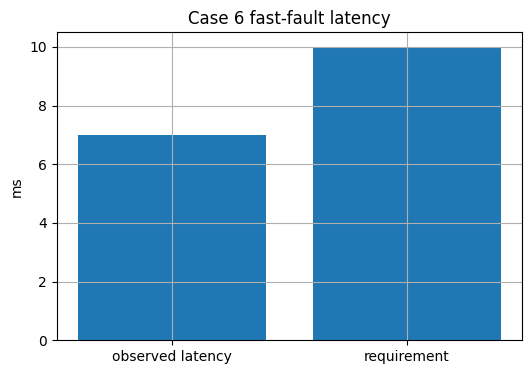

,case,t_fast_fault_s,t_fast_shdn_s,t_sys_fault_s,fault_to_shutdown_ms,requirement_ms,margin_ms,pass_requirement
0,case6_fast_fault,0.005139,0.012141,0.012141,7.001743,10.0,2.998257,True


In [161]:
case6_name = "case6_fast_fault"

t_fault6 = event_time(case6_name, "fast_fault")
t_shdn6 = event_time(case6_name, "fast_shdn")
t_sys6 = event_time(case6_name, "sys_fault")

lat_ms = (t_shdn6 - t_fault6) * 1000 if pd.notna(t_fault6) and pd.notna(t_shdn6) else np.nan
fast_path_requirement_ms = 10.0

case6_final_df = pd.DataFrame([{
    "case": case6_name,
    "t_fast_fault_s": t_fault6,
    "t_fast_shdn_s": t_shdn6,
    "t_sys_fault_s": t_sys6,
    "fault_to_shutdown_ms": lat_ms,
    "requirement_ms": fast_path_requirement_ms,
    "margin_ms": fast_path_requirement_ms - lat_ms if pd.notna(lat_ms) else np.nan,
    "pass_requirement": bool(lat_ms < fast_path_requirement_ms) if pd.notna(lat_ms) else False
}])

plt.figure(figsize=(6,4))
plt.bar(["observed latency", "requirement"], [lat_ms, fast_path_requirement_ms])
plt.ylabel("ms")
plt.title("Case 6 fast-fault latency")
plt.grid(True)
plt.show()

case6_final_df

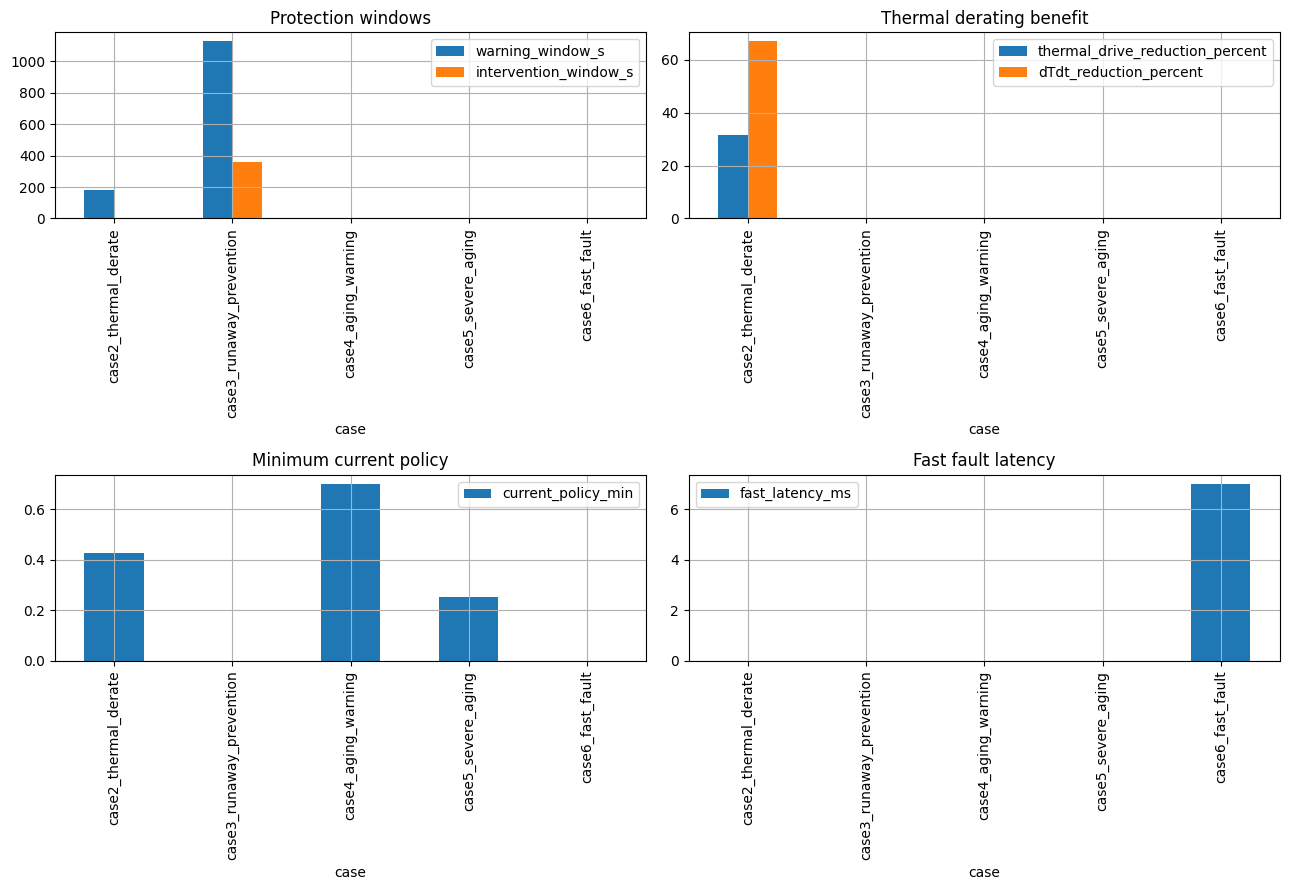

,case,warning_window_s,intervention_window_s,current_policy_min,thermal_drive_reduction_percent,dTdt_reduction_percent,hazard_exposure_reduction_percent,fast_latency_ms
0,case2_thermal_derate,179.142822,NaN,0.425560,31.751246,67.068437,19.589277,NaN
1,case3_runaway_prevention,1126.810311,356.519764,0.000000,NaN,NaN,99.999998,NaN
2,case4_aging_warning,NaN,NaN,0.700000,NaN,NaN,NaN,NaN
3,case5_severe_aging,NaN,NaN,0.251346,NaN,NaN,178.500553,NaN
4,case6_fast_fault,NaN,NaN,NaN,NaN,NaN,NaN,7.001743


In [162]:
final_dashboard_df = pd.DataFrame([
    {
        "case": "case2_thermal_derate",
        "warning_window_s": event_time("case2_thermal_derate", "sys_derate") - event_time("case2_thermal_derate", "runaway_prec")
            if pd.notna(event_time("case2_thermal_derate", "sys_derate")) and pd.notna(event_time("case2_thermal_derate", "runaway_prec"))
            else c2.get("delay_warn_to_derate", np.nan),
        "intervention_window_s": np.nan,
        "current_policy_min": c2["icmd_scale_min"],
        "thermal_drive_reduction_percent": case2_hazard_df["I2_reduction_percent"].iloc[0],
        "dTdt_reduction_percent": case2_hazard_df["dTdt_reduction_percent"].iloc[0],
        "hazard_exposure_reduction_percent": case2_hazard_df["T45_exposure_reduction_percent_vs_proxy"].iloc[0],
        "fast_latency_ms": np.nan
    },
    {
        "case": "case3_runaway_prevention",
        "warning_window_s": case3_hazard_df["warning_window_s"].iloc[0],
        "intervention_window_s": case3_hazard_df["intervention_window_s"].iloc[0],
        "current_policy_min": c3["icmd_scale_min"],
        "thermal_drive_reduction_percent": np.nan,
        "dTdt_reduction_percent": np.nan,
        "hazard_exposure_reduction_percent": case3_hazard_df["post_shutdown_I2_stress_avoided_percent"].iloc[0],
        "fast_latency_ms": np.nan
    },
    {
        "case": "case4_aging_warning",
        "warning_window_s": np.nan,
        "intervention_window_s": np.nan,
        "current_policy_min": c4["icmd_scale_min"],
        "thermal_drive_reduction_percent": np.nan,
        "dTdt_reduction_percent": np.nan,
        "hazard_exposure_reduction_percent": np.nan,
        "fast_latency_ms": np.nan
    },
    {
        "case": "case5_severe_aging",
        "warning_window_s": np.nan,
        "intervention_window_s": np.nan,
        "current_policy_min": c5["icmd_scale_min"],
        "thermal_drive_reduction_percent": np.nan,
        "dTdt_reduction_percent": np.nan,
        "hazard_exposure_reduction_percent": policy_proxy_df["nonadaptive_policy_overallowance_percent"].iloc[0],
        "fast_latency_ms": np.nan
    },
    {
        "case": "case6_fast_fault",
        "warning_window_s": np.nan,
        "intervention_window_s": np.nan,
        "current_policy_min": np.nan,
        "thermal_drive_reduction_percent": np.nan,
        "dTdt_reduction_percent": np.nan,
        "hazard_exposure_reduction_percent": np.nan,
        "fast_latency_ms": case6_final_df["fault_to_shutdown_ms"].iloc[0]
    }
])

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

final_dashboard_df.plot(x="case", y=["warning_window_s", "intervention_window_s"], kind="bar", ax=ax[0,0], title="Protection windows")
final_dashboard_df.plot(x="case", y=["thermal_drive_reduction_percent", "dTdt_reduction_percent"], kind="bar", ax=ax[0,1], title="Thermal derating benefit")
final_dashboard_df.plot(x="case", y=["current_policy_min"], kind="bar", ax=ax[1,0], title="Minimum current policy")
final_dashboard_df.plot(x="case", y=["fast_latency_ms"], kind="bar", ax=ax[1,1], title="Fast fault latency")

for a in ax.ravel():
    a.grid(True)

plt.tight_layout()
plt.show()

final_dashboard_df

In [163]:
import os
import matplotlib.pyplot as plt

save_dir = "/kaggle/working/protection_saved_plots"
os.makedirs(save_dir, exist_ok=True)

fig_nums = plt.get_fignums()
saved_files = []

for i, fig_num in enumerate(fig_nums, start=1):
    fig = plt.figure(fig_num)
    out_path = os.path.join(save_dir, f"plot_{i:02d}.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    saved_files.append(out_path)

print("Saved plots:")
for f in saved_files:
    print(f)

Saved plots:


In [164]:
import os
save_dir = "/kaggle/working/protection_saved_plots"
os.makedirs(save_dir, exist_ok=True)

plt.gcf().savefig(
    os.path.join(save_dir, "case2_observed_vs_no_derate_proxy.png"),
    dpi=300,
    bbox_inches="tight"
)
print("saved")

saved


<Figure size 640x480 with 0 Axes>

In [165]:
plt.gcf().savefig(
    os.path.join(save_dir, "case2_I2_vs_dTdt_scatter.png"),
    dpi=300,
    bbox_inches="tight"
)
print("saved")

saved


<Figure size 640x480 with 0 Axes>

In [166]:
plt.gcf().savefig(
    os.path.join(save_dir, "case3_observed_vs_no_shutdown_proxy.png"),
    dpi=300,
    bbox_inches="tight"
)
print("saved")

saved


<Figure size 640x480 with 0 Axes>

In [167]:
plt.gcf().savefig(
    os.path.join(save_dir, "case45_aging_policy_vs_fixed_policy_proxy.png"),
    dpi=300,
    bbox_inches="tight"
)
print("saved")

saved


<Figure size 640x480 with 0 Axes>

In [168]:
plt.gcf().savefig(
    os.path.join(save_dir, "case6_fast_fault_latency_vs_requirement.png"),
    dpi=300,
    bbox_inches="tight"
)
print("saved")

saved


<Figure size 640x480 with 0 Axes>

In [169]:
case2_hazard_df.to_csv("/kaggle/working/case2_hazard_df.csv", index=False)
case3_hazard_df.to_csv("/kaggle/working/case3_hazard_df.csv", index=False)
policy_model_df.to_csv("/kaggle/working/policy_model_df.csv", index=False)
policy_best_df.to_csv("/kaggle/working/policy_best_df.csv", index=False)
policy_proxy_df.to_csv("/kaggle/working/policy_proxy_df.csv", index=False)
case6_final_df.to_csv("/kaggle/working/case6_final_df.csv", index=False)
final_dashboard_df.to_csv("/kaggle/working/final_dashboard_df.csv", index=False)

print("all csv files saved")

all csv files saved


In [170]:
import shutil
import os

zip_base = "/kaggle/working/protection_results_bundle"
folder_to_zip = "/kaggle/working/protection_saved_plots"

shutil.make_archive(zip_base, "zip", folder_to_zip)
print("zip saved at:", zip_base + ".zip")

zip saved at: /kaggle/working/protection_results_bundle.zip


In [171]:
import os
import zipfile
import pandas as pd

save_dir = "/kaggle/working/protection_final_outputs"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------------------
# Put here every dataframe you want to save
# -----------------------------------------
tables_to_save = {
    "case2_hazard_df": case2_hazard_df,
    "case3_hazard_df": case3_hazard_df,
    "policy_model_df": policy_model_df,
    "policy_best_df": policy_best_df,
    "policy_proxy_df": policy_proxy_df,
    "case6_final_df": case6_final_df,
    "final_dashboard_df": final_dashboard_df,
}

# Optional: include older tables too if they exist
optional_names = [
    "thermal_metrics_df",
    "runaway_segments_df",
    "aging_quant_df",
    "fast_quant_df",
    "case2_compare_df",
    "aging_compare_df",
    "timing_compare_df",
    "cross_compare_df",
    "case2_ablation_df",
    "case3_ablation_df",
    "case45_ablation_df",
]

for name in optional_names:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        tables_to_save[name] = globals()[name]

# -----------------------------------------
# Save each dataframe as CSV
# -----------------------------------------
csv_paths = []
for name, df in tables_to_save.items():
    out_csv = os.path.join(save_dir, f"{name}.csv")
    df.to_csv(out_csv, index=False)
    csv_paths.append(out_csv)

# -----------------------------------------
# Save everything into one Excel workbook
# -----------------------------------------
excel_path = os.path.join(save_dir, "protection_all_tables.xlsx")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for name, df in tables_to_save.items():
        sheet = name[:31]  # Excel sheet-name limit
        df.to_excel(writer, sheet_name=sheet, index=False)

# -----------------------------------------
# Make one summary sheet manually
# -----------------------------------------
summary_table = pd.DataFrame([
    {
        "result_block": "case2_thermal_derate",
        "key_metric_1": "I2_reduction_percent",
        "value_1": case2_hazard_df["I2_reduction_percent"].iloc[0] if "case2_hazard_df" in tables_to_save else None,
        "key_metric_2": "dTdt_reduction_percent",
        "value_2": case2_hazard_df["dTdt_reduction_percent"].iloc[0] if "case2_hazard_df" in tables_to_save else None,
    },
    {
        "result_block": "case3_runaway_prevention",
        "key_metric_1": "warning_window_s",
        "value_1": case3_hazard_df["warning_window_s"].iloc[0] if "case3_hazard_df" in tables_to_save else None,
        "key_metric_2": "intervention_window_s",
        "value_2": case3_hazard_df["intervention_window_s"].iloc[0] if "case3_hazard_df" in tables_to_save else None,
    },
    {
        "result_block": "aging_policy",
        "key_metric_1": "allowed_current_reduction_warning_to_severe_percent",
        "value_1": policy_proxy_df["allowed_current_reduction_warning_to_severe_percent"].iloc[0] if "policy_proxy_df" in tables_to_save else None,
        "key_metric_2": "spearman_health_vs_current",
        "value_2": policy_proxy_df["spearman_health_vs_current"].iloc[0] if "policy_proxy_df" in tables_to_save else None,
    },
    {
        "result_block": "case6_fast_fault",
        "key_metric_1": "fault_to_shutdown_ms",
        "value_1": case6_final_df["fault_to_shutdown_ms"].iloc[0] if "case6_final_df" in tables_to_save else None,
        "key_metric_2": "margin_ms",
        "value_2": case6_final_df["margin_ms"].iloc[0] if "case6_final_df" in tables_to_save else None,
    },
])

with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    summary_table.to_excel(writer, sheet_name="summary_key_results", index=False)

# -----------------------------------------
# Zip all CSV + Excel together
# -----------------------------------------
zip_path = os.path.join("/kaggle/working", "protection_final_outputs.zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in csv_paths:
        zf.write(f, arcname=os.path.basename(f))
    zf.write(excel_path, arcname=os.path.basename(excel_path))

print("Saved CSV files:")
for p in csv_paths:
    print(" -", p)

print("\nSaved Excel workbook:")
print(" -", excel_path)

print("\nSaved ZIP bundle:")
print(" -", zip_path)

Saved CSV files:
 - /kaggle/working/protection_final_outputs/case2_hazard_df.csv
 - /kaggle/working/protection_final_outputs/case3_hazard_df.csv
 - /kaggle/working/protection_final_outputs/policy_model_df.csv
 - /kaggle/working/protection_final_outputs/policy_best_df.csv
 - /kaggle/working/protection_final_outputs/policy_proxy_df.csv
 - /kaggle/working/protection_final_outputs/case6_final_df.csv
 - /kaggle/working/protection_final_outputs/final_dashboard_df.csv
 - /kaggle/working/protection_final_outputs/thermal_metrics_df.csv
 - /kaggle/working/protection_final_outputs/runaway_segments_df.csv
 - /kaggle/working/protection_final_outputs/aging_quant_df.csv
 - /kaggle/working/protection_final_outputs/fast_quant_df.csv
 - /kaggle/working/protection_final_outputs/case2_compare_df.csv
 - /kaggle/working/protection_final_outputs/aging_compare_df.csv
 - /kaggle/working/protection_final_outputs/timing_compare_df.csv
 - /kaggle/working/protection_final_outputs/cross_compare_df.csv
 - /kaggle/wo

In [172]:
comparison_tables = {
    "case2_counterfactual": case2_hazard_df,
    "case3_counterfactual": case3_hazard_df,
    "aging_policy_compare": policy_proxy_df,
    "aging_policy_models": policy_model_df,
    "aging_best_model": policy_best_df,
    "fast_fault_requirement": case6_final_df,
    "final_dashboard": final_dashboard_df,
}

comparison_excel = "/kaggle/working/protection_comparison_tables.xlsx"

with pd.ExcelWriter(comparison_excel, engine="openpyxl") as writer:
    for name, df in comparison_tables.items():
        df.to_excel(writer, sheet_name=name[:31], index=False)

print("saved:", comparison_excel)

saved: /kaggle/working/protection_comparison_tables.xlsx


In [173]:
from pathlib import Path
import pandas as pd
import numpy as np

INPUT_ROOT = Path("/kaggle/input")

target_files = [
    "calibration_bench.txt",
    "adc_current.txt",
    "adc_temp.txt",
    "adc_voltage_sar.txt",
]

def read_ltspice_txt(path):
    trials = [
        dict(sep="\t"),
        dict(sep=","),
        dict(sep=r"\s+"),
        dict(sep=None, engine="python"),
    ]
    for kw in trials:
        try:
            df = pd.read_csv(path, comment=";", **kw)
            if df.shape[1] >= 2:
                return df
        except Exception:
            pass
    raise ValueError(f"Could not parse {path}")

def find_file(name):
    matches = list(INPUT_ROOT.rglob(name))
    if not matches:
        raise FileNotFoundError(name)
    return matches[0]

loaded_blocks = {}
for fname in target_files:
    p = find_file(fname)
    df = read_ltspice_txt(p)
    loaded_blocks[fname] = {"path": p, "df": df}

for fname, obj in loaded_blocks.items():
    df = obj["df"]
    print("\n" + "="*80)
    print(fname)
    print("PATH:", obj["path"])
    print("SHAPE:", df.shape)
    print("COLUMNS:")
    for i, c in enumerate(df.columns):
        print(f"  {i:02d}: {c}")


calibration_bench.txt
PATH: /kaggle/input/datasets/chaahatsingal/ev-battery-project-data/calibration_bench.txt
SHAPE: (3452, 15)
COLUMNS:
  00: time
  01: V(cal_valid)
  02: V(cal_win)
  03: V(i_cal_corr)
  04: V(i_cal_hold)
  05: V(i_cal_out)
  06: V(i_uncal)
  07: V(meas_mode)
  08: V(ref_mode)
  09: V(v_cal_corr)
  10: V(v_cal_err_raw)
  11: V(v_cal_hold)
  12: V(v_cal_out)
  13: V(v_mux_in)
  14: V(v_uncal)

adc_current.txt
PATH: /kaggle/input/datasets/chaahatsingal/ev-battery-project-data/adc_current.txt
SHAPE: (3452, 17)
COLUMNS:
  00: time
  01: V(adc_valid)
  02: V(i_adc_code)
  03: V(i_adc_in)
  04: V(i_adc_out)
  05: V(i_adc_q)
  06: V(i_cal_out)
  07: V(i_samp_hold)
  08: V(i_uncal)
  09: V(iadc_d0)
  10: V(iadc_d1)
  11: V(iadc_d2)
  12: V(iadc_d3)
  13: V(iadc_d4)
  14: V(iadc_d5)
  15: V(iadc_d6)
  16: V(iadc_d7)

adc_temp.txt
PATH: /kaggle/input/datasets/chaahatsingal/ev-battery-project-data/adc_temp.txt
SHAPE: (3452, 15)
COLUMNS:
  00: time
  01: V(t_adc_code)
  02: V(

In [174]:
import matplotlib.pyplot as plt

def resolve_col(df, aliases):
    cols_lower = {str(c).lower(): c for c in df.columns}
    for a in aliases:
        if str(a).lower() in cols_lower:
            return cols_lower[str(a).lower()]
    for c in df.columns:
        cl = str(c).lower()
        for a in aliases:
            if str(a).lower() in cl:
                return c
    return None

def get_sig(df, aliases, absval=False):
    col = resolve_col(df, aliases)
    if col is None:
        return None
    s = pd.to_numeric(df[col], errors="coerce")
    return s.abs() if absval else s

def get_time(df):
    return get_sig(df, ["time"])

def rising_edges(t, x, thr=0.5):
    if t is None or x is None:
        return []
    xbin = (x > thr).astype(int)
    idx = np.where((xbin.shift(1, fill_value=0) == 0) & (xbin == 1))[0]
    return [float(t.iloc[i]) for i in idx]

def falling_edges(t, x, thr=0.5):
    if t is None or x is None:
        return []
    xbin = (x > thr).astype(int)
    idx = np.where((xbin.shift(1, fill_value=0) == 1) & (xbin == 0))[0]
    return [float(t.iloc[i]) for i in idx]

def rmse(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return float(np.sqrt(np.mean(np.square(x))))

def max_abs(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return float(np.max(np.abs(x)))

def first_settle_time(t, y, start_t, stop_t, tol_frac=0.01):
    if t is None or y is None:
        return np.nan
    m = (t >= start_t) & (t <= stop_t)
    tw = t[m]
    yw = y[m]
    if len(yw.dropna()) < 10:
        return np.nan
    tail = yw.iloc[max(0, int(0.9*len(yw))):]
    final_val = float(tail.median())
    tol = max(abs(final_val) * tol_frac, 1e-6)
    inside = np.abs(yw - final_val) <= tol
    idx = np.where(inside)[0]
    if len(idx) == 0:
        return np.nan
    return float(tw.iloc[idx[0]])

def crop_df(df, t0, t1):
    t = get_time(df)
    if t is None:
        return None
    return df.loc[(t >= t0) & (t <= t1)].copy()

Resolved signals:
time           -> FOUND
ref_mode       -> FOUND
meas_mode      -> FOUND
v_mux_in       -> FOUND
v_cal_out      -> FOUND
v_cal_hold     -> FOUND
v_cal_corr     -> FOUND
v_cal_err_raw  -> FOUND
vcal_valid     -> FOUND
ical_valid     -> MISSING
ref_cal_done   -> MISSING
curr_cal_done  -> MISSING


/tmp/ipykernel_55/1189119862.py:107: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[3].legend()


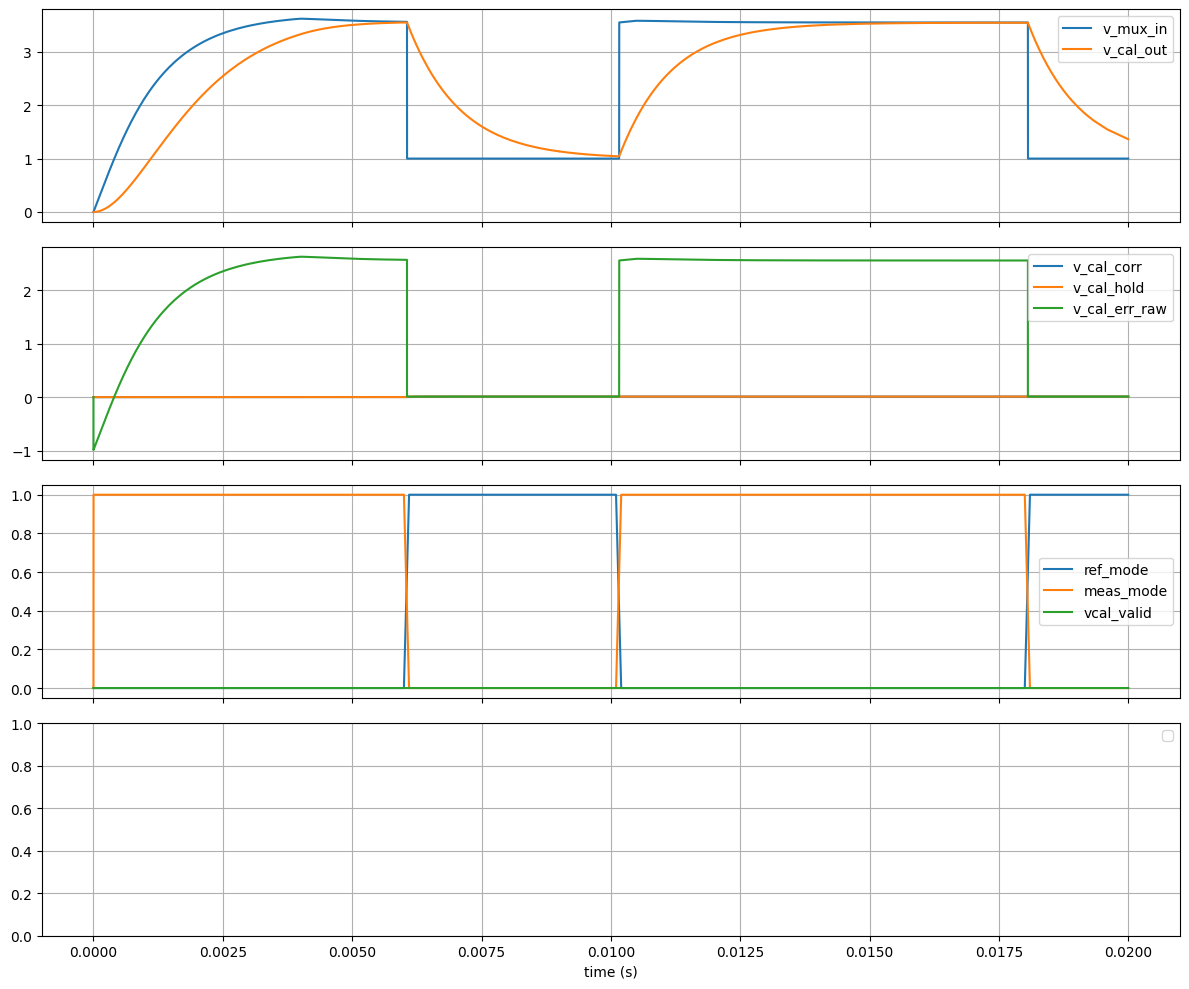

,ref_start_s,ref_stop_s,ref_window_s,first_vcal_valid_s,calibration_to_valid_s,correction_settle_s,tracking_rmse_meas_mode,tracking_maxabs_meas_mode,hold_drift_meas_mode,raw_err_rms,raw_err_maxabs
0,0.00605,0.01015,0.0041,NaN,NaN,0.00024,0.798958,2.506221,0.010162,1.957424,2.628911


In [175]:
cal_df = loaded_blocks["calibration_bench.txt"]["df"].copy()
t = get_time(cal_df)

ref_mode      = get_sig(cal_df, ["ref_mode"])
meas_mode     = get_sig(cal_df, ["meas_mode"])
v_mux_in      = get_sig(cal_df, ["v_mux_in"])
v_cal_out     = get_sig(cal_df, ["v_cal_out"])
v_cal_hold    = get_sig(cal_df, ["v_cal_hold"])
v_cal_corr    = get_sig(cal_df, ["v_cal_corr"])
v_cal_err_raw = get_sig(cal_df, ["v_cal_err_raw"])
vcal_valid    = get_sig(cal_df, ["vcal_valid", "cal_valid"])
ical_valid    = get_sig(cal_df, ["ical_valid"])
ref_cal_done  = get_sig(cal_df, ["ref_cal_done"])
curr_cal_done = get_sig(cal_df, ["curr_cal_done", "ical_done", "curr_done"])

print("Resolved signals:")
for name, sig in {
    "time": t,
    "ref_mode": ref_mode,
    "meas_mode": meas_mode,
    "v_mux_in": v_mux_in,
    "v_cal_out": v_cal_out,
    "v_cal_hold": v_cal_hold,
    "v_cal_corr": v_cal_corr,
    "v_cal_err_raw": v_cal_err_raw,
    "vcal_valid": vcal_valid,
    "ical_valid": ical_valid,
    "ref_cal_done": ref_cal_done,
    "curr_cal_done": curr_cal_done,
}.items():
    print(f"{name:14s} ->", "FOUND" if sig is not None else "MISSING")

ref_rise = rising_edges(t, ref_mode) if ref_mode is not None else []
ref_fall = falling_edges(t, ref_mode) if ref_mode is not None else []
valid_rise = rising_edges(t, vcal_valid) if vcal_valid is not None else []

ref_start = ref_rise[0] if len(ref_rise) else np.nan
ref_stop = ref_fall[0] if len(ref_fall) else np.nan
first_valid = valid_rise[0] if len(valid_rise) else np.nan

corr_sig = v_cal_hold if v_cal_hold is not None else v_cal_corr
settle_t = first_settle_time(t, corr_sig, ref_start, ref_stop, tol_frac=0.01) if corr_sig is not None else np.nan

meas_mask = None
if meas_mode is not None:
    meas_mask = (meas_mode > 0.5)
elif ref_mode is not None:
    meas_mask = ~(ref_mode > 0.5)

tracking_err = None
if (v_cal_out is not None) and (v_mux_in is not None) and (meas_mask is not None):
    tracking_err = (v_cal_out - v_mux_in)[meas_mask]

hold_drift = np.nan
if (v_cal_hold is not None) and (meas_mask is not None):
    vh = v_cal_hold[meas_mask].dropna()
    if len(vh):
        hold_drift = float(vh.max() - vh.min())

calibration_metrics_df = pd.DataFrame([{
    "ref_start_s": ref_start,
    "ref_stop_s": ref_stop,
    "ref_window_s": ref_stop - ref_start if pd.notna(ref_start) and pd.notna(ref_stop) else np.nan,
    "first_vcal_valid_s": first_valid,
    "calibration_to_valid_s": first_valid - ref_start if pd.notna(first_valid) and pd.notna(ref_start) else np.nan,
    "correction_settle_s": settle_t - ref_start if pd.notna(settle_t) and pd.notna(ref_start) else np.nan,
    "tracking_rmse_meas_mode": rmse(tracking_err) if tracking_err is not None else np.nan,
    "tracking_maxabs_meas_mode": max_abs(tracking_err) if tracking_err is not None else np.nan,
    "hold_drift_meas_mode": hold_drift,
    "raw_err_rms": rmse(v_cal_err_raw) if v_cal_err_raw is not None else np.nan,
    "raw_err_maxabs": max_abs(v_cal_err_raw) if v_cal_err_raw is not None else np.nan,
}])

fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

if v_mux_in is not None:
    ax[0].plot(t, v_mux_in, label="v_mux_in")
if v_cal_out is not None:
    ax[0].plot(t, v_cal_out, label="v_cal_out")
ax[0].legend()
ax[0].grid(True)

if v_cal_corr is not None:
    ax[1].plot(t, v_cal_corr, label="v_cal_corr")
if v_cal_hold is not None:
    ax[1].plot(t, v_cal_hold, label="v_cal_hold")
if v_cal_err_raw is not None:
    ax[1].plot(t, v_cal_err_raw, label="v_cal_err_raw")
ax[1].legend()
ax[1].grid(True)

if ref_mode is not None:
    ax[2].plot(t, ref_mode, label="ref_mode")
if meas_mode is not None:
    ax[2].plot(t, meas_mode, label="meas_mode")
if vcal_valid is not None:
    ax[2].plot(t, vcal_valid, label="vcal_valid")
if ical_valid is not None:
    ax[2].plot(t, ical_valid, label="ical_valid")
ax[2].legend()
ax[2].grid(True)

if ref_cal_done is not None:
    ax[3].plot(t, ref_cal_done, label="ref_cal_done")
if curr_cal_done is not None:
    ax[3].plot(t, curr_cal_done, label="curr_cal_done")
ax[3].legend()
ax[3].grid(True)
ax[3].set_xlabel("time (s)")

plt.tight_layout()
plt.show()

calibration_metrics_df

In [176]:
for fname in ["adc_current.txt", "adc_temp.txt", "adc_voltage_sar.txt"]:
    df = loaded_blocks[fname]["df"].copy()
    print("\n" + "="*80)
    print(fname)
    t = get_time(df)
    print("time found:", t is not None)
    
    candidates = {
        "input": ["i_adc_in", "t_adc_in", "v_adc_in", "v_samp_hold", "i_samp_hold", "t_samp_hold"],
        "quantized_out": ["i_adc_out", "t_adc_out", "v_adc_out", "i_adc_q", "t_adc_q", "dac_out_sar"],
        "code": ["i_adc_code", "t_adc_code", "vsar_code_v"],
        "valid": ["adc_valid", "adc_valid_sar", "conv_clk"],
        "dac": ["dac_out_sar"],
    }
    
    for label, aliases in candidates.items():
        col = resolve_col(df, aliases)
        print(f"{label:14s} ->", col)


adc_current.txt
time found: True
input          -> V(i_adc_in)
quantized_out  -> V(i_adc_out)
code           -> V(i_adc_code)
valid          -> V(adc_valid)
dac            -> None

adc_temp.txt
time found: True
input          -> V(t_adc_in)
quantized_out  -> V(t_adc_out)
code           -> V(t_adc_code)
valid          -> None
dac            -> None

adc_voltage_sar.txt
time found: True
input          -> V(v_samp_hold)
quantized_out  -> V(dac_out_sar)
code           -> V(vsar_code_v)
valid          -> None
dac            -> V(dac_out_sar)


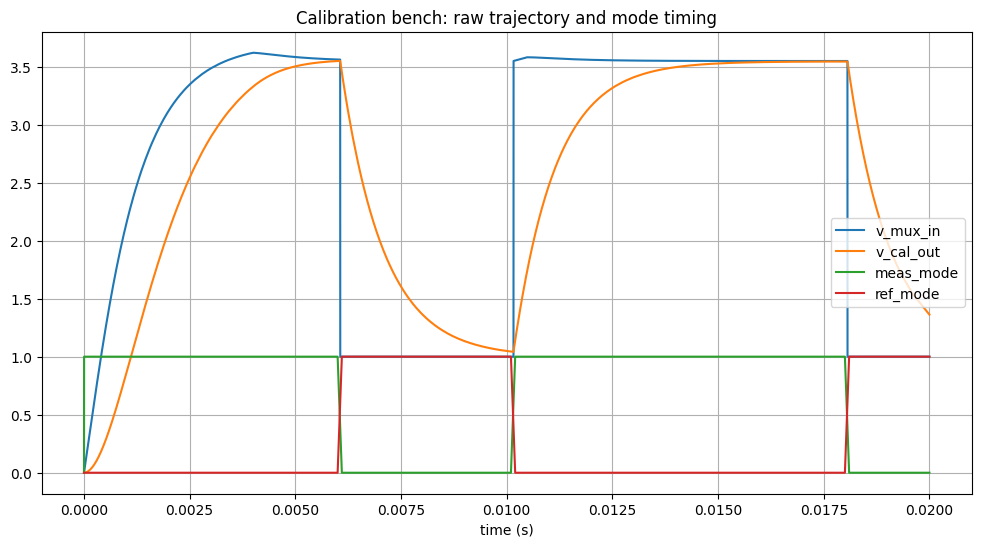

,num_ref_windows,num_meas_windows,raw_err_rms,raw_err_maxabs,settled_tracking_rmse,settled_tracking_maxabs,hold_drift_settled,vcal_valid_seen
0,2,2,1.957424,2.628911,0.418875,1.300518,0.010161,False


In [177]:
cal_df = loaded_blocks["calibration_bench.txt"]["df"].copy()
t = get_time(cal_df)

ref_mode      = get_sig(cal_df, ["ref_mode"])
meas_mode     = get_sig(cal_df, ["meas_mode"])
v_mux_in      = get_sig(cal_df, ["v_mux_in"])
v_cal_out     = get_sig(cal_df, ["v_cal_out"])
v_cal_hold    = get_sig(cal_df, ["v_cal_hold"])
v_cal_corr    = get_sig(cal_df, ["v_cal_corr"])
v_cal_err_raw = get_sig(cal_df, ["v_cal_err_raw"])
vcal_valid    = get_sig(cal_df, ["vcal_valid", "cal_valid"])

ref_rise = rising_edges(t, ref_mode) if ref_mode is not None else []
ref_fall = falling_edges(t, ref_mode) if ref_mode is not None else []

# measurement windows from meas_mode high
meas_rise = rising_edges(t, meas_mode) if meas_mode is not None else []
meas_fall = falling_edges(t, meas_mode) if meas_mode is not None else []

# pair measurement windows
meas_windows = []
for s in meas_rise:
    e = next((x for x in meas_fall if x > s), np.nan)
    meas_windows.append((s, e))

# settled-only error: ignore first 20% of each meas window
settled_err_list = []
hold_list = []

for s, e in meas_windows:
    if pd.isna(e):
        continue
    tw = (t >= s) & (t <= e)
    tloc = t[tw]
    if len(tloc) < 10 or v_mux_in is None or v_cal_out is None:
        continue

    start_settle = s + 0.2*(e - s)
    ms = (t >= start_settle) & (t <= e)

    err = (v_cal_out - v_mux_in)[ms].dropna()
    if len(err):
        settled_err_list.append(err)

    if v_cal_hold is not None:
        vh = v_cal_hold[ms].dropna()
        if len(vh):
            hold_list.append(vh)

settled_err = pd.concat(settled_err_list, ignore_index=True) if len(settled_err_list) else pd.Series(dtype=float)
hold_all = pd.concat(hold_list, ignore_index=True) if len(hold_list) else pd.Series(dtype=float)

calibration_refined_df = pd.DataFrame([{
    "num_ref_windows": len(ref_rise),
    "num_meas_windows": len(meas_windows),
    "raw_err_rms": rmse(v_cal_err_raw) if v_cal_err_raw is not None else np.nan,
    "raw_err_maxabs": max_abs(v_cal_err_raw) if v_cal_err_raw is not None else np.nan,
    "settled_tracking_rmse": rmse(settled_err) if len(settled_err) else np.nan,
    "settled_tracking_maxabs": max_abs(settled_err) if len(settled_err) else np.nan,
    "hold_drift_settled": float(hold_all.max() - hold_all.min()) if len(hold_all) else np.nan,
    "vcal_valid_seen": bool((vcal_valid > 0.5).any()) if vcal_valid is not None else False
}])

plt.figure(figsize=(12,6))
if v_mux_in is not None:
    plt.plot(t, v_mux_in, label="v_mux_in")
if v_cal_out is not None:
    plt.plot(t, v_cal_out, label="v_cal_out")
if meas_mode is not None:
    plt.plot(t, meas_mode, label="meas_mode")
if ref_mode is not None:
    plt.plot(t, ref_mode, label="ref_mode")
plt.grid(True)
plt.legend()
plt.title("Calibration bench: raw trajectory and mode timing")
plt.xlabel("time (s)")
plt.show()

calibration_refined_df

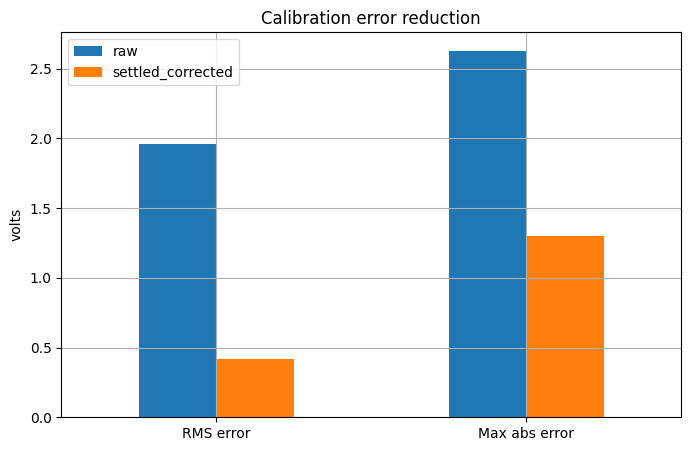

,raw_err_rms,settled_err_rms,raw_err_maxabs,settled_err_maxabs,rms_improvement_percent,maxabs_improvement_percent
0,1.957424,0.418875,2.628911,1.300518,78.600701,50.530162


In [178]:
raw_err = v_cal_err_raw.dropna() if v_cal_err_raw is not None else pd.Series(dtype=float)
settled_err = settled_err.dropna() if len(settled_err) else pd.Series(dtype=float)

cal_error_compare_df = pd.DataFrame([{
    "raw_err_rms": rmse(raw_err) if len(raw_err) else np.nan,
    "settled_err_rms": rmse(settled_err) if len(settled_err) else np.nan,
    "raw_err_maxabs": max_abs(raw_err) if len(raw_err) else np.nan,
    "settled_err_maxabs": max_abs(settled_err) if len(settled_err) else np.nan,
    "rms_improvement_percent": pct_reduction(rmse(raw_err), rmse(settled_err)) if len(raw_err) and len(settled_err) else np.nan,
    "maxabs_improvement_percent": pct_reduction(max_abs(raw_err), max_abs(settled_err)) if len(raw_err) and len(settled_err) else np.nan,
}])

bars = pd.DataFrame({
    "raw": [
        rmse(raw_err) if len(raw_err) else np.nan,
        max_abs(raw_err) if len(raw_err) else np.nan
    ],
    "settled_corrected": [
        rmse(settled_err) if len(settled_err) else np.nan,
        max_abs(settled_err) if len(settled_err) else np.nan
    ]
}, index=["RMS error", "Max abs error"])

ax = bars.plot(kind="bar", rot=0, figsize=(8,5), grid=True, title="Calibration error reduction")
ax.set_ylabel("volts")
plt.show()

cal_error_compare_df

In [179]:
def extract_gate_windows(t, gate, thr=0.5):
    if t is None or gate is None:
        return []
    rs = rising_edges(t, gate, thr=thr)
    fs = falling_edges(t, gate, thr=thr)
    windows = []
    for s in rs:
        e = next((x for x in fs if x > s), np.nan)
        windows.append((s, e))
    return windows

def extract_plateau_samples(df, input_aliases, output_aliases, code_aliases=None, gate_aliases=None, settle_frac=0.25):
    t = get_time(df)
    x = get_sig(df, input_aliases)
    y = get_sig(df, output_aliases)
    code = get_sig(df, code_aliases) if code_aliases is not None else None
    gate = get_sig(df, gate_aliases) if gate_aliases is not None else None

    rows = []

    # 1) gate-based extraction if valid signal exists
    if gate is not None:
        windows = extract_gate_windows(t, gate)
        for k, (s, e) in enumerate(windows, start=1):
            if pd.isna(e):
                continue
            start_settle = s + settle_frac*(e - s)
            m = (t >= start_settle) & (t <= e)
            if m.sum() < 3:
                continue
            rows.append({
                "sample_id": k,
                "t_start": s,
                "t_stop": e,
                "t_mid": float(t[m].median()),
                "input_val": float(x[m].median()) if x is not None else np.nan,
                "output_val": float(y[m].median()) if y is not None else np.nan,
                "code_val": float(code[m].median()) if code is not None else np.nan,
            })

    # 2) fallback: plateau extraction from code
    elif code is not None:
        cd = code.dropna().reset_index(drop=False)
        if len(cd) > 0:
            idx = cd["index"].to_numpy()
            vals = cd[code.name].to_numpy() if code.name in cd.columns else code.iloc[idx].to_numpy()
            change = np.r_[True, np.abs(np.diff(vals)) > 0.5]
            grp = np.cumsum(change)

            tmp = pd.DataFrame({"idx": idx, "code": vals, "grp": grp})
            for k, (_, sub) in enumerate(tmp.groupby("grp"), start=1):
                i0 = int(sub["idx"].iloc[0])
                i1 = int(sub["idx"].iloc[-1])
                if i1 - i0 < 3:
                    continue
                cut = i0 + int((i1 - i0)*settle_frac)
                m = np.arange(cut, i1+1)
                rows.append({
                    "sample_id": k,
                    "t_start": float(t.iloc[i0]),
                    "t_stop": float(t.iloc[i1]),
                    "t_mid": float(t.iloc[m].median()),
                    "input_val": float(x.iloc[m].median()) if x is not None else np.nan,
                    "output_val": float(y.iloc[m].median()) if y is not None else np.nan,
                    "code_val": float(code.iloc[m].median()) if code is not None else np.nan,
                })

    out = pd.DataFrame(rows)
    if len(out):
        out["error"] = out["output_val"] - out["input_val"]
        uniq = np.sort(out["output_val"].dropna().unique())
        lsb = np.median(np.diff(uniq)) if len(uniq) > 1 else np.nan
        out["error_lsb"] = out["error"] / lsb if pd.notna(lsb) and lsb != 0 else np.nan
    return out

def adc_metrics_from_samples(samples_df, name):
    if samples_df is None or len(samples_df) == 0:
        return pd.DataFrame([{"adc_name": name}])

    s = samples_df.sort_values("input_val").reset_index(drop=True)

    code_decreases = np.sum(np.diff(s["code_val"].fillna(method="ffill")) < -0.5) if "code_val" in s.columns else np.nan
    out_decreases = np.sum(np.diff(s["output_val"]) < -1e-9)

    return pd.DataFrame([{
        "adc_name": name,
        "num_samples": len(s),
        "input_min": s["input_val"].min(),
        "input_max": s["input_val"].max(),
        "output_min": s["output_val"].min(),
        "output_max": s["output_val"].max(),
        "rmse_error": rmse(s["error"]),
        "maxabs_error": max_abs(s["error"]),
        "mean_error": float(s["error"].mean()),
        "rmse_error_lsb": rmse(s["error_lsb"]) if "error_lsb" in s.columns else np.nan,
        "maxabs_error_lsb": max_abs(s["error_lsb"]) if "error_lsb" in s.columns else np.nan,
        "code_decrease_count": code_decreases,
        "output_decrease_count": out_decreases,
    }])

/tmp/ipykernel_55/1276959548.py:82: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  code_decreases = np.sum(np.diff(s["code_val"].fillna(method="ffill")) < -0.5) if "code_val" in s.columns else np.nan


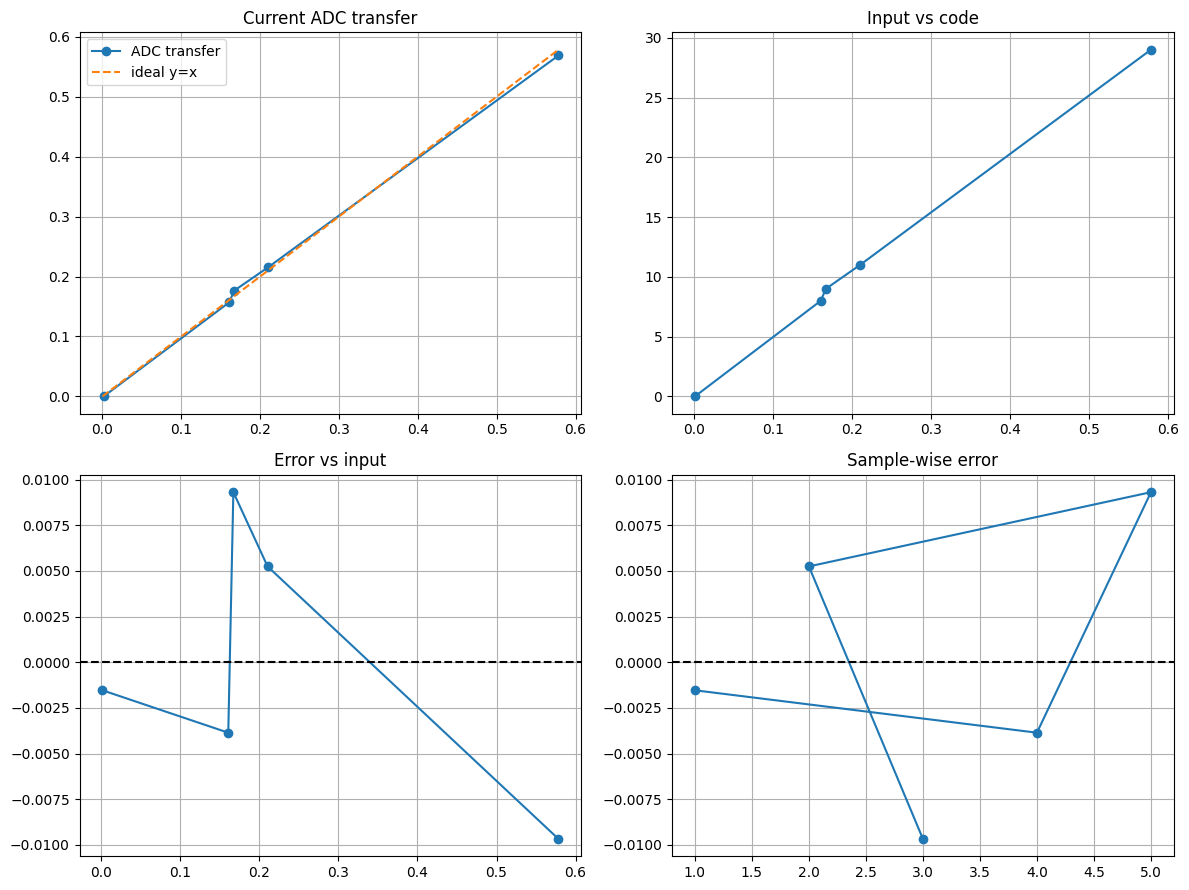

,sample_id,t_start,t_stop,t_mid,input_val,output_val,code_val,error,error_lsb
0,1,0.001301,0.001502,0.001479,0.001536,0.000000,0.0,-0.001536,-0.015669
1,2,0.005301,0.005502,0.005500,0.210441,0.215686,11.0,0.005246,0.053506
2,3,0.009301,0.009501,0.009403,0.578301,0.568624,29.0,-0.009676,-0.098700
3,4,0.013301,0.013501,0.013501,0.160721,0.156863,8.0,-0.003859,-0.039359
4,5,0.017301,0.017502,0.017365,0.167159,0.176471,9.0,0.009312,0.094982


,adc_name,num_samples,input_min,input_max,output_min,output_max,rmse_error,maxabs_error,mean_error,rmse_error_lsb,maxabs_error_lsb,code_decrease_count,output_decrease_count
0,adc_current,5,0.001536,0.578301,0.0,0.568624,0.00671,0.009676,-0.000103,0.068441,0.0987,0,0


In [180]:
adc_i_df = loaded_blocks["adc_current.txt"]["df"].copy()

i_samples = extract_plateau_samples(
    adc_i_df,
    input_aliases=["i_adc_in"],
    output_aliases=["i_adc_out", "i_adc_q"],
    code_aliases=["i_adc_code"],
    gate_aliases=["adc_valid"]
)

current_adc_metrics_df = adc_metrics_from_samples(i_samples, "adc_current")

fig, ax = plt.subplots(2, 2, figsize=(12, 9))

# transfer
if len(i_samples):
    s = i_samples.sort_values("input_val")
    ax[0,0].plot(s["input_val"], s["output_val"], marker="o", label="ADC transfer")
    lo = min(s["input_val"].min(), s["output_val"].min())
    hi = max(s["input_val"].max(), s["output_val"].max())
    ax[0,0].plot([lo, hi], [lo, hi], linestyle="--", label="ideal y=x")
    ax[0,0].set_title("Current ADC transfer")
    ax[0,0].grid(True)
    ax[0,0].legend()

    ax[0,1].plot(s["input_val"], s["code_val"], marker="o")
    ax[0,1].set_title("Input vs code")
    ax[0,1].grid(True)

    ax[1,0].plot(s["input_val"], s["error"], marker="o")
    ax[1,0].axhline(0, linestyle="--", color="black")
    ax[1,0].set_title("Error vs input")
    ax[1,0].grid(True)

    ax[1,1].plot(s["sample_id"], s["error"], marker="o", label="error")
    ax[1,1].axhline(0, linestyle="--", color="black")
    ax[1,1].set_title("Sample-wise error")
    ax[1,1].grid(True)

plt.tight_layout()
plt.show()

display(i_samples)
current_adc_metrics_df

/tmp/ipykernel_55/1276959548.py:82: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  code_decreases = np.sum(np.diff(s["code_val"].fillna(method="ffill")) < -0.5) if "code_val" in s.columns else np.nan


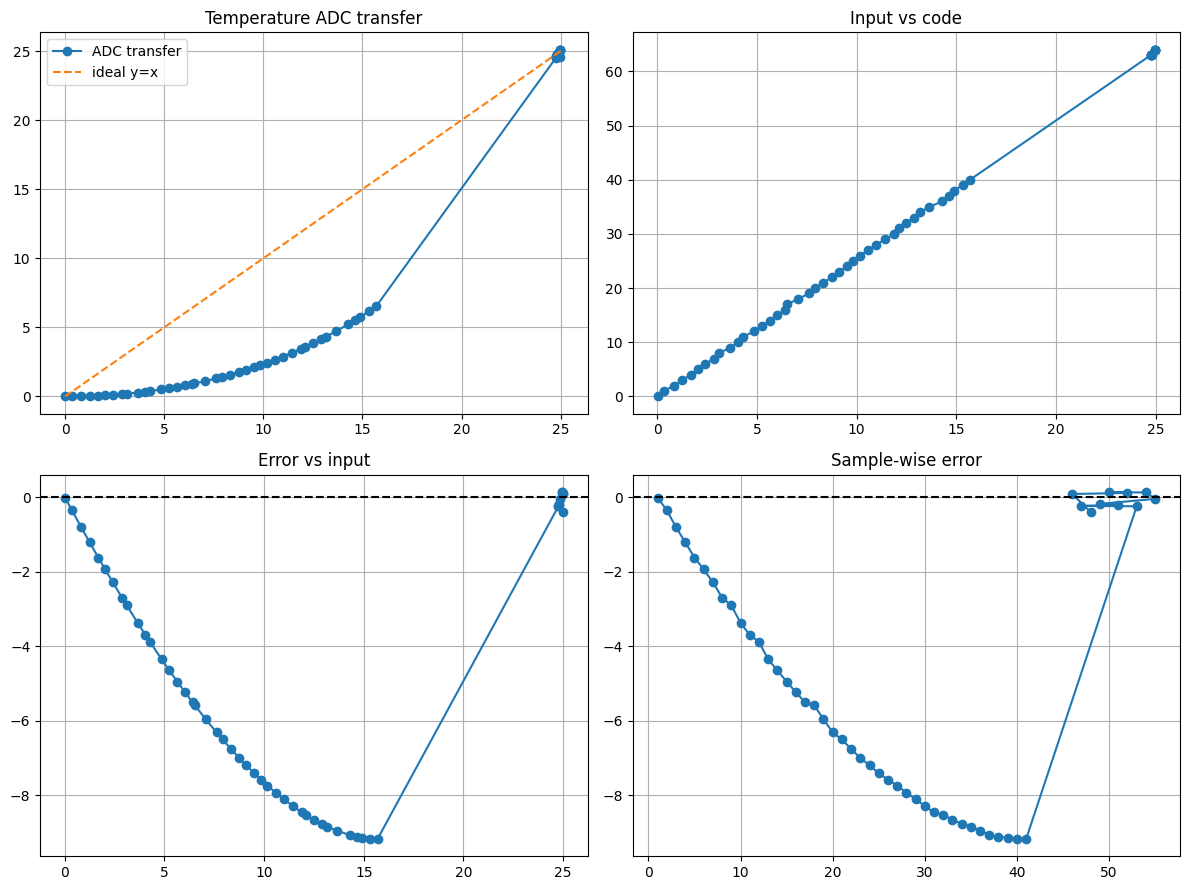

,sample_id,t_start,t_stop,t_mid,input_val,output_val,code_val,error,error_lsb
0,1,0.000000,0.000008,6.021327e-07,0.015049,0.000000,0.0,-0.015049,-0.120514
1,2,0.000008,0.000024,1.438075e-05,0.356920,0.002545,1.0,-0.354375,-2.837952
2,3,0.000024,0.000040,3.352618e-05,0.824093,0.013743,2.0,-0.810350,-6.489551
3,4,0.000040,0.000056,5.113343e-05,1.245836,0.031692,3.0,-1.214144,-9.723268
4,5,0.000056,0.000072,6.964596e-05,1.681259,0.057910,4.0,-1.623349,-13.000321
5,6,0.000073,0.000090,8.433418e-05,2.020812,0.084393,5.0,-1.936419,-15.507487
6,7,0.000091,0.000107,1.013998e-04,2.409419,0.120381,6.0,-2.289037,-18.331370
7,8,0.000108,0.000125,1.219490e-04,2.868314,0.171388,7.0,-2.696925,-21.597870
8,9,0.000125,0.000143,1.327236e-04,3.105188,0.201929,8.0,-2.903259,-23.250260
9,10,0.000144,0.000161,1.582599e-04,3.656335,0.281882,9.0,-3.374453,-27.023737


,adc_name,num_samples,input_min,input_max,output_min,output_max,rmse_error,maxabs_error,mean_error,rmse_error_lsb,maxabs_error_lsb,code_decrease_count,output_decrease_count
0,adc_temp,51,0.015049,24.97851,0.0,25.09782,5.820898,9.169671,-4.716753,46.615683,73.433772,0,3


In [181]:
adc_t_df = loaded_blocks["adc_temp.txt"]["df"].copy()

t_samples = extract_plateau_samples(
    adc_t_df,
    input_aliases=["t_adc_in"],
    output_aliases=["t_adc_out", "t_adc_q"],
    code_aliases=["t_adc_code"],
    gate_aliases=["adc_valid", "conv_clk"]
)

temp_adc_metrics_df = adc_metrics_from_samples(t_samples, "adc_temp")

fig, ax = plt.subplots(2, 2, figsize=(12, 9))

if len(t_samples):
    s = t_samples.sort_values("input_val")
    ax[0,0].plot(s["input_val"], s["output_val"], marker="o", label="ADC transfer")
    lo = min(s["input_val"].min(), s["output_val"].min())
    hi = max(s["input_val"].max(), s["output_val"].max())
    ax[0,0].plot([lo, hi], [lo, hi], linestyle="--", label="ideal y=x")
    ax[0,0].set_title("Temperature ADC transfer")
    ax[0,0].grid(True)
    ax[0,0].legend()

    ax[0,1].plot(s["input_val"], s["code_val"], marker="o")
    ax[0,1].set_title("Input vs code")
    ax[0,1].grid(True)

    ax[1,0].plot(s["input_val"], s["error"], marker="o")
    ax[1,0].axhline(0, linestyle="--", color="black")
    ax[1,0].set_title("Error vs input")
    ax[1,0].grid(True)

    ax[1,1].plot(s["sample_id"], s["error"], marker="o")
    ax[1,1].axhline(0, linestyle="--", color="black")
    ax[1,1].set_title("Sample-wise error")
    ax[1,1].grid(True)

plt.tight_layout()
plt.show()

display(t_samples)
temp_adc_metrics_df

/tmp/ipykernel_55/2454618661.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  code = vcode.fillna(method="ffill")


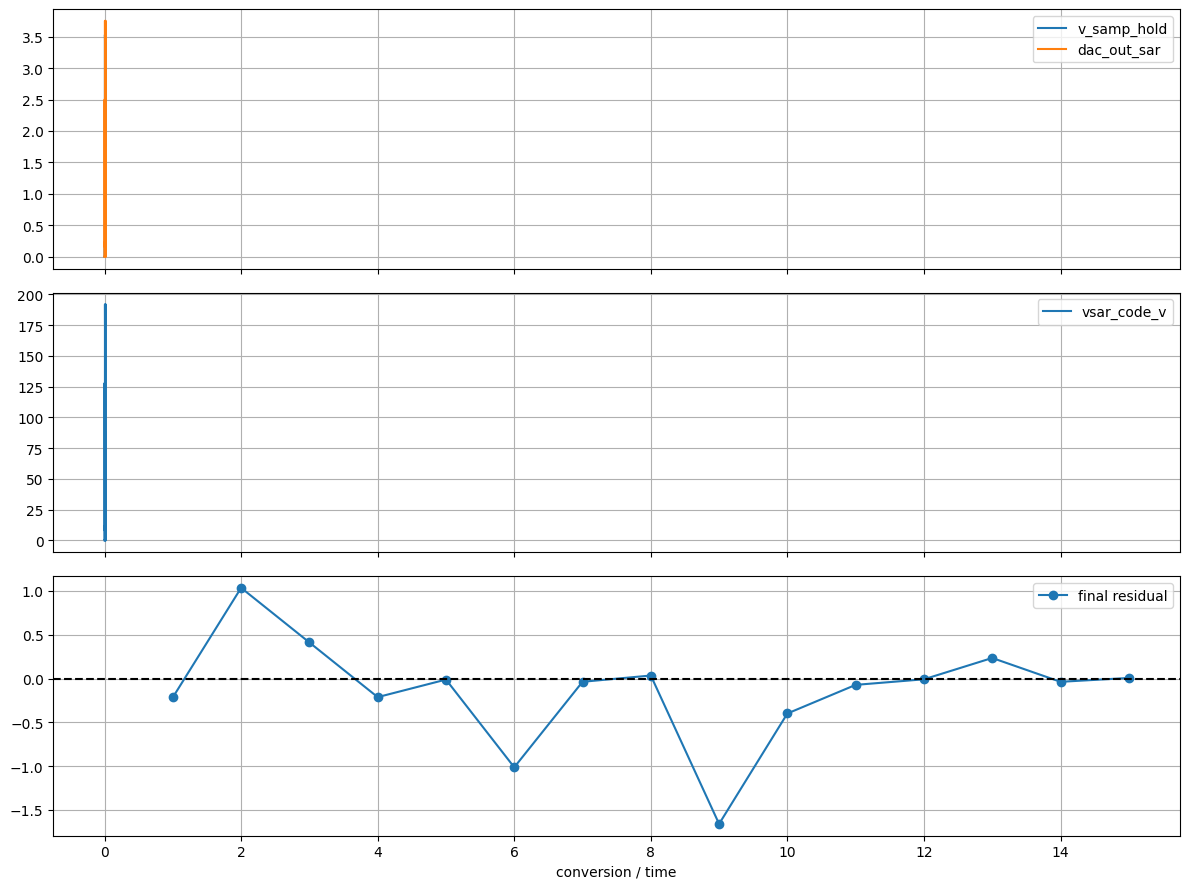

,conversion_id,t_start,t_stop,t_mid,vin_final,vdac_final,code_final,residual
0,1,0.000000,0.000508,0.000492,0.214804,0.000000,0.0,-0.214804
1,2,0.000508,0.000908,0.000901,0.213948,1.250000,0.0,1.036052
2,3,0.000909,0.001308,0.001301,0.213095,0.625000,0.0,0.411905
3,4,0.001309,0.001709,0.001700,0.212246,0.000000,0.0,-0.212246
4,5,0.001709,0.005101,0.004153,0.207116,0.195312,10.0,-0.011803
5,6,0.005101,0.005908,0.005835,3.513685,2.500000,128.0,-1.013685
6,7,0.005909,0.007105,0.006951,3.474665,3.437500,176.0,-0.037165
7,8,0.007106,0.010101,0.009035,3.402992,3.437500,176.0,0.034508
8,9,0.010101,0.010508,0.010477,1.660401,0.000000,0.0,-1.660401
9,10,0.010509,0.011308,0.011162,1.649065,1.250000,64.0,-0.399065


,adc_name,num_conversions,rmse_residual,maxabs_residual,code_min,code_max
0,adc_voltage_sar,15,0.596804,1.660401,0.0,176.0


In [182]:
adc_v_df = loaded_blocks["adc_voltage_sar.txt"]["df"].copy()

tv = get_time(adc_v_df)
vin = get_sig(adc_v_df, ["v_samp_hold"])
vdac = get_sig(adc_v_df, ["dac_out_sar"])
vcode = get_sig(adc_v_df, ["vsar_code_v"])

# conversion segmentation from code resets / large drops
rows = []
if vcode is not None and len(vcode.dropna()):
    code = vcode.fillna(method="ffill")
    reset_mask = (code.diff() < -5) | ((code < 1) & (code.shift(1) > 5))
    reset_idx = list(np.where(reset_mask.fillna(False))[0])

    starts = [0] + [i+1 for i in reset_idx]
    ends = reset_idx + [len(code)-1]

    conv_id = 0
    for s_idx, e_idx in zip(starts, ends):
        if e_idx - s_idx < 5:
            continue
        conv_id += 1
        m = np.arange(s_idx + int(0.7*(e_idx-s_idx)), e_idx+1)  # final 30%
        rows.append({
            "conversion_id": conv_id,
            "t_start": float(tv.iloc[s_idx]),
            "t_stop": float(tv.iloc[e_idx]),
            "t_mid": float(tv.iloc[m].median()),
            "vin_final": float(vin.iloc[m].median()) if vin is not None else np.nan,
            "vdac_final": float(vdac.iloc[m].median()) if vdac is not None else np.nan,
            "code_final": float(vcode.iloc[m].median()) if vcode is not None else np.nan,
        })

sar_samples = pd.DataFrame(rows)
if len(sar_samples):
    sar_samples["residual"] = sar_samples["vdac_final"] - sar_samples["vin_final"]

sar_voltage_metrics_df = pd.DataFrame([{
    "adc_name": "adc_voltage_sar",
    "num_conversions": len(sar_samples),
    "rmse_residual": rmse(sar_samples["residual"]) if len(sar_samples) else np.nan,
    "maxabs_residual": max_abs(sar_samples["residual"]) if len(sar_samples) else np.nan,
    "code_min": sar_samples["code_final"].min() if len(sar_samples) else np.nan,
    "code_max": sar_samples["code_final"].max() if len(sar_samples) else np.nan,
}])

fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

if vin is not None:
    ax[0].plot(tv, vin, label="v_samp_hold")
if vdac is not None:
    ax[0].plot(tv, vdac, label="dac_out_sar")
ax[0].legend()
ax[0].grid(True)

if vcode is not None:
    ax[1].plot(tv, vcode, label="vsar_code_v")
ax[1].legend()
ax[1].grid(True)

if len(sar_samples):
    ax[2].plot(sar_samples["conversion_id"], sar_samples["residual"], marker="o", label="final residual")
    ax[2].axhline(0, linestyle="--", color="black")
ax[2].legend()
ax[2].grid(True)
ax[2].set_xlabel("conversion / time")

plt.tight_layout()
plt.show()

display(sar_samples)
sar_voltage_metrics_df

In [183]:
adc_summary_df = pd.concat(
    [current_adc_metrics_df, temp_adc_metrics_df, sar_voltage_metrics_df],
    ignore_index=True,
    sort=False
)

adc_summary_df

,adc_name,num_samples,input_min,input_max,output_min,output_max,rmse_error,maxabs_error,mean_error,rmse_error_lsb,maxabs_error_lsb,code_decrease_count,output_decrease_count,num_conversions,rmse_residual,maxabs_residual,code_min,code_max
0,adc_current,5.0,0.001536,0.578301,0.0,0.568624,0.006710,0.009676,-0.000103,0.068441,0.098700,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,adc_temp,51.0,0.015049,24.978510,0.0,25.097820,5.820898,9.169671,-4.716753,46.615683,73.433772,0.0,3.0,NaN,NaN,NaN,NaN,NaN
2,adc_voltage_sar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,0.596804,1.660401,0.0,176.0


In [184]:
calibration_refined_df.to_csv("/kaggle/working/calibration_refined_df.csv", index=False)
cal_error_compare_df.to_csv("/kaggle/working/cal_error_compare_df.csv", index=False)

i_samples.to_csv("/kaggle/working/adc_current_samples.csv", index=False)
t_samples.to_csv("/kaggle/working/adc_temp_samples.csv", index=False)
sar_samples.to_csv("/kaggle/working/adc_voltage_sar_samples.csv", index=False)

current_adc_metrics_df.to_csv("/kaggle/working/current_adc_metrics_df.csv", index=False)
temp_adc_metrics_df.to_csv("/kaggle/working/temp_adc_metrics_df.csv", index=False)
sar_voltage_metrics_df.to_csv("/kaggle/working/sar_voltage_metrics_df.csv", index=False)
adc_summary_df.to_csv("/kaggle/working/adc_summary_df.csv", index=False)

print("saved calibration + ADC tables")

saved calibration + ADC tables


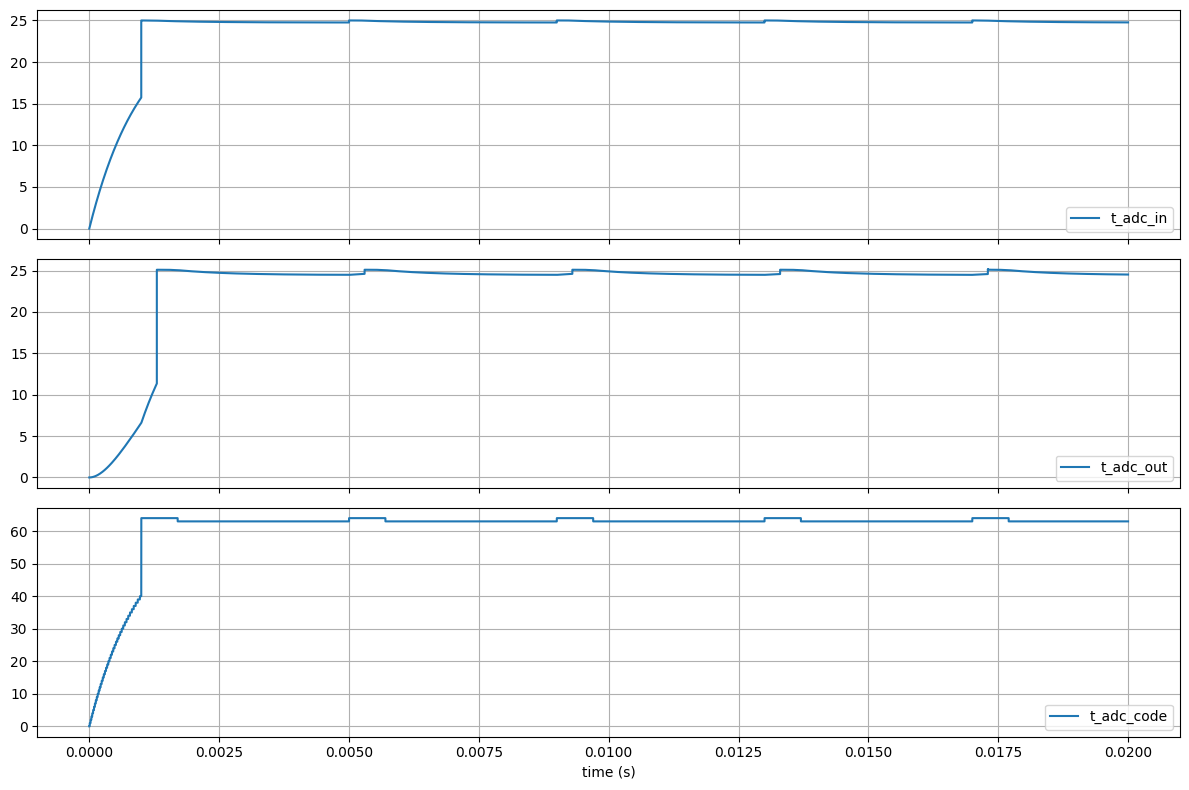

In [185]:
adc_t_df = loaded_blocks["adc_temp.txt"]["df"].copy()

tt = get_time(adc_t_df)
tin = get_sig(adc_t_df, ["t_adc_in"])
tout = get_sig(adc_t_df, ["t_adc_out"])
tcode = get_sig(adc_t_df, ["t_adc_code"])

fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

if tin is not None:
    ax[0].plot(tt, tin, label="t_adc_in")
    ax[0].legend()
    ax[0].grid(True)

if tout is not None:
    ax[1].plot(tt, tout, label="t_adc_out")
    ax[1].legend()
    ax[1].grid(True)

if tcode is not None:
    ax[2].plot(tt, tcode, label="t_adc_code")
    ax[2].legend()
    ax[2].grid(True)

ax[2].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

In [186]:
adc_v_df = loaded_blocks["adc_voltage_sar.txt"]["df"].copy()

tv    = get_time(adc_v_df)
vsrc  = get_sig(adc_v_df, ["v_sar_src", "v_cal_out"])
vsh   = get_sig(adc_v_df, ["v_samp_hold"])
vdac  = get_sig(adc_v_df, ["dac_out_sar"])
vcode = get_sig(adc_v_df, ["vsar_code_v"])
vvalid= get_sig(adc_v_df, ["adc_valid_sar"])

print("found:",
      "time", tv is not None,
      "vsrc", vsrc is not None,
      "vsh", vsh is not None,
      "vdac", vdac is not None,
      "vcode", vcode is not None,
      "vvalid", vvalid is not None)

valid_windows = []
if vvalid is not None:
    rs = rising_edges(tv, vvalid, thr=0.5)
    fs = falling_edges(tv, vvalid, thr=0.5)
    for s in rs:
        e = next((x for x in fs if x > s), np.nan)
        if pd.notna(e):
            valid_windows.append((s, e))

rows = []
for k, (s, e) in enumerate(valid_windows, start=1):
    # use middle of valid pulse as final settled read window
    t0 = s + 0.25*(e - s)
    t1 = s + 0.75*(e - s)
    m = (tv >= t0) & (tv <= t1)
    if m.sum() < 2:
        continue

    rows.append({
        "sample_id": k,
        "t_valid_start": s,
        "t_valid_stop": e,
        "t_read": float(tv[m].median()),
        "v_src_final": float(vsrc[m].median()) if vsrc is not None else np.nan,
        "v_samp_hold_final": float(vsh[m].median()) if vsh is not None else np.nan,
        "v_dac_final": float(vdac[m].median()) if vdac is not None else np.nan,
        "code_final": float(vcode[m].median()) if vcode is not None else np.nan,
    })

sar_real_samples = pd.DataFrame(rows)

if len(sar_real_samples):
    sar_real_samples["sample_hold_error"] = sar_real_samples["v_samp_hold_final"] - sar_real_samples["v_src_final"]
    sar_real_samples["conversion_residual"] = sar_real_samples["v_dac_final"] - sar_real_samples["v_samp_hold_final"]
    sar_real_samples["end_to_end_error"] = sar_real_samples["v_dac_final"] - sar_real_samples["v_src_final"]

sar_real_samples

found: time True vsrc True vsh True vdac True vcode True vvalid False


""


In [187]:
def sign_consistency_ratio(x, y):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    if len(x) < 3 or len(y) < 3:
        return np.nan
    dx = np.sign(np.diff(x))
    dy = np.sign(np.diff(y))
    mask = (dx != 0) & (dy != 0)
    if mask.sum() == 0:
        return np.nan
    return float((dx[mask] == dy[mask]).mean())

sar_real_metrics_df = pd.DataFrame([{
    "num_valid_conversions": len(sar_real_samples),
    "sample_hold_rmse": rmse(sar_real_samples["sample_hold_error"]) if len(sar_real_samples) else np.nan,
    "sample_hold_maxabs": max_abs(sar_real_samples["sample_hold_error"]) if len(sar_real_samples) else np.nan,
    "conversion_residual_rmse": rmse(sar_real_samples["conversion_residual"]) if len(sar_real_samples) else np.nan,
    "conversion_residual_maxabs": max_abs(sar_real_samples["conversion_residual"]) if len(sar_real_samples) else np.nan,
    "end_to_end_rmse": rmse(sar_real_samples["end_to_end_error"]) if len(sar_real_samples) else np.nan,
    "end_to_end_maxabs": max_abs(sar_real_samples["end_to_end_error"]) if len(sar_real_samples) else np.nan,
    "spearman_src_vs_code": sar_real_samples["v_src_final"].corr(sar_real_samples["code_final"], method="spearman") if len(sar_real_samples) else np.nan,
    "spearman_src_vs_dac": sar_real_samples["v_src_final"].corr(sar_real_samples["v_dac_final"], method="spearman") if len(sar_real_samples) else np.nan,
    "direction_consistency_src_to_code": sign_consistency_ratio(sar_real_samples["v_src_final"], sar_real_samples["code_final"]) if len(sar_real_samples) else np.nan,
    "direction_consistency_src_to_dac": sign_consistency_ratio(sar_real_samples["v_src_final"], sar_real_samples["v_dac_final"]) if len(sar_real_samples) else np.nan,
}])

sar_real_metrics_df

,num_valid_conversions,sample_hold_rmse,sample_hold_maxabs,conversion_residual_rmse,conversion_residual_maxabs,end_to_end_rmse,end_to_end_maxabs,spearman_src_vs_code,spearman_src_vs_dac,direction_consistency_src_to_code,direction_consistency_src_to_dac
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_55/2075786818.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[3].legend()


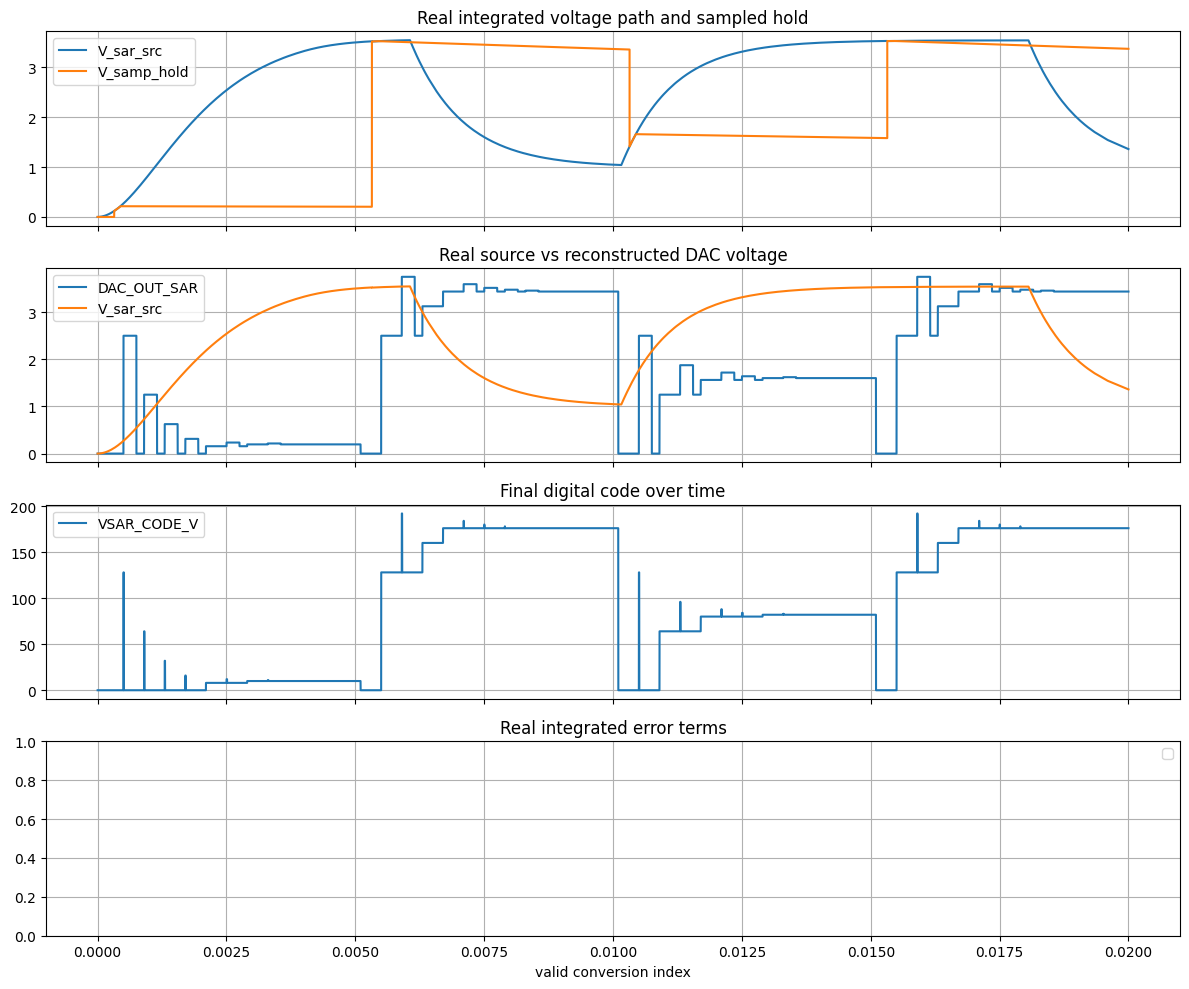

In [188]:
fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

if vsrc is not None:
    ax[0].plot(tv, vsrc, label="V_sar_src")
if vsh is not None:
    ax[0].plot(tv, vsh, label="V_samp_hold")
for s, e in valid_windows:
    ax[0].axvspan(s, e, alpha=0.15)
ax[0].legend()
ax[0].grid(True)
ax[0].set_title("Real integrated voltage path and sampled hold")

if vdac is not None:
    ax[1].plot(tv, vdac, label="DAC_OUT_SAR")
if vsrc is not None:
    ax[1].plot(tv, vsrc, label="V_sar_src")
for s, e in valid_windows:
    ax[1].axvspan(s, e, alpha=0.15)
ax[1].legend()
ax[1].grid(True)
ax[1].set_title("Real source vs reconstructed DAC voltage")

if vcode is not None:
    ax[2].plot(tv, vcode, label="VSAR_CODE_V")
for s, e in valid_windows:
    ax[2].axvspan(s, e, alpha=0.15)
ax[2].legend()
ax[2].grid(True)
ax[2].set_title("Final digital code over time")

if len(sar_real_samples):
    ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["sample_hold_error"], marker="o", label="sample-hold error")
    ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["conversion_residual"], marker="o", label="conversion residual")
    ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["end_to_end_error"], marker="o", label="end-to-end error")
    ax[3].axhline(0, linestyle="--", color="black")
ax[3].legend()
ax[3].grid(True)
ax[3].set_xlabel("valid conversion index")
ax[3].set_title("Real integrated error terms")

plt.tight_layout()
plt.show()

In [189]:
sar_real_report_df = pd.DataFrame([{
    "claim": "SAR samples real calibrated voltage path",
    "metric": "sample_hold_rmse",
    "value": sar_real_metrics_df["sample_hold_rmse"].iloc[0]
}, {
    "claim": "SAR DAC converges to sampled voltage",
    "metric": "conversion_residual_rmse",
    "value": sar_real_metrics_df["conversion_residual_rmse"].iloc[0]
}, {
    "claim": "End-to-end analog-to-digital-to-analog path tracks real source",
    "metric": "end_to_end_rmse",
    "value": sar_real_metrics_df["end_to_end_rmse"].iloc[0]
}, {
    "claim": "Digital code follows real source",
    "metric": "spearman_src_vs_code",
    "value": sar_real_metrics_df["spearman_src_vs_code"].iloc[0]
}])

sar_real_report_df

,claim,metric,value
0,SAR samples real calibrated voltage path,sample_hold_rmse,NaN
1,SAR DAC converges to sampled voltage,conversion_residual_rmse,NaN
2,End-to-end analog-to-digital-to-analog path tr...,end_to_end_rmse,NaN
3,Digital code follows real source,spearman_src_vs_code,NaN


In [190]:
adc_v_df = loaded_blocks["adc_voltage_sar.txt"]["df"].copy()

tv    = get_time(adc_v_df)
vsrc  = get_sig(adc_v_df, ["v_sar_src", "v_cal_out"])
vsh   = get_sig(adc_v_df, ["v_samp_hold"])
vdac  = get_sig(adc_v_df, ["dac_out_sar"])
vcode = get_sig(adc_v_df, ["vsar_code_v"])

print("found:",
      "time", tv is not None,
      "vsrc", vsrc is not None,
      "vsh", vsh is not None,
      "vdac", vdac is not None,
      "vcode", vcode is not None)

# segment using held-value changes
sar_rows = []

if vsh is not None:
    vsh_ff = vsh.ffill()
    # detect new held plateaus
    grp = (vsh_ff.diff().abs() > 0.05).cumsum()

    for gid, sub in adc_v_df.groupby(grp):
        if len(sub) < 20:
            continue

        ts   = get_time(sub)
        src  = get_sig(sub, ["v_sar_src", "v_cal_out"])
        sh   = get_sig(sub, ["v_samp_hold"])
        dac  = get_sig(sub, ["dac_out_sar"])
        code = get_sig(sub, ["vsar_code_v"])

        if ts is None or src is None or sh is None or dac is None or code is None:
            continue

        # use final 25% of each hold plateau as end-of-conversion read region
        k0 = int(0.75 * len(sub))
        ts2   = ts.iloc[k0:]
        src2  = src.iloc[k0:]
        sh2   = sh.iloc[k0:]
        dac2  = dac.iloc[k0:]
        code2 = code.iloc[k0:]

        sar_rows.append({
            "sample_id": len(sar_rows) + 1,
            "t_start": float(ts.iloc[0]),
            "t_stop": float(ts.iloc[-1]),
            "t_read": float(ts2.median()),
            "v_src_final": float(src2.median()),
            "v_samp_hold_final": float(sh2.median()),
            "v_dac_final": float(dac2.median()),
            "code_final": float(code2.median()),
            "src_slope_end": linear_slope(ts2, src2),
            "dac_slope_end": linear_slope(ts2, dac2),
            "code_slope_end": linear_slope(ts2, code2),
        })

sar_real_samples = pd.DataFrame(sar_rows)

if len(sar_real_samples):
    sar_real_samples["sample_hold_error"] = sar_real_samples["v_samp_hold_final"] - sar_real_samples["v_src_final"]
    sar_real_samples["conversion_residual"] = sar_real_samples["v_dac_final"] - sar_real_samples["v_samp_hold_final"]
    sar_real_samples["end_to_end_error"] = sar_real_samples["v_dac_final"] - sar_real_samples["v_src_final"]

sar_real_samples

found: time True vsrc True vsh True vdac True vcode True


,sample_id,t_start,t_stop,t_read,v_src_final,v_samp_hold_final,v_dac_final,code_final,src_slope_end,dac_slope_end,code_slope_end,sample_hold_error,conversion_residual,end_to_end_error
0,1,0.000000,0.000321,0.000302,0.106316,2.224106e-08,0.000000,0.0,515.585472,0.000000,0.000000,-0.106316,-2.224106e-08,-0.106316
1,2,0.000321,0.005321,0.004497,3.440601,2.064062e-01,0.195312,10.0,194.711082,-124.954424,-6199.628470,-3.234195,-1.109370e-02,-3.245289
2,3,0.005321,0.010321,0.010101,1.098305,3.366925e+00,0.000000,0.0,-36.563542,-2333.821835,-119380.682950,2.268620,-3.366925e+00,-1.098305
3,4,0.010321,0.015321,0.013801,3.484151,1.606129e+00,1.601562,82.0,45.119593,-820.236616,-41789.976774,-1.878022,-4.567000e-03,-1.882589
4,5,0.015321,0.020000,0.018300,2.999550,3.431740e+00,3.457031,176.0,-1431.716995,-32.637694,-175.290852,0.432190,2.529100e-02,0.457481


In [191]:
def sign_consistency_ratio(x, y):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    if len(x) < 3 or len(y) < 3:
        return np.nan
    dx = np.sign(np.diff(x))
    dy = np.sign(np.diff(y))
    mask = (dx != 0) & (dy != 0)
    if mask.sum() == 0:
        return np.nan
    return float((dx[mask] == dy[mask]).mean())

sar_real_metrics_df = pd.DataFrame([{
    "num_real_conversions": len(sar_real_samples),
    "sample_hold_rmse": rmse(sar_real_samples["sample_hold_error"]) if len(sar_real_samples) else np.nan,
    "sample_hold_maxabs": max_abs(sar_real_samples["sample_hold_error"]) if len(sar_real_samples) else np.nan,
    "conversion_residual_rmse": rmse(sar_real_samples["conversion_residual"]) if len(sar_real_samples) else np.nan,
    "conversion_residual_maxabs": max_abs(sar_real_samples["conversion_residual"]) if len(sar_real_samples) else np.nan,
    "end_to_end_rmse": rmse(sar_real_samples["end_to_end_error"]) if len(sar_real_samples) else np.nan,
    "end_to_end_maxabs": max_abs(sar_real_samples["end_to_end_error"]) if len(sar_real_samples) else np.nan,
    "spearman_src_vs_code": sar_real_samples["v_src_final"].corr(sar_real_samples["code_final"], method="spearman") if len(sar_real_samples) else np.nan,
    "spearman_src_vs_dac": sar_real_samples["v_src_final"].corr(sar_real_samples["v_dac_final"], method="spearman") if len(sar_real_samples) else np.nan,
    "direction_consistency_src_to_code": sign_consistency_ratio(sar_real_samples["v_src_final"], sar_real_samples["code_final"]) if len(sar_real_samples) else np.nan,
    "direction_consistency_src_to_dac": sign_consistency_ratio(sar_real_samples["v_src_final"], sar_real_samples["v_dac_final"]) if len(sar_real_samples) else np.nan,
}])

sar_real_metrics_df

,num_real_conversions,sample_hold_rmse,sample_hold_maxabs,conversion_residual_rmse,conversion_residual_maxabs,end_to_end_rmse,end_to_end_maxabs,spearman_src_vs_code,spearman_src_vs_dac,direction_consistency_src_to_code,direction_consistency_src_to_dac
0,5,1.966302,3.234195,1.505787,3.366925,1.760847,3.245289,0.666886,0.666886,0.75,0.75


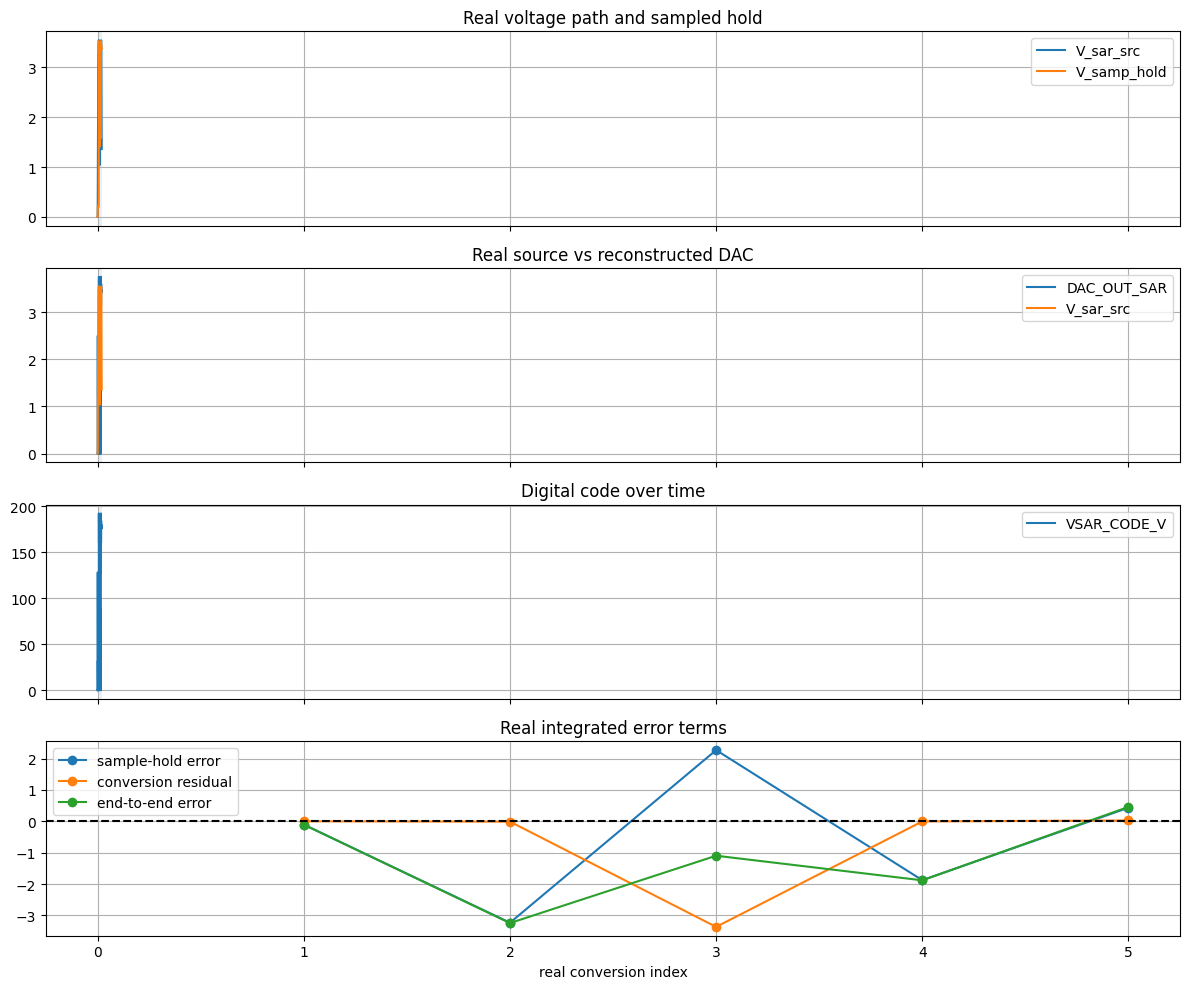

In [192]:
fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

if vsrc is not None:
    ax[0].plot(tv, vsrc, label="V_sar_src")
if vsh is not None:
    ax[0].plot(tv, vsh, label="V_samp_hold")
for _, r in sar_real_samples.iterrows():
    ax[0].axvspan(r["t_start"], r["t_stop"], alpha=0.10)
ax[0].legend()
ax[0].grid(True)
ax[0].set_title("Real voltage path and sampled hold")

if vdac is not None:
    ax[1].plot(tv, vdac, label="DAC_OUT_SAR")
if vsrc is not None:
    ax[1].plot(tv, vsrc, label="V_sar_src")
for _, r in sar_real_samples.iterrows():
    ax[1].axvspan(r["t_start"], r["t_stop"], alpha=0.10)
ax[1].legend()
ax[1].grid(True)
ax[1].set_title("Real source vs reconstructed DAC")

if vcode is not None:
    ax[2].plot(tv, vcode, label="VSAR_CODE_V")
for _, r in sar_real_samples.iterrows():
    ax[2].axvspan(r["t_start"], r["t_stop"], alpha=0.10)
ax[2].legend()
ax[2].grid(True)
ax[2].set_title("Digital code over time")

if len(sar_real_samples):
    ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["sample_hold_error"], marker="o", label="sample-hold error")
    ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["conversion_residual"], marker="o", label="conversion residual")
    ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["end_to_end_error"], marker="o", label="end-to-end error")
    ax[3].axhline(0, linestyle="--", color="black")
ax[3].legend()
ax[3].grid(True)
ax[3].set_xlabel("real conversion index")
ax[3].set_title("Real integrated error terms")

plt.tight_layout()
plt.show()

In [193]:
sar_real_report_df = pd.DataFrame([{
    "claim": "SAR samples real calibrated voltage path",
    "metric": "sample_hold_rmse",
    "value": sar_real_metrics_df["sample_hold_rmse"].iloc[0]
}, {
    "claim": "SAR DAC converges to sampled voltage",
    "metric": "conversion_residual_rmse",
    "value": sar_real_metrics_df["conversion_residual_rmse"].iloc[0]
}, {
    "claim": "End-to-end source to DAC tracking",
    "metric": "end_to_end_rmse",
    "value": sar_real_metrics_df["end_to_end_rmse"].iloc[0]
}, {
    "claim": "Digital code follows real source",
    "metric": "spearman_src_vs_code",
    "value": sar_real_metrics_df["spearman_src_vs_code"].iloc[0]
}])

sar_real_report_df

,claim,metric,value
0,SAR samples real calibrated voltage path,sample_hold_rmse,1.966302
1,SAR DAC converges to sampled voltage,conversion_residual_rmse,1.505787
2,End-to-end source to DAC tracking,end_to_end_rmse,1.760847
3,Digital code follows real source,spearman_src_vs_code,0.666886


In [323]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- small helpers --------
def find_col(df, names):
    cols_norm = {c.lower().strip(): c for c in df.columns}
    for n in names:
        n0 = n.lower().strip()
        if n0 in cols_norm:
            return cols_norm[n0]
        # relaxed match
        for c0, c in cols_norm.items():
            if n0 == c0 or n0 in c0:
                return c
    return None

def series_or_none(df, names):
    c = find_col(df, names)
    return df[c].astype(float) if c is not None else None

def rmse(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.sqrt(np.mean(x**2)))

def max_abs(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.max(np.abs(x)))

def rising_edge_times(t, y, thr=0.5):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.where((y[:-1] < thr) & (y[1:] >= thr))[0]
    out = []
    for i in idx:
        t0, t1 = t[i], t[i+1]
        y0, y1 = y[i], y[i+1]
        if y1 == y0:
            out.append(t1)
        else:
            out.append(float(t0 + (thr - y0) * (t1 - t0) / (y1 - y0)))
    return np.array(out, dtype=float)

def nearest_value(t, y, tq):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(t) == 0:
        return np.nan
    i = np.argmin(np.abs(t - tq))
    return float(y[i])

def window_median(t, y, tq, half_width):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    m = (t >= tq - half_width) & (t <= tq + half_width)
    if m.sum() == 0:
        return np.nan
    return float(np.median(y[m]))

def sign_consistency_ratio(x, y):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    if len(x) < 3 or len(y) < 3:
        return np.nan
    dx = np.sign(np.diff(x))
    dy = np.sign(np.diff(y))
    mask = (dx != 0) & (dy != 0)
    if mask.sum() == 0:
        return np.nan
    return float((dx[mask] == dy[mask]).mean())

# -------- load the real SAR file --------
sar_df = loaded_blocks["adc_voltage_sar.txt"]["df"].copy()

t      = series_or_none(sar_df, ["time"])
vvalid = series_or_none(sar_df, ["v(adc_valid_sar)", "adc_valid_sar"])
sclk   = series_or_none(sar_df, ["v(samp_clk)", "samp_clk"])
vsrc   = series_or_none(sar_df, ["v(v_sar_src)", "v_sar_src"])
vsh    = series_or_none(sar_df, ["v(v_samp_hold)", "v_samp_hold"])
vdac   = series_or_none(sar_df, ["v(dac_out_sar)", "dac_out_sar"])
vcode  = series_or_none(sar_df, ["v(vsar_code_v)", "vsar_code_v"])

print("found:",
      "time", t is not None,
      "valid", vvalid is not None,
      "sclk", sclk is not None,
      "vsrc", vsrc is not None,
      "vsh", vsh is not None,
      "vdac", vdac is not None,
      "vcode", vcode is not None)

found: time True valid True sclk True vsrc True vsh True vdac True vcode True


In [324]:
# sample instant = rising edge of samp_clk
# final read instant = rising edge of adc_valid_sar

t_arr      = t.to_numpy()
vvalid_arr = vvalid.to_numpy()
sclk_arr   = sclk.to_numpy()
vsrc_arr   = vsrc.to_numpy()
vsh_arr    = vsh.to_numpy()
vdac_arr   = vdac.to_numpy()
vcode_arr  = vcode.to_numpy()

t_sample = rising_edge_times(t_arr, sclk_arr, thr=0.5)
t_valid  = rising_edge_times(t_arr, vvalid_arr, thr=0.5)

print("num sample edges:", len(t_sample))
print("num valid edges :", len(t_valid))

# pair each sample edge with the first valid edge after it
pairs = []
j = 0
for ts in t_sample:
    while j < len(t_valid) and t_valid[j] <= ts:
        j += 1
    if j < len(t_valid):
        pairs.append((float(ts), float(t_valid[j])))
        j += 1

print("paired conversions:", len(pairs))

rows = []
for k, (ts, tv) in enumerate(pairs, start=1):
    rows.append({
        "sample_id": k,
        "t_sample": ts,
        "t_valid": tv,

        # source should be taken at sample instant
        "v_src_at_sample": nearest_value(t_arr, vsrc_arr, ts),

        # held value just after sampling
        "v_hold_after_sample": window_median(t_arr, vsh_arr, ts + 20e-6, 20e-6),

        # final outputs should be taken at valid instant
        "v_dac_at_valid": window_median(t_arr, vdac_arr, tv, 20e-6),
        "code_at_valid": window_median(t_arr, vcode_arr, tv, 20e-6),
        "v_hold_at_valid": window_median(t_arr, vsh_arr, tv, 20e-6),
        "v_src_at_valid": window_median(t_arr, vsrc_arr, tv, 20e-6),
    })

sar_real_samples = pd.DataFrame(rows)

if len(sar_real_samples):
    sar_real_samples["sample_hold_error"] = (
        sar_real_samples["v_hold_after_sample"] - sar_real_samples["v_src_at_sample"]
    )
    sar_real_samples["conversion_residual"] = (
        sar_real_samples["v_dac_at_valid"] - sar_real_samples["v_hold_at_valid"]
    )
    sar_real_samples["end_to_end_error"] = (
        sar_real_samples["v_dac_at_valid"] - sar_real_samples["v_src_at_sample"]
    )
    sar_real_samples["sample_to_valid_delay_us"] = (
        (sar_real_samples["t_valid"] - sar_real_samples["t_sample"]) * 1e6
    )

sar_real_samples

num sample edges: 8
num valid edges : 8
paired conversions: 8


,sample_id,t_sample,t_valid,v_src_at_sample,v_hold_after_sample,v_dac_at_valid,code_at_valid,v_hold_at_valid,v_src_at_valid,sample_hold_error,conversion_residual,end_to_end_error,sample_to_valid_delay_us
0,1,0.000320,0.003800,0.119240,0.128636,0.195312,10.0,0.208136,3.263286,0.009395,-0.012823,0.076072,3480.0
1,2,0.005320,0.008800,3.524339,3.525188,3.437500,176.0,3.413804,1.163301,0.000849,0.023696,-0.086839,3480.0
2,3,0.010320,0.013800,1.413860,1.454068,1.601562,82.0,1.604813,3.484058,0.040208,-0.003251,0.187702,3480.0
3,4,0.015321,0.018800,3.531456,3.531617,3.437500,176.0,3.416246,2.211526,0.000161,0.021254,-0.093956,3480.0
4,5,0.020320,0.023801,1.263662,1.260275,1.191406,61.0,1.192712,3.075461,-0.003387,-0.001306,-0.072256,3480.0
5,6,0.025320,0.028800,3.445783,3.447124,3.359375,172.0,3.343103,3.541270,0.001341,0.016272,-0.086408,3480.0
6,7,0.030321,0.033800,2.959290,2.931672,2.656250,136.0,2.645168,1.059216,-0.027618,0.011082,-0.303040,3480.0
7,8,0.035320,0.038800,2.777044,2.788860,2.812500,144.0,2.771966,3.522560,0.011816,0.040534,0.035456,3480.0


In [325]:
sar_real_metrics_df = pd.DataFrame([{
    "num_real_conversions": len(sar_real_samples),

    "sample_hold_rmse": rmse(sar_real_samples["sample_hold_error"]) if len(sar_real_samples) else np.nan,
    "sample_hold_maxabs": max_abs(sar_real_samples["sample_hold_error"]) if len(sar_real_samples) else np.nan,

    "conversion_residual_rmse": rmse(sar_real_samples["conversion_residual"]) if len(sar_real_samples) else np.nan,
    "conversion_residual_maxabs": max_abs(sar_real_samples["conversion_residual"]) if len(sar_real_samples) else np.nan,

    "end_to_end_rmse": rmse(sar_real_samples["end_to_end_error"]) if len(sar_real_samples) else np.nan,
    "end_to_end_maxabs": max_abs(sar_real_samples["end_to_end_error"]) if len(sar_real_samples) else np.nan,

    "spearman_src_vs_code": sar_real_samples["v_src_at_sample"].corr(
        sar_real_samples["code_at_valid"], method="spearman"
    ) if len(sar_real_samples) else np.nan,

    "spearman_src_vs_dac": sar_real_samples["v_src_at_sample"].corr(
        sar_real_samples["v_dac_at_valid"], method="spearman"
    ) if len(sar_real_samples) else np.nan,

    "direction_consistency_src_to_code": sign_consistency_ratio(
        sar_real_samples["v_src_at_sample"], sar_real_samples["code_at_valid"]
    ) if len(sar_real_samples) else np.nan,

    "direction_consistency_src_to_dac": sign_consistency_ratio(
        sar_real_samples["v_src_at_sample"], sar_real_samples["v_dac_at_valid"]
    ) if len(sar_real_samples) else np.nan,

    "mean_sample_to_valid_delay_us": sar_real_samples["sample_to_valid_delay_us"].mean() if len(sar_real_samples) else np.nan
}])

sar_real_metrics_df

,num_real_conversions,sample_hold_rmse,sample_hold_maxabs,conversion_residual_rmse,conversion_residual_maxabs,end_to_end_rmse,end_to_end_maxabs,spearman_src_vs_code,spearman_src_vs_dac,direction_consistency_src_to_code,direction_consistency_src_to_dac,mean_sample_to_valid_delay_us
0,8,0.018102,0.040208,0.020064,0.040534,0.142813,0.30304,0.970077,0.970077,0.857143,0.857143,3480.0


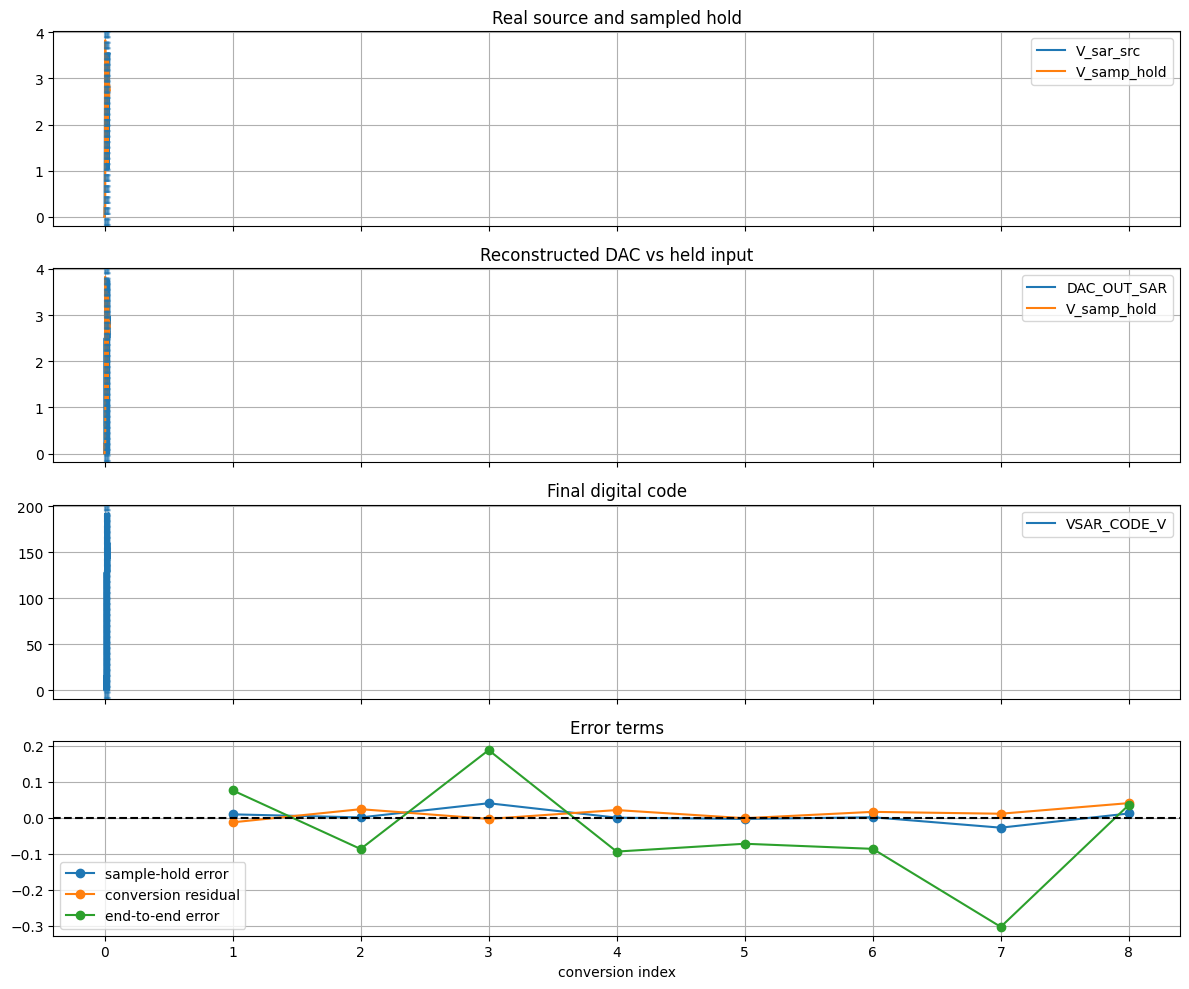

In [326]:
fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

ax[0].plot(t_arr, vsrc_arr, label="V_sar_src")
ax[0].plot(t_arr, vsh_arr, label="V_samp_hold")
for ts in t_sample:
    ax[0].axvline(ts, linestyle="--", alpha=0.35)
for tv in t_valid:
    ax[0].axvline(tv, linestyle=":", alpha=0.35)
ax[0].legend()
ax[0].grid(True)
ax[0].set_title("Real source and sampled hold")

ax[1].plot(t_arr, vdac_arr, label="DAC_OUT_SAR")
ax[1].plot(t_arr, vsh_arr, label="V_samp_hold")
for ts in t_sample:
    ax[1].axvline(ts, linestyle="--", alpha=0.35)
for tv in t_valid:
    ax[1].axvline(tv, linestyle=":", alpha=0.35)
ax[1].legend()
ax[1].grid(True)
ax[1].set_title("Reconstructed DAC vs held input")

ax[2].plot(t_arr, vcode_arr, label="VSAR_CODE_V")
for ts in t_sample:
    ax[2].axvline(ts, linestyle="--", alpha=0.35)
for tv in t_valid:
    ax[2].axvline(tv, linestyle=":", alpha=0.35)
ax[2].legend()
ax[2].grid(True)
ax[2].set_title("Final digital code")

if len(sar_real_samples):
    ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["sample_hold_error"], marker="o", label="sample-hold error")
    ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["conversion_residual"], marker="o", label="conversion residual")
    ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["end_to_end_error"], marker="o", label="end-to-end error")
    ax[3].axhline(0, linestyle="--", color="black")
ax[3].legend()
ax[3].grid(True)
ax[3].set_xlabel("conversion index")
ax[3].set_title("Error terms")

plt.tight_layout()
plt.show()

In [327]:

sar_real_report_df = pd.DataFrame([{
    "claim": "SAR samples real calibrated voltage path",
    "metric": "sample_hold_rmse",
    "value": sar_real_metrics_df["sample_hold_rmse"].iloc[0]
}, {
    "claim": "SAR DAC converges to held voltage",
    "metric": "conversion_residual_rmse",
    "value": sar_real_metrics_df["conversion_residual_rmse"].iloc[0]
}, {
    "claim": "End-to-end real source tracking",
    "metric": "end_to_end_rmse",
    "value": sar_real_metrics_df["end_to_end_rmse"].iloc[0]
}, {
    "claim": "Digital code follows real source",
    "metric": "spearman_src_vs_code",
    "value": sar_real_metrics_df["spearman_src_vs_code"].iloc[0]
}, {
    "claim": "Sample-to-valid conversion latency",
    "metric": "mean_sample_to_valid_delay_us",
    "value": sar_real_metrics_df["mean_sample_to_valid_delay_us"].iloc[0]
}])

sar_real_report_df

,claim,metric,value
0,SAR samples real calibrated voltage path,sample_hold_rmse,0.018102
1,SAR DAC converges to held voltage,conversion_residual_rmse,0.020064
2,End-to-end real source tracking,end_to_end_rmse,0.142813
3,Digital code follows real source,spearman_src_vs_code,0.970077
4,Sample-to-valid conversion latency,mean_sample_to_valid_delay_us,3480.000000


In [328]:
sar_hold_df = sar_real_samples.copy()

sar_hold_df["hold_drift"] = sar_hold_df["v_hold_at_valid"] - sar_hold_df["v_hold_after_sample"]
sar_hold_df["hold_drift_abs"] = sar_hold_df["hold_drift"].abs()
sar_hold_df["hold_drift_rate_V_per_ms"] = sar_hold_df["hold_drift"] / (sar_hold_df["sample_to_valid_delay_us"] / 1000.0)

sar_hold_metrics_df = pd.DataFrame([{
    "hold_drift_rmse": rmse(sar_hold_df["hold_drift"]),
    "hold_drift_maxabs": max_abs(sar_hold_df["hold_drift"]),
    "hold_drift_mean": sar_hold_df["hold_drift"].mean(),
    "hold_drift_rate_rmse_V_per_ms": rmse(sar_hold_df["hold_drift_rate_V_per_ms"]),
    "worst_case_conversion": int(sar_hold_df["hold_drift_abs"].idxmax()) + 1 if len(sar_hold_df) else np.nan
}])

sar_hold_df
sar_hold_metrics_df

,hold_drift_rmse,hold_drift_maxabs,hold_drift_mean,hold_drift_rate_rmse_V_per_ms,worst_case_conversion
0,0.138074,0.286504,-0.058937,0.039677,7


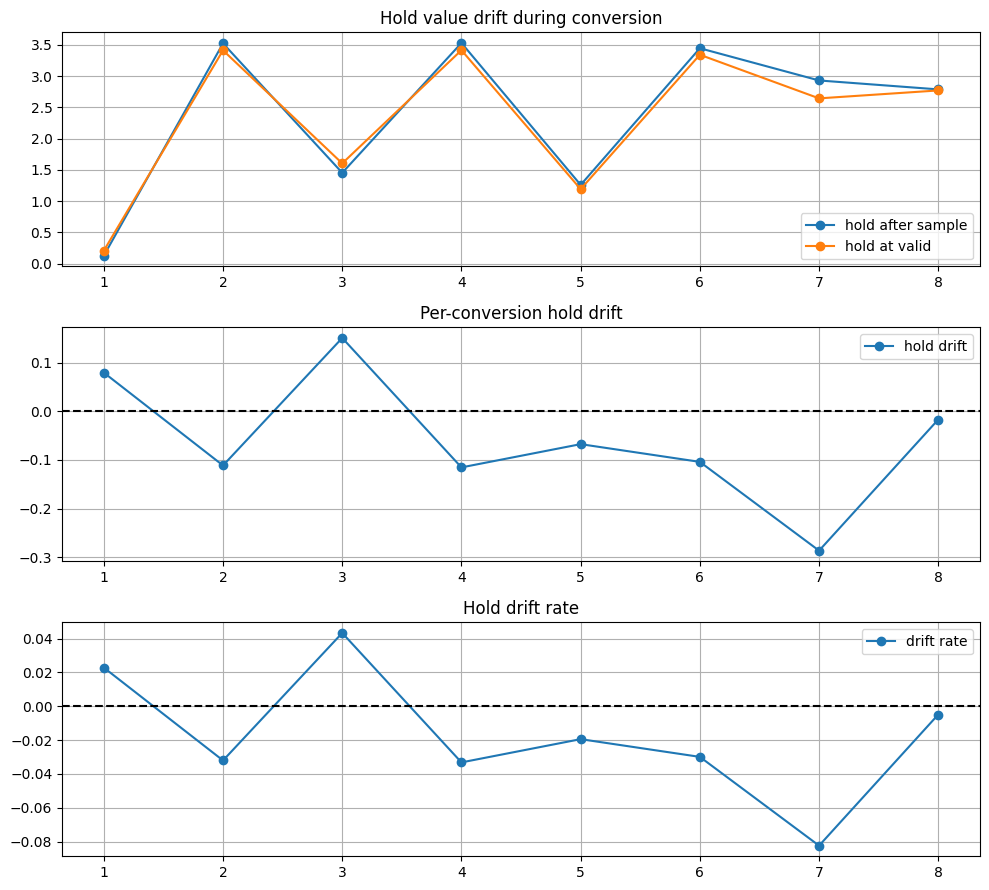

In [329]:
fig, ax = plt.subplots(3, 1, figsize=(10, 9))

ax[0].plot(sar_hold_df["sample_id"], sar_hold_df["v_hold_after_sample"], marker="o", label="hold after sample")
ax[0].plot(sar_hold_df["sample_id"], sar_hold_df["v_hold_at_valid"], marker="o", label="hold at valid")
ax[0].grid(True)
ax[0].legend()
ax[0].set_title("Hold value drift during conversion")

ax[1].plot(sar_hold_df["sample_id"], sar_hold_df["hold_drift"], marker="o", label="hold drift")
ax[1].axhline(0, linestyle="--", color="black")
ax[1].grid(True)
ax[1].legend()
ax[1].set_title("Per-conversion hold drift")

ax[2].plot(sar_hold_df["sample_id"], sar_hold_df["hold_drift_rate_V_per_ms"], marker="o", label="drift rate")
ax[2].axhline(0, linestyle="--", color="black")
ax[2].grid(True)
ax[2].legend()
ax[2].set_title("Hold drift rate")

plt.tight_layout()
plt.show()

Using file: /kaggle/input/datasets/chaahatsingal/sarvadc/sarvadc.txt
Columns: ['time', 'V(adc_valid_sar)', 'V(dac_out_sar)', 'V(samp_clk)', 'V(v_samp_hold)', 'V(v_sar_src)', 'V(vsar_code_v)']

Resolved signals:
time   -> FOUND
valid  -> FOUND
sclk   -> FOUND
vsrc   -> FOUND
vsh    -> FOUND
vdac   -> FOUND
vcode  -> FOUND

num sample edges: 8
num valid edges : 8
paired conversions: 8

sar_real_samples:


,sample_id,t_sample,t_valid,v_src_at_sample,v_hold_after_sample,v_dac_at_valid,code_at_valid,v_hold_at_valid,v_src_at_valid,sample_hold_error,conversion_residual,end_to_end_error,sample_to_valid_delay_us
0,1,0.000320,0.003800,0.119240,0.126966,0.214844,11.0,0.215083,3.263286,0.007725,-0.000239,0.095603,3480.0
1,2,0.005320,0.008800,3.524339,3.525084,3.515625,180.0,3.529233,1.163301,0.000745,-0.013608,-0.008714,3480.0
2,3,0.010320,0.013800,1.413860,1.465090,1.640625,84.0,1.658892,3.484058,0.051230,-0.018267,0.226765,3480.0
3,4,0.015321,0.018800,3.531456,3.531626,3.515625,180.0,3.531739,2.211571,0.000170,-0.016114,-0.015831,3480.0
4,5,0.020320,0.023801,1.263672,1.260282,1.230469,63.0,1.233067,3.075398,-0.003390,-0.002598,-0.033203,3480.0
5,6,0.025320,0.028800,3.445783,3.447065,3.437500,176.0,3.456114,3.541271,0.001282,-0.018614,-0.008283,3480.0
6,7,0.030321,0.033800,2.959290,2.931977,2.734375,140.0,2.734757,1.059216,-0.027313,-0.000382,-0.224915,3480.0
7,8,0.035320,0.038800,2.777044,2.788012,2.851562,146.0,2.865622,3.522560,0.010968,-0.014060,0.074518,3480.0



sar_real_metrics_df:


,num_real_conversions,sample_hold_rmse,sample_hold_maxabs,conversion_residual_rmse,conversion_residual_maxabs,end_to_end_rmse,end_to_end_maxabs,spearman_src_vs_code,spearman_src_vs_dac,direction_consistency_src_to_code,direction_consistency_src_to_dac,mean_sample_to_valid_delay_us
0,8,0.021107,0.05123,0.012892,0.018614,0.121552,0.226765,0.970077,0.970077,0.857143,0.857143,3480.0



sar_hold_metrics_df:


,hold_drift_rmse,hold_drift_maxabs,hold_drift_mean,hold_drift_rate_rmse_V_per_ms,worst_case_conversion
0,0.106702,0.19722,0.018551,0.030662,7



sar_real_report_df:


,claim,metric,value
0,SAR samples real calibrated voltage path,sample_hold_rmse,0.021107
1,SAR DAC converges to held voltage,conversion_residual_rmse,0.012892
2,End-to-end real source tracking,end_to_end_rmse,0.121552
3,Digital code follows real source,spearman_src_vs_code,0.970077
4,Sample-to-valid conversion latency,mean_sample_to_valid_delay_us,3480.000000


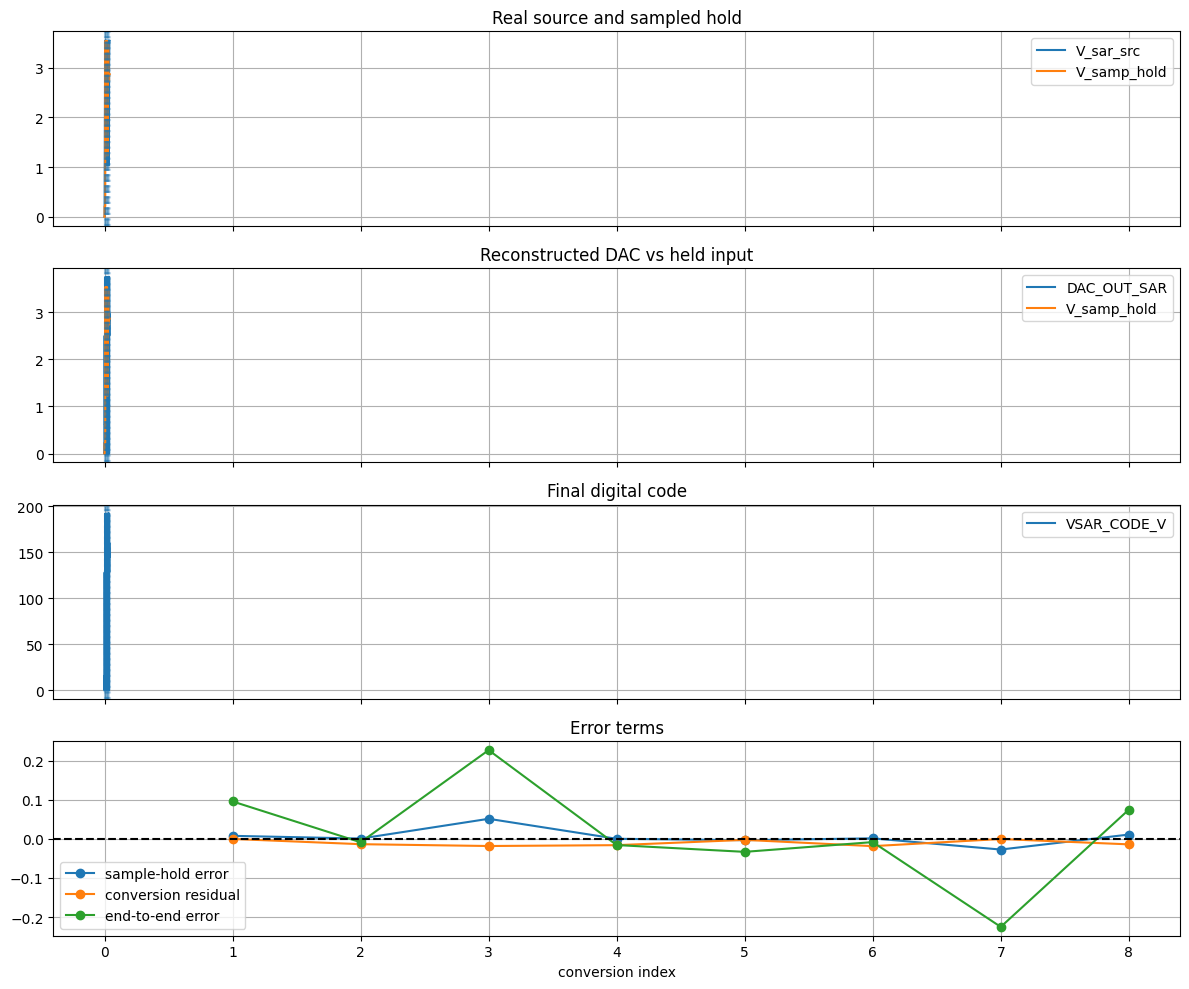

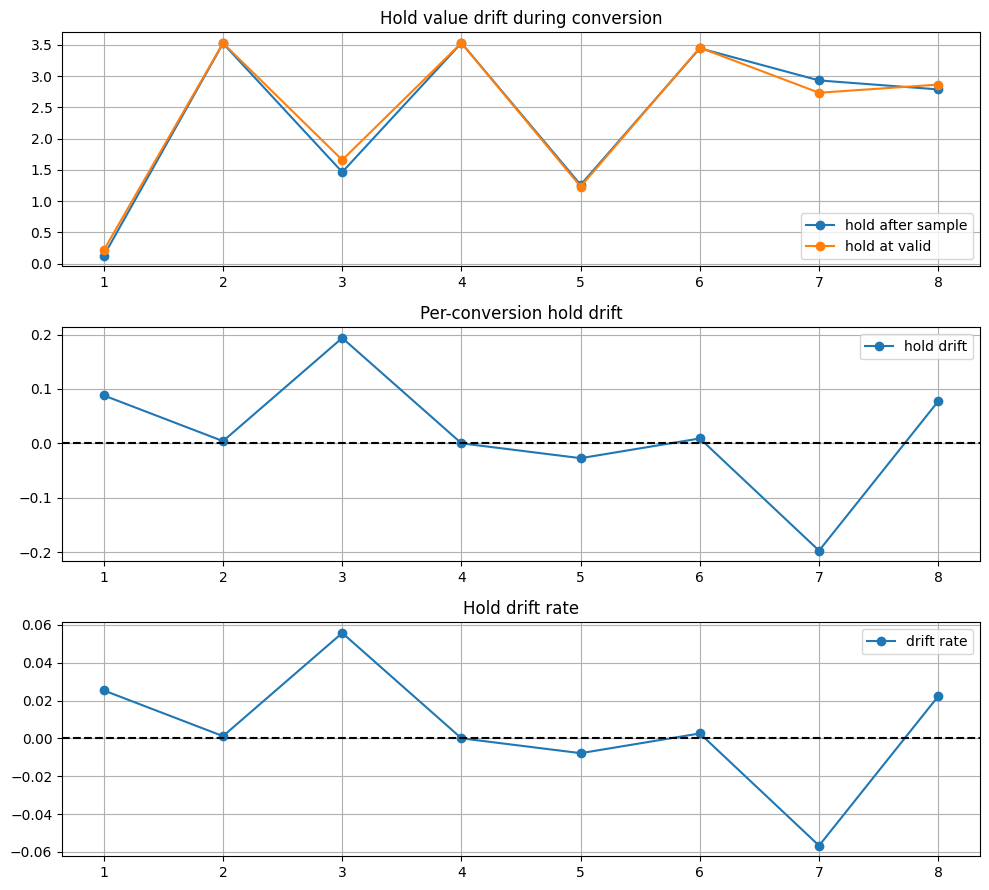


Saved CSV files in: /kaggle/working/sarvadc_analysis
['sar_real_metrics.csv', 'sar_hold_metrics.csv', 'sar_real_samples.csv', 'sar_real_report.csv']


In [330]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1) Locate and load sarvadc.txt
# =========================================================
candidate_paths = [
    "/kaggle/input/sarvadc/sarvadc.txt",
    "/kaggle/input/sarvadc/sarvadc/sarvadc.txt",
    "/kaggle/input/**/sarvadc.txt",
]

sar_path = None
for p in candidate_paths[:2]:
    if os.path.exists(p):
        sar_path = p
        break

if sar_path is None:
    hits = glob.glob(candidate_paths[2], recursive=True)
    if hits:
        sar_path = hits[0]

if sar_path is None:
    raise FileNotFoundError("Could not find sarvadc.txt in /kaggle/input")

print("Using file:", sar_path)

sar_df = pd.read_csv(sar_path, sep=r"\s+", engine="python")
print("Columns:", list(sar_df.columns))


# =========================================================
# 2) Helpers
# =========================================================
def find_col(df, candidates):
    norm_map = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        c0 = cand.lower().strip()
        if c0 in norm_map:
            return norm_map[c0]
        for k, v in norm_map.items():
            if c0 == k or c0 in k:
                return v
    return None

def series_or_none(df, candidates):
    c = find_col(df, candidates)
    if c is None:
        return None
    return pd.to_numeric(df[c], errors="coerce")

def rmse(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.sqrt(np.mean(np.square(x))))

def max_abs(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.max(np.abs(x)))

def rising_edge_times(t, y, thr=0.5):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.where((y[:-1] < thr) & (y[1:] >= thr))[0]
    out = []
    for i in idx:
        t0, t1 = t[i], t[i + 1]
        y0, y1 = y[i], y[i + 1]
        if y1 == y0:
            out.append(t1)
        else:
            out.append(float(t0 + (thr - y0) * (t1 - t0) / (y1 - y0)))
    return np.array(out, dtype=float)

def nearest_value(t, y, tq):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(t) == 0:
        return np.nan
    i = np.argmin(np.abs(t - tq))
    return float(y[i])

def window_median(t, y, tq, half_width):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    m = (t >= tq - half_width) & (t <= tq + half_width)
    if m.sum() == 0:
        return np.nan
    return float(np.median(y[m]))

def sign_consistency_ratio(x, y):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    if len(x) < 3 or len(y) < 3:
        return np.nan
    dx = np.sign(np.diff(x))
    dy = np.sign(np.diff(y))
    mask = (dx != 0) & (dy != 0)
    if mask.sum() == 0:
        return np.nan
    return float((dx[mask] == dy[mask]).mean())


# =========================================================
# 3) Resolve the real SAR signals
# =========================================================
t      = series_or_none(sar_df, ["time"])
vvalid = series_or_none(sar_df, ["V(adc_valid_sar)", "adc_valid_sar"])
sclk   = series_or_none(sar_df, ["V(samp_clk)", "samp_clk"])
vsrc   = series_or_none(sar_df, ["V(v_sar_src)", "v_sar_src"])
vsh    = series_or_none(sar_df, ["V(v_samp_hold)", "v_samp_hold"])
vdac   = series_or_none(sar_df, ["V(dac_out_sar)", "dac_out_sar"])
vcode  = series_or_none(sar_df, ["V(vsar_code_v)", "vsar_code_v"])

print("\nResolved signals:")
print("time   ->", "FOUND" if t is not None else "MISSING")
print("valid  ->", "FOUND" if vvalid is not None else "MISSING")
print("sclk   ->", "FOUND" if sclk is not None else "MISSING")
print("vsrc   ->", "FOUND" if vsrc is not None else "MISSING")
print("vsh    ->", "FOUND" if vsh is not None else "MISSING")
print("vdac   ->", "FOUND" if vdac is not None else "MISSING")
print("vcode  ->", "FOUND" if vcode is not None else "MISSING")

required = [t, vvalid, sclk, vsrc, vsh, vdac, vcode]
if any(x is None for x in required):
    raise ValueError("One or more required SAR signals are missing. Check exported node names.")


# =========================================================
# 4) Correct real integrated extraction
#    sample instant = rising edge of SAMP_CLK
#    final read     = rising edge of ADC_VALID_SAR
# =========================================================
t_arr      = t.to_numpy()
vvalid_arr = vvalid.to_numpy()
sclk_arr   = sclk.to_numpy()
vsrc_arr   = vsrc.to_numpy()
vsh_arr    = vsh.to_numpy()
vdac_arr   = vdac.to_numpy()
vcode_arr  = vcode.to_numpy()

t_sample = rising_edge_times(t_arr, sclk_arr, thr=0.5)
t_valid  = rising_edge_times(t_arr, vvalid_arr, thr=0.5)

print("\nnum sample edges:", len(t_sample))
print("num valid edges :", len(t_valid))

pairs = []
j = 0
for ts in t_sample:
    while j < len(t_valid) and t_valid[j] <= ts:
        j += 1
    if j < len(t_valid):
        pairs.append((float(ts), float(t_valid[j])))
        j += 1

print("paired conversions:", len(pairs))

rows = []
for k, (ts, tv) in enumerate(pairs, start=1):
    rows.append({
        "sample_id": k,
        "t_sample": ts,
        "t_valid": tv,
        "v_src_at_sample": nearest_value(t_arr, vsrc_arr, ts),
        "v_hold_after_sample": window_median(t_arr, vsh_arr, ts + 20e-6, 20e-6),
        "v_dac_at_valid": window_median(t_arr, vdac_arr, tv, 20e-6),
        "code_at_valid": window_median(t_arr, vcode_arr, tv, 20e-6),
        "v_hold_at_valid": window_median(t_arr, vsh_arr, tv, 20e-6),
        "v_src_at_valid": window_median(t_arr, vsrc_arr, tv, 20e-6),
    })

sar_real_samples = pd.DataFrame(rows)

if len(sar_real_samples):
    sar_real_samples["sample_hold_error"] = (
        sar_real_samples["v_hold_after_sample"] - sar_real_samples["v_src_at_sample"]
    )
    sar_real_samples["conversion_residual"] = (
        sar_real_samples["v_dac_at_valid"] - sar_real_samples["v_hold_at_valid"]
    )
    sar_real_samples["end_to_end_error"] = (
        sar_real_samples["v_dac_at_valid"] - sar_real_samples["v_src_at_sample"]
    )
    sar_real_samples["sample_to_valid_delay_us"] = (
        (sar_real_samples["t_valid"] - sar_real_samples["t_sample"]) * 1e6
    )

print("\nsar_real_samples:")
display(sar_real_samples)


# =========================================================
# 5) Real integrated SAR metrics
# =========================================================
sar_real_metrics_df = pd.DataFrame([{
    "num_real_conversions": len(sar_real_samples),
    "sample_hold_rmse": rmse(sar_real_samples["sample_hold_error"]) if len(sar_real_samples) else np.nan,
    "sample_hold_maxabs": max_abs(sar_real_samples["sample_hold_error"]) if len(sar_real_samples) else np.nan,
    "conversion_residual_rmse": rmse(sar_real_samples["conversion_residual"]) if len(sar_real_samples) else np.nan,
    "conversion_residual_maxabs": max_abs(sar_real_samples["conversion_residual"]) if len(sar_real_samples) else np.nan,
    "end_to_end_rmse": rmse(sar_real_samples["end_to_end_error"]) if len(sar_real_samples) else np.nan,
    "end_to_end_maxabs": max_abs(sar_real_samples["end_to_end_error"]) if len(sar_real_samples) else np.nan,
    "spearman_src_vs_code": sar_real_samples["v_src_at_sample"].corr(
        sar_real_samples["code_at_valid"], method="spearman"
    ) if len(sar_real_samples) else np.nan,
    "spearman_src_vs_dac": sar_real_samples["v_src_at_sample"].corr(
        sar_real_samples["v_dac_at_valid"], method="spearman"
    ) if len(sar_real_samples) else np.nan,
    "direction_consistency_src_to_code": sign_consistency_ratio(
        sar_real_samples["v_src_at_sample"], sar_real_samples["code_at_valid"]
    ) if len(sar_real_samples) else np.nan,
    "direction_consistency_src_to_dac": sign_consistency_ratio(
        sar_real_samples["v_src_at_sample"], sar_real_samples["v_dac_at_valid"]
    ) if len(sar_real_samples) else np.nan,
    "mean_sample_to_valid_delay_us": sar_real_samples["sample_to_valid_delay_us"].mean() if len(sar_real_samples) else np.nan
}])

print("\nsar_real_metrics_df:")
display(sar_real_metrics_df)


# =========================================================
# 6) Hold-drift analysis
# =========================================================
sar_hold_df = sar_real_samples.copy()

sar_hold_df["hold_drift"] = sar_hold_df["v_hold_at_valid"] - sar_hold_df["v_hold_after_sample"]
sar_hold_df["hold_drift_abs"] = sar_hold_df["hold_drift"].abs()
sar_hold_df["hold_drift_rate_V_per_ms"] = (
    sar_hold_df["hold_drift"] / (sar_hold_df["sample_to_valid_delay_us"] / 1000.0)
)

sar_hold_metrics_df = pd.DataFrame([{
    "hold_drift_rmse": rmse(sar_hold_df["hold_drift"]),
    "hold_drift_maxabs": max_abs(sar_hold_df["hold_drift"]),
    "hold_drift_mean": sar_hold_df["hold_drift"].mean(),
    "hold_drift_rate_rmse_V_per_ms": rmse(sar_hold_df["hold_drift_rate_V_per_ms"]),
    "worst_case_conversion": int(sar_hold_df["hold_drift_abs"].idxmax()) + 1 if len(sar_hold_df) else np.nan
}])

print("\nsar_hold_metrics_df:")
display(sar_hold_metrics_df)


# =========================================================
# 7) Compact report table
# =========================================================
sar_real_report_df = pd.DataFrame([{
    "claim": "SAR samples real calibrated voltage path",
    "metric": "sample_hold_rmse",
    "value": sar_real_metrics_df["sample_hold_rmse"].iloc[0]
}, {
    "claim": "SAR DAC converges to held voltage",
    "metric": "conversion_residual_rmse",
    "value": sar_real_metrics_df["conversion_residual_rmse"].iloc[0]
}, {
    "claim": "End-to-end real source tracking",
    "metric": "end_to_end_rmse",
    "value": sar_real_metrics_df["end_to_end_rmse"].iloc[0]
}, {
    "claim": "Digital code follows real source",
    "metric": "spearman_src_vs_code",
    "value": sar_real_metrics_df["spearman_src_vs_code"].iloc[0]
}, {
    "claim": "Sample-to-valid conversion latency",
    "metric": "mean_sample_to_valid_delay_us",
    "value": sar_real_metrics_df["mean_sample_to_valid_delay_us"].iloc[0]
}])

print("\nsar_real_report_df:")
display(sar_real_report_df)


# =========================================================
# 8) Plots
# =========================================================
# Full-waveform plots
fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

ax[0].plot(t_arr, vsrc_arr, label="V_sar_src")
ax[0].plot(t_arr, vsh_arr, label="V_samp_hold")
for ts in t_sample:
    ax[0].axvline(ts, linestyle="--", alpha=0.25)
for tv in t_valid:
    ax[0].axvline(tv, linestyle=":", alpha=0.25)
ax[0].set_title("Real source and sampled hold")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(t_arr, vdac_arr, label="DAC_OUT_SAR")
ax[1].plot(t_arr, vsh_arr, label="V_samp_hold")
for ts in t_sample:
    ax[1].axvline(ts, linestyle="--", alpha=0.25)
for tv in t_valid:
    ax[1].axvline(tv, linestyle=":", alpha=0.25)
ax[1].set_title("Reconstructed DAC vs held input")
ax[1].grid(True)
ax[1].legend()

ax[2].plot(t_arr, vcode_arr, label="VSAR_CODE_V")
for ts in t_sample:
    ax[2].axvline(ts, linestyle="--", alpha=0.25)
for tv in t_valid:
    ax[2].axvline(tv, linestyle=":", alpha=0.25)
ax[2].set_title("Final digital code")
ax[2].grid(True)
ax[2].legend()

ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["sample_hold_error"], marker="o", label="sample-hold error")
ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["conversion_residual"], marker="o", label="conversion residual")
ax[3].plot(sar_real_samples["sample_id"], sar_real_samples["end_to_end_error"], marker="o", label="end-to-end error")
ax[3].axhline(0, linestyle="--", color="black")
ax[3].set_title("Error terms")
ax[3].set_xlabel("conversion index")
ax[3].grid(True)
ax[3].legend()

plt.tight_layout()
plt.show()

# Hold-drift specific plots
fig, ax = plt.subplots(3, 1, figsize=(10, 9))

ax[0].plot(sar_hold_df["sample_id"], sar_hold_df["v_hold_after_sample"], marker="o", label="hold after sample")
ax[0].plot(sar_hold_df["sample_id"], sar_hold_df["v_hold_at_valid"], marker="o", label="hold at valid")
ax[0].set_title("Hold value drift during conversion")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(sar_hold_df["sample_id"], sar_hold_df["hold_drift"], marker="o", label="hold drift")
ax[1].axhline(0, linestyle="--", color="black")
ax[1].set_title("Per-conversion hold drift")
ax[1].grid(True)
ax[1].legend()

ax[2].plot(sar_hold_df["sample_id"], sar_hold_df["hold_drift_rate_V_per_ms"], marker="o", label="drift rate")
ax[2].axhline(0, linestyle="--", color="black")
ax[2].set_title("Hold drift rate")
ax[2].grid(True)
ax[2].legend()

plt.tight_layout()
plt.show()


# =========================================================
# 9) Save tables and plots
# =========================================================
outdir = "/kaggle/working/sarvadc_analysis"
os.makedirs(outdir, exist_ok=True)

sar_real_samples.to_csv(f"{outdir}/sar_real_samples.csv", index=False)
sar_real_metrics_df.to_csv(f"{outdir}/sar_real_metrics.csv", index=False)
sar_hold_metrics_df.to_csv(f"{outdir}/sar_hold_metrics.csv", index=False)
sar_real_report_df.to_csv(f"{outdir}/sar_real_report.csv", index=False)

print("\nSaved CSV files in:", outdir)
print(os.listdir(outdir))

Using file: /kaggle/input/datasets/chaahatsingal/ev-battery-project-data/calibration_bench.txt
Columns: ['time', 'V(cal_valid)', 'V(cal_win)', 'V(i_cal_corr)', 'V(i_cal_hold)', 'V(i_cal_out)', 'V(i_uncal)', 'V(meas_mode)', 'V(ref_mode)', 'V(v_cal_corr)', 'V(v_cal_err_raw)', 'V(v_cal_hold)', 'V(v_cal_out)', 'V(v_mux_in)', 'V(v_uncal)']

Resolved signals:
time           -> FOUND
ref_mode       -> FOUND
meas_mode      -> FOUND
v_mux_in       -> FOUND
v_cal_out      -> FOUND
v_cal_hold     -> FOUND
v_cal_corr     -> FOUND
v_cal_err_raw  -> FOUND
vcal_valid     -> MISSING
ref_cal_done   -> MISSING
curr_cal_done  -> MISSING

ref windows starts: [0.00605 0.01805]
ref windows stops : [0.01015]
meas windows starts: [4.99999998e-12 1.01500000e-02]
meas windows stops : [0.00605 0.01805]

num ref windows : 1
num meas windows: 2

cal_cycle_df:


/tmp/ipykernel_55/2271145729.py:146: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.abs(y[:n]), t[:n]))


,cycle_id,ref_start_s,ref_stop_s,ref_window_s,meas_start_s,meas_stop_s,meas_window_s,raw_err_rms_ref,raw_err_maxabs_ref,corr_final_ref,corrected_err_rms_meas,corrected_err_maxabs_meas,corrected_abs_error_area,settle_1pct_us,settle_2pct_us,tracking_error_slope,hold_drift_meas,rms_improvement_percent,maxabs_improvement_percent
0,1,0.00605,0.01015,0.0041,5.000000e-12,0.00605,0.00605,0.321155,2.569839,0.010159,0.758247,1.303153,0.003506,0.000005,0.000005,135.715351,2.035016e-08,-136.099937,49.290481



cal_summary_df:


/tmp/ipykernel_55/2271145729.py:146: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.abs(y[:n]), t[:n]))


,num_ref_windows,num_meas_windows,raw_err_rms,raw_err_maxabs,settled_tracking_rmse,settled_tracking_maxabs,tracking_error_area,tracking_error_slope,rms_improvement_percent,maxabs_improvement_percent,mean_settle_1pct_us,mean_settle_2pct_us,hold_drift_rms,hold_drift_maxabs,vcal_valid_seen,ref_done_seen,curr_done_seen
0,1,2,0.321155,2.569839,0.798958,2.506221,0.006145,32.328191,-148.776366,2.475564,0.000005,0.000005,2.035016e-08,2.035016e-08,False,False,False



cal_report_df:


,claim,metric,value
0,Calibration reduces raw analog error,rms_improvement_percent,-148.776366
1,Corrected output tracks measurement path,settled_tracking_rmse,0.798958
2,Calibration settles after handoff,mean_settle_2pct_us,0.000005
3,Hold memory remains stable in measurement mode,hold_drift_rms,0.0
4,Calibration-valid logic observed,vcal_valid_seen,False


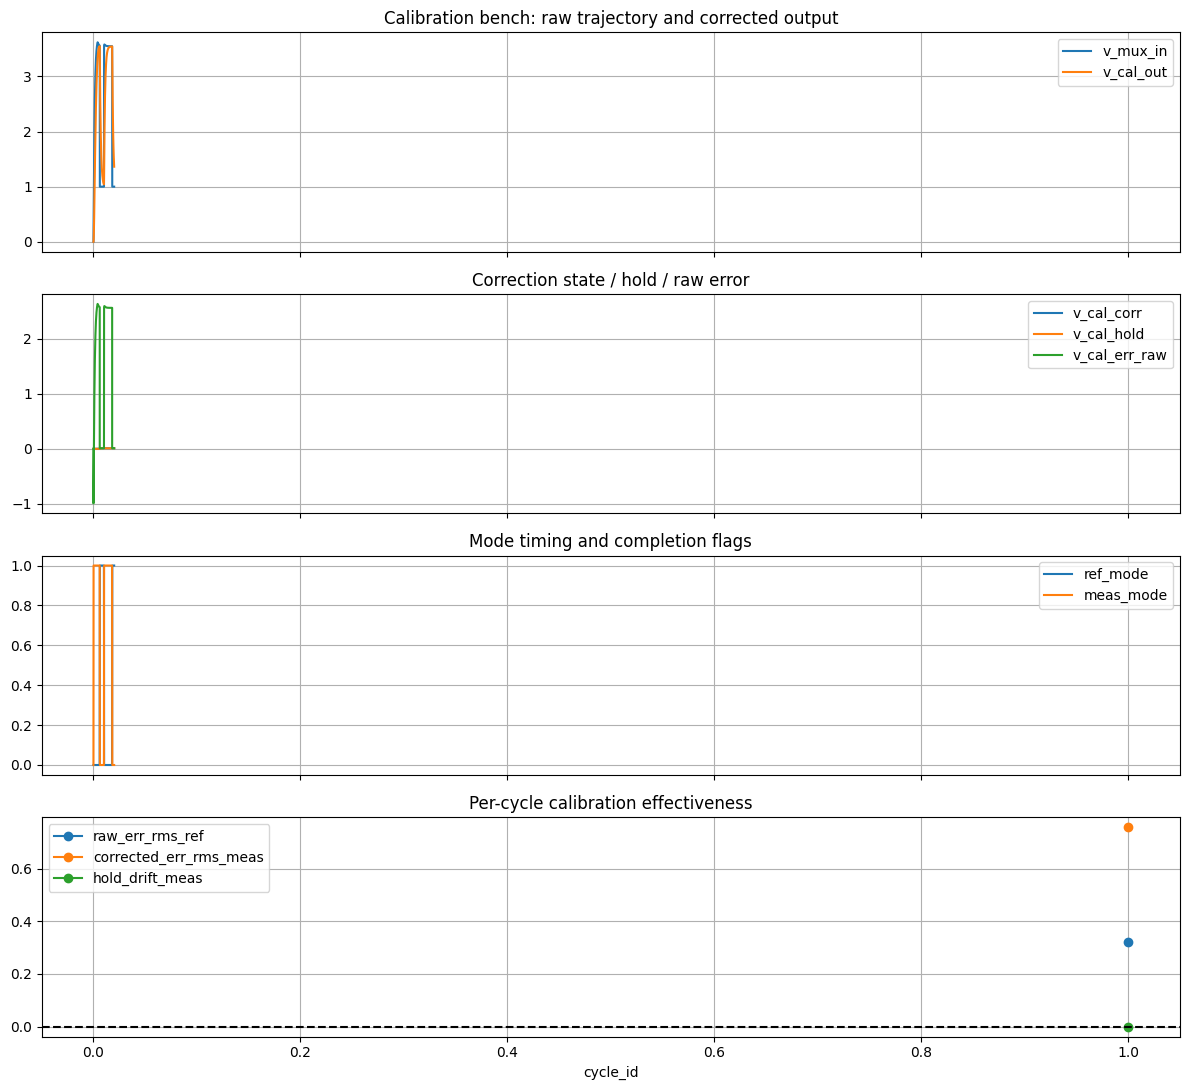

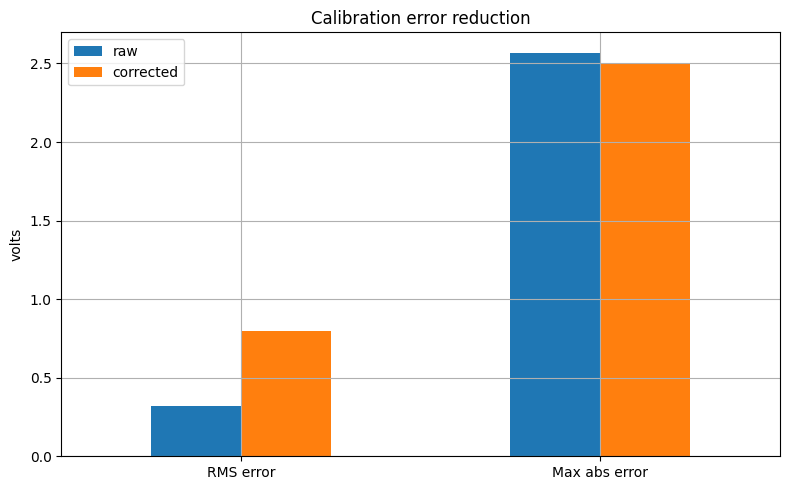


Saved files in: /kaggle/working/calibration_analysis
['cal_report_df.csv', 'cal_cycle_df.csv', 'cal_summary_df.csv']


In [332]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1) Locate and load calibration_bench.txt
# =========================================================
candidate_paths = [
    "/kaggle/input/ev-battery-project-data/calibration_bench.txt",
    "/kaggle/input/ev_battery_project_data/calibration_bench.txt",
    "/kaggle/input/**/calibration_bench.txt",
]

cal_path = None
for p in candidate_paths[:2]:
    if os.path.exists(p):
        cal_path = p
        break

if cal_path is None:
    hits = glob.glob(candidate_paths[2], recursive=True)
    if hits:
        cal_path = hits[0]

if cal_path is None:
    raise FileNotFoundError("Could not find calibration_bench.txt in /kaggle/input")

print("Using file:", cal_path)

cal_df = pd.read_csv(cal_path, sep=r"\s+", engine="python")
print("Columns:", list(cal_df.columns))


# =========================================================
# 2) Helpers
# =========================================================
def find_col(df, candidates):
    norm_map = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        c0 = cand.lower().strip()
        if c0 in norm_map:
            return norm_map[c0]
        for k, v in norm_map.items():
            if c0 == k or c0 in k:
                return v
    return None

def series_or_none(df, candidates):
    c = find_col(df, candidates)
    if c is None:
        return None
    return pd.to_numeric(df[c], errors="coerce")

def rmse(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.sqrt(np.mean(np.square(x))))

def max_abs(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.max(np.abs(x)))

def pct_reduction(before, after):
    if pd.isna(before) or pd.isna(after) or before == 0:
        return np.nan
    return float(100.0 * (before - after) / abs(before))

def rising_edge_times(t, y, thr=0.5):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.where((y[:-1] < thr) & (y[1:] >= thr))[0]
    out = []
    for i in idx:
        t0, t1 = t[i], t[i+1]
        y0, y1 = y[i], y[i+1]
        if y1 == y0:
            out.append(t1)
        else:
            out.append(float(t0 + (thr - y0) * (t1 - t0) / (y1 - y0)))
    return np.array(out, dtype=float)

def falling_edge_times(t, y, thr=0.5):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.where((y[:-1] >= thr) & (y[1:] < thr))[0]
    out = []
    for i in idx:
        t0, t1 = t[i], t[i+1]
        y0, y1 = y[i], y[i+1]
        if y1 == y0:
            out.append(t1)
        else:
            out.append(float(t0 + (thr - y0) * (t1 - t0) / (y1 - y0)))
    return np.array(out, dtype=float)

def nearest_value(t, y, tq):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(t) == 0:
        return np.nan
    i = np.argmin(np.abs(t - tq))
    return float(y[i])

def window_series(t, y, t0, t1):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    m = (t >= t0) & (t <= t1)
    return pd.Series(y[m]), pd.Series(t[m])

def linear_slope(t, y):
    t = pd.Series(t).dropna().astype(float)
    y = pd.Series(y).dropna().astype(float)
    n = min(len(t), len(y))
    if n < 2:
        return np.nan
    t = t.iloc[:n].to_numpy()
    y = y.iloc[:n].to_numpy()
    A = np.vstack([t, np.ones_like(t)]).T
    m, _ = np.linalg.lstsq(A, y, rcond=None)[0]
    return float(m)

def first_time_within_band(t, err_abs, band, start_t):
    t = np.asarray(t, dtype=float)
    e = np.asarray(err_abs, dtype=float)
    m = t >= start_t
    t2 = t[m]
    e2 = e[m]
    if len(t2) == 0:
        return np.nan
    idx = np.where(e2 <= band)[0]
    if len(idx) == 0:
        return np.nan
    return float(t2[idx[0]])

def integrate_abs(t, y):
    t = pd.Series(t).dropna().astype(float).to_numpy()
    y = pd.Series(y).dropna().astype(float).to_numpy()
    n = min(len(t), len(y))
    if n < 2:
        return np.nan
    return float(np.trapz(np.abs(y[:n]), t[:n]))


# =========================================================
# 3) Resolve signals
# =========================================================
t            = series_or_none(cal_df, ["time"])
ref_mode     = series_or_none(cal_df, ["V(ref_mode)", "ref_mode"])
meas_mode    = series_or_none(cal_df, ["V(meas_mode)", "meas_mode"])
v_mux_in     = series_or_none(cal_df, ["V(v_mux_in)", "v_mux_in"])
v_cal_out    = series_or_none(cal_df, ["V(v_cal_out)", "v_cal_out"])
v_cal_hold   = series_or_none(cal_df, ["V(v_cal_hold)", "v_cal_hold"])
v_cal_corr   = series_or_none(cal_df, ["V(v_cal_corr)", "v_cal_corr"])
v_cal_errraw = series_or_none(cal_df, ["V(v_cal_err_raw)", "v_cal_err_raw"])
vcal_valid   = series_or_none(cal_df, ["V(vcal_valid)", "vcal_valid"])
ref_done     = series_or_none(cal_df, ["V(ref_cal_done)", "ref_cal_done"])
curr_done    = series_or_none(cal_df, ["V(curr_cal_done)", "curr_cal_done"])

print("\nResolved signals:")
for name, sig in [
    ("time", t),
    ("ref_mode", ref_mode),
    ("meas_mode", meas_mode),
    ("v_mux_in", v_mux_in),
    ("v_cal_out", v_cal_out),
    ("v_cal_hold", v_cal_hold),
    ("v_cal_corr", v_cal_corr),
    ("v_cal_err_raw", v_cal_errraw),
    ("vcal_valid", vcal_valid),
    ("ref_cal_done", ref_done),
    ("curr_cal_done", curr_done),
]:
    print(f"{name:14s} ->", "FOUND" if sig is not None else "MISSING")

required = [t, ref_mode, meas_mode, v_mux_in, v_cal_out]
if any(x is None for x in required):
    raise ValueError("Required calibration signals missing.")


# =========================================================
# 4) Detect calibration / measurement windows
# =========================================================
t_arr         = t.to_numpy()
ref_arr       = ref_mode.to_numpy()
meas_arr      = meas_mode.to_numpy()
mux_arr       = v_mux_in.to_numpy()
cout_arr      = v_cal_out.to_numpy()
hold_arr      = v_cal_hold.to_numpy() if v_cal_hold is not None else None
corr_arr      = v_cal_corr.to_numpy() if v_cal_corr is not None else None
errraw_arr    = v_cal_errraw.to_numpy() if v_cal_errraw is not None else None
vvalid_arr    = vcal_valid.to_numpy() if vcal_valid is not None else None
refdone_arr   = ref_done.to_numpy() if ref_done is not None else None
currdone_arr  = curr_done.to_numpy() if curr_done is not None else None

ref_rise = rising_edge_times(t_arr, ref_arr, 0.5)
ref_fall = falling_edge_times(t_arr, ref_arr, 0.5)
meas_rise = rising_edge_times(t_arr, meas_arr, 0.5)
meas_fall = falling_edge_times(t_arr, meas_arr, 0.5)

print("\nref windows starts:", ref_rise)
print("ref windows stops :", ref_fall)
print("meas windows starts:", meas_rise)
print("meas windows stops :", meas_fall)

# Pair reference windows
ref_windows = []
for s in ref_rise:
    e = next((x for x in ref_fall if x > s), np.nan)
    if pd.notna(e):
        ref_windows.append((float(s), float(e)))

# Pair measurement windows
meas_windows = []
for s in meas_rise:
    e = next((x for x in meas_fall if x > s), np.nan)
    if pd.notna(e):
        meas_windows.append((float(s), float(e)))

print("\nnum ref windows :", len(ref_windows))
print("num meas windows:", len(meas_windows))


# =========================================================
# 5) Build cycle-wise calibration analysis
# =========================================================
cycle_rows = []

num_cycles = min(len(ref_windows), len(meas_windows)) if len(ref_windows) and len(meas_windows) else max(len(ref_windows), len(meas_windows))
for k in range(num_cycles):
    ref_s, ref_e = ref_windows[k] if k < len(ref_windows) else (np.nan, np.nan)
    meas_s, meas_e = meas_windows[k] if k < len(meas_windows) else (np.nan, np.nan)

    # raw error in ref window
    if pd.notna(ref_s) and pd.notna(ref_e):
        raw_seg, raw_t = window_series(t_arr, errraw_arr, ref_s, ref_e) if errraw_arr is not None else (pd.Series(dtype=float), pd.Series(dtype=float))
        ref_len = ref_e - ref_s
        ref_raw_rms = rmse(raw_seg) if len(raw_seg) else np.nan
        ref_raw_maxabs = max_abs(raw_seg) if len(raw_seg) else np.nan
        ref_corr_final = nearest_value(t_arr, corr_arr, ref_e - 1e-6) if corr_arr is not None else np.nan
    else:
        ref_len = np.nan
        ref_raw_rms = np.nan
        ref_raw_maxabs = np.nan
        ref_corr_final = np.nan

    # corrected tracking in measurement window
    if pd.notna(meas_s) and pd.notna(meas_e):
        m = (t_arr >= meas_s) & (t_arr <= meas_e)
        e_corr = cout_arr[m] - mux_arr[m]
        tm = t_arr[m]
        corrected_rms = rmse(e_corr)
        corrected_maxabs = max_abs(e_corr)
        error_area = integrate_abs(tm, e_corr)

        # settling to band after entering measurement mode
        e_abs = np.abs(e_corr)
        band_1pct = 0.01 * max(np.max(np.abs(mux_arr[m])), 1e-9)
        band_2pct = 0.02 * max(np.max(np.abs(mux_arr[m])), 1e-9)

        t_settle_1pct = first_time_within_band(tm, e_abs, band_1pct, meas_s)
        t_settle_2pct = first_time_within_band(tm, e_abs, band_2pct, meas_s)

        settle_1pct_us = (t_settle_1pct - meas_s) * 1e6 if pd.notna(t_settle_1pct) else np.nan
        settle_2pct_us = (t_settle_2pct - meas_s) * 1e6 if pd.notna(t_settle_2pct) else np.nan

        tracking_slope = linear_slope(tm, e_corr)
        hold_drift = (nearest_value(t_arr, hold_arr, meas_e - 1e-6) - nearest_value(t_arr, hold_arr, meas_s + 1e-6)) if hold_arr is not None else np.nan

        # compare raw reference error magnitude vs corrected measurement error magnitude
        rms_improvement = pct_reduction(ref_raw_rms, corrected_rms) if pd.notna(ref_raw_rms) else np.nan
        maxabs_improvement = pct_reduction(ref_raw_maxabs, corrected_maxabs) if pd.notna(ref_raw_maxabs) else np.nan
    else:
        corrected_rms = np.nan
        corrected_maxabs = np.nan
        error_area = np.nan
        settle_1pct_us = np.nan
        settle_2pct_us = np.nan
        tracking_slope = np.nan
        hold_drift = np.nan
        rms_improvement = np.nan
        maxabs_improvement = np.nan

    cycle_rows.append({
        "cycle_id": k + 1,
        "ref_start_s": ref_s,
        "ref_stop_s": ref_e,
        "ref_window_s": ref_len,
        "meas_start_s": meas_s,
        "meas_stop_s": meas_e,
        "meas_window_s": (meas_e - meas_s) if pd.notna(meas_s) and pd.notna(meas_e) else np.nan,

        "raw_err_rms_ref": ref_raw_rms,
        "raw_err_maxabs_ref": ref_raw_maxabs,
        "corr_final_ref": ref_corr_final,

        "corrected_err_rms_meas": corrected_rms,
        "corrected_err_maxabs_meas": corrected_maxabs,
        "corrected_abs_error_area": error_area,

        "settle_1pct_us": settle_1pct_us,
        "settle_2pct_us": settle_2pct_us,
        "tracking_error_slope": tracking_slope,
        "hold_drift_meas": hold_drift,

        "rms_improvement_percent": rms_improvement,
        "maxabs_improvement_percent": maxabs_improvement,
    })

cal_cycle_df = pd.DataFrame(cycle_rows)
print("\ncal_cycle_df:")
display(cal_cycle_df)


# =========================================================
# 6) Overall summary
# =========================================================
# Raw error globally from reference windows
raw_vals = []
for s, e in ref_windows:
    if errraw_arr is not None:
        m = (t_arr >= s) & (t_arr <= e)
        raw_vals.extend(errraw_arr[m])

# Corrected tracking error globally from measurement windows
corr_vals = []
corr_t = []
for s, e in meas_windows:
    m = (t_arr >= s) & (t_arr <= e)
    corr_vals.extend(cout_arr[m] - mux_arr[m])
    corr_t.extend(t_arr[m])

raw_vals = pd.Series(raw_vals, dtype=float)
corr_vals = pd.Series(corr_vals, dtype=float)
corr_t = pd.Series(corr_t, dtype=float)

cal_summary_df = pd.DataFrame([{
    "num_ref_windows": len(ref_windows),
    "num_meas_windows": len(meas_windows),
    "raw_err_rms": rmse(raw_vals),
    "raw_err_maxabs": max_abs(raw_vals),
    "settled_tracking_rmse": rmse(corr_vals),
    "settled_tracking_maxabs": max_abs(corr_vals),
    "tracking_error_area": integrate_abs(corr_t, corr_vals),
    "tracking_error_slope": linear_slope(corr_t, corr_vals),
    "rms_improvement_percent": pct_reduction(rmse(raw_vals), rmse(corr_vals)),
    "maxabs_improvement_percent": pct_reduction(max_abs(raw_vals), max_abs(corr_vals)),
    "mean_settle_1pct_us": cal_cycle_df["settle_1pct_us"].mean(),
    "mean_settle_2pct_us": cal_cycle_df["settle_2pct_us"].mean(),
    "hold_drift_rms": rmse(cal_cycle_df["hold_drift_meas"]),
    "hold_drift_maxabs": max_abs(cal_cycle_df["hold_drift_meas"]),
    "vcal_valid_seen": bool((vvalid_arr > 0.5).any()) if vvalid_arr is not None else False,
    "ref_done_seen": bool((refdone_arr > 0.5).any()) if refdone_arr is not None else False,
    "curr_done_seen": bool((currdone_arr > 0.5).any()) if currdone_arr is not None else False,
}])

print("\ncal_summary_df:")
display(cal_summary_df)


# =========================================================
# 7) Report table
# =========================================================
cal_report_df = pd.DataFrame([{
    "claim": "Calibration reduces raw analog error",
    "metric": "rms_improvement_percent",
    "value": cal_summary_df["rms_improvement_percent"].iloc[0]
}, {
    "claim": "Corrected output tracks measurement path",
    "metric": "settled_tracking_rmse",
    "value": cal_summary_df["settled_tracking_rmse"].iloc[0]
}, {
    "claim": "Calibration settles after handoff",
    "metric": "mean_settle_2pct_us",
    "value": cal_summary_df["mean_settle_2pct_us"].iloc[0]
}, {
    "claim": "Hold memory remains stable in measurement mode",
    "metric": "hold_drift_rms",
    "value": cal_summary_df["hold_drift_rms"].iloc[0]
}, {
    "claim": "Calibration-valid logic observed",
    "metric": "vcal_valid_seen",
    "value": cal_summary_df["vcal_valid_seen"].iloc[0]
}])

print("\ncal_report_df:")
display(cal_report_df)


# =========================================================
# 8) Plots
# =========================================================
fig, ax = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

ax[0].plot(t_arr, mux_arr, label="v_mux_in")
ax[0].plot(t_arr, cout_arr, label="v_cal_out")
ax[0].set_title("Calibration bench: raw trajectory and corrected output")
ax[0].grid(True)
ax[0].legend()

if corr_arr is not None or hold_arr is not None or errraw_arr is not None:
    if corr_arr is not None:
        ax[1].plot(t_arr, corr_arr, label="v_cal_corr")
    if hold_arr is not None:
        ax[1].plot(t_arr, hold_arr, label="v_cal_hold")
    if errraw_arr is not None:
        ax[1].plot(t_arr, errraw_arr, label="v_cal_err_raw")
    ax[1].set_title("Correction state / hold / raw error")
    ax[1].grid(True)
    ax[1].legend()

ax[2].plot(t_arr, ref_arr, label="ref_mode")
ax[2].plot(t_arr, meas_arr, label="meas_mode")
if vvalid_arr is not None:
    ax[2].plot(t_arr, vvalid_arr, label="vcal_valid")
if refdone_arr is not None:
    ax[2].plot(t_arr, refdone_arr, label="ref_cal_done")
if currdone_arr is not None:
    ax[2].plot(t_arr, currdone_arr, label="curr_cal_done")
ax[2].set_title("Mode timing and completion flags")
ax[2].grid(True)
ax[2].legend()

if len(cal_cycle_df):
    ax[3].plot(cal_cycle_df["cycle_id"], cal_cycle_df["raw_err_rms_ref"], marker="o", label="raw_err_rms_ref")
    ax[3].plot(cal_cycle_df["cycle_id"], cal_cycle_df["corrected_err_rms_meas"], marker="o", label="corrected_err_rms_meas")
    ax[3].plot(cal_cycle_df["cycle_id"], cal_cycle_df["hold_drift_meas"], marker="o", label="hold_drift_meas")
    ax[3].axhline(0, linestyle="--", color="black")
ax[3].set_title("Per-cycle calibration effectiveness")
ax[3].set_xlabel("cycle_id")
ax[3].grid(True)
ax[3].legend()

plt.tight_layout()
plt.show()


# extra bar summary
bars = pd.DataFrame({
    "raw": [cal_summary_df["raw_err_rms"].iloc[0], cal_summary_df["raw_err_maxabs"].iloc[0]],
    "corrected": [cal_summary_df["settled_tracking_rmse"].iloc[0], cal_summary_df["settled_tracking_maxabs"].iloc[0]]
}, index=["RMS error", "Max abs error"])

ax = bars.plot(kind="bar", rot=0, figsize=(8,5), grid=True, title="Calibration error reduction")
ax.set_ylabel("volts")
plt.tight_layout()
plt.show()


# =========================================================
# 9) Save tables
# =========================================================
outdir = "/kaggle/working/calibration_analysis"
os.makedirs(outdir, exist_ok=True)

cal_cycle_df.to_csv(f"{outdir}/cal_cycle_df.csv", index=False)
cal_summary_df.to_csv(f"{outdir}/cal_summary_df.csv", index=False)
cal_report_df.to_csv(f"{outdir}/cal_report_df.csv", index=False)

print("\nSaved files in:", outdir)
print(os.listdir(outdir))

In [333]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# assumes these already exist from your earlier load:
# t, ref_mode, meas_mode, v_mux_in, v_cal_out, v_cal_hold, v_cal_corr, v_cal_errraw, vcal_valid, ref_done, curr_done

def rising_edge_times(t, y, thr=0.5):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.where((y[:-1] < thr) & (y[1:] >= thr))[0]
    out = []
    for i in idx:
        t0, t1 = t[i], t[i+1]
        y0, y1 = y[i], y[i+1]
        if y1 == y0:
            out.append(t1)
        else:
            out.append(float(t0 + (thr - y0) * (t1 - t0) / (y1 - y0)))
    return np.array(out, dtype=float)

def falling_edge_times(t, y, thr=0.5):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.where((y[:-1] >= thr) & (y[1:] < thr))[0]
    out = []
    for i in idx:
        t0, t1 = t[i], t[i+1]
        y0, y1 = y[i], y[i+1]
        if y1 == y0:
            out.append(t1)
        else:
            out.append(float(t0 + (thr - y0) * (t1 - t0) / (y1 - y0)))
    return np.array(out, dtype=float)

def rmse(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.sqrt(np.mean(x**2)))

def max_abs(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.max(np.abs(x)))

def pct_reduction(before, after):
    if pd.isna(before) or pd.isna(after) or before == 0:
        return np.nan
    return float(100.0 * (before - after) / abs(before))

def nearest_value(t, y, tq):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    i = np.argmin(np.abs(t - tq))
    return float(y[i])

def integrate_abs(t, y):
    t = pd.Series(t).dropna().astype(float).to_numpy()
    y = pd.Series(y).dropna().astype(float).to_numpy()
    n = min(len(t), len(y))
    if n < 2:
        return np.nan
    return float(np.trapz(np.abs(y[:n]), t[:n]))

def first_time_within_band(t, err_abs, band, start_t):
    t = np.asarray(t, dtype=float)
    e = np.asarray(err_abs, dtype=float)
    m = t >= start_t
    t2 = t[m]
    e2 = e[m]
    if len(t2) == 0:
        return np.nan
    idx = np.where(e2 <= band)[0]
    if len(idx) == 0:
        return np.nan
    return float(t2[idx[0]])

t_arr = t.to_numpy()
ref_arr = ref_mode.to_numpy()
meas_arr = meas_mode.to_numpy()
mux_arr = v_mux_in.to_numpy()
cout_arr = v_cal_out.to_numpy()
hold_arr = v_cal_hold.to_numpy() if v_cal_hold is not None else None
corr_arr = v_cal_corr.to_numpy() if v_cal_corr is not None else None
errraw_arr = v_cal_errraw.to_numpy() if v_cal_errraw is not None else None
vvalid_arr = vcal_valid.to_numpy() if vcal_valid is not None else None
refdone_arr = ref_done.to_numpy() if ref_done is not None else None
currdone_arr = curr_done.to_numpy() if curr_done is not None else None

# detect windows
ref_rise = rising_edge_times(t_arr, ref_arr, 0.5)
ref_fall = falling_edge_times(t_arr, ref_arr, 0.5)
meas_rise = rising_edge_times(t_arr, meas_arr, 0.5)
meas_fall = falling_edge_times(t_arr, meas_arr, 0.5)

ref_windows = []
for s in ref_rise:
    e = next((x for x in ref_fall if x > s), np.nan)
    if pd.notna(e):
        ref_windows.append((float(s), float(e)))

meas_windows = []
for s in meas_rise:
    e = next((x for x in meas_fall if x > s), np.nan)
    if pd.notna(e):
        meas_windows.append((float(s), float(e)))

print("ref_windows:", ref_windows)
print("meas_windows:", meas_windows)

# pair each ref window with the meas window immediately before and after it
rows = []
for k, (ref_s, ref_e) in enumerate(ref_windows, start=1):

    pre_candidates = [(ms, me) for (ms, me) in meas_windows if me <= ref_s + 1e-12]
    post_candidates = [(ms, me) for (ms, me) in meas_windows if ms >= ref_e - 1e-12]

    pre_ms, pre_me = pre_candidates[-1] if len(pre_candidates) else (np.nan, np.nan)
    post_ms, post_me = post_candidates[0] if len(post_candidates) else (np.nan, np.nan)

    # pre-cal measurement error
    if pd.notna(pre_ms) and pd.notna(pre_me):
        mpre = (t_arr >= pre_ms) & (t_arr <= pre_me)
        pre_err = cout_arr[mpre] - mux_arr[mpre]
        tpre = t_arr[mpre]
        pre_rms = rmse(pre_err)
        pre_max = max_abs(pre_err)
    else:
        pre_rms = np.nan
        pre_max = np.nan
        pre_err = np.array([])
        tpre = np.array([])

    # raw error during reference mode
    if pd.notna(ref_s) and pd.notna(ref_e) and errraw_arr is not None:
        mref = (t_arr >= ref_s) & (t_arr <= ref_e)
        ref_raw = errraw_arr[mref]
        tref = t_arr[mref]
        raw_ref_rms = rmse(ref_raw)
        raw_ref_max = max_abs(ref_raw)
        corr_final_ref = nearest_value(t_arr, corr_arr, ref_e - 1e-6) if corr_arr is not None else np.nan
    else:
        raw_ref_rms = np.nan
        raw_ref_max = np.nan
        corr_final_ref = np.nan

    # post-cal measurement error
    if pd.notna(post_ms) and pd.notna(post_me):
        mpost = (t_arr >= post_ms) & (t_arr <= post_me)
        post_err = cout_arr[mpost] - mux_arr[mpost]
        tpost = t_arr[mpost]
        post_rms = rmse(post_err)
        post_max = max_abs(post_err)
        post_area = integrate_abs(tpost, post_err)

        band_1pct = 0.01 * max(np.max(np.abs(mux_arr[mpost])), 1e-9)
        band_2pct = 0.02 * max(np.max(np.abs(mux_arr[mpost])), 1e-9)

        t_settle_1pct = first_time_within_band(tpost, np.abs(post_err), band_1pct, post_ms)
        t_settle_2pct = first_time_within_band(tpost, np.abs(post_err), band_2pct, post_ms)

        settle_1pct_us = (t_settle_1pct - post_ms) * 1e6 if pd.notna(t_settle_1pct) else np.nan
        settle_2pct_us = (t_settle_2pct - post_ms) * 1e6 if pd.notna(t_settle_2pct) else np.nan

        hold_drift = (
            nearest_value(t_arr, hold_arr, post_me - 1e-6) - nearest_value(t_arr, hold_arr, post_ms + 1e-6)
        ) if hold_arr is not None else np.nan
    else:
        post_rms = np.nan
        post_max = np.nan
        post_area = np.nan
        settle_1pct_us = np.nan
        settle_2pct_us = np.nan
        hold_drift = np.nan
        post_err = np.array([])
        tpost = np.array([])

    rows.append({
        "cycle_id": k,
        "pre_meas_start_s": pre_ms,
        "pre_meas_stop_s": pre_me,
        "ref_start_s": ref_s,
        "ref_stop_s": ref_e,
        "post_meas_start_s": post_ms,
        "post_meas_stop_s": post_me,

        "pre_err_rms": pre_rms,
        "pre_err_maxabs": pre_max,

        "raw_ref_err_rms": raw_ref_rms,
        "raw_ref_err_maxabs": raw_ref_max,
        "corr_final_ref": corr_final_ref,

        "post_err_rms": post_rms,
        "post_err_maxabs": post_max,
        "post_abs_error_area": post_area,

        "settle_1pct_us": settle_1pct_us,
        "settle_2pct_us": settle_2pct_us,
        "hold_drift_post_meas": hold_drift,

        "pre_to_post_rms_improvement_percent": pct_reduction(pre_rms, post_rms),
        "pre_to_post_maxabs_improvement_percent": pct_reduction(pre_max, post_max),
    })

cal_cycle_df = pd.DataFrame(rows)
display(cal_cycle_df)

cal_summary_df = pd.DataFrame([{
    "num_ref_windows": len(ref_windows),
    "num_meas_windows": len(meas_windows),

    "pre_err_rms_mean": cal_cycle_df["pre_err_rms"].mean(),
    "post_err_rms_mean": cal_cycle_df["post_err_rms"].mean(),
    "pre_err_maxabs_mean": cal_cycle_df["pre_err_maxabs"].mean(),
    "post_err_maxabs_mean": cal_cycle_df["post_err_maxabs"].mean(),

    "pre_to_post_rms_improvement_percent_mean": cal_cycle_df["pre_to_post_rms_improvement_percent"].mean(),
    "pre_to_post_maxabs_improvement_percent_mean": cal_cycle_df["pre_to_post_maxabs_improvement_percent"].mean(),

    "raw_ref_err_rms_mean": cal_cycle_df["raw_ref_err_rms"].mean(),
    "raw_ref_err_maxabs_mean": cal_cycle_df["raw_ref_err_maxabs"].mean(),

    "mean_settle_1pct_us": cal_cycle_df["settle_1pct_us"].mean(),
    "mean_settle_2pct_us": cal_cycle_df["settle_2pct_us"].mean(),

    "hold_drift_rms": rmse(cal_cycle_df["hold_drift_post_meas"]),
    "hold_drift_maxabs": max_abs(cal_cycle_df["hold_drift_post_meas"]),

    "vcal_valid_seen": bool((vvalid_arr > 0.5).any()) if vvalid_arr is not None else False,
    "ref_done_seen": bool((refdone_arr > 0.5).any()) if refdone_arr is not None else False,
    "curr_done_seen": bool((currdone_arr > 0.5).any()) if currdone_arr is not None else False,
}])

display(cal_summary_df)

cal_report_df = pd.DataFrame([{
    "claim": "Post-calibration measurement error is reduced",
    "metric": "pre_to_post_rms_improvement_percent_mean",
    "value": cal_summary_df["pre_to_post_rms_improvement_percent_mean"].iloc[0]
}, {
    "claim": "Corrected output tracks post-calibration measurement path",
    "metric": "post_err_rms_mean",
    "value": cal_summary_df["post_err_rms_mean"].iloc[0]
}, {
    "claim": "Calibration settles after reference phase",
    "metric": "mean_settle_2pct_us",
    "value": cal_summary_df["mean_settle_2pct_us"].iloc[0]
}, {
    "claim": "Hold memory remains stable after calibration",
    "metric": "hold_drift_rms",
    "value": cal_summary_df["hold_drift_rms"].iloc[0]
}, {
    "claim": "Calibration-valid logic observed",
    "metric": "vcal_valid_seen",
    "value": cal_summary_df["vcal_valid_seen"].iloc[0]
}])

display(cal_report_df)

ref_windows: [(0.006050000001694984, 0.010150000003145235)]
meas_windows: [(4.999999980020986e-12, 0.006050000001694984), (0.010150000003145235, 0.018049999997612632)]


/tmp/ipykernel_55/1019173829.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(np.abs(y[:n]), t[:n]))


,cycle_id,pre_meas_start_s,pre_meas_stop_s,ref_start_s,ref_stop_s,post_meas_start_s,post_meas_stop_s,pre_err_rms,pre_err_maxabs,raw_ref_err_rms,raw_ref_err_maxabs,corr_final_ref,post_err_rms,post_err_maxabs,post_abs_error_area,settle_1pct_us,settle_2pct_us,hold_drift_post_meas,pre_to_post_rms_improvement_percent,pre_to_post_maxabs_improvement_percent
0,1,5.000000e-12,0.00605,0.00605,0.01015,0.01015,0.01805,0.758247,1.303153,0.321155,2.569839,0.010159,0.838303,2.506221,0.00253,4447.999997,0.167551,-0.000001,-10.558025,-92.319781


,num_ref_windows,num_meas_windows,pre_err_rms_mean,post_err_rms_mean,pre_err_maxabs_mean,post_err_maxabs_mean,pre_to_post_rms_improvement_percent_mean,pre_to_post_maxabs_improvement_percent_mean,raw_ref_err_rms_mean,raw_ref_err_maxabs_mean,mean_settle_1pct_us,mean_settle_2pct_us,hold_drift_rms,hold_drift_maxabs,vcal_valid_seen,ref_done_seen,curr_done_seen
0,1,2,0.758247,0.838303,1.303153,2.506221,-10.558025,-92.319781,0.321155,2.569839,4447.999997,0.167551,0.000001,0.000001,False,False,False


,claim,metric,value
0,Post-calibration measurement error is reduced,pre_to_post_rms_improvement_percent_mean,-10.558025
1,Corrected output tracks post-calibration measu...,post_err_rms_mean,0.838303
2,Calibration settles after reference phase,mean_settle_2pct_us,0.167551
3,Hold memory remains stable after calibration,hold_drift_rms,0.000001
4,Calibration-valid logic observed,vcal_valid_seen,False


Using file: /kaggle/input/datasets/chaahatsingal/calibration/CamiMa.txt
Loaded shape: (42416, 18)
Columns:
['time', 'V(cal_valid)', 'V(curr_cal_done)', 'V(i_cal_corr)', 'V(i_cal_hold)', 'V(i_cal_out)', 'V(i_uncal)', 'V(ical_valid)', 'V(meas_mode)', 'V(ref_cal_done)', 'V(ref_mode)', 'V(v_cal_corr)', 'V(v_cal_err_raw)', 'V(v_cal_hold)', 'V(v_cal_out)', 'V(v_mux_in)', 'V(v_uncal)', 'V(vcal_valid)']


,logical_name,resolved_column
0,time_col,time
1,ref_mode_col,V(ref_mode)
2,meas_mode_col,V(meas_mode)
3,vcal_valid_col,V(vcal_valid)
4,ical_valid_col,V(ical_valid)
5,curr_cal_done_col,V(curr_cal_done)
6,ref_cal_done_col,V(ref_cal_done)
7,cal_valid_col,V(cal_valid)
8,v_mux_in_col,V(v_mux_in)
9,v_uncal_col,V(v_uncal)


,num_ref_windows,num_meas_windows,first_ref_start_s,first_ref_stop_s,first_vcal_valid_s,first_ical_valid_s,first_curr_cal_done_s,first_ref_cal_done_s,first_cal_valid_s,ref_to_vcal_valid_us,ref_done_to_cal_valid_us,curr_done_to_cal_valid_us
0,3,3,0.00605,0.01015,5.000000e-12,5.000000e-12,0.0045,0.0105,NaN,-6049.999995,NaN,NaN


,cycle_id,ref_start_s,ref_stop_s,ref_window_s,pre_meas_start_s,pre_meas_stop_s,post_meas_start_s,post_meas_stop_s,raw_ref_err_mean,raw_ref_err_rms,...,post_raw_err_maxabs,post_corr_err_maxabs,steady_raw_err_rmse,steady_corr_err_rmse,steady_rmse_improvement_percent,steady_maxabs_improvement_percent,handoff_transient_peak_abs_err,handoff_transient_area,settle_to_10mV_us,settle_to_20mV_us
0,1,0.00605,0.01015,0.0041,5.000000e-12,0.00605,0.01015,0.01805,0.010136,0.010136,...,0.010284,2.548089,0.010226,0.001428,86.030580,84.733567,2.548089,0.000122,0.49088,0.49088
1,2,0.01805,0.02215,0.0041,1.015000e-02,0.01805,0.02215,0.03005,0.010325,0.010325,...,0.010472,2.547888,0.010413,0.001430,86.267887,85.007639,2.547888,0.000122,0.48584,0.48584
2,3,0.03005,0.03415,0.0041,2.215000e-02,0.03005,NaN,NaN,0.010512,0.010512,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,num_cycles,avg_raw_ref_err_rms,avg_hold_capture_rmse,avg_corr_follow_rmse,avg_steady_raw_err_rmse,avg_steady_corr_err_rmse,avg_steady_rmse_improvement_percent,avg_handoff_transient_peak_abs_err,avg_settle_to_10mV_us,avg_settle_to_20mV_us
0,3,0.010324,2.792102e-07,0.000014,0.010319,0.001429,86.149233,2.547989,0.48836,0.48836


,segment_id,start_s,stop_s,duration_s,i_uncal_mean,i_uncal_rms,i_cal_hold_mean,i_cal_corr_mean,i_cal_out_mean,hold_to_corr_rmse,raw_to_out_mean_delta,out_to_raw_ratio_mean
0,1,0.000000,0.010160,0.010160,0.323673,0.421063,0.020109,0.019703,0.245674,0.001947,0.077999,0.447834
1,2,0.010160,0.022161,0.012000,0.604542,0.605515,0.454071,0.446750,0.193944,0.045576,0.410598,0.329567
2,3,0.022161,0.034161,0.012000,0.605452,0.606396,0.471941,0.471763,0.135325,0.010780,0.470127,0.222890
3,4,0.034161,0.040000,0.005839,0.589050,0.590529,0.474974,0.475091,0.114573,0.014111,0.474477,0.193675


,first_ical_valid_s,first_curr_cal_done_s,steady_start_s,steady_hold_to_corr_rmse,steady_hold_to_corr_maxabs,steady_i_uncal_mean,steady_i_cal_out_mean,steady_raw_to_out_mean_delta,steady_out_to_raw_ratio_mean,hold_update_count
0,5.000000e-12,0.0045,0.0045,0.02786,0.49613,0.594601,0.200402,0.394199,0.339993,3


,claim,metric,value,engineering_target
0,Voltage reference error is captured on the hol...,avg_hold_capture_rmse,2.792102e-07,smaller is better
1,Voltage correction follows the stored hold value,avg_corr_follow_rmse,1.382349e-05,smaller is better
2,Corrected voltage output reduces steady post-h...,avg_steady_rmse_improvement_percent,8.614923e+01,larger is better
3,Current correction follows the stored current ...,steady_hold_to_corr_rmse,2.785955e-02,smaller is better
4,Final calibration-ready flag is asserted,first_cal_valid_s,NaN,must exist


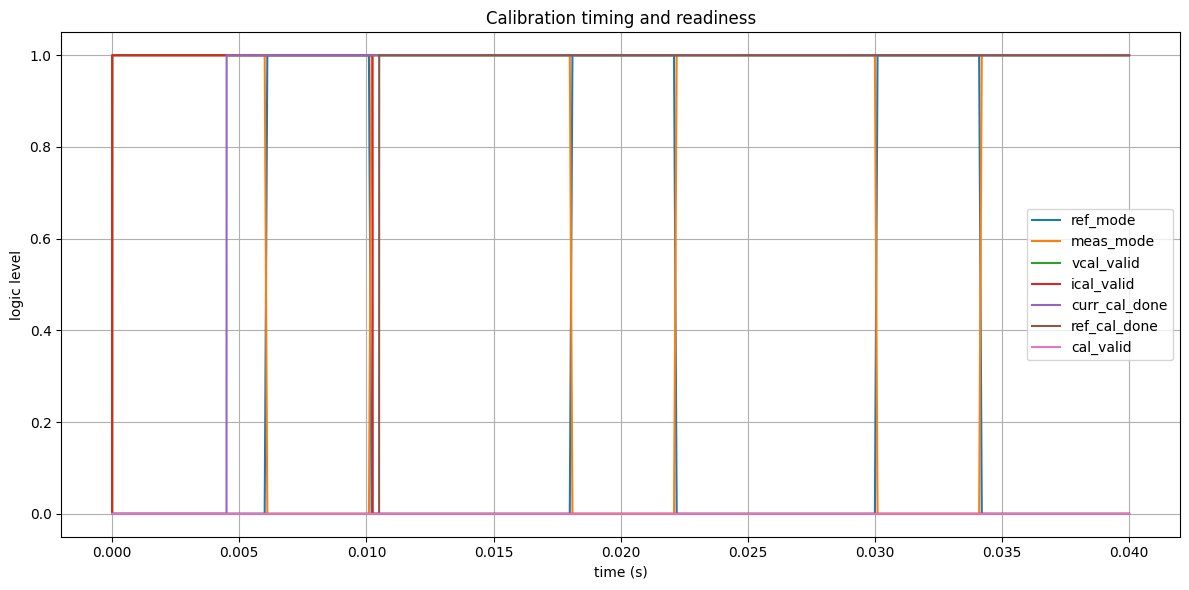

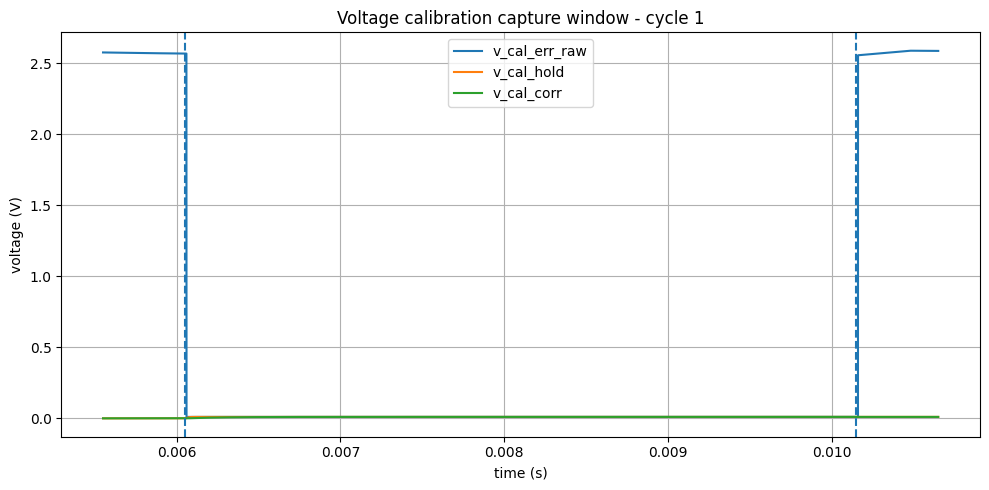

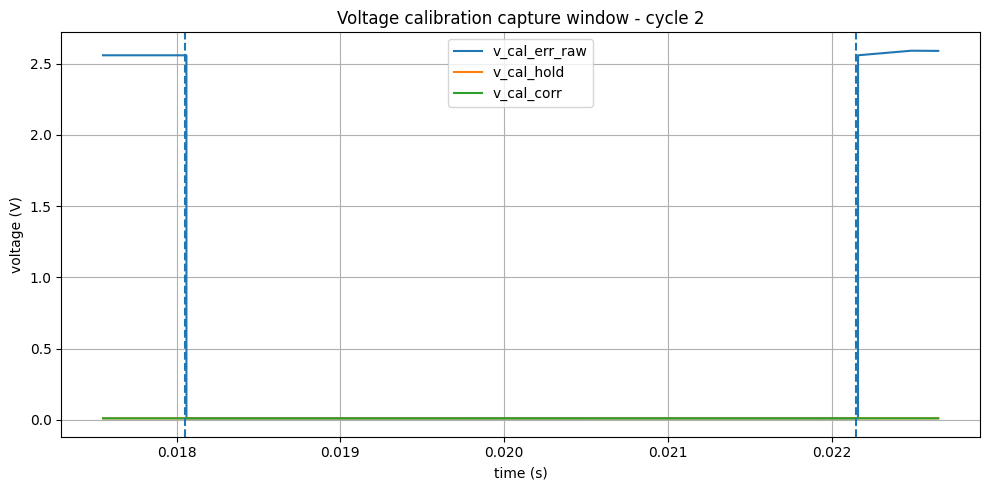

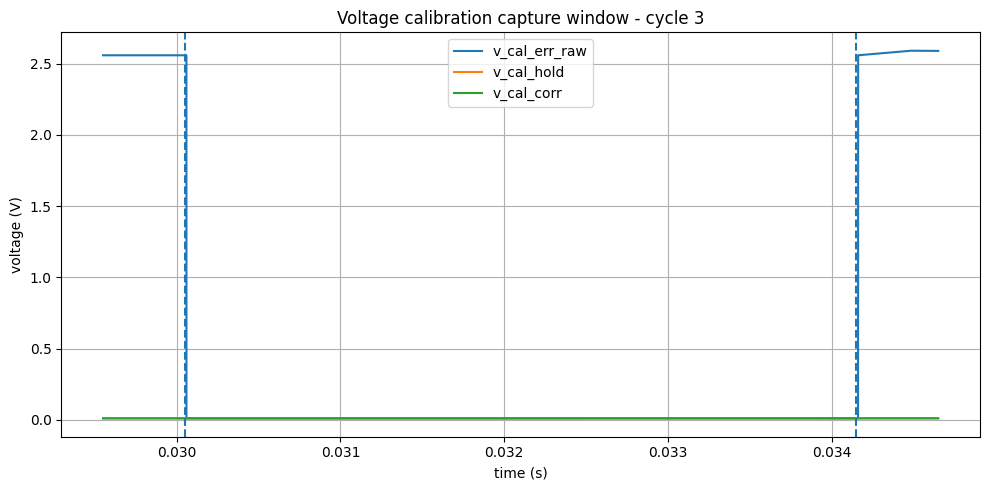

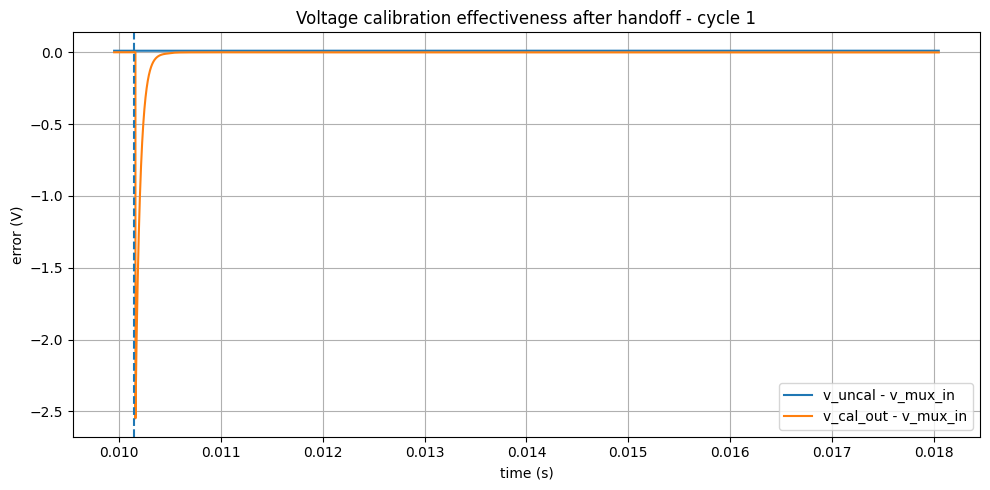

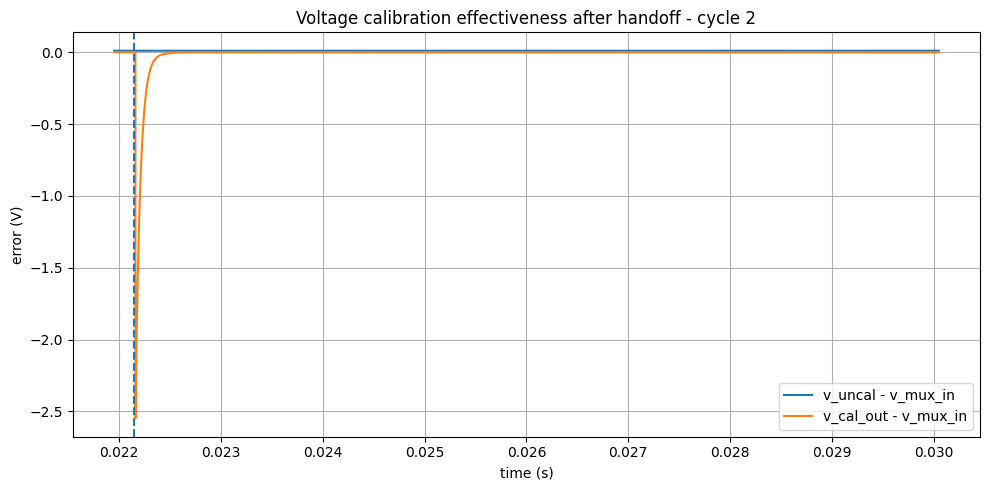

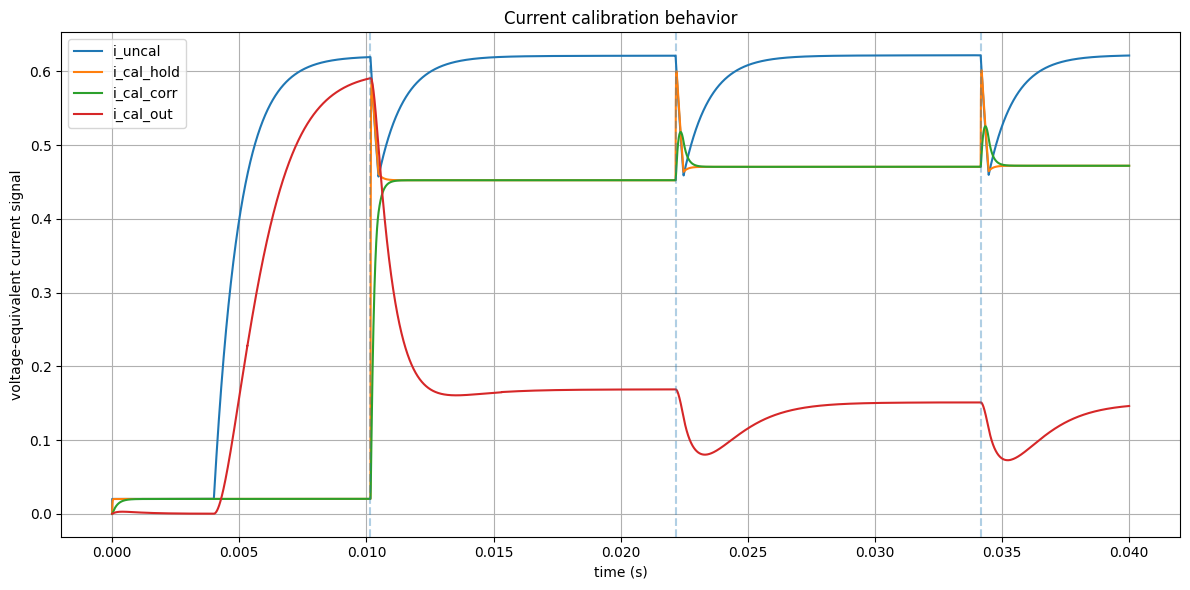

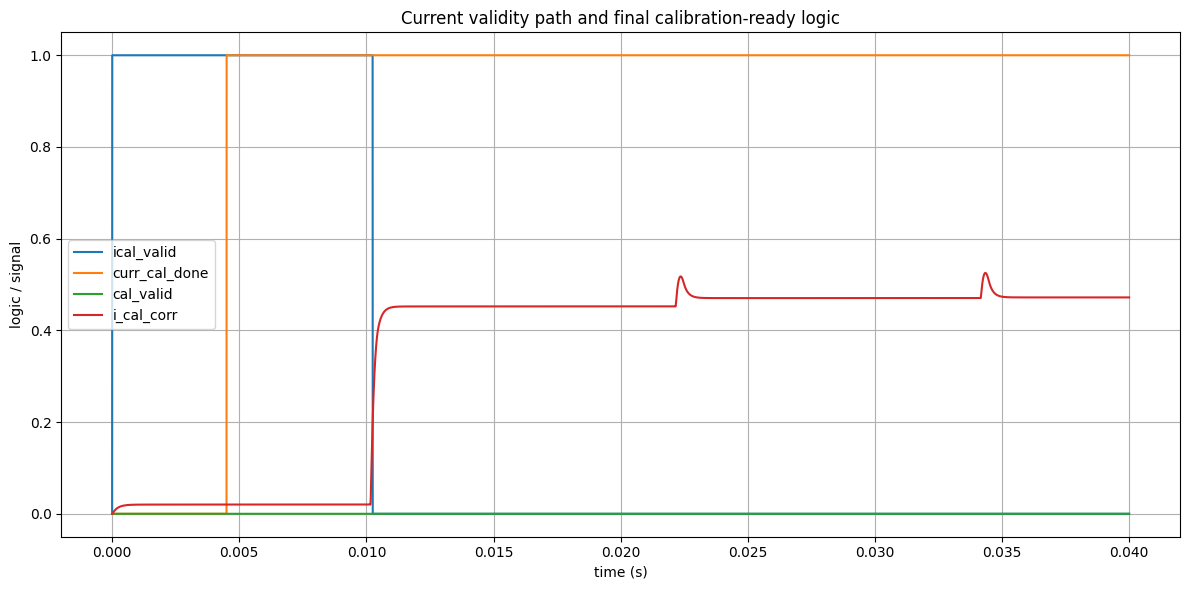

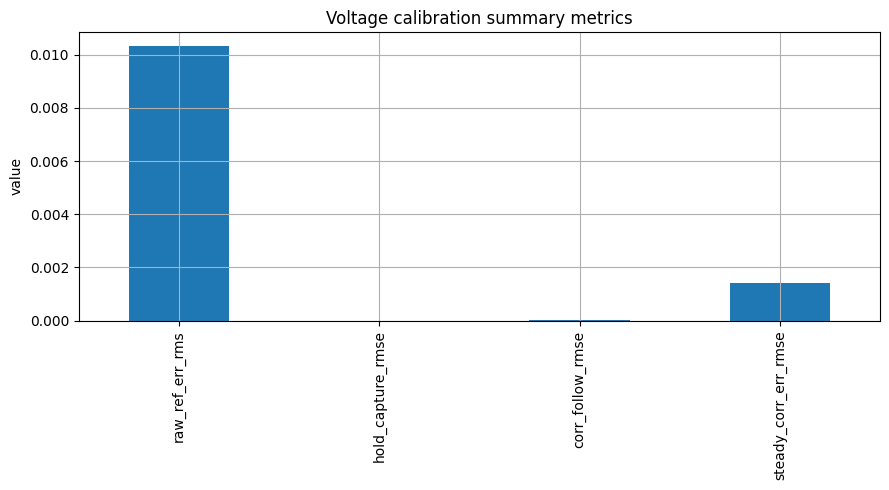


Saved files in: /kaggle/working/calibration_final
['calibration_claims_df.csv', 'current_segments_df.csv', 'current_summary_df.csv', 'plot_current_behavior.png', 'plot_current_validity.png', 'plot_timing_readiness.png', 'plot_voltage_capture_cycle_1.png', 'plot_voltage_capture_cycle_2.png', 'plot_voltage_capture_cycle_3.png', 'plot_voltage_handoff_cycle_1.png', 'plot_voltage_handoff_cycle_2.png', 'plot_voltage_summary_bars.png', 'resolved_signals.csv', 'timing_df.csv', 'voltage_cycles_df.csv', 'voltage_summary_df.csv']

=== FINAL CALIBRATION SUMMARY ===
First CAL_VALID time (s): nan
Avg voltage hold-capture RMSE: 2.792102240724713e-07
Avg voltage correction-follow RMSE: 1.3823487826819941e-05
Avg steady voltage-error improvement (%): 86.14923349819142
Steady current hold-to-corr RMSE: 0.027859545772869608


In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# =========================================================
# 0) Locate and load final calibration waveform file
# =========================================================
candidate_patterns = [
    "/kaggle/input/Calibration/CamiMa.txt",
    "/kaggle/input/calibration/CamiMa.txt",
    "/kaggle/input/**/CamiMa.txt",
]

cal_path = None
for p in candidate_patterns[:2]:
    if os.path.exists(p):
        cal_path = p
        break

if cal_path is None:
    hits = glob.glob(candidate_patterns[2], recursive=True)
    if hits:
        cal_path = hits[0]

if cal_path is None:
    raise FileNotFoundError("Could not find CamiMa.txt in /kaggle/input")

print("Using file:", cal_path)

df = pd.read_csv(cal_path, sep=r"\s+", engine="python")
print("Loaded shape:", df.shape)
print("Columns:")
print(list(df.columns))


# =========================================================
# 1) Helpers
# =========================================================
def norm_name(s):
    s = str(s).lower().strip()
    s = re.sub(r'[^a-z0-9]+', '', s)
    return s

def find_col(df, candidate_names):
    norm_cols = {norm_name(c): c for c in df.columns}
    # exact normalized match first
    for cand in candidate_names:
        nc = norm_name(cand)
        if nc in norm_cols:
            return norm_cols[nc]
    # contains match next
    for cand in candidate_names:
        nc = norm_name(cand)
        for k, v in norm_cols.items():
            if nc in k or k in nc:
                return v
    return None

def get_series(df, candidate_names, required=True):
    c = find_col(df, candidate_names)
    if c is None:
        if required:
            raise KeyError(f"Could not resolve any of: {candidate_names}")
        return None, None
    s = pd.to_numeric(df[c], errors="coerce")
    return c, s

def rmse(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.sqrt(np.mean(np.square(x))))

def max_abs(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.max(np.abs(x)))

def mean_abs(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) == 0:
        return np.nan
    return float(np.mean(np.abs(x)))

def pct_reduction(before, after):
    if pd.isna(before) or pd.isna(after) or before == 0:
        return np.nan
    return float(100.0 * (before - after) / abs(before))

def rising_edges(t, y, thr=0.5):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.where((y[:-1] < thr) & (y[1:] >= thr))[0]
    out = []
    for i in idx:
        t0, t1 = t[i], t[i+1]
        y0, y1 = y[i], y[i+1]
        if y1 == y0:
            out.append(float(t1))
        else:
            out.append(float(t0 + (thr - y0) * (t1 - t0) / (y1 - y0)))
    return np.array(out, dtype=float)

def falling_edges(t, y, thr=0.5):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.where((y[:-1] >= thr) & (y[1:] < thr))[0]
    out = []
    for i in idx:
        t0, t1 = t[i], t[i+1]
        y0, y1 = y[i], y[i+1]
        if y1 == y0:
            out.append(float(t1))
        else:
            out.append(float(t0 + (thr - y0) * (t1 - t0) / (y1 - y0)))
    return np.array(out, dtype=float)

def pair_windows(starts, stops):
    wins = []
    j = 0
    for s in starts:
        while j < len(stops) and stops[j] <= s:
            j += 1
        if j < len(stops):
            wins.append((float(s), float(stops[j])))
            j += 1
    return wins

def crop_time_mask(t, t0, t1):
    t = np.asarray(t, dtype=float)
    return (t >= t0) & (t <= t1)

def nearest_value(t, y, tq):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(t) == 0:
        return np.nan
    i = np.argmin(np.abs(t - tq))
    return float(y[i])

def first_time_within_band(t, y_abs, band, start_t):
    t = np.asarray(t, dtype=float)
    y_abs = np.asarray(y_abs, dtype=float)
    m = t >= start_t
    t2 = t[m]
    y2 = y_abs[m]
    if len(t2) == 0:
        return np.nan
    idx = np.where(y2 <= band)[0]
    if len(idx) == 0:
        return np.nan
    return float(t2[idx[0]])

def integrate_abs(t, y):
    t = pd.Series(t).dropna().astype(float).to_numpy()
    y = pd.Series(y).dropna().astype(float).to_numpy()
    n = min(len(t), len(y))
    if n < 2:
        return np.nan
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(np.abs(y[:n]), t[:n]))
    return float(np.trapz(np.abs(y[:n]), t[:n]))

def grouped_step_times(t, y, threshold=None, min_gap=1e-3):
    """
    Detect major hold-node update times from step-like changes.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    dy = np.diff(y)
    if threshold is None:
        yr = np.nanmax(y) - np.nanmin(y)
        threshold = max(0.01 * yr, 1e-4)
    idx = np.where(np.abs(dy) > threshold)[0]
    if len(idx) == 0:
        return []
    times = []
    last_t = -1e9
    for i in idx:
        ti = t[i+1]
        if ti - last_t >= min_gap:
            times.append(float(ti))
            last_t = ti
    return times


# =========================================================
# 2) Resolve final saved signals
# =========================================================
resolved = {}

resolved["time_col"], t = get_series(df, ["time"])
resolved["ref_mode_col"], ref_mode = get_series(df, ["V(REF_MODE)", "REF_MODE"])
resolved["meas_mode_col"], meas_mode = get_series(df, ["V(MEAS_MODE)", "MEAS_MODE"])
resolved["vcal_valid_col"], vcal_valid = get_series(df, ["V(VCAL_VALID)", "VCAL_VALID"])
resolved["ical_valid_col"], ical_valid = get_series(df, ["V(ICAL_VALID)", "ICAL_VALID"])
resolved["curr_cal_done_col"], curr_cal_done = get_series(df, ["V(CURR_CAL_DONE)", "CURR_CAL_DONE"])
resolved["ref_cal_done_col"], ref_cal_done = get_series(df, ["V(REF_CAL_DONE)", "REF_CAL_DONE"])
resolved["cal_valid_col"], cal_valid = get_series(df, ["V(CAL_VALID)", "CAL_VALID"])

resolved["v_mux_in_col"], v_mux_in = get_series(df, ["V(V_mux_in)", "V_mux_in"])
resolved["v_uncal_col"], v_uncal = get_series(df, ["V(V_uncal)", "V_uncal"])
resolved["v_cal_err_raw_col"], v_cal_err_raw = get_series(df, ["V(V_cal_err_raw)", "V_cal_err_raw"])
resolved["v_cal_hold_col"], v_cal_hold = get_series(df, ["V(V_CAL_HOLD)", "V_CAL_HOLD"])
resolved["v_cal_corr_col"], v_cal_corr = get_series(df, ["V(V_cal_corr)", "V_cal_corr"])
resolved["v_cal_out_col"], v_cal_out = get_series(df, ["V(V_cal_out)", "V_cal_out"])

resolved["i_uncal_col"], i_uncal = get_series(df, ["V(I_uncal)", "I_uncal"])
resolved["i_cal_hold_col"], i_cal_hold = get_series(df, ["V(I_CAL_HOLD)", "I_CAL_HOLD"])
resolved["i_cal_corr_col"], i_cal_corr = get_series(df, ["V(I_cal_corr)", "I_cal_corr"])
resolved["i_cal_out_col"], i_cal_out = get_series(df, ["V(I_cal_out)", "I_cal_out"])

resolved_signals_df = pd.DataFrame({
    "logical_name": list(resolved.keys()),
    "resolved_column": list(resolved.values())
})
display(resolved_signals_df)


# =========================================================
# 3) Basic arrays
# =========================================================
t_arr = t.to_numpy()

ref_arr = ref_mode.to_numpy()
meas_arr = meas_mode.to_numpy()
vcal_arr = vcal_valid.to_numpy()
ical_arr = ical_valid.to_numpy()
curr_done_arr = curr_cal_done.to_numpy()
ref_done_arr = ref_cal_done.to_numpy()
cal_valid_arr = cal_valid.to_numpy()

v_mux_arr = v_mux_in.to_numpy()
v_uncal_arr = v_uncal.to_numpy()
v_err_arr = v_cal_err_raw.to_numpy()
v_hold_arr = v_cal_hold.to_numpy()
v_corr_arr = v_cal_corr.to_numpy()
v_out_arr = v_cal_out.to_numpy()

i_uncal_arr = i_uncal.to_numpy()
i_hold_arr = i_cal_hold.to_numpy()
i_corr_arr = i_cal_corr.to_numpy()
i_out_arr = i_cal_out.to_numpy()


# =========================================================
# 4) Timing / window extraction
# =========================================================
ref_starts = rising_edges(t_arr, ref_arr, 0.5)
ref_stops  = falling_edges(t_arr, ref_arr, 0.5)
meas_starts = rising_edges(t_arr, meas_arr, 0.5)
meas_stops  = falling_edges(t_arr, meas_arr, 0.5)

ref_windows = pair_windows(ref_starts, ref_stops)
meas_windows = pair_windows(meas_starts, meas_stops)

def first_rise_time(arr):
    r = rising_edges(t_arr, arr, 0.5)
    return float(r[0]) if len(r) else np.nan

timing_df = pd.DataFrame([{
    "num_ref_windows": len(ref_windows),
    "num_meas_windows": len(meas_windows),
    "first_ref_start_s": float(ref_windows[0][0]) if len(ref_windows) else np.nan,
    "first_ref_stop_s": float(ref_windows[0][1]) if len(ref_windows) else np.nan,
    "first_vcal_valid_s": first_rise_time(vcal_arr),
    "first_ical_valid_s": first_rise_time(ical_arr),
    "first_curr_cal_done_s": first_rise_time(curr_done_arr),
    "first_ref_cal_done_s": first_rise_time(ref_done_arr),
    "first_cal_valid_s": first_rise_time(cal_valid_arr),
}])

# extra timing relations
if not timing_df["first_ref_start_s"].isna().iloc[0]:
    timing_df["ref_to_vcal_valid_us"] = (
        (timing_df["first_vcal_valid_s"] - timing_df["first_ref_start_s"]) * 1e6
    )
    timing_df["ref_done_to_cal_valid_us"] = (
        (timing_df["first_cal_valid_s"] - timing_df["first_ref_cal_done_s"]) * 1e6
    )
    timing_df["curr_done_to_cal_valid_us"] = (
        (timing_df["first_cal_valid_s"] - timing_df["first_curr_cal_done_s"]) * 1e6
    )

display(timing_df)


# =========================================================
# 5) Advanced voltage-calibration analysis per reference cycle
# =========================================================
voltage_rows = []

for k, (ref_s, ref_e) in enumerate(ref_windows, start=1):
    ref_dur = ref_e - ref_s

    # settled portion of reference window
    ref_settle_s = ref_s + 0.20 * ref_dur
    m_ref = crop_time_mask(t_arr, ref_settle_s, ref_e)

    ref_err = v_err_arr[m_ref]
    ref_hold = v_hold_arr[m_ref]
    ref_corr = v_corr_arr[m_ref]
    ref_time = t_arr[m_ref]

    # next measurement window after reference phase
    post_candidates = [(ms, me) for (ms, me) in meas_windows if ms >= ref_e - 1e-12]
    pre_candidates = [(ms, me) for (ms, me) in meas_windows if me <= ref_s + 1e-12]

    post_ms, post_me = post_candidates[0] if len(post_candidates) else (np.nan, np.nan)
    pre_ms, pre_me   = pre_candidates[-1] if len(pre_candidates) else (np.nan, np.nan)

    # pre measurement raw error
    if pd.notna(pre_ms) and pd.notna(pre_me):
        m_pre = crop_time_mask(t_arr, pre_ms, pre_me)
        pre_raw_err = v_uncal_arr[m_pre] - v_mux_arr[m_pre]
        pre_corr_err = v_out_arr[m_pre] - v_mux_arr[m_pre]
        pre_raw_rmse = rmse(pre_raw_err)
        pre_corr_rmse = rmse(pre_corr_err)
    else:
        pre_raw_rmse = np.nan
        pre_corr_rmse = np.nan

    # post measurement error
    if pd.notna(post_ms) and pd.notna(post_me):
        m_post = crop_time_mask(t_arr, post_ms, post_me)
        t_post = t_arr[m_post]
        raw_post_err = v_uncal_arr[m_post] - v_mux_arr[m_post]
        corr_post_err = v_out_arr[m_post] - v_mux_arr[m_post]

        # transient zone: first 0.5 ms after reference end
        t_trans_end = min(post_me, ref_e + 0.5e-3)
        m_trans = crop_time_mask(t_arr, ref_e, t_trans_end)
        trans_corr_err = v_out_arr[m_trans] - v_mux_arr[m_trans]

        # steady zone: after first 0.5 ms
        t_steady_start = min(post_me, ref_e + 0.5e-3)
        m_steady = crop_time_mask(t_arr, t_steady_start, post_me)
        steady_raw_err = v_uncal_arr[m_steady] - v_mux_arr[m_steady]
        steady_corr_err = v_out_arr[m_steady] - v_mux_arr[m_steady]
        t_steady = t_arr[m_steady]

        settle_10mV = first_time_within_band(t_post, np.abs(corr_post_err), 0.010, ref_e)
        settle_20mV = first_time_within_band(t_post, np.abs(corr_post_err), 0.020, ref_e)

        row = {
            "cycle_id": k,
            "ref_start_s": ref_s,
            "ref_stop_s": ref_e,
            "ref_window_s": ref_dur,
            "pre_meas_start_s": pre_ms,
            "pre_meas_stop_s": pre_me,
            "post_meas_start_s": post_ms,
            "post_meas_stop_s": post_me,

            "raw_ref_err_mean": float(np.mean(ref_err)) if len(ref_err) else np.nan,
            "raw_ref_err_rms": rmse(ref_err),
            "hold_capture_rmse": rmse(ref_hold - ref_err) if len(ref_err) else np.nan,
            "corr_follow_rmse": rmse(ref_corr - ref_hold) if len(ref_err) else np.nan,
            "hold_minus_err_mean": float(np.mean(ref_hold - ref_err)) if len(ref_err) else np.nan,
            "corr_minus_hold_mean": float(np.mean(ref_corr - ref_hold)) if len(ref_err) else np.nan,

            "pre_raw_err_rmse": pre_raw_rmse,
            "pre_corr_err_rmse": pre_corr_rmse,

            "post_raw_err_rmse": rmse(raw_post_err),
            "post_corr_err_rmse": rmse(corr_post_err),
            "post_raw_err_maxabs": max_abs(raw_post_err),
            "post_corr_err_maxabs": max_abs(corr_post_err),

            "steady_raw_err_rmse": rmse(steady_raw_err),
            "steady_corr_err_rmse": rmse(steady_corr_err),
            "steady_rmse_improvement_percent": pct_reduction(rmse(steady_raw_err), rmse(steady_corr_err)),
            "steady_maxabs_improvement_percent": pct_reduction(max_abs(steady_raw_err), max_abs(steady_corr_err)),

            "handoff_transient_peak_abs_err": max_abs(trans_corr_err),
            "handoff_transient_area": integrate_abs(t_arr[m_trans], trans_corr_err),

            "settle_to_10mV_us": (settle_10mV - ref_e) * 1e6 if pd.notna(settle_10mV) else np.nan,
            "settle_to_20mV_us": (settle_20mV - ref_e) * 1e6 if pd.notna(settle_20mV) else np.nan,
        }
    else:
        row = {
            "cycle_id": k,
            "ref_start_s": ref_s,
            "ref_stop_s": ref_e,
            "ref_window_s": ref_dur,
            "pre_meas_start_s": pre_ms,
            "pre_meas_stop_s": pre_me,
            "post_meas_start_s": post_ms,
            "post_meas_stop_s": post_me,

            "raw_ref_err_mean": float(np.mean(ref_err)) if len(ref_err) else np.nan,
            "raw_ref_err_rms": rmse(ref_err),
            "hold_capture_rmse": rmse(ref_hold - ref_err) if len(ref_err) else np.nan,
            "corr_follow_rmse": rmse(ref_corr - ref_hold) if len(ref_err) else np.nan,
            "hold_minus_err_mean": float(np.mean(ref_hold - ref_err)) if len(ref_err) else np.nan,
            "corr_minus_hold_mean": float(np.mean(ref_corr - ref_hold)) if len(ref_err) else np.nan,
        }

    voltage_rows.append(row)

voltage_cycles_df = pd.DataFrame(voltage_rows)
display(voltage_cycles_df)

voltage_summary_df = pd.DataFrame([{
    "num_cycles": len(voltage_cycles_df),
    "avg_raw_ref_err_rms": voltage_cycles_df["raw_ref_err_rms"].mean(),
    "avg_hold_capture_rmse": voltage_cycles_df["hold_capture_rmse"].mean(),
    "avg_corr_follow_rmse": voltage_cycles_df["corr_follow_rmse"].mean(),
    "avg_steady_raw_err_rmse": voltage_cycles_df.get("steady_raw_err_rmse", pd.Series(dtype=float)).mean(),
    "avg_steady_corr_err_rmse": voltage_cycles_df.get("steady_corr_err_rmse", pd.Series(dtype=float)).mean(),
    "avg_steady_rmse_improvement_percent": voltage_cycles_df.get("steady_rmse_improvement_percent", pd.Series(dtype=float)).mean(),
    "avg_handoff_transient_peak_abs_err": voltage_cycles_df.get("handoff_transient_peak_abs_err", pd.Series(dtype=float)).mean(),
    "avg_settle_to_10mV_us": voltage_cycles_df.get("settle_to_10mV_us", pd.Series(dtype=float)).mean(),
    "avg_settle_to_20mV_us": voltage_cycles_df.get("settle_to_20mV_us", pd.Series(dtype=float)).mean(),
}])
display(voltage_summary_df)


# =========================================================
# 6) Advanced current-calibration analysis
# =========================================================
# detect hold updates from I_CAL_HOLD
hold_update_times = grouped_step_times(t_arr, i_hold_arr, threshold=None, min_gap=0.75e-3)

# build current segments between updates
seg_bounds = [float(t_arr.min())] + hold_update_times + [float(t_arr.max())]
current_seg_rows = []
for k in range(len(seg_bounds) - 1):
    s0 = seg_bounds[k]
    s1 = seg_bounds[k+1]
    m = crop_time_mask(t_arr, s0, s1)
    if m.sum() < 5:
        continue
    current_seg_rows.append({
        "segment_id": k + 1,
        "start_s": s0,
        "stop_s": s1,
        "duration_s": s1 - s0,
        "i_uncal_mean": float(np.mean(i_uncal_arr[m])),
        "i_uncal_rms": rmse(i_uncal_arr[m]),
        "i_cal_hold_mean": float(np.mean(i_hold_arr[m])),
        "i_cal_corr_mean": float(np.mean(i_corr_arr[m])),
        "i_cal_out_mean": float(np.mean(i_out_arr[m])),
        "hold_to_corr_rmse": rmse(i_corr_arr[m] - i_hold_arr[m]),
        "raw_to_out_mean_delta": float(np.mean(i_uncal_arr[m] - i_out_arr[m])),
        "out_to_raw_ratio_mean": float(np.mean(np.abs(i_out_arr[m]) / (np.abs(i_uncal_arr[m]) + 1e-12))),
    })

current_segments_df = pd.DataFrame(current_seg_rows)
display(current_segments_df)

# steady current-valid zone
t_ical = first_rise_time(ical_arr)
t_curr_done = first_rise_time(curr_done_arr)
steady_start = np.nanmax([t_ical, t_curr_done]) if not (pd.isna(t_ical) and pd.isna(t_curr_done)) else np.nan

if pd.notna(steady_start):
    m_st = t_arr >= steady_start
    current_summary_df = pd.DataFrame([{
        "first_ical_valid_s": t_ical,
        "first_curr_cal_done_s": t_curr_done,
        "steady_start_s": steady_start,
        "steady_hold_to_corr_rmse": rmse(i_corr_arr[m_st] - i_hold_arr[m_st]),
        "steady_hold_to_corr_maxabs": max_abs(i_corr_arr[m_st] - i_hold_arr[m_st]),
        "steady_i_uncal_mean": float(np.mean(i_uncal_arr[m_st])),
        "steady_i_cal_out_mean": float(np.mean(i_out_arr[m_st])),
        "steady_raw_to_out_mean_delta": float(np.mean(i_uncal_arr[m_st] - i_out_arr[m_st])),
        "steady_out_to_raw_ratio_mean": float(np.mean(np.abs(i_out_arr[m_st]) / (np.abs(i_uncal_arr[m_st]) + 1e-12))),
        "hold_update_count": len(hold_update_times),
    }])
else:
    current_summary_df = pd.DataFrame([{
        "first_ical_valid_s": t_ical,
        "first_curr_cal_done_s": t_curr_done,
        "steady_start_s": steady_start,
        "hold_update_count": len(hold_update_times),
    }])

display(current_summary_df)


# =========================================================
# 7) Final report-claim table
# =========================================================
calibration_claims_df = pd.DataFrame([
    {
        "claim": "Voltage reference error is captured on the hold node",
        "metric": "avg_hold_capture_rmse",
        "value": voltage_summary_df["avg_hold_capture_rmse"].iloc[0],
        "engineering_target": "smaller is better"
    },
    {
        "claim": "Voltage correction follows the stored hold value",
        "metric": "avg_corr_follow_rmse",
        "value": voltage_summary_df["avg_corr_follow_rmse"].iloc[0],
        "engineering_target": "smaller is better"
    },
    {
        "claim": "Corrected voltage output reduces steady post-handoff error",
        "metric": "avg_steady_rmse_improvement_percent",
        "value": voltage_summary_df["avg_steady_rmse_improvement_percent"].iloc[0],
        "engineering_target": "larger is better"
    },
    {
        "claim": "Current correction follows the stored current hold value",
        "metric": "steady_hold_to_corr_rmse",
        "value": current_summary_df["steady_hold_to_corr_rmse"].iloc[0] if "steady_hold_to_corr_rmse" in current_summary_df.columns else np.nan,
        "engineering_target": "smaller is better"
    },
    {
        "claim": "Final calibration-ready flag is asserted",
        "metric": "first_cal_valid_s",
        "value": timing_df["first_cal_valid_s"].iloc[0],
        "engineering_target": "must exist"
    },
])

display(calibration_claims_df)


# =========================================================
# 8) Final plots
# =========================================================
outdir = "/kaggle/working/calibration_final"
os.makedirs(outdir, exist_ok=True)

# ---- Plot 1: timing and readiness
plt.figure(figsize=(12, 6))
plt.plot(t_arr, ref_arr, label="ref_mode")
plt.plot(t_arr, meas_arr, label="meas_mode")
plt.plot(t_arr, vcal_arr, label="vcal_valid")
plt.plot(t_arr, ical_arr, label="ical_valid")
plt.plot(t_arr, curr_done_arr, label="curr_cal_done")
plt.plot(t_arr, ref_done_arr, label="ref_cal_done")
plt.plot(t_arr, cal_valid_arr, label="cal_valid")
plt.title("Calibration timing and readiness")
plt.xlabel("time (s)")
plt.ylabel("logic level")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"{outdir}/plot_timing_readiness.png", dpi=200)
plt.show()

# ---- Plot 2: voltage capture/correction for each cycle
for _, r in voltage_cycles_df.iterrows():
    cid = int(r["cycle_id"])
    t0 = max(t_arr.min(), r["ref_start_s"] - 0.5e-3)
    t1 = min(t_arr.max(), r["ref_stop_s"] + 0.5e-3)
    m = crop_time_mask(t_arr, t0, t1)

    plt.figure(figsize=(10, 5))
    plt.plot(t_arr[m], v_err_arr[m], label="v_cal_err_raw")
    plt.plot(t_arr[m], v_hold_arr[m], label="v_cal_hold")
    plt.plot(t_arr[m], v_corr_arr[m], label="v_cal_corr")
    plt.axvline(r["ref_start_s"], linestyle="--")
    plt.axvline(r["ref_stop_s"], linestyle="--")
    plt.title(f"Voltage calibration capture window - cycle {cid}")
    plt.xlabel("time (s)")
    plt.ylabel("voltage (V)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{outdir}/plot_voltage_capture_cycle_{cid}.png", dpi=200)
    plt.show()

# ---- Plot 3: voltage raw vs corrected measurement error after each handoff
for _, r in voltage_cycles_df.iterrows():
    cid = int(r["cycle_id"])
    if pd.isna(r.get("post_meas_start_s", np.nan)) or pd.isna(r.get("post_meas_stop_s", np.nan)):
        continue
    t0 = max(t_arr.min(), r["ref_stop_s"] - 0.2e-3)
    t1 = min(t_arr.max(), r["post_meas_stop_s"])
    m = crop_time_mask(t_arr, t0, t1)

    raw_err = v_uncal_arr[m] - v_mux_arr[m]
    corr_err = v_out_arr[m] - v_mux_arr[m]

    plt.figure(figsize=(10, 5))
    plt.plot(t_arr[m], raw_err, label="v_uncal - v_mux_in")
    plt.plot(t_arr[m], corr_err, label="v_cal_out - v_mux_in")
    plt.axvline(r["ref_stop_s"], linestyle="--")
    plt.title(f"Voltage calibration effectiveness after handoff - cycle {cid}")
    plt.xlabel("time (s)")
    plt.ylabel("error (V)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{outdir}/plot_voltage_handoff_cycle_{cid}.png", dpi=200)
    plt.show()

# ---- Plot 4: current calibration behavior
plt.figure(figsize=(12, 6))
plt.plot(t_arr, i_uncal_arr, label="i_uncal")
plt.plot(t_arr, i_hold_arr, label="i_cal_hold")
plt.plot(t_arr, i_corr_arr, label="i_cal_corr")
plt.plot(t_arr, i_out_arr, label="i_cal_out")
for tu in hold_update_times:
    plt.axvline(tu, linestyle="--", alpha=0.35)
plt.title("Current calibration behavior")
plt.xlabel("time (s)")
plt.ylabel("voltage-equivalent current signal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"{outdir}/plot_current_behavior.png", dpi=200)
plt.show()

# ---- Plot 5: current validity and final readiness
plt.figure(figsize=(12, 6))
plt.plot(t_arr, ical_arr, label="ical_valid")
plt.plot(t_arr, curr_done_arr, label="curr_cal_done")
plt.plot(t_arr, cal_valid_arr, label="cal_valid")
plt.plot(t_arr, i_corr_arr, label="i_cal_corr")
plt.title("Current validity path and final calibration-ready logic")
plt.xlabel("time (s)")
plt.ylabel("logic / signal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"{outdir}/plot_current_validity.png", dpi=200)
plt.show()

# ---- Plot 6: summary bar chart
summary_bar = pd.DataFrame({
    "raw_ref_err_rms": [voltage_summary_df["avg_raw_ref_err_rms"].iloc[0]],
    "hold_capture_rmse": [voltage_summary_df["avg_hold_capture_rmse"].iloc[0]],
    "corr_follow_rmse": [voltage_summary_df["avg_corr_follow_rmse"].iloc[0]],
    "steady_corr_err_rmse": [voltage_summary_df["avg_steady_corr_err_rmse"].iloc[0]],
})
ax = summary_bar.T.plot(kind="bar", legend=False, figsize=(9,5), grid=True, title="Voltage calibration summary metrics")
ax.set_ylabel("value")
plt.tight_layout()
plt.savefig(f"{outdir}/plot_voltage_summary_bars.png", dpi=200)
plt.show()


# =========================================================
# 9) Save all tables
# =========================================================
resolved_signals_df.to_csv(f"{outdir}/resolved_signals.csv", index=False)
timing_df.to_csv(f"{outdir}/timing_df.csv", index=False)
voltage_cycles_df.to_csv(f"{outdir}/voltage_cycles_df.csv", index=False)
voltage_summary_df.to_csv(f"{outdir}/voltage_summary_df.csv", index=False)
current_segments_df.to_csv(f"{outdir}/current_segments_df.csv", index=False)
current_summary_df.to_csv(f"{outdir}/current_summary_df.csv", index=False)
calibration_claims_df.to_csv(f"{outdir}/calibration_claims_df.csv", index=False)

print("\nSaved files in:", outdir)
print(sorted(os.listdir(outdir)))


# =========================================================
# 10) Short final console summary
# =========================================================
print("\n=== FINAL CALIBRATION SUMMARY ===")
print("First CAL_VALID time (s):", timing_df["first_cal_valid_s"].iloc[0])
print("Avg voltage hold-capture RMSE:", voltage_summary_df["avg_hold_capture_rmse"].iloc[0])
print("Avg voltage correction-follow RMSE:", voltage_summary_df["avg_corr_follow_rmse"].iloc[0])
print("Avg steady voltage-error improvement (%):", voltage_summary_df["avg_steady_rmse_improvement_percent"].iloc[0])
if "steady_hold_to_corr_rmse" in current_summary_df.columns:
    print("Steady current hold-to-corr RMSE:", current_summary_df["steady_hold_to_corr_rmse"].iloc[0])